In [1]:
# ==========================================
# SECTION 0 — SETUP
# ==========================================

!pip install yfinance pandas numpy scikit-learn statsmodels tensorflow matplotlib -q

import os
import random
import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Bidirectional, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("Setup complete.")

Setup complete.


In [2]:
# ==========================================
# SECTION 1 — PROJECT CONFIG
# ==========================================

tickers = ["AAPL", "MSFT", "NVDA"]

# 三个候选时间段
ranges = {
    "long": ("2000-01-01", "2026-06-28"),
    "mid": ("2010-01-01", "2026-06-28"),
    "short": ("2016-01-01", "2026-06-28"),
}

# 主实验最终统一使用 mid
main_datasets = {
    "AAPL": "AAPL_mid_clean.csv",
    "MSFT": "MSFT_mid_clean.csv",
    "NVDA": "NVDA_mid_clean.csv",
}

DEFAULT_SEQ_LEN = 20
RANDOM_STATE = 42

print("Tickers:", tickers)
print("Ranges:", ranges)
print("Main datasets:", main_datasets)

Tickers: ['AAPL', 'MSFT', 'NVDA']
Ranges: {'long': ('2000-01-01', '2026-06-28'), 'mid': ('2010-01-01', '2026-06-28'), 'short': ('2016-01-01', '2026-06-28')}
Main datasets: {'AAPL': 'AAPL_mid_clean.csv', 'MSFT': 'MSFT_mid_clean.csv', 'NVDA': 'NVDA_mid_clean.csv'}


In [3]:
# ==========================================
# SECTION 2 — RAW DATA DOWNLOAD
# ==========================================

def download_stock_data(ticker, start_date, end_date):
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.reset_index()
    return df

all_data = {}

for label, (start_date, end_date) in ranges.items():
    print(f"\n=== Downloading {label} range: {start_date} to {end_date} ===")
    all_data[label] = {}

    for ticker in tickers:
        df = download_stock_data(ticker, start_date, end_date)
        all_data[label][ticker] = df

        file_name = f"{ticker}_{label}_raw.csv"
        df.to_csv(file_name, index=False)

        print(f"{ticker}: {df.shape[0]} rows saved to {file_name}")

print("\nDownload complete.")


=== Downloading long range: 2000-01-01 to 2026-06-28 ===


[*********************100%***********************]  1 of 1 completed


AAPL: 6660 rows saved to AAPL_long_raw.csv


[*********************100%***********************]  1 of 1 completed


MSFT: 6660 rows saved to MSFT_long_raw.csv


...

AAPL: 2635 rows saved to AAPL_short_raw.csv


[*********************100%***********************]  1 of 1 completed


MSFT: 2635 rows saved to MSFT_short_raw.csv


[*********************100%***********************]  1 of 1 completed

NVDA: 2635 rows saved to NVDA_short_raw.csv

Download complete.


In [4]:
# ==========================================
# SECTION 3 — DATA CLEANING
# ==========================================

file_list = [
    "AAPL_long_raw.csv", "MSFT_long_raw.csv", "NVDA_long_raw.csv",
    "AAPL_mid_raw.csv", "MSFT_mid_raw.csv", "NVDA_mid_raw.csv",
    "AAPL_short_raw.csv", "MSFT_short_raw.csv", "NVDA_short_raw.csv"
]

def clean_stock_data(file_name):
    print(f"\n===== Cleaning {file_name} =====")
    df = pd.read_csv(file_name)

    df.columns = [str(col).strip() for col in df.columns]

    expected_cols = ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]
    available_cols = [col for col in expected_cols if col in df.columns]
    df = df[available_cols].copy()

    df = df.dropna(how="all")

    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    numeric_cols = [col for col in ["Open", "High", "Low", "Close", "Adj Close", "Volume"] if col in df.columns]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["Date", "Close"])
    df = df.sort_values("Date").reset_index(drop=True)

    # next-day close target
    df["Target_Next_Close"] = df["Close"].shift(-1)
    df = df.dropna(subset=["Target_Next_Close"]).reset_index(drop=True)

    cleaned_file = file_name.replace("_raw.csv", "_clean.csv")
    df.to_csv(cleaned_file, index=False)

    print("Saved:", cleaned_file)
    print("Shape:", df.shape)
    print("Date range:", df["Date"].min(), "to", df["Date"].max())

    return df

cleaned_data = {}
for file_name in file_list:
    if os.path.exists(file_name):
        cleaned_data[file_name] = clean_stock_data(file_name)
    else:
        print(f"Missing file: {file_name}")


===== Cleaning AAPL_long_raw.csv =====
Saved: AAPL_long_clean.csv
Shape: (6659, 8)
Date range: 2000-01-03 00:00:00 to 2026-06-25 00:00:00

===== Cleaning MSFT_long_raw.csv =====
Saved: MSFT_long_clean.csv
Shape: (6659, 8)
Date range: 2000-01-03 00:00:00 to 2026-06-25 00:00:00

===== Cleaning NVDA_long_raw.csv =====
Saved: NVDA_long_clean.csv
Shape: (6659, 8)
Date range: 2000-01-03 00:00:00 to 2026-06-25 00:00:00

===== Cleaning AAPL_mid_raw.csv =====
Saved: AAPL_mid_clean.csv
Shape: (4144, 8)
Date range: 2010-01-04 00:00:00 to 2026-06-25 00:00:00

===== Cleaning MSFT_mid_raw.csv =====
Saved: MSFT_mid_clean.csv
Shape: (4144, 8)
Date range: 2010-01-04 00:00:00 to 2026-06-25 00:00:00

===== Cleaning NVDA_mid_raw.csv =====
Saved: NVDA_mid_clean.csv
Shape: (4144, 8)
Date range: 2010-01-04 00:00:00 to 2026-06-25 00:00:00

===== Cleaning AAPL_short_raw.csv =====
Saved: AAPL_short_clean.csv
Shape: (2634, 8)
Date range: 2016-01-04 00:00:00 to 2026-06-25 00:00:00

===== Cleaning MSFT_short_raw.

In [5]:
# ==========================================
# SECTION 4 — WINDOW SELECTION
# 用简单 baseline 比较 long / mid / short
# ==========================================

datasets = {
    "AAPL_long": "AAPL_long_clean.csv",
    "MSFT_long": "MSFT_long_clean.csv",
    "NVDA_long": "NVDA_long_clean.csv",
    "AAPL_mid": "AAPL_mid_clean.csv",
    "MSFT_mid": "MSFT_mid_clean.csv",
    "NVDA_mid": "NVDA_mid_clean.csv",
    "AAPL_short": "AAPL_short_clean.csv",
    "MSFT_short": "MSFT_short_clean.csv",
    "NVDA_short": "NVDA_short_clean.csv",
}

window_results = []

for name, file in datasets.items():
    df = pd.read_csv(file)

    X = df[["Open", "High", "Low", "Close", "Volume"]]
    y = df["Target_Next_Close"]
    current_close = df["Close"]

    split_idx = int(len(df) * 0.8)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    close_test = current_close.iloc[split_idx:].values

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)

    true_direction = np.sign(y_test.values - close_test)
    pred_direction = np.sign(y_pred - close_test)
    da = np.mean(true_direction == pred_direction) * 100

    window_results.append({
        "Dataset": name,
        "Rows": len(df),
        "Train Rows": len(X_train),
        "Test Rows": len(X_test),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2,
        "Directional Accuracy (%)": da
    })

window_results_df = pd.DataFrame(window_results)
print(window_results_df)
window_results_df.to_csv("window_selection_results_3ranges.csv", index=False)

      Dataset  Rows  Train Rows  Test Rows       MAE      RMSE  MAPE (%)  \
0   AAPL_long  6659        5327       1332  2.401075  3.397916  1.280458   
1   MSFT_long  6659        5327       1332  4.361035  6.044385  1.262489   
2   NVDA_long  6659        5327       1332  1.771175  2.917137  2.406005   
3    AAPL_mid  4144        3315        829  2.433161  3.577760  1.118908   
4    MSFT_mid  4144        3315        829  4.504514  6.349504  1.117835   
5    NVDA_mid  4144        3315        829  2.474737  3.589391  2.155719   
6  AAPL_short  2634        2107        527  2.852183  4.133752  1.212840   
7  MSFT_short  2634        2107        527  4.927397  7.066748  1.141037   
8  NVDA_short  2634        2107        527  3.260173  4.333891  2.218159   

         R2  Directional Accuracy (%)  
0  0.994390                 49.324324  
1  0.994812                 49.924925  
2  0.998035                 50.975976  
3  0.990962                 48.130277  
4  0.989459                 48.733414  

In [6]:
# ==========================================
# SECTION 5 — BEST RANGE SUMMARY
# ==========================================

window_results_df["Company"] = window_results_df["Dataset"].apply(lambda x: x.split("_")[0])
window_results_df["Range"] = window_results_df["Dataset"].apply(lambda x: x.split("_")[1])

best_range_by_company = (
    window_results_df.sort_values(["Company", "MAPE (%)"])
    .groupby("Company")
    .first()
    .reset_index()
)

print(best_range_by_company)
best_range_by_company.to_csv("best_range_by_company.csv", index=False)

  Company   Dataset  Rows  Train Rows  Test Rows       MAE      RMSE  \
0    AAPL  AAPL_mid  4144        3315        829  2.433161  3.577760   
1    MSFT  MSFT_mid  4144        3315        829  4.504514  6.349504   
2    NVDA  NVDA_mid  4144        3315        829  2.474737  3.589391   

   MAPE (%)        R2  Directional Accuracy (%) Range  
0  1.118908  0.990962                 48.130277   mid  
1  1.117835  0.989459                 48.733414   mid  
2  2.155719  0.996120                 52.231604   mid  


In [7]:
# ==========================================
# SECTION 6 — SHARED UTILITIES
# ==========================================

def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except Exception:
        pass


def chronological_split(
    df,
    feature_cols,
    target_col="Target_Next_Close",
    split_ratio=0.8
):
    """
    Chronological train/test split.

    X_t contains information available on day t.
    y_t is the next-day target associated with day t.
    """

    X = df[feature_cols].values

    y = (
        df[target_col]
        .values
        .reshape(-1, 1)
    )

    close_now = (
        df["Close"]
        .values
        .reshape(-1, 1)
    )

    split_idx = int(
        len(df) * split_ratio
    )

    X_train_raw = X[:split_idx]
    X_test_raw = X[split_idx:]

    y_train_raw = y[:split_idx]
    y_test_raw = y[split_idx:]

    close_train_raw = close_now[:split_idx]
    close_test_raw = close_now[split_idx:]

    return (
        X_train_raw,
        X_test_raw,
        y_train_raw,
        y_test_raw,
        close_train_raw,
        close_test_raw,
        split_idx
    )


def create_sequences(
    X,
    y,
    seq_len
):
    """
    Create rolling sequences for next-day forecasting.

    For seq_len = 20:

        X[i-19], ..., X[i]
                ↓
              y[i]

    Because y[i] = Target_Next_Close for day i,
    this means:

        most recent 20 trading days ending at day t
                        ↓
                 next-day close P_(t+1)
    """

    X_seq = []
    y_seq = []

    # Start at seq_len - 1 so the current day
    # is included as the final observation
    # in the 20-day window.
    for i in range(
        seq_len - 1,
        len(X)
    ):

        X_seq.append(
            X[
                i - seq_len + 1:
                i + 1
            ]
        )

        y_seq.append(
            y[i]
        )

    return (
        np.asarray(X_seq),
        np.asarray(y_seq)
    )


def evaluate_forecast(
    y_true,
    y_pred,
    current_close=None
):
    """
    Evaluate next-day closing-price forecasts.
    """

    y_true = (
        np.asarray(y_true)
        .flatten()
    )

    y_pred = (
        np.asarray(y_pred)
        .flatten()
    )

    # ------------------------------------------------------
    # Safety check
    # ------------------------------------------------------

    if len(y_true) != len(y_pred):
        raise ValueError(
            f"Length mismatch: "
            f"y_true={len(y_true)}, "
            f"y_pred={len(y_pred)}"
        )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mape = (
        np.mean(
            np.abs(
                (
                    y_true
                    - y_pred
                )
                / y_true
            )
        )
        * 100
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    results = {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2
    }

    if current_close is not None:

        current_close = (
            np.asarray(
                current_close
            )
            .flatten()
        )

        if len(current_close) != len(y_true):
            raise ValueError(
                f"Length mismatch: "
                f"current_close={len(current_close)}, "
                f"y_true={len(y_true)}"
            )

        true_direction = np.sign(
            y_true
            - current_close
        )

        pred_direction = np.sign(
            y_pred
            - current_close
        )

        da = (
            np.mean(
                true_direction
                == pred_direction
            )
            * 100
        )

        results[
            "Directional Accuracy (%)"
        ] = da

    return results

In [8]:
# ==========================================
# SECTION 7 — TRADITIONAL TIME-SERIES MODEL
# ARIMA — Rolling One-Step-Ahead Forecast
# Direct next-day closing-price prediction
# ==========================================

arima_results = []

for company, file in main_datasets.items():

    print(
        f"\n===== Running ARIMA for {company} ====="
    )

    df = pd.read_csv(file)

    # ------------------------------------------------------
    # Prediction target:
    # next-day closing price
    # ------------------------------------------------------

    y = df[
        "Target_Next_Close"
    ].to_numpy(dtype=float)

    current_close = df[
        "Close"
    ].to_numpy(dtype=float)

    # ------------------------------------------------------
    # Chronological 80/20 split
    # ------------------------------------------------------

    split_idx = int(
        len(df) * 0.8
    )

    y_train = y[:split_idx]
    y_test = y[split_idx:]

    close_test = (
        current_close[split_idx:]
    )

    # ------------------------------------------------------
    # Rolling one-step-ahead forecasting
    # ------------------------------------------------------

    history = list(
        y_train
    )

    predictions = []

    for i in range(
        len(y_test)
    ):

        model = ARIMA(
            history,
            order=(5, 1, 0)
        )

        fitted = model.fit()

        next_forecast = (
            fitted
            .forecast(steps=1)[0]
        )

        predictions.append(
            next_forecast
        )

        # Once the true observation becomes available,
        # it can be used for the following forecast.
        history.append(
            y_test[i]
        )

    predictions = np.asarray(
        predictions
    )

    # ------------------------------------------------------
    # Evaluation
    # ------------------------------------------------------

    metrics = evaluate_forecast(
        y_true=y_test,
        y_pred=predictions,
        current_close=close_test
    )

    arima_results.append({

        "Company": company,

        "Rows":
            len(df),

        "Train Rows":
            len(y_train),

        "Test Rows":
            len(y_test),

        "MAE":
            metrics["MAE"],

        "RMSE":
            metrics["RMSE"],

        "MAPE (%)":
            metrics["MAPE (%)"],

        "R2":
            metrics["R2"],

        "Directional Accuracy (%)":
            metrics[
                "Directional Accuracy (%)"
            ]
    })


arima_results_df = pd.DataFrame(
    arima_results
)

print(
    "\n===== ARIMA RESULTS ====="
)

print(
    arima_results_df.to_string(
        index=False
    )
)

arima_results_df.to_csv(
    "arima_results.csv",
    index=False
)


===== Running ARIMA for AAPL =====

===== Running ARIMA for MSFT =====

===== Running ARIMA for NVDA =====

===== ARIMA RESULTS =====
Company  Rows  Train Rows  Test Rows      MAE     RMSE  MAPE (%)       R2  Directional Accuracy (%)
   AAPL  4144        3315        829 2.406705 3.519636  1.110539 0.991253                 45.597105
   MSFT  4144        3315        829 4.469850 6.301652  1.110237 0.989617                 49.819059
   NVDA  4144        3315        829 2.476872 3.590665  2.162220 0.996117                 51.025332


In [9]:
# ==========================================
# SECTION 8 — BASELINE 2: RANDOM FOREST
# ==========================================

rf_results = []

for company, file in main_datasets.items():
    print(f"\n===== Running Random Forest for {company} =====")
    df = pd.read_csv(file)

    feature_cols = ["Open", "High", "Low", "Close", "Volume"]
    X = df[feature_cols]
    y = df["Target_Next_Close"]
    current_close = df["Close"].values

    split_idx = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    close_test = current_close[split_idx:]

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = evaluate_forecast(y_test.values, y_pred, current_close=close_test)

    rf_results.append({
        "Company": company,
        "Rows": len(df),
        "Train Rows": len(X_train),
        "Test Rows": len(X_test),
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "MAPE (%)": metrics["MAPE (%)"],
        "R2": metrics["R2"],
        "Directional Accuracy (%)": metrics["Directional Accuracy (%)"]
    })

rf_results_df = pd.DataFrame(rf_results)
print(rf_results_df)
rf_results_df.to_csv("rf_results.csv", index=False)


===== Running Random Forest for AAPL =====

===== Running Random Forest for MSFT =====

===== Running Random Forest for NVDA =====
  Company  Rows  Train Rows  Test Rows        MAE        RMSE   MAPE (%)  \
0    AAPL  4144        3315        829  41.132883   54.261962  16.762954   
1    MSFT  4144        3315        829  76.217761   92.977347  17.071898   
2    NVDA  4144        3315        829  85.881062  103.122637  61.686889   

         R2  Directional Accuracy (%)  
0 -1.078988                 47.044632  
1 -1.260275                 48.733414  
2 -2.202732                 46.200241  


In [10]:
# ==========================================
# SECTION 9 — DEEP LEARNING MODEL
# LSTM
# 20-day OHLCV window → next-day close
# ==========================================

set_seed(42)

lstm_results = []

for company, file in main_datasets.items():

    print(
        f"\n===== Running LSTM for {company} ====="
    )

    df = pd.read_csv(file)

    feature_cols = [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]

    X = df[
        feature_cols
    ].to_numpy(dtype=float)

    y = df[
        "Target_Next_Close"
    ].to_numpy(dtype=float).reshape(
        -1, 1
    )

    current_close = df[
        "Close"
    ].to_numpy(dtype=float)

    # ------------------------------------------------------
    # Chronological 80/20 split
    # ------------------------------------------------------

    split_idx = int(
        len(df) * 0.8
    )

    X_train_raw = X[:split_idx]
    X_test_raw = X[split_idx:]

    y_train_raw = y[:split_idx]
    y_test_raw = y[split_idx:]

    # ------------------------------------------------------
    # Scaling
    # Fit scalers on TRAIN only
    # ------------------------------------------------------

    X_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    X_train_scaled = (
        X_scaler.fit_transform(
            X_train_raw
        )
    )

    X_test_scaled = (
        X_scaler.transform(
            X_test_raw
        )
    )

    y_train_scaled = (
        y_scaler.fit_transform(
            y_train_raw
        )
        .flatten()
    )

    y_test_scaled = (
        y_scaler.transform(
            y_test_raw
        )
        .flatten()
    )

    # ------------------------------------------------------
    # Training sequences
    # ------------------------------------------------------

    X_train_seq, y_train_seq = (
        create_sequences(
            X_train_scaled,
            y_train_scaled,
            DEFAULT_SEQ_LEN
        )
    )

    # ------------------------------------------------------
    # Test sequences
    #
    # Previous training observations provide
    # historical context for the first test day.
    # ------------------------------------------------------

    context_length = (
        DEFAULT_SEQ_LEN - 1
    )

    X_test_context = np.vstack([
        X_train_scaled[
            -context_length:
        ],
        X_test_scaled
    ])

    y_test_context = np.concatenate([
        y_train_scaled[
            -context_length:
        ],
        y_test_scaled
    ])

    X_test_seq, y_test_seq = (
        create_sequences(
            X_test_context,
            y_test_context,
            DEFAULT_SEQ_LEN
        )
    )

    # ------------------------------------------------------
    # LSTM model
    # ------------------------------------------------------

    model = Sequential([
        Input(
            shape=(
                DEFAULT_SEQ_LEN,
                len(feature_cols)
            )
        ),

        LSTM(64),

        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    model.fit(
        X_train_seq,
        y_train_seq,

        validation_split=0.10,

        epochs=30,
        batch_size=32,

        shuffle=False,
        verbose=0,

        callbacks=[
            early_stop
        ]
    )

    # ------------------------------------------------------
    # Prediction
    # ------------------------------------------------------

    y_pred_scaled = model.predict(
        X_test_seq,
        verbose=0
    )

    y_pred = (
        y_scaler
        .inverse_transform(
            y_pred_scaled
        )
        .flatten()
    )

    y_true = (
        y_scaler
        .inverse_transform(
            y_test_seq.reshape(
                -1, 1
            )
        )
        .flatten()
    )

    close_test_seq = (
        current_close[split_idx:]
    )

    # ------------------------------------------------------
    # Evaluation
    # ------------------------------------------------------

    metrics = evaluate_forecast(
        y_true=y_true,
        y_pred=y_pred,
        current_close=close_test_seq
    )

    lstm_results.append({

        "Company":
            company,

        "Train Seq":
            len(X_train_seq),

        "Test Seq":
            len(X_test_seq),

        "MAE":
            metrics["MAE"],

        "RMSE":
            metrics["RMSE"],

        "MAPE (%)":
            metrics["MAPE (%)"],

        "R2":
            metrics["R2"],

        "Directional Accuracy (%)":
            metrics[
                "Directional Accuracy (%)"
            ]
    })


lstm_results_df = pd.DataFrame(
    lstm_results
)

print(
    "\n===== LSTM RESULTS ====="
)

print(
    lstm_results_df.to_string(
        index=False
    )
)

lstm_results_df.to_csv(
    "lstm_results.csv",
    index=False
)


===== Running LSTM for AAPL =====

===== Running LSTM for MSFT =====

===== Running LSTM for NVDA =====

===== LSTM RESULTS =====
Company  Train Seq  Test Seq       MAE      RMSE  MAPE (%)       R2  Directional Accuracy (%)
   AAPL       3296       829 13.822151 17.582640  5.762532 0.781712                 46.200241
   MSFT       3296       829  8.125935 10.492921  2.014053 0.971213                 50.904704
   NVDA       3296       829 20.271985 29.911740 12.585957 0.730539                 50.301568


In [11]:
# ==========================================
# SECTION 10 — INITIAL COMPARISON TABLE
# Direct next-day price forecasting
# ==========================================

final_results = pd.concat([
    arima_results_df.assign(Model="ARIMA"),
    rf_results_df.assign(Model="RandomForest"),
    lstm_results_df.assign(Model="LSTM")
], ignore_index=True)

final_results = final_results[[
    "Company",
    "Model",
    "MAE",
    "RMSE",
    "MAPE (%)",
    "R2",
    "Directional Accuracy (%)"
]]

final_results = final_results.sort_values(
    ["Company", "MAPE (%)"]
).reset_index(drop=True)

print("\n===== INITIAL DIRECT-PRICE MODEL COMPARISON =====")
print(final_results.to_string(index=False))

final_results.to_csv(
    "final_results_baselines.csv",
    index=False
)


===== INITIAL DIRECT-PRICE MODEL COMPARISON =====
Company        Model       MAE       RMSE  MAPE (%)        R2  Directional Accuracy (%)
   AAPL        ARIMA  2.406705   3.519636  1.110539  0.991253                 45.597105
   AAPL         LSTM 13.822151  17.582640  5.762532  0.781712                 46.200241
   AAPL RandomForest 41.132883  54.261962 16.762954 -1.078988                 47.044632
   MSFT        ARIMA  4.469850   6.301652  1.110237  0.989617                 49.819059
   MSFT         LSTM  8.125935  10.492921  2.014053  0.971213                 50.904704
   MSFT RandomForest 76.217761  92.977347 17.071898 -1.260275                 48.733414
   NVDA        ARIMA  2.476872   3.590665  2.162220  0.996117                 51.025332
   NVDA         LSTM 20.271985  29.911740 12.585957  0.730539                 50.301568
   NVDA RandomForest 85.881062 103.122637 61.686889 -2.202732                 46.200241


In [12]:
# ==========================================
# SECTION 11 — REFINEMENT 1: BiLSTM
# Direct next-day price forecasting
# 20-day OHLCV sequence
# ==========================================

set_seed(42)

bilstm_results = []

for company, file in main_datasets.items():

    print(
        f"\n===== Running BiLSTM for {company} ====="
    )

    df = pd.read_csv(file)

    feature_cols = [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]

    # ------------------------------------------------------
    # Chronological 80/20 split
    # ------------------------------------------------------

    (
        X_train_raw,
        X_test_raw,
        y_train_raw,
        y_test_raw,
        close_train_raw,
        close_test_raw,
        split_idx
    ) = chronological_split(
        df,
        feature_cols
    )

    # ------------------------------------------------------
    # Scaling
    # Fit on training data only
    # ------------------------------------------------------

    X_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    X_train_scaled = (
        X_scaler.fit_transform(
            X_train_raw
        )
    )

    X_test_scaled = (
        X_scaler.transform(
            X_test_raw
        )
    )

    y_train_scaled = (
        y_scaler.fit_transform(
            y_train_raw
        )
    )

    y_test_scaled = (
        y_scaler.transform(
            y_test_raw
        )
    )

    # ------------------------------------------------------
    # Training sequences
    #
    # 20-day window ending on the current day
    # → next-day closing price
    # ------------------------------------------------------

    X_train_seq, y_train_seq = (
        create_sequences(
            X_train_scaled,
            y_train_scaled,
            DEFAULT_SEQ_LEN
        )
    )

    # ------------------------------------------------------
    # Test sequences
    #
    # New create_sequences() includes the current day.
    # Therefore only the previous 19 observations
    # are required as context for a 20-day window.
    # ------------------------------------------------------

    context_length = (
        DEFAULT_SEQ_LEN - 1
    )

    X_all_scaled = np.vstack([
        X_train_scaled,
        X_test_scaled
    ])

    y_all_scaled = np.vstack([
        y_train_scaled,
        y_test_scaled
    ])

    X_test_input = (
        X_all_scaled[
            split_idx - context_length:
        ]
    )

    y_test_input = (
        y_all_scaled[
            split_idx - context_length:
        ]
    )

    X_test_seq, y_test_seq = (
        create_sequences(
            X_test_input,
            y_test_input,
            DEFAULT_SEQ_LEN
        )
    )

    # ------------------------------------------------------
    # Sanity check
    # ------------------------------------------------------

    close_test_seq = (
        close_test_raw
        .flatten()
    )

    print(
        "Train Seq:",
        X_train_seq.shape,
        "| Test Seq:",
        X_test_seq.shape,
        "| Close Test:",
        close_test_seq.shape
    )

    # ------------------------------------------------------
    # BiLSTM model
    # ------------------------------------------------------

    model = Sequential([
        Input(
            shape=(
                DEFAULT_SEQ_LEN,
                len(feature_cols)
            )
        ),

        Bidirectional(
            LSTM(64)
        ),

        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    model.fit(
        X_train_seq,
        y_train_seq,

        validation_split=0.10,

        epochs=30,
        batch_size=32,

        shuffle=False,
        verbose=0,

        callbacks=[
            early_stop
        ]
    )

    # ------------------------------------------------------
    # Prediction
    # ------------------------------------------------------

    y_pred_scaled = model.predict(
        X_test_seq,
        verbose=0
    )

    y_pred = (
        y_scaler
        .inverse_transform(
            y_pred_scaled
        )
        .flatten()
    )

    y_true = (
        y_scaler
        .inverse_transform(
            y_test_seq.reshape(-1, 1)
        )
        .flatten()
    )

    # ------------------------------------------------------
    # Evaluation
    # ------------------------------------------------------

    metrics = evaluate_forecast(
        y_true=y_true,
        y_pred=y_pred,
        current_close=close_test_seq
    )

    bilstm_results.append({

        "Company":
            company,

        "Train Seq":
            len(X_train_seq),

        "Test Seq":
            len(X_test_seq),

        "MAE":
            metrics["MAE"],

        "RMSE":
            metrics["RMSE"],

        "MAPE (%)":
            metrics["MAPE (%)"],

        "R2":
            metrics["R2"],

        "Directional Accuracy (%)":
            metrics[
                "Directional Accuracy (%)"
            ]
    })


bilstm_results_df = pd.DataFrame(
    bilstm_results
)

print(
    "\n===== BiLSTM RESULTS ====="
)

print(
    bilstm_results_df.to_string(
        index=False
    )
)

bilstm_results_df.to_csv(
    "bilstm_results.csv",
    index=False
)


===== Running BiLSTM for AAPL =====
Train Seq: (3296, 20, 5) | Test Seq: (829, 20, 5) | Close Test: (829,)

===== Running BiLSTM for MSFT =====
Train Seq: (3296, 20, 5) | Test Seq: (829, 20, 5) | Close Test: (829,)

===== Running BiLSTM for NVDA =====
Train Seq: (3296, 20, 5) | Test Seq: (829, 20, 5) | Close Test: (829,)

===== BiLSTM RESULTS =====
Company  Train Seq  Test Seq       MAE      RMSE  MAPE (%)       R2  Directional Accuracy (%)
   AAPL       3296       829 13.343215 16.813787  5.585021 0.800386                 46.441496
   MSFT       3296       829 29.264953 33.542919  6.890336 0.705823                 53.196622
   NVDA       3296       829 17.177088 27.152440 10.640290 0.777960                 51.507841


In [13]:
# ==========================================
# SECTION 12 — REFINEMENT 2: GRU
# Direct next-day price forecasting
# 20-day OHLCV sequence
# ==========================================

set_seed(42)
gru_results = []

for company, file in main_datasets.items():

    print(f"\n===== Running GRU for {company} =====")

    df = pd.read_csv(file)

    feature_cols = [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]

    # --------------------------------------
    # Chronological split
    # --------------------------------------

    (
        X_train_raw,
        X_test_raw,
        y_train_raw,
        y_test_raw,
        close_train_raw,
        close_test_raw,
        split_idx
    ) = chronological_split(
        df,
        feature_cols
    )

    # --------------------------------------
    # Scaling
    # Fit only on training data
    # --------------------------------------

    X_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    X_train_scaled = X_scaler.fit_transform(
        X_train_raw
    )

    X_test_scaled = X_scaler.transform(
        X_test_raw
    )

    y_train_scaled = y_scaler.fit_transform(
        y_train_raw
    )

    y_test_scaled = y_scaler.transform(
        y_test_raw
    )

    # --------------------------------------
    # Training sequences
    # --------------------------------------

    X_train_seq, y_train_seq = create_sequences(
        X_train_scaled,
        y_train_scaled,
        DEFAULT_SEQ_LEN
    )

    # --------------------------------------
    # Test sequences
    #
    # For a 20-day window, only 19 previous
    # observations are required as context,
    # because the current test day is included
    # as the 20th observation.
    # --------------------------------------

    context_length = DEFAULT_SEQ_LEN - 1

    X_all_scaled = np.vstack([
        X_train_scaled,
        X_test_scaled
    ])

    y_all_scaled = np.vstack([
        y_train_scaled,
        y_test_scaled
    ])

    X_test_input = X_all_scaled[
        split_idx - context_length:
    ]

    y_test_input = y_all_scaled[
        split_idx - context_length:
    ]

    X_test_seq, y_test_seq = create_sequences(
        X_test_input,
        y_test_input,
        DEFAULT_SEQ_LEN
    )

    close_test_seq = (
        close_test_raw
        .flatten()
    )

    print(
        "Train Seq:",
        X_train_seq.shape,
        "| Test Seq:",
        X_test_seq.shape,
        "| Close Test:",
        close_test_seq.shape
    )

    # --------------------------------------
    # GRU model
    # --------------------------------------

    model = Sequential([
        Input(
            shape=(
                DEFAULT_SEQ_LEN,
                len(feature_cols)
            )
        ),

        GRU(64),

        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    model.fit(
        X_train_seq,
        y_train_seq,

        validation_split=0.1,

        epochs=30,
        batch_size=32,

        shuffle=False,
        verbose=0,

        callbacks=[
            early_stop
        ]
    )

    # --------------------------------------
    # Prediction
    # --------------------------------------

    y_pred_scaled = model.predict(
        X_test_seq,
        verbose=0
    )

    y_pred = (
        y_scaler
        .inverse_transform(
            y_pred_scaled
        )
        .flatten()
    )

    y_true = (
        y_scaler
        .inverse_transform(
            y_test_seq.reshape(-1, 1)
        )
        .flatten()
    )

    # --------------------------------------
    # Evaluation
    # --------------------------------------

    metrics = evaluate_forecast(
        y_true=y_true,
        y_pred=y_pred,
        current_close=close_test_seq
    )

    gru_results.append({
        "Company": company,
        "Train Seq": len(X_train_seq),
        "Test Seq": len(X_test_seq),
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "MAPE (%)": metrics["MAPE (%)"],
        "R2": metrics["R2"],
        "Directional Accuracy (%)":
            metrics["Directional Accuracy (%)"]
    })


gru_results_df = pd.DataFrame(
    gru_results
)

print(
    "\n===== GRU RESULTS ====="
)

print(
    gru_results_df.to_string(
        index=False
    )
)

gru_results_df.to_csv(
    "gru_results.csv",
    index=False
)


===== Running GRU for AAPL =====
Train Seq: (3296, 20, 5) | Test Seq: (829, 20, 5) | Close Test: (829,)

===== Running GRU for MSFT =====
Train Seq: (3296, 20, 5) | Test Seq: (829, 20, 5) | Close Test: (829,)

===== Running GRU for NVDA =====
Train Seq: (3296, 20, 5) | Test Seq: (829, 20, 5) | Close Test: (829,)

===== GRU RESULTS =====
Company  Train Seq  Test Seq       MAE      RMSE  MAPE (%)       R2  Directional Accuracy (%)
   AAPL       3296       829  6.949038  8.697819  2.965915 0.946583                 46.320869
   MSFT       3296       829  6.997114  9.093859  1.651855 0.978378                 50.180941
   NVDA       3296       829 32.411661 43.114578 20.801014 0.440164                 47.406514


In [14]:
# ==========================================
# SECTION 13 — EXPLORATORY WALK-FORWARD VALIDATION
# Initial LSTM robustness analysis using direct-price target
# ==========================================

set_seed(42)

walk_forward_results = []

for company, file in main_datasets.items():

    print("\n==============================")
    print(f"Walk-forward validation for {company}")
    print("==============================")

    df = pd.read_csv(file)
    df["Date"] = pd.to_datetime(df["Date"])

    feature_cols = [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]

    for test_year in range(2019, 2027):

        # --------------------------------------
        # Expanding training window
        # Everything before test_year is train
        # test_year itself is the test period
        # --------------------------------------

        train_df = (
            df[
                df["Date"].dt.year < test_year
            ]
            .copy()
            .reset_index(drop=True)
        )

        test_df = (
            df[
                df["Date"].dt.year == test_year
            ]
            .copy()
            .reset_index(drop=True)
        )

        if (
            len(train_df) < 200
            or len(test_df) < 30
        ):
            continue

        # --------------------------------------
        # Raw arrays
        # --------------------------------------

        X_train_raw = (
            train_df[
                feature_cols
            ]
            .values
        )

        y_train_raw = (
            train_df[
                "Target_Next_Close"
            ]
            .values
            .reshape(-1, 1)
        )

        X_test_raw = (
            test_df[
                feature_cols
            ]
            .values
        )

        y_test_raw = (
            test_df[
                "Target_Next_Close"
            ]
            .values
            .reshape(-1, 1)
        )

        close_test_raw = (
            test_df[
                "Close"
            ]
            .values
            .flatten()
        )

        # --------------------------------------
        # Scaling
        # Fit scalers on training data only
        # --------------------------------------

        X_scaler = MinMaxScaler()
        y_scaler = MinMaxScaler()

        X_train_scaled = (
            X_scaler.fit_transform(
                X_train_raw
            )
        )

        X_test_scaled = (
            X_scaler.transform(
                X_test_raw
            )
        )

        y_train_scaled = (
            y_scaler.fit_transform(
                y_train_raw
            )
        )

        y_test_scaled = (
            y_scaler.transform(
                y_test_raw
            )
        )

        # --------------------------------------
        # Training sequences
        # 20-day window ending on current day
        # --------------------------------------

        (
            X_train_seq,
            y_train_seq
        ) = create_sequences(
            X_train_scaled,
            y_train_scaled,
            DEFAULT_SEQ_LEN
        )

        # --------------------------------------
        # Test sequences
        #
        # New create_sequences() includes
        # the current test observation as the
        # final day of the 20-day window.
        #
        # Therefore only 19 previous training
        # observations are needed as context.
        # --------------------------------------

        context_length = (
            DEFAULT_SEQ_LEN - 1
        )

        X_all = np.vstack([
            X_train_scaled[
                -context_length:
            ],
            X_test_scaled
        ])

        y_all = np.vstack([
            y_train_scaled[
                -context_length:
            ],
            y_test_scaled
        ])

        (
            X_test_seq,
            y_test_seq
        ) = create_sequences(
            X_all,
            y_all,
            DEFAULT_SEQ_LEN
        )

        # --------------------------------------
        # Sanity check
        # --------------------------------------

        if not (
            len(X_test_seq)
            == len(y_test_seq)
            == len(close_test_raw)
        ):
            raise ValueError(
                f"{company} {test_year}: "
                f"length mismatch — "
                f"X_test={len(X_test_seq)}, "
                f"y_test={len(y_test_seq)}, "
                f"close_test={len(close_test_raw)}"
            )

        # --------------------------------------
        # LSTM model
        # --------------------------------------

        model = Sequential([
            Input(
                shape=(
                    DEFAULT_SEQ_LEN,
                    len(feature_cols)
                )
            ),
            LSTM(64),
            Dense(1)
        ])

        model.compile(
            optimizer="adam",
            loss="mse"
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_train_seq,
            y_train_seq,

            validation_split=0.1,

            epochs=30,
            batch_size=32,

            shuffle=False,
            verbose=0,

            callbacks=[
                early_stop
            ]
        )

        # --------------------------------------
        # Prediction
        # --------------------------------------

        y_pred_scaled = (
            model.predict(
                X_test_seq,
                verbose=0
            )
        )

        y_pred = (
            y_scaler
            .inverse_transform(
                y_pred_scaled
            )
            .flatten()
        )

        y_true = (
            y_scaler
            .inverse_transform(
                y_test_seq.reshape(-1, 1)
            )
            .flatten()
        )

        # --------------------------------------
        # Evaluation
        # --------------------------------------

        metrics = evaluate_forecast(
            y_true=y_true,
            y_pred=y_pred,
            current_close=close_test_raw
        )

        print(
            f"{company} | Test Year: {test_year} | "
            f"MAE: {metrics['MAE']:.4f} | "
            f"RMSE: {metrics['RMSE']:.4f} | "
            f"MAPE: {metrics['MAPE (%)']:.4f} | "
            f"R2: {metrics['R2']:.4f}"
        )

        walk_forward_results.append({
            "Company": company,
            "Test Year": test_year,
            "Train Rows": len(train_df),
            "Test Rows": len(test_df),
            "Train Seq": len(X_train_seq),
            "Test Seq": len(X_test_seq),
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "MAPE (%)": metrics["MAPE (%)"],
            "R2": metrics["R2"],
            "Directional Accuracy (%)":
                metrics[
                    "Directional Accuracy (%)"
                ]
        })


walk_forward_results_df = pd.DataFrame(
    walk_forward_results
)

walk_forward_summary_df = (
    walk_forward_results_df
    .groupby("Company")[
        [
            "MAE",
            "RMSE",
            "MAPE (%)",
            "R2",
            "Directional Accuracy (%)"
        ]
    ]
    .mean()
    .reset_index()
)

print(
    "\n===== WALK-FORWARD SUMMARY ====="
)

print(
    walk_forward_summary_df.to_string(
        index=False
    )
)

walk_forward_results_df.to_csv(
    "walk_forward_results.csv",
    index=False
)

walk_forward_summary_df.to_csv(
    "walk_forward_summary.csv",
    index=False
)


Walk-forward validation for AAPL
AAPL | Test Year: 2019 | MAE: 2.8126 | RMSE: 3.8677 | MAPE: 4.8540 | R2: 0.8024
AAPL | Test Year: 2020 | MAE: 5.3297 | RMSE: 6.5908 | MAPE: 5.1479 | R2: 0.9089
AAPL | Test Year: 2021 | MAE: 4.3398 | RMSE: 5.6694 | MAPE: 2.9187 | R2: 0.8540
AAPL | Test Year: 2022 | MAE: 4.3164 | RMSE: 5.2578 | MAPE: 2.7937 | R2: 0.8377
AAPL | Test Year: 2023 | MAE: 4.3597 | RMSE: 5.3077 | MAPE: 2.4413 | R2: 0.9031
AAPL | Test Year: 2024 | MAE: 3.6019 | RMSE: 4.5110 | MAPE: 1.7155 | R2: 0.9688
AAPL | Test Year: 2025 | MAE: 4.1309 | RMSE: 5.5787 | MAPE: 1.8160 | R2: 0.9557
AAPL | Test Year: 2026 | MAE: 6.0291 | RMSE: 7.3357 | MAPE: 2.1703 | R2: 0.8530

Walk-forward validation for MSFT
MSFT | Test Year: 2019 | MAE: 14.6123 | RMSE: 16.1404 | MAPE: 10.7285 | R2: -0.1771
MSFT | Test Year: 2020 | MAE: 44.2392 | RMSE: 46.4637 | MAPE: 22.3063 | R2: -3.1129
MSFT | Test Year: 2021 | MAE: 9.1757 | RMSE: 11.4737 | MAPE: 3.1335 | R2: 0.9031
MSFT | Test Year: 2022 | MAE: 6.5583 | RMSE

In [16]:
def evaluate_close_forecast(
    true_close,
    pred_close
):
    true_close = np.asarray(
        true_close
    ).flatten()

    pred_close = np.asarray(
        pred_close
    ).flatten()

    mae = mean_absolute_error(
        true_close,
        pred_close
    )

    rmse = np.sqrt(
        mean_squared_error(
            true_close,
            pred_close
        )
    )

    mape = (
        np.mean(
            np.abs(
                (
                    true_close
                    - pred_close
                )
                / true_close
            )
        )
        * 100
    )

    r2 = r2_score(
        true_close,
        pred_close
    )

    return (
        mae,
        rmse,
        mape,
        r2
    )

In [17]:
# ==========================================
# SECTION 14 — EXPLORATORY AAPL RETURN-TARGET MODEL
# Technical indicators + next-day return target
# ==========================================

set_seed(42)

# ----------------------------------------------------------
# Load and sort data
# ----------------------------------------------------------

df = pd.read_csv("AAPL_mid_clean.csv")

df["Date"] = pd.to_datetime(
    df["Date"]
)

df = (
    df.sort_values("Date")
    .reset_index(drop=True)
)


# ----------------------------------------------------------
# Technical indicators
# ----------------------------------------------------------

# Daily return
df["Return_1d"] = (
    df["Close"].pct_change()
)

# Log return
df["Log_Return"] = np.log(
    df["Close"]
    / df["Close"].shift(1)
)


# ----------------------------------------------------------
# Moving averages
# ----------------------------------------------------------

df["SMA_5"] = (
    df["Close"]
    .rolling(5)
    .mean()
)

df["SMA_10"] = (
    df["Close"]
    .rolling(10)
    .mean()
)

df["SMA_20"] = (
    df["Close"]
    .rolling(20)
    .mean()
)

df["EMA_5"] = (
    df["Close"]
    .ewm(
        span=5,
        adjust=False
    )
    .mean()
)

df["EMA_10"] = (
    df["Close"]
    .ewm(
        span=10,
        adjust=False
    )
    .mean()
)

df["EMA_20"] = (
    df["Close"]
    .ewm(
        span=20,
        adjust=False
    )
    .mean()
)


# ----------------------------------------------------------
# Volatility
# ----------------------------------------------------------

df["Volatility_5"] = (
    df["Return_1d"]
    .rolling(5)
    .std()
)

df["Volatility_10"] = (
    df["Return_1d"]
    .rolling(10)
    .std()
)


# ----------------------------------------------------------
# Momentum
# ----------------------------------------------------------

df["Momentum_5"] = (
    df["Close"]
    - df["Close"].shift(5)
)

df["Momentum_10"] = (
    df["Close"]
    - df["Close"].shift(10)
)


# ----------------------------------------------------------
# RSI
# ----------------------------------------------------------

delta = df["Close"].diff()

gain = delta.clip(
    lower=0
)

loss = -delta.clip(
    upper=0
)

avg_gain = (
    gain
    .rolling(14)
    .mean()
)

avg_loss = (
    loss
    .rolling(14)
    .mean()
)

rs = (
    avg_gain
    / avg_loss
)

df["RSI_14"] = (
    100
    - (
        100
        / (1 + rs)
    )
)


# ----------------------------------------------------------
# MACD
# ----------------------------------------------------------

ema12 = (
    df["Close"]
    .ewm(
        span=12,
        adjust=False
    )
    .mean()
)

ema26 = (
    df["Close"]
    .ewm(
        span=26,
        adjust=False
    )
    .mean()
)

df["MACD"] = (
    ema12
    - ema26
)

df["MACD_Signal"] = (
    df["MACD"]
    .ewm(
        span=9,
        adjust=False
    )
    .mean()
)


# ----------------------------------------------------------
# Bollinger Bands
# ----------------------------------------------------------

rolling_mean_20 = (
    df["Close"]
    .rolling(20)
    .mean()
)

rolling_std_20 = (
    df["Close"]
    .rolling(20)
    .std()
)

df["BB_Upper"] = (
    rolling_mean_20
    + 2 * rolling_std_20
)

df["BB_Lower"] = (
    rolling_mean_20
    - 2 * rolling_std_20
)


# ----------------------------------------------------------
# Target
# Next-day simple return
# ----------------------------------------------------------

df["Target_Next_Return"] = (
    df["Close"].shift(-1)
    / df["Close"]
    - 1
)


# ----------------------------------------------------------
# Clean invalid / missing observations
# ----------------------------------------------------------

df = (
    df.replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna()
    .reset_index(drop=True)
)


# ----------------------------------------------------------
# Final feature set
# ----------------------------------------------------------

feature_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",

    "Return_1d",
    "Log_Return",

    "SMA_5",
    "SMA_10",
    "SMA_20",

    "EMA_5",
    "EMA_10",
    "EMA_20",

    "Volatility_5",
    "Volatility_10",

    "Momentum_5",
    "Momentum_10",

    "RSI_14",

    "MACD",
    "MACD_Signal",

    "BB_Upper",
    "BB_Lower"
]


# ----------------------------------------------------------
# Chronological 80/20 split
# ----------------------------------------------------------

split_idx = int(
    len(df) * 0.8
)

train_df = (
    df.iloc[
        :split_idx
    ]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    df.iloc[
        split_idx:
    ]
    .copy()
    .reset_index(drop=True)
)


# ----------------------------------------------------------
# Prepare raw arrays
# ----------------------------------------------------------

X_train_raw = (
    train_df[
        feature_cols
    ]
    .to_numpy()
)

X_test_raw = (
    test_df[
        feature_cols
    ]
    .to_numpy()
)

y_train_raw = (
    train_df[
        ["Target_Next_Return"]
    ]
    .to_numpy()
)

y_test_raw = (
    test_df[
        ["Target_Next_Return"]
    ]
    .to_numpy()
)

close_train_raw = (
    train_df[
        "Close"
    ]
    .to_numpy()
)

close_test_raw = (
    test_df[
        "Close"
    ]
    .to_numpy()
)


# ----------------------------------------------------------
# Scaling
# Fit scalers on training data only
# ----------------------------------------------------------

X_scaler = MinMaxScaler()

y_scaler = MinMaxScaler()

X_train_scaled = (
    X_scaler
    .fit_transform(
        X_train_raw
    )
)

X_test_scaled = (
    X_scaler
    .transform(
        X_test_raw
    )
)

y_train_scaled = (
    y_scaler
    .fit_transform(
        y_train_raw
    )
)

y_test_scaled = (
    y_scaler
    .transform(
        y_test_raw
    )
)


# ----------------------------------------------------------
# Training sequences
#
# 20-day window ending on current day
# ----------------------------------------------------------

X_train_seq, y_train_seq = (
    create_sequences(
        X_train_scaled,
        y_train_scaled,
        DEFAULT_SEQ_LEN
    )
)


# ----------------------------------------------------------
# Test sequences
#
# Current create_sequences() uses a 20-day window
# INCLUDING the current observation.
#
# Therefore only 19 previous training observations
# are needed as context before the first test row.
# ----------------------------------------------------------

context_length = (
    DEFAULT_SEQ_LEN - 1
)

X_test_context = np.vstack([
    X_train_scaled[
        -context_length:
    ],
    X_test_scaled
])

y_test_context = np.vstack([
    y_train_scaled[
        -context_length:
    ],
    y_test_scaled
])

X_test_seq, y_test_seq = (
    create_sequences(
        X_test_context,
        y_test_context,
        DEFAULT_SEQ_LEN
    )
)


# ----------------------------------------------------------
# Alignment check
# ----------------------------------------------------------

print(
    "Train rows:",
    len(train_df)
)

print(
    "Test rows:",
    len(test_df)
)

print(
    "X_train_seq:",
    len(X_train_seq)
)

print(
    "X_test_seq:",
    len(X_test_seq)
)

print(
    "y_test_seq:",
    len(y_test_seq)
)

print(
    "close_test_raw:",
    len(close_test_raw)
)

assert (
    len(X_test_seq)
    == len(y_test_seq)
    == len(close_test_raw)
), (
    "Test sequence alignment error."
)


# ----------------------------------------------------------
# LSTM model
# ----------------------------------------------------------

model = Sequential([
    Input(
        shape=(
            DEFAULT_SEQ_LEN,
            len(feature_cols)
        )
    ),

    LSTM(
        128
    ),

    Dense(
        1
    )
])


model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse"
)


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)


reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=0
)


# ----------------------------------------------------------
# Train model
# ----------------------------------------------------------

history = model.fit(
    X_train_seq,
    y_train_seq,

    validation_split=0.1,

    epochs=60,
    batch_size=16,

    shuffle=False,
    verbose=0,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)


# ----------------------------------------------------------
# Predict next-day return
# ----------------------------------------------------------

y_pred_scaled = (
    model.predict(
        X_test_seq,
        verbose=0
    )
)

y_pred_return = (
    y_scaler
    .inverse_transform(
        y_pred_scaled
    )
    .flatten()
)

y_true_return = (
    y_scaler
    .inverse_transform(
        y_test_seq.reshape(
            -1,
            1
        )
    )
    .flatten()
)


# ----------------------------------------------------------
# Convert predicted return back to next-day close
#
# P_(t+1) = P_t * (1 + r_(t+1))
# ----------------------------------------------------------

close_test_now = (
    close_test_raw
    .flatten()
)

pred_close = (
    close_test_now
    * (
        1
        + y_pred_return
    )
)

true_close = (
    close_test_now
    * (
        1
        + y_true_return
    )
)


# ----------------------------------------------------------
# Final alignment check before evaluation
# ----------------------------------------------------------

assert (
    len(pred_close)
    == len(true_close)
    == len(close_test_now)
), (
    "Price reconstruction alignment error."
)


# ----------------------------------------------------------
# Evaluation on next-day PRICE scale
# ----------------------------------------------------------

mae, rmse, mape, r2 = (
    evaluate_close_forecast(
        true_close,
        pred_close
    )
)


# ----------------------------------------------------------
# Directional accuracy
# ----------------------------------------------------------

true_direction = np.sign(
    true_close
    - close_test_now
)

pred_direction = np.sign(
    pred_close
    - close_test_now
)

directional_accuracy = (
    np.mean(
        true_direction
        == pred_direction
    )
    * 100
)


# ----------------------------------------------------------
# Store result
# ----------------------------------------------------------

aapl_return_target_result = (
    pd.DataFrame([
        {
            "Company":
                "AAPL",

            "Model":
                "LSTM_TI_ReturnTarget",

            "Train Rows":
                len(train_df),

            "Test Rows":
                len(test_df),

            "Train Seq":
                len(X_train_seq),

            "Test Seq":
                len(X_test_seq),

            "Sequence Length":
                DEFAULT_SEQ_LEN,

            "Number of Features":
                len(feature_cols),

            "Epochs Used":
                len(
                    history.history[
                        "loss"
                    ]
                ),

            "MAE":
                mae,

            "RMSE":
                rmse,

            "MAPE (%)":
                mape,

            "R2":
                r2,

            "Directional Accuracy (%)":
                directional_accuracy
        }
    ])
)


# ----------------------------------------------------------
# Print result
# ----------------------------------------------------------

print(
    "\n===== AAPL RETURN-TARGET RESULT ====="
)

print(
    aapl_return_target_result
    .to_string(
        index=False
    )
)


# ----------------------------------------------------------
# Save result
# ----------------------------------------------------------

aapl_return_target_result.to_csv(
    "aapl_return_target_result.csv",
    index=False
)

print(
    "\nSaved: aapl_return_target_result.csv"
)

Train rows: 3299
Test rows: 825
X_train_seq: 3280
X_test_seq: 825
y_test_seq: 825
close_test_raw: 825

===== AAPL RETURN-TARGET RESULT =====
Company                Model  Train Rows  Test Rows  Train Seq  Test Seq  Sequence Length  Number of Features  Epochs Used      MAE     RMSE  MAPE (%)       R2  Directional Accuracy (%)
   AAPL LSTM_TI_ReturnTarget        3299        825       3280       825               20                  22           23 6.353233 8.336665  2.666121 0.950413                 46.545455

Saved: aapl_return_target_result.csv


In [18]:
# ==========================================
# SECTION 15 — SHARED EXPLORATORY FEATURE ENGINEERING
# 22 technical and market features + return target
# ==========================================
def build_stock_features(file_name):
    df = pd.read_csv(file_name)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    # technical indicators
    df["Return_1d"] = df["Close"].pct_change()
    df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))

    df["SMA_5"] = df["Close"].rolling(5).mean()
    df["SMA_10"] = df["Close"].rolling(10).mean()
    df["SMA_20"] = df["Close"].rolling(20).mean()

    df["EMA_5"] = df["Close"].ewm(span=5, adjust=False).mean()
    df["EMA_10"] = df["Close"].ewm(span=10, adjust=False).mean()
    df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()

    df["Volatility_5"] = df["Return_1d"].rolling(5).std()
    df["Volatility_10"] = df["Return_1d"].rolling(10).std()

    df["Momentum_5"] = df["Close"] - df["Close"].shift(5)
    df["Momentum_10"] = df["Close"] - df["Close"].shift(10)

    delta = df["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / avg_loss
    df["RSI_14"] = 100 - (100 / (1 + rs))

    ema12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema26 = df["Close"].ewm(span=26, adjust=False).mean()
    df["MACD"] = ema12 - ema26
    df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

    rolling_mean_20 = df["Close"].rolling(20).mean()
    rolling_std_20 = df["Close"].rolling(20).std()
    df["BB_Upper"] = rolling_mean_20 + 2 * rolling_std_20
    df["BB_Lower"] = rolling_mean_20 - 2 * rolling_std_20

    # target = next-day return
    df["Target_Next_Return"] = df["Close"].shift(-1) / df["Close"] - 1

    df = df.dropna().reset_index(drop=True)

    feature_cols = [
        "Open", "High", "Low", "Close", "Volume",
        "Return_1d", "Log_Return",
        "SMA_5", "SMA_10", "SMA_20",
        "EMA_5", "EMA_10", "EMA_20",
        "Volatility_5", "Volatility_10",
        "Momentum_5", "Momentum_10",
        "RSI_14", "MACD", "MACD_Signal",
        "BB_Upper", "BB_Lower"
    ]

    return df, feature_cols


def chronological_split_return(df, feature_cols, target_col="Target_Next_Return", split_ratio=0.8):
    X = df[feature_cols].values
    y = df[target_col].values.reshape(-1, 1)
    close_now = df["Close"].values.reshape(-1, 1)

    split_idx = int(len(df) * split_ratio)

    X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
    y_train_raw, y_test_raw = y[:split_idx], y[split_idx:]
    close_train_raw, close_test_raw = close_now[:split_idx], close_now[split_idx:]

    return X_train_raw, X_test_raw, y_train_raw, y_test_raw, close_train_raw, close_test_raw, split_idx


def evaluate_close_forecast(y_true_close, y_pred_close):
    y_true_close = np.array(y_true_close).flatten()
    y_pred_close = np.array(y_pred_close).flatten()

    mae = mean_absolute_error(y_true_close, y_pred_close)
    rmse = np.sqrt(mean_squared_error(y_true_close, y_pred_close))
    mape = np.mean(np.abs((y_true_close - y_pred_close) / y_true_close)) * 100
    r2 = r2_score(y_true_close, y_pred_close)

    return mae, rmse, mape, r2

In [19]:
# ==========================================
# SECTION 16 — EXPLORATORY MSFT RETURN-TARGET MODEL
# LSTM + technical indicators + next-day return target
# ==========================================

set_seed(42)


# ----------------------------------------------------------
# Build MSFT features
# ----------------------------------------------------------

df_msft, feature_cols_msft = build_stock_features(
    "MSFT_mid_clean.csv"
)


# ----------------------------------------------------------
# Chronological 80/20 split
# ----------------------------------------------------------

(
    X_train_raw,
    X_test_raw,
    y_train_raw,
    y_test_raw,
    close_train_raw,
    close_test_raw,
    split_idx
) = chronological_split_return(
    df_msft,
    feature_cols_msft
)


# ----------------------------------------------------------
# Scaling
# Fit scalers on training data only
# ----------------------------------------------------------

X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = (
    X_scaler.fit_transform(
        X_train_raw
    )
)

X_test_scaled = (
    X_scaler.transform(
        X_test_raw
    )
)

y_train_scaled = (
    y_scaler.fit_transform(
        y_train_raw
    )
)

y_test_scaled = (
    y_scaler.transform(
        y_test_raw
    )
)


# ----------------------------------------------------------
# Training sequences
#
# 20-day window ending on current day
# ----------------------------------------------------------

X_train_seq, y_train_seq = (
    create_sequences(
        X_train_scaled,
        y_train_scaled,
        DEFAULT_SEQ_LEN
    )
)


# ----------------------------------------------------------
# Test sequences
#
# Current create_sequences() includes the current
# observation in the 20-day sequence.
#
# Therefore:
# 19 previous training days
# + first test day
# = 20-day input window.
# ----------------------------------------------------------

context_length = (
    DEFAULT_SEQ_LEN - 1
)

X_test_context = np.vstack([
    X_train_scaled[
        -context_length:
    ],
    X_test_scaled
])

y_test_context = np.vstack([
    y_train_scaled[
        -context_length:
    ],
    y_test_scaled
])

X_test_seq, y_test_seq = (
    create_sequences(
        X_test_context,
        y_test_context,
        DEFAULT_SEQ_LEN
    )
)


# ----------------------------------------------------------
# Alignment checks
# ----------------------------------------------------------

close_test_now = (
    close_test_raw
    .flatten()
)

print(
    "Train Seq:",
    len(X_train_seq)
)

print(
    "Test rows:",
    len(X_test_raw)
)

print(
    "X_test_seq:",
    len(X_test_seq)
)

print(
    "y_test_seq:",
    len(y_test_seq)
)

print(
    "close_test_now:",
    len(close_test_now)
)

assert (
    len(X_test_seq)
    == len(y_test_seq)
    == len(close_test_now)
), (
    "MSFT test sequence alignment error."
)


# ----------------------------------------------------------
# LSTM model
# ----------------------------------------------------------

model = Sequential([
    Input(
        shape=(
            DEFAULT_SEQ_LEN,
            len(feature_cols_msft)
        )
    ),

    LSTM(
        128
    ),

    Dense(
        1
    )
])


model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse"
)


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)


reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=0
)


# ----------------------------------------------------------
# Model training
# ----------------------------------------------------------

history = model.fit(
    X_train_seq,
    y_train_seq,

    validation_split=0.1,

    epochs=60,
    batch_size=16,

    shuffle=False,
    verbose=0,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)


# ----------------------------------------------------------
# Predict next-day return
# ----------------------------------------------------------

y_pred_scaled = (
    model.predict(
        X_test_seq,
        verbose=0
    )
)

y_pred_return = (
    y_scaler
    .inverse_transform(
        y_pred_scaled
    )
    .flatten()
)

y_true_return = (
    y_scaler
    .inverse_transform(
        y_test_seq.reshape(
            -1,
            1
        )
    )
    .flatten()
)


# ----------------------------------------------------------
# Convert return forecasts back to next-day price
#
# P_(t+1) = P_t * (1 + r_(t+1))
# ----------------------------------------------------------

pred_close = (
    close_test_now
    * (
        1
        + y_pred_return
    )
)

true_close = (
    close_test_now
    * (
        1
        + y_true_return
    )
)


# ----------------------------------------------------------
# Final reconstruction alignment check
# ----------------------------------------------------------

assert (
    len(pred_close)
    == len(true_close)
    == len(close_test_now)
), (
    "MSFT reconstructed-price alignment error."
)


# ----------------------------------------------------------
# Evaluation on PRICE scale
# ----------------------------------------------------------

mae, rmse, mape, r2 = (
    evaluate_close_forecast(
        true_close,
        pred_close
    )
)


# ----------------------------------------------------------
# Directional accuracy
# ----------------------------------------------------------

true_direction = np.sign(
    true_close
    - close_test_now
)

pred_direction = np.sign(
    pred_close
    - close_test_now
)

directional_accuracy = (
    np.mean(
        true_direction
        == pred_direction
    )
    * 100
)


# ----------------------------------------------------------
# Store results
# ----------------------------------------------------------

best_msft_advanced = {
    "Company":
        "MSFT",

    "Model":
        "LSTM_TI_ReturnTarget",

    "Train Seq":
        len(X_train_seq),

    "Test Seq":
        len(X_test_seq),

    "Sequence Length":
        DEFAULT_SEQ_LEN,

    "Number of Features":
        len(feature_cols_msft),

    "Epochs Used":
        len(
            history.history[
                "loss"
            ]
        ),

    "MAE":
        mae,

    "RMSE":
        rmse,

    "MAPE (%)":
        mape,

    "R2":
        r2,

    "Directional Accuracy (%)":
        directional_accuracy
}


best_msft_advanced_df = (
    pd.DataFrame([
        best_msft_advanced
    ])
)


# ----------------------------------------------------------
# Print results
# ----------------------------------------------------------

print(
    "\n===== MSFT RETURN-TARGET RESULT ====="
)

print(
    best_msft_advanced_df
    .to_string(
        index=False
    )
)


# ----------------------------------------------------------
# Save results
# ----------------------------------------------------------

best_msft_advanced_df.to_csv(
    "msft_return_target_result.csv",
    index=False
)

print(
    "\nSaved: msft_return_target_result.csv"
)

Train Seq: 3280
Test rows: 825
X_test_seq: 825
y_test_seq: 825
close_test_now: 825

===== MSFT RETURN-TARGET RESULT =====
Company                Model  Train Seq  Test Seq  Sequence Length  Number of Features  Epochs Used      MAE     RMSE  MAPE (%)       R2  Directional Accuracy (%)
   MSFT LSTM_TI_ReturnTarget       3280       825               20                  22           13 5.661663 7.658439  1.389879 0.984362                 49.939394

Saved: msft_return_target_result.csv


In [20]:
# ==========================================
# SECTION 17 — EXPLORATORY NVDA RETURN-TARGET MODEL
# BiLSTM + technical indicators + next-day return target
# ==========================================

set_seed(42)

# ----------------------------------------------------------
# Build NVDA features
# ----------------------------------------------------------

df_nvda, feature_cols_nvda = build_stock_features(
    "NVDA_mid_clean.csv"
)

# ----------------------------------------------------------
# Chronological 80/20 split
# ----------------------------------------------------------

(
    X_train_raw,
    X_test_raw,
    y_train_raw,
    y_test_raw,
    close_train_raw,
    close_test_raw,
    split_idx
) = chronological_split_return(
    df_nvda,
    feature_cols_nvda
)

# ----------------------------------------------------------
# Scaling
# Fit scalers on training data only
# ----------------------------------------------------------

X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = X_scaler.fit_transform(
    X_train_raw
)

X_test_scaled = X_scaler.transform(
    X_test_raw
)

y_train_scaled = y_scaler.fit_transform(
    y_train_raw
)

y_test_scaled = y_scaler.transform(
    y_test_raw
)

# ----------------------------------------------------------
# Training sequences
# ----------------------------------------------------------

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    DEFAULT_SEQ_LEN
)

# ----------------------------------------------------------
# Test sequences
#
# Current create_sequences() uses a 20-day window
# including the current observation.
#
# Therefore only 19 previous observations are required
# before the first test row.
# ----------------------------------------------------------

context_length = DEFAULT_SEQ_LEN - 1

X_test_context = np.vstack([
    X_train_scaled[-context_length:],
    X_test_scaled
])

y_test_context = np.vstack([
    y_train_scaled[-context_length:],
    y_test_scaled
])

X_test_seq, y_test_seq = create_sequences(
    X_test_context,
    y_test_context,
    DEFAULT_SEQ_LEN
)

# ----------------------------------------------------------
# Alignment check
# ----------------------------------------------------------

close_test_now = close_test_raw.flatten()

print(
    "Train Seq:",
    len(X_train_seq)
)

print(
    "Test rows:",
    len(X_test_raw)
)

print(
    "X_test_seq:",
    len(X_test_seq)
)

print(
    "y_test_seq:",
    len(y_test_seq)
)

print(
    "close_test_now:",
    len(close_test_now)
)

assert (
    len(X_test_seq)
    == len(y_test_seq)
    == len(close_test_now)
), (
    "NVDA test sequence alignment error."
)

# ----------------------------------------------------------
# BiLSTM model
# ----------------------------------------------------------

model = Sequential([
    Input(
        shape=(
            DEFAULT_SEQ_LEN,
            len(feature_cols_nvda)
        )
    ),

    Bidirectional(
        LSTM(128)
    ),

    Dense(1)
])

model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=0
)

# ----------------------------------------------------------
# Train model
# ----------------------------------------------------------

history = model.fit(
    X_train_seq,
    y_train_seq,

    validation_split=0.1,

    epochs=60,
    batch_size=16,

    shuffle=False,
    verbose=0,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

# ----------------------------------------------------------
# Predict next-day return
# ----------------------------------------------------------

y_pred_scaled = model.predict(
    X_test_seq,
    verbose=0
)

y_pred_return = (
    y_scaler
    .inverse_transform(
        y_pred_scaled
    )
    .flatten()
)

y_true_return = (
    y_scaler
    .inverse_transform(
        y_test_seq.reshape(-1, 1)
    )
    .flatten()
)

# ----------------------------------------------------------
# Convert return forecasts back to next-day close
# ----------------------------------------------------------

pred_close = (
    close_test_now
    * (1 + y_pred_return)
)

true_close = (
    close_test_now
    * (1 + y_true_return)
)

# ----------------------------------------------------------
# Final reconstruction alignment check
# ----------------------------------------------------------

assert (
    len(pred_close)
    == len(true_close)
    == len(close_test_now)
), (
    "NVDA reconstructed-price alignment error."
)

# ----------------------------------------------------------
# Evaluation on PRICE scale
# ----------------------------------------------------------

mae, rmse, mape, r2 = evaluate_close_forecast(
    true_close,
    pred_close
)

# ----------------------------------------------------------
# Directional accuracy
# ----------------------------------------------------------

true_direction = np.sign(
    true_close - close_test_now
)

pred_direction = np.sign(
    pred_close - close_test_now
)

directional_accuracy = (
    np.mean(
        true_direction
        == pred_direction
    )
    * 100
)

# ----------------------------------------------------------
# Store result
# ----------------------------------------------------------

best_nvda_advanced = {
    "Company":
        "NVDA",

    "Model":
        "BiLSTM_TI_ReturnTarget",

    "Train Seq":
        len(X_train_seq),

    "Test Seq":
        len(X_test_seq),

    "Sequence Length":
        DEFAULT_SEQ_LEN,

    "Number of Features":
        len(feature_cols_nvda),

    "Epochs Used":
        len(
            history.history["loss"]
        ),

    "MAE":
        mae,

    "RMSE":
        rmse,

    "MAPE (%)":
        mape,

    "R2":
        r2,

    "Directional Accuracy (%)":
        directional_accuracy
}

best_nvda_advanced_df = pd.DataFrame([
    best_nvda_advanced
])

# ----------------------------------------------------------
# Print result
# ----------------------------------------------------------

print(
    "\n===== NVDA RETURN-TARGET RESULT ====="
)

print(
    best_nvda_advanced_df.to_string(
        index=False
    )
)

# ----------------------------------------------------------
# Save result
# ----------------------------------------------------------

best_nvda_advanced_df.to_csv(
    "nvda_return_target_result.csv",
    index=False
)

print(
    "\nSaved: nvda_return_target_result.csv"
)

Train Seq: 3280
Test rows: 825
X_test_seq: 825
y_test_seq: 825
close_test_now: 825

===== NVDA RETURN-TARGET RESULT =====
Company                  Model  Train Seq  Test Seq  Sequence Length  Number of Features  Epochs Used      MAE     RMSE  MAPE (%)       R2  Directional Accuracy (%)
   NVDA BiLSTM_TI_ReturnTarget       3280       825               20                  22           18 5.674006 7.831086  4.412779 0.981402                  53.69697

Saved: nvda_return_target_result.csv


In [21]:
# ==========================================
# SECTION 19 — NVDA ADVANCED MODEL
# GRU + technical indicators + return target
# Exploratory comparison with BiLSTM
# ==========================================

set_seed(42)

# ----------------------------------------------------------
# Load NVDA feature-engineered data
# ----------------------------------------------------------

df_nvda, feature_cols_nvda = build_stock_features(
    "NVDA_mid_clean.csv"
)

# ----------------------------------------------------------
# Chronological 80/20 split
# ----------------------------------------------------------

(
    X_train_raw,
    X_test_raw,
    y_train_raw,
    y_test_raw,
    close_train_raw,
    close_test_raw,
    split_idx
) = chronological_split_return(
    df_nvda,
    feature_cols_nvda
)

# ----------------------------------------------------------
# Scaling
# Fit scalers on training data only
# ----------------------------------------------------------

X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = X_scaler.fit_transform(
    X_train_raw
)

X_test_scaled = X_scaler.transform(
    X_test_raw
)

y_train_scaled = y_scaler.fit_transform(
    y_train_raw
)

y_test_scaled = y_scaler.transform(
    y_test_raw
)

# ----------------------------------------------------------
# Training sequences
# ----------------------------------------------------------

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    DEFAULT_SEQ_LEN
)

# ----------------------------------------------------------
# Test sequences
#
# Current create_sequences() includes the current
# observation as the final observation of the window.
#
# Therefore:
# 19 previous training observations
# + first test observation
# = 20-day sequence.
# ----------------------------------------------------------

context_length = DEFAULT_SEQ_LEN - 1

X_test_context = np.vstack([
    X_train_scaled[-context_length:],
    X_test_scaled
])

y_test_context = np.vstack([
    y_train_scaled[-context_length:],
    y_test_scaled
])

X_test_seq, y_test_seq = create_sequences(
    X_test_context,
    y_test_context,
    DEFAULT_SEQ_LEN
)

# ----------------------------------------------------------
# Alignment check
# ----------------------------------------------------------

close_test_now = close_test_raw.flatten()

print(
    "Train Seq:",
    len(X_train_seq)
)

print(
    "Test rows:",
    len(X_test_raw)
)

print(
    "X_test_seq:",
    len(X_test_seq)
)

print(
    "y_test_seq:",
    len(y_test_seq)
)

print(
    "close_test_now:",
    len(close_test_now)
)

assert (
    len(X_test_seq)
    == len(y_test_seq)
    == len(close_test_now)
), (
    "NVDA GRU test sequence alignment error."
)

# ----------------------------------------------------------
# GRU model
# ----------------------------------------------------------

model = Sequential([
    Input(
        shape=(
            DEFAULT_SEQ_LEN,
            len(feature_cols_nvda)
        )
    ),

    GRU(128),

    Dense(1)
])

model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=0
)

# ----------------------------------------------------------
# Train
# ----------------------------------------------------------

history = model.fit(
    X_train_seq,
    y_train_seq,

    validation_split=0.1,

    epochs=60,
    batch_size=16,

    shuffle=False,
    verbose=0,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

# ----------------------------------------------------------
# Predict next-day return
# ----------------------------------------------------------

y_pred_scaled = model.predict(
    X_test_seq,
    verbose=0
)

y_pred_return = (
    y_scaler
    .inverse_transform(
        y_pred_scaled
    )
    .flatten()
)

y_true_return = (
    y_scaler
    .inverse_transform(
        y_test_seq.reshape(-1, 1)
    )
    .flatten()
)

# ----------------------------------------------------------
# Convert return back to next-day close
# ----------------------------------------------------------

pred_close = (
    close_test_now
    * (1 + y_pred_return)
)

true_close = (
    close_test_now
    * (1 + y_true_return)
)

assert (
    len(pred_close)
    == len(true_close)
    == len(close_test_now)
)

# ----------------------------------------------------------
# Price-scale evaluation
# ----------------------------------------------------------

mae, rmse, mape, r2 = evaluate_close_forecast(
    true_close,
    pred_close
)

# Directional accuracy
true_direction = np.sign(
    true_close - close_test_now
)

pred_direction = np.sign(
    pred_close - close_test_now
)

directional_accuracy = (
    np.mean(
        true_direction == pred_direction
    )
    * 100
)

# ----------------------------------------------------------
# Store result
# ----------------------------------------------------------

best_nvda_gru = {
    "Company": "NVDA",
    "Model": "GRU_TI_ReturnTarget",
    "Train Seq": len(X_train_seq),
    "Test Seq": len(X_test_seq),
    "Sequence Length": DEFAULT_SEQ_LEN,
    "Number of Features": len(feature_cols_nvda),
    "Epochs Used": len(history.history["loss"]),
    "MAE": mae,
    "RMSE": rmse,
    "MAPE (%)": mape,
    "R2": r2,
    "Directional Accuracy (%)": directional_accuracy
}

best_nvda_gru_df = pd.DataFrame([
    best_nvda_gru
])

print(
    "\n===== NVDA GRU RETURN-TARGET RESULT ====="
)

print(
    best_nvda_gru_df.to_string(
        index=False
    )
)

best_nvda_gru_df.to_csv(
    "nvda_gru_return_target_result.csv",
    index=False
)

print(
    "\nSaved: nvda_gru_return_target_result.csv"
)

Train Seq: 3280
Test rows: 825
X_test_seq: 825
y_test_seq: 825
close_test_now: 825

===== NVDA GRU RETURN-TARGET RESULT =====
Company               Model  Train Seq  Test Seq  Sequence Length  Number of Features  Epochs Used       MAE       RMSE  MAPE (%)        R2  Directional Accuracy (%)
   NVDA GRU_TI_ReturnTarget       3280       825               20                  22           23 83.772769 107.293035  55.35277 -2.491122                 45.939394

Saved: nvda_gru_return_target_result.csv


In [22]:
# ==========================================
# SECTION 20 — NVDA ADVANCED MODEL UPGRADE
# CNN + BiLSTM + Attention
# Technical indicators + return target
# ==========================================

set_seed(42)

import tensorflow as tf

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Dropout,
    Layer
)

# ----------------------------------------------------------
# Simple Attention Layer
# ----------------------------------------------------------

class AttentionLayer(Layer):

    def __init__(
        self,
        **kwargs
    ):

        super(
            AttentionLayer,
            self
        ).__init__(
            **kwargs
        )

    def build(
        self,
        input_shape
    ):

        self.W = self.add_weight(
            name="att_weight",
            shape=(
                input_shape[-1],
                1
            ),
            initializer="random_normal",
            trainable=True
        )

        self.b = self.add_weight(
            name="att_bias",
            shape=(
                input_shape[1],
                1
            ),
            initializer="zeros",
            trainable=True
        )

        super(
            AttentionLayer,
            self
        ).build(
            input_shape
        )

    def call(
        self,
        x
    ):

        e = tf.keras.backend.tanh(
            tf.keras.backend.dot(
                x,
                self.W
            )
            + self.b
        )

        a = tf.keras.backend.softmax(
            e,
            axis=1
        )

        output = (
            x * a
        )

        return (
            tf.keras.backend.sum(
                output,
                axis=1
            )
        )


# ----------------------------------------------------------
# Load and build NVDA features
# ----------------------------------------------------------

df_nvda, feature_cols_nvda = build_stock_features(
    "NVDA_mid_clean.csv"
)

(
    X_train_raw,
    X_test_raw,
    y_train_raw,
    y_test_raw,
    close_train_raw,
    close_test_raw,
    split_idx
) = chronological_split_return(
    df_nvda,
    feature_cols_nvda
)

# ----------------------------------------------------------
# Scaling
# ----------------------------------------------------------

X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = X_scaler.fit_transform(
    X_train_raw
)

X_test_scaled = X_scaler.transform(
    X_test_raw
)

y_train_scaled = y_scaler.fit_transform(
    y_train_raw
)

y_test_scaled = y_scaler.transform(
    y_test_raw
)

# ----------------------------------------------------------
# Sequence length
# ----------------------------------------------------------

SEQ_LEN = 15

# ----------------------------------------------------------
# Training sequences
# ----------------------------------------------------------

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    SEQ_LEN
)

# ----------------------------------------------------------
# Test sequences
# 14 previous observations + current test observation
# ----------------------------------------------------------

context_length = SEQ_LEN - 1

X_test_context = np.vstack([
    X_train_scaled[-context_length:],
    X_test_scaled
])

y_test_context = np.vstack([
    y_train_scaled[-context_length:],
    y_test_scaled
])

X_test_seq, y_test_seq = create_sequences(
    X_test_context,
    y_test_context,
    SEQ_LEN
)

close_test_now = close_test_raw.flatten()

# ----------------------------------------------------------
# Alignment check
# ----------------------------------------------------------

print(
    "Test rows:",
    len(X_test_raw)
)

print(
    "X_test_seq:",
    len(X_test_seq)
)

print(
    "y_test_seq:",
    len(y_test_seq)
)

print(
    "close_test_now:",
    len(close_test_now)
)

assert (
    len(X_test_seq)
    == len(y_test_seq)
    == len(close_test_now)
), (
    "CNN-BiLSTM-Attention test alignment error."
)

# ----------------------------------------------------------
# Build model
# ----------------------------------------------------------

model = Sequential([
    Input(
        shape=(
            SEQ_LEN,
            len(feature_cols_nvda)
        )
    ),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),

    MaxPooling1D(
        pool_size=2
    ),

    Bidirectional(
        LSTM(
            128,
            return_sequences=True
        )
    ),

    AttentionLayer(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(
        0.2
    ),

    Dense(1)
])

model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=0
)

# ----------------------------------------------------------
# Training
# ----------------------------------------------------------

history = model.fit(
    X_train_seq,
    y_train_seq,

    validation_split=0.1,

    epochs=80,
    batch_size=16,

    shuffle=False,
    verbose=0,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

# ----------------------------------------------------------
# Predict return
# ----------------------------------------------------------

y_pred_scaled = model.predict(
    X_test_seq,
    verbose=0
)

y_pred_return = (
    y_scaler
    .inverse_transform(
        y_pred_scaled
    )
    .flatten()
)

y_true_return = (
    y_scaler
    .inverse_transform(
        y_test_seq.reshape(-1, 1)
    )
    .flatten()
)

# ----------------------------------------------------------
# Convert return back to close
# ----------------------------------------------------------

pred_close = (
    close_test_now
    * (1 + y_pred_return)
)

true_close = (
    close_test_now
    * (1 + y_true_return)
)

assert (
    len(pred_close)
    == len(true_close)
    == len(close_test_now)
)

# ----------------------------------------------------------
# Evaluation
# ----------------------------------------------------------

mae, rmse, mape, r2 = evaluate_close_forecast(
    true_close,
    pred_close
)

true_direction = np.sign(
    true_close - close_test_now
)

pred_direction = np.sign(
    pred_close - close_test_now
)

directional_accuracy = (
    np.mean(
        true_direction
        == pred_direction
    )
    * 100
)

# ----------------------------------------------------------
# Store result
# ----------------------------------------------------------

best_nvda_cnn_bilstm_att = {
    "Company":
        "NVDA",

    "Model":
        "CNN_BiLSTM_Att_TI_ReturnTarget",

    "Sequence Length":
        SEQ_LEN,

    "Number of Features":
        len(feature_cols_nvda),

    "Train Seq":
        len(X_train_seq),

    "Test Seq":
        len(X_test_seq),

    "Epochs Used":
        len(history.history["loss"]),

    "MAE":
        mae,

    "RMSE":
        rmse,

    "MAPE (%)":
        mape,

    "R2":
        r2,

    "Directional Accuracy (%)":
        directional_accuracy
}

best_nvda_cnn_bilstm_att_df = (
    pd.DataFrame([
        best_nvda_cnn_bilstm_att
    ])
)

print(
    "\n===== NVDA CNN-BiLSTM-ATTENTION RESULT ====="
)

print(
    best_nvda_cnn_bilstm_att_df
    .to_string(
        index=False
    )
)

best_nvda_cnn_bilstm_att_df.to_csv(
    "nvda_cnn_bilstm_attention_result.csv",
    index=False
)

print(
    "\nSaved: nvda_cnn_bilstm_attention_result.csv"
)

Test rows: 825
X_test_seq: 825
y_test_seq: 825
close_test_now: 825

===== NVDA CNN-BiLSTM-ATTENTION RESULT =====
Company                          Model  Sequence Length  Number of Features  Train Seq  Test Seq  Epochs Used      MAE     RMSE  MAPE (%)      R2  Directional Accuracy (%)
   NVDA CNN_BiLSTM_Att_TI_ReturnTarget               15                  22       3285       825           20 6.058093 8.544321  4.301362 0.97786                 54.060606

Saved: nvda_cnn_bilstm_attention_result.csv


In [23]:
# ==========================================
# SECTION 21 — NVDA WEIGHTED ENSEMBLE
# BiLSTM + CNN-BiLSTM-Attention
# Validation-selected ensemble weight
# ==========================================

set_seed(42)

import tensorflow as tf

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Dropout,
    Layer
)

# ----------------------------------------------------------
# Attention Layer
# ----------------------------------------------------------

class AttentionLayer(Layer):

    def __init__(
        self,
        **kwargs
    ):

        super(
            AttentionLayer,
            self
        ).__init__(
            **kwargs
        )

    def build(
        self,
        input_shape
    ):

        self.W = self.add_weight(
            name="att_weight",
            shape=(
                input_shape[-1],
                1
            ),
            initializer="random_normal",
            trainable=True
        )

        self.b = self.add_weight(
            name="att_bias",
            shape=(
                input_shape[1],
                1
            ),
            initializer="zeros",
            trainable=True
        )

        super(
            AttentionLayer,
            self
        ).build(
            input_shape
        )

    def call(
        self,
        x
    ):

        e = tf.keras.backend.tanh(
            tf.keras.backend.dot(
                x,
                self.W
            )
            + self.b
        )

        a = tf.keras.backend.softmax(
            e,
            axis=1
        )

        return tf.keras.backend.sum(
            x * a,
            axis=1
        )


# ----------------------------------------------------------
# Build NVDA feature data
# ----------------------------------------------------------

df_nvda, feature_cols_nvda = build_stock_features(
    "NVDA_mid_clean.csv"
)

# ----------------------------------------------------------
# Train / validation / test split
# ----------------------------------------------------------

def split_train_val_test_return(
    df,
    feature_cols,
    target_col="Target_Next_Return",
    train_ratio=0.70,
    val_ratio=0.10,
    test_ratio=0.20
):

    assert abs(
        train_ratio
        + val_ratio
        + test_ratio
        - 1.0
    ) < 1e-6

    X = df[
        feature_cols
    ].values

    y = (
        df[
            target_col
        ]
        .values
        .reshape(-1, 1)
    )

    close_now = (
        df[
            "Close"
        ]
        .values
        .reshape(-1, 1)
    )

    n = len(df)

    train_end = int(
        n * train_ratio
    )

    val_end = int(
        n
        * (
            train_ratio
            + val_ratio
        )
    )

    X_train = X[
        :train_end
    ]

    y_train = y[
        :train_end
    ]

    close_train = close_now[
        :train_end
    ]

    X_val = X[
        train_end:val_end
    ]

    y_val = y[
        train_end:val_end
    ]

    close_val = close_now[
        train_end:val_end
    ]

    X_test = X[
        val_end:
    ]

    y_test = y[
        val_end:
    ]

    close_test = close_now[
        val_end:
    ]

    return (
        X_train,
        y_train,
        close_train,
        X_val,
        y_val,
        close_val,
        X_test,
        y_test,
        close_test
    )


(
    X_train_raw,
    y_train_raw,
    close_train_raw,

    X_val_raw,
    y_val_raw,
    close_val_raw,

    X_test_raw,
    y_test_raw,
    close_test_raw

) = split_train_val_test_return(
    df_nvda,
    feature_cols_nvda
)

# ----------------------------------------------------------
# Scale using TRAIN only
# ----------------------------------------------------------

X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = X_scaler.fit_transform(
    X_train_raw
)

X_val_scaled = X_scaler.transform(
    X_val_raw
)

X_test_scaled = X_scaler.transform(
    X_test_raw
)

y_train_scaled = y_scaler.fit_transform(
    y_train_raw
)

y_val_scaled = y_scaler.transform(
    y_val_raw
)

y_test_scaled = y_scaler.transform(
    y_test_raw
)

# ----------------------------------------------------------
# Sequence settings
# ----------------------------------------------------------

SEQ_LEN = 15

context_length = SEQ_LEN - 1

# ----------------------------------------------------------
# Helper:
# build sequences for a later chronological block
# using previous block as historical context
# ----------------------------------------------------------

def create_seq_from_blocks(
    prev_X,
    prev_y,
    block_X,
    block_y,
    seq_len
):

    context_length = (
        seq_len - 1
    )

    X_all = np.vstack([
        prev_X[
            -context_length:
        ],
        block_X
    ])

    y_all = np.vstack([
        prev_y[
            -context_length:
        ],
        block_y
    ])

    return create_sequences(
        X_all,
        y_all,
        seq_len
    )


# ----------------------------------------------------------
# Train sequences
# ----------------------------------------------------------

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    SEQ_LEN
)

# ----------------------------------------------------------
# Validation sequences
# ----------------------------------------------------------

X_val_seq, y_val_seq = create_seq_from_blocks(
    X_train_scaled,
    y_train_scaled,
    X_val_scaled,
    y_val_scaled,
    SEQ_LEN
)

# ----------------------------------------------------------
# Train + validation
# ----------------------------------------------------------

X_trainval_scaled = np.vstack([
    X_train_scaled,
    X_val_scaled
])

y_trainval_scaled = np.vstack([
    y_train_scaled,
    y_val_scaled
])

X_trainval_seq, y_trainval_seq = create_sequences(
    X_trainval_scaled,
    y_trainval_scaled,
    SEQ_LEN
)

# ----------------------------------------------------------
# Test sequences
# ----------------------------------------------------------

X_test_seq, y_test_seq = create_seq_from_blocks(
    X_trainval_scaled,
    y_trainval_scaled,
    X_test_scaled,
    y_test_scaled,
    SEQ_LEN
)

# ----------------------------------------------------------
# Current-close arrays should now directly align
# ----------------------------------------------------------

close_val_now = (
    close_val_raw
    .flatten()
)

close_test_now = (
    close_test_raw
    .flatten()
)

# ----------------------------------------------------------
# Alignment checks
# ----------------------------------------------------------

print(
    "Validation rows:",
    len(close_val_now)
)

print(
    "Validation sequences:",
    len(X_val_seq)
)

print(
    "Test rows:",
    len(close_test_now)
)

print(
    "Test sequences:",
    len(X_test_seq)
)

assert (
    len(X_val_seq)
    == len(y_val_seq)
    == len(close_val_now)
), (
    "Validation alignment error."
)

assert (
    len(X_test_seq)
    == len(y_test_seq)
    == len(close_test_now)
), (
    "Test alignment error."
)

# ----------------------------------------------------------
# Helpers
# ----------------------------------------------------------

def convert_return_to_close(
    pred_return,
    true_return,
    close_now
):

    pred_return = np.asarray(
        pred_return
    ).flatten()

    true_return = np.asarray(
        true_return
    ).flatten()

    close_now = np.asarray(
        close_now
    ).flatten()

    if not (
        len(pred_return)
        == len(true_return)
        == len(close_now)
    ):

        raise ValueError(
            "Return-to-price conversion "
            "length mismatch."
        )

    pred_close = (
        close_now
        * (1 + pred_return)
    )

    true_close = (
        close_now
        * (1 + true_return)
    )

    return (
        true_close,
        pred_close
    )


def evaluate_mape_only(
    true_close,
    pred_close
):

    true_close = np.asarray(
        true_close
    ).flatten()

    pred_close = np.asarray(
        pred_close
    ).flatten()

    return (
        np.mean(
            np.abs(
                (
                    true_close
                    - pred_close
                )
                / true_close
            )
        )
        * 100
    )


# =========================================================
# MODEL 1 — BiLSTM
# =========================================================

set_seed(42)

bilstm_model = Sequential([
    Input(
        shape=(
            SEQ_LEN,
            len(feature_cols_nvda)
        )
    ),

    Bidirectional(
        LSTM(192)
    ),

    Dense(1)
])

bilstm_model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

early_stop_1 = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr_1 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=0
)

bilstm_model.fit(
    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=60,
    batch_size=16,

    shuffle=False,
    verbose=0,

    callbacks=[
        early_stop_1,
        reduce_lr_1
    ]
)

# Validation prediction
bilstm_val_pred_scaled = bilstm_model.predict(
    X_val_seq,
    verbose=0
)

bilstm_val_pred_return = (
    y_scaler
    .inverse_transform(
        bilstm_val_pred_scaled
    )
    .flatten()
)

bilstm_val_true_return = (
    y_scaler
    .inverse_transform(
        y_val_seq.reshape(-1, 1)
    )
    .flatten()
)

# ----------------------------------------------------------
# Final BiLSTM trained on train + validation
# ----------------------------------------------------------

set_seed(42)

bilstm_model_final = Sequential([
    Input(
        shape=(
            SEQ_LEN,
            len(feature_cols_nvda)
        )
    ),

    Bidirectional(
        LSTM(192)
    ),

    Dense(1)
])

bilstm_model_final.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

early_stop_2 = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr_2 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=0
)

bilstm_model_final.fit(
    X_trainval_seq,
    y_trainval_seq,

    validation_split=0.1,

    epochs=60,
    batch_size=16,

    shuffle=False,
    verbose=0,

    callbacks=[
        early_stop_2,
        reduce_lr_2
    ]
)

bilstm_test_pred_scaled = (
    bilstm_model_final.predict(
        X_test_seq,
        verbose=0
    )
)

bilstm_test_pred_return = (
    y_scaler
    .inverse_transform(
        bilstm_test_pred_scaled
    )
    .flatten()
)

bilstm_test_true_return = (
    y_scaler
    .inverse_transform(
        y_test_seq.reshape(-1, 1)
    )
    .flatten()
)


# =========================================================
# MODEL 2 — CNN + BiLSTM + Attention
# =========================================================

set_seed(42)

cnn_bilstm_att_model = Sequential([
    Input(
        shape=(
            SEQ_LEN,
            len(feature_cols_nvda)
        )
    ),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),

    MaxPooling1D(
        pool_size=2
    ),

    Bidirectional(
        LSTM(
            128,
            return_sequences=True
        )
    ),

    AttentionLayer(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(
        0.2
    ),

    Dense(1)
])

cnn_bilstm_att_model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

early_stop_3 = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr_3 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=0
)

cnn_bilstm_att_model.fit(
    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=80,
    batch_size=16,

    shuffle=False,
    verbose=0,

    callbacks=[
        early_stop_3,
        reduce_lr_3
    ]
)

cnn_val_pred_scaled = (
    cnn_bilstm_att_model.predict(
        X_val_seq,
        verbose=0
    )
)

cnn_val_pred_return = (
    y_scaler
    .inverse_transform(
        cnn_val_pred_scaled
    )
    .flatten()
)

cnn_val_true_return = (
    y_scaler
    .inverse_transform(
        y_val_seq.reshape(-1, 1)
    )
    .flatten()
)

# ----------------------------------------------------------
# Final CNN-BiLSTM-Attention
# ----------------------------------------------------------

set_seed(42)

cnn_bilstm_att_model_final = Sequential([
    Input(
        shape=(
            SEQ_LEN,
            len(feature_cols_nvda)
        )
    ),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),

    MaxPooling1D(
        pool_size=2
    ),

    Bidirectional(
        LSTM(
            128,
            return_sequences=True
        )
    ),

    AttentionLayer(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(
        0.2
    ),

    Dense(1)
])

cnn_bilstm_att_model_final.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

early_stop_4 = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr_4 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=0
)

cnn_bilstm_att_model_final.fit(
    X_trainval_seq,
    y_trainval_seq,

    validation_split=0.1,

    epochs=80,
    batch_size=16,

    shuffle=False,
    verbose=0,

    callbacks=[
        early_stop_4,
        reduce_lr_4
    ]
)

cnn_test_pred_scaled = (
    cnn_bilstm_att_model_final.predict(
        X_test_seq,
        verbose=0
    )
)

cnn_test_pred_return = (
    y_scaler
    .inverse_transform(
        cnn_test_pred_scaled
    )
    .flatten()
)

cnn_test_true_return = (
    y_scaler
    .inverse_transform(
        y_test_seq.reshape(-1, 1)
    )
    .flatten()
)


# =========================================================
# VALIDATION WEIGHT SELECTION
# =========================================================

true_close_val, bilstm_close_val = (
    convert_return_to_close(
        bilstm_val_pred_return,
        bilstm_val_true_return,
        close_val_now
    )
)

_, cnn_close_val = (
    convert_return_to_close(
        cnn_val_pred_return,
        cnn_val_true_return,
        close_val_now
    )
)

best_weight = None
best_val_mape = np.inf

for w in np.arange(
    0.0,
    1.01,
    0.05
):

    ensemble_val = (
        w
        * bilstm_close_val
        +
        (1 - w)
        * cnn_close_val
    )

    mape_val = evaluate_mape_only(
        true_close_val,
        ensemble_val
    )

    if (
        mape_val
        < best_val_mape
    ):

        best_val_mape = (
            mape_val
        )

        best_weight = (
            float(w)
        )

print(
    f"Best BiLSTM weight "
    f"on validation: "
    f"{best_weight:.2f}"
)

print(
    f"Best validation MAPE: "
    f"{best_val_mape:.6f}%"
)


# =========================================================
# APPLY WEIGHT TO TEST
# =========================================================

true_close_test, bilstm_close_test = (
    convert_return_to_close(
        bilstm_test_pred_return,
        bilstm_test_true_return,
        close_test_now
    )
)

_, cnn_close_test = (
    convert_return_to_close(
        cnn_test_pred_return,
        cnn_test_true_return,
        close_test_now
    )
)

ensemble_test = (
    best_weight
    * bilstm_close_test

    + (
        1 - best_weight
    )
    * cnn_close_test
)

mae, rmse, mape, r2 = (
    evaluate_close_forecast(
        true_close_test,
        ensemble_test
    )
)

true_direction = np.sign(
    true_close_test
    - close_test_now
)

pred_direction = np.sign(
    ensemble_test
    - close_test_now
)

directional_accuracy = (
    np.mean(
        true_direction
        == pred_direction
    )
    * 100
)

best_nvda_ensemble = {
    "Company":
        "NVDA",

    "Model":
        "Weighted_Ensemble_BiLSTM_CNNBiLSTMAtt",

    "Sequence Length":
        SEQ_LEN,

    "BiLSTM Weight":
        best_weight,

    "CNNBiLSTMAtt Weight":
        1 - best_weight,

    "Validation MAPE (%)":
        best_val_mape,

    "MAE":
        mae,

    "RMSE":
        rmse,

    "MAPE (%)":
        mape,

    "R2":
        r2,

    "Directional Accuracy (%)":
        directional_accuracy
}

best_nvda_ensemble_df = pd.DataFrame([
    best_nvda_ensemble
])

print(
    "\n===== NVDA WEIGHTED ENSEMBLE RESULT ====="
)

print(
    best_nvda_ensemble_df.to_string(
        index=False
    )
)

best_nvda_ensemble_df.to_csv(
    "nvda_weighted_ensemble_result.csv",
    index=False
)

print(
    "\nSaved: nvda_weighted_ensemble_result.csv"
)

Validation rows: 413
Validation sequences: 413
Test rows: 825
Test sequences: 825
Best BiLSTM weight on validation: 0.10
Best validation MAPE: 2.875347%

===== NVDA WEIGHTED ENSEMBLE RESULT =====
Company                                 Model  Sequence Length  BiLSTM Weight  CNNBiLSTMAtt Weight  Validation MAPE (%)      MAE      RMSE  MAPE (%)       R2  Directional Accuracy (%)
   NVDA Weighted_Ensemble_BiLSTM_CNNBiLSTMAtt               15            0.1                  0.9             2.875347 7.289641 10.325529  5.198361 0.967667                 53.454545

Saved: nvda_weighted_ensemble_result.csv


In [24]:
# ==========================================
# SECTION 22 — NVDA UPGRADE
# CNN + BiLSTM + MultiHeadAttention
# + volatility features + return target + Huber loss
# ==========================================

set_seed(42)

import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    LayerNormalization,
    GlobalAveragePooling1D,
    MultiHeadAttention
)

from tensorflow.keras.losses import Huber


# ----------------------------------------------------------
# Build richer NVDA features
# ----------------------------------------------------------

def build_stock_features_v2(file_name):

    df = pd.read_csv(file_name)

    df["Date"] = pd.to_datetime(
        df["Date"]
    )

    df = (
        df.sort_values("Date")
        .reset_index(drop=True)
    )

    # ------------------------------------------------------
    # Base returns
    # ------------------------------------------------------

    df["Return_1d"] = (
        df["Close"]
        .pct_change()
    )

    df["Log_Return"] = np.log(
        df["Close"]
        / df["Close"].shift(1)
    )

    # ------------------------------------------------------
    # Moving averages
    # ------------------------------------------------------

    df["SMA_5"] = (
        df["Close"]
        .rolling(5)
        .mean()
    )

    df["SMA_10"] = (
        df["Close"]
        .rolling(10)
        .mean()
    )

    df["SMA_20"] = (
        df["Close"]
        .rolling(20)
        .mean()
    )

    df["EMA_5"] = (
        df["Close"]
        .ewm(
            span=5,
            adjust=False
        )
        .mean()
    )

    df["EMA_10"] = (
        df["Close"]
        .ewm(
            span=10,
            adjust=False
        )
        .mean()
    )

    df["EMA_20"] = (
        df["Close"]
        .ewm(
            span=20,
            adjust=False
        )
        .mean()
    )

    # ------------------------------------------------------
    # Volatility
    # ------------------------------------------------------

    df["Volatility_5"] = (
        df["Return_1d"]
        .rolling(5)
        .std()
    )

    df["Volatility_10"] = (
        df["Return_1d"]
        .rolling(10)
        .std()
    )

    df["Volatility_20"] = (
        df["Return_1d"]
        .rolling(20)
        .std()
    )

    # Parkinson volatility
    hl_log = np.log(
        df["High"]
        / df["Low"]
    )

    df["ParkinsonVol_5"] = np.sqrt(
        (
            hl_log ** 2
        )
        .rolling(5)
        .mean()
        / (
            4
            * np.log(2)
        )
    )

    df["ParkinsonVol_10"] = np.sqrt(
        (
            hl_log ** 2
        )
        .rolling(10)
        .mean()
        / (
            4
            * np.log(2)
        )
    )

    # ------------------------------------------------------
    # True Range / ATR
    # ------------------------------------------------------

    prev_close = (
        df["Close"]
        .shift(1)
    )

    tr1 = (
        df["High"]
        - df["Low"]
    )

    tr2 = (
        df["High"]
        - prev_close
    ).abs()

    tr3 = (
        df["Low"]
        - prev_close
    ).abs()

    df["TR"] = pd.concat(
        [
            tr1,
            tr2,
            tr3
        ],
        axis=1
    ).max(
        axis=1
    )

    df["ATR_5"] = (
        df["TR"]
        .rolling(5)
        .mean()
    )

    df["ATR_14"] = (
        df["TR"]
        .rolling(14)
        .mean()
    )

    # ------------------------------------------------------
    # Momentum
    # ------------------------------------------------------

    df["Momentum_5"] = (
        df["Close"]
        - df["Close"].shift(5)
    )

    df["Momentum_10"] = (
        df["Close"]
        - df["Close"].shift(10)
    )

    # ------------------------------------------------------
    # RSI
    # ------------------------------------------------------

    delta = (
        df["Close"]
        .diff()
    )

    gain = delta.clip(
        lower=0
    )

    loss = -delta.clip(
        upper=0
    )

    avg_gain = (
        gain
        .rolling(14)
        .mean()
    )

    avg_loss = (
        loss
        .rolling(14)
        .mean()
    )

    rs = (
        avg_gain
        / avg_loss
    )

    df["RSI_14"] = (
        100
        - (
            100
            / (1 + rs)
        )
    )

    # ------------------------------------------------------
    # MACD
    # ------------------------------------------------------

    ema12 = (
        df["Close"]
        .ewm(
            span=12,
            adjust=False
        )
        .mean()
    )

    ema26 = (
        df["Close"]
        .ewm(
            span=26,
            adjust=False
        )
        .mean()
    )

    df["MACD"] = (
        ema12
        - ema26
    )

    df["MACD_Signal"] = (
        df["MACD"]
        .ewm(
            span=9,
            adjust=False
        )
        .mean()
    )

    # ------------------------------------------------------
    # Bollinger Bands
    # ------------------------------------------------------

    rolling_mean_20 = (
        df["Close"]
        .rolling(20)
        .mean()
    )

    rolling_std_20 = (
        df["Close"]
        .rolling(20)
        .std()
    )

    df["BB_Upper"] = (
        rolling_mean_20
        + 2
        * rolling_std_20
    )

    df["BB_Lower"] = (
        rolling_mean_20
        - 2
        * rolling_std_20
    )

    # ------------------------------------------------------
    # Target = next-day return
    # ------------------------------------------------------

    df["Target_Next_Return"] = (
        df["Close"].shift(-1)
        / df["Close"]
        - 1
    )

    # ------------------------------------------------------
    # Clean data
    # ------------------------------------------------------

    df = (
        df.replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna()
        .reset_index(drop=True)
    )

    # ------------------------------------------------------
    # Feature list
    # ------------------------------------------------------

    feature_cols = [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",

        "Return_1d",
        "Log_Return",

        "SMA_5",
        "SMA_10",
        "SMA_20",

        "EMA_5",
        "EMA_10",
        "EMA_20",

        "Volatility_5",
        "Volatility_10",
        "Volatility_20",

        "ParkinsonVol_5",
        "ParkinsonVol_10",

        "TR",
        "ATR_5",
        "ATR_14",

        "Momentum_5",
        "Momentum_10",

        "RSI_14",

        "MACD",
        "MACD_Signal",

        "BB_Upper",
        "BB_Lower"
    ]

    return (
        df,
        feature_cols
    )


# ----------------------------------------------------------
# Load data
# ----------------------------------------------------------

df_nvda_v2, feature_cols_nvda_v2 = (
    build_stock_features_v2(
        "NVDA_mid_clean.csv"
    )
)

# ----------------------------------------------------------
# Chronological 80/20 split
# ----------------------------------------------------------

(
    X_train_raw,
    X_test_raw,
    y_train_raw,
    y_test_raw,
    close_train_raw,
    close_test_raw,
    split_idx

) = chronological_split_return(
    df_nvda_v2,
    feature_cols_nvda_v2
)


# ----------------------------------------------------------
# Scaling
# Fit scalers on training data only
# ----------------------------------------------------------

X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = (
    X_scaler.fit_transform(
        X_train_raw
    )
)

X_test_scaled = (
    X_scaler.transform(
        X_test_raw
    )
)

y_train_scaled = (
    y_scaler.fit_transform(
        y_train_raw
    )
)

y_test_scaled = (
    y_scaler.transform(
        y_test_raw
    )
)


# ----------------------------------------------------------
# Sequence construction
# ----------------------------------------------------------

SEQ_LEN = 15

X_train_seq, y_train_seq = (
    create_sequences(
        X_train_scaled,
        y_train_scaled,
        SEQ_LEN
    )
)

# ----------------------------------------------------------
# Test sequences
#
# Current create_sequences() includes current observation.
# Therefore:
# 14 previous training observations
# + first test observation
# = 15 observations.
# ----------------------------------------------------------

context_length = (
    SEQ_LEN - 1
)

X_test_context = np.vstack([
    X_train_scaled[
        -context_length:
    ],
    X_test_scaled
])

y_test_context = np.vstack([
    y_train_scaled[
        -context_length:
    ],
    y_test_scaled
])

X_test_seq, y_test_seq = (
    create_sequences(
        X_test_context,
        y_test_context,
        SEQ_LEN
    )
)

close_test_now = (
    close_test_raw
    .flatten()
)


# ----------------------------------------------------------
# Alignment check
# ----------------------------------------------------------

print(
    "Train Seq:",
    len(X_train_seq)
)

print(
    "Test rows:",
    len(X_test_raw)
)

print(
    "X_test_seq:",
    len(X_test_seq)
)

print(
    "y_test_seq:",
    len(y_test_seq)
)

print(
    "close_test_now:",
    len(close_test_now)
)

assert (
    len(X_test_seq)
    == len(y_test_seq)
    == len(close_test_now)
), (
    "NVDA MHA model test alignment error."
)


# ----------------------------------------------------------
# Model
# ----------------------------------------------------------

inputs = Input(
    shape=(
        SEQ_LEN,
        len(
            feature_cols_nvda_v2
        )
    )
)

x = Conv1D(
    filters=64,
    kernel_size=3,
    activation="relu",
    padding="same"
)(
    inputs
)

x = MaxPooling1D(
    pool_size=2
)(
    x
)

x = Bidirectional(
    LSTM(
        128,
        return_sequences=True
    )
)(
    x
)

attn_out = MultiHeadAttention(
    num_heads=4,
    key_dim=32,
    dropout=0.1
)(
    x,
    x
)

x = LayerNormalization()(
    x + attn_out
)

x = GlobalAveragePooling1D()(
    x
)

x = Dense(
    64,
    activation="relu"
)(
    x
)

x = Dropout(
    0.2
)(
    x
)

outputs = Dense(1)(
    x
)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)


# ----------------------------------------------------------
# Compile
# ----------------------------------------------------------

model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss=Huber()
)


# ----------------------------------------------------------
# Callbacks
# ----------------------------------------------------------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=0
)


# ----------------------------------------------------------
# Train
# ----------------------------------------------------------

history = model.fit(
    X_train_seq,
    y_train_seq,

    validation_split=0.1,

    epochs=100,
    batch_size=16,

    shuffle=False,
    verbose=0,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)


# ----------------------------------------------------------
# Predict next-day return
# ----------------------------------------------------------

y_pred_scaled = (
    model.predict(
        X_test_seq,
        verbose=0
    )
)

y_pred_return = (
    y_scaler
    .inverse_transform(
        y_pred_scaled
    )
    .flatten()
)

y_true_return = (
    y_scaler
    .inverse_transform(
        y_test_seq.reshape(
            -1,
            1
        )
    )
    .flatten()
)


# ----------------------------------------------------------
# Convert return back to price
#
# P_(t+1) = P_t × (1 + r_(t+1))
# ----------------------------------------------------------

pred_close = (
    close_test_now
    * (
        1
        + y_pred_return
    )
)

true_close = (
    close_test_now
    * (
        1
        + y_true_return
    )
)


# ----------------------------------------------------------
# Final alignment check
# ----------------------------------------------------------

assert (
    len(pred_close)
    == len(true_close)
    == len(close_test_now)
), (
    "NVDA MHA reconstructed-price alignment error."
)


# ----------------------------------------------------------
# Evaluate on PRICE scale
# ----------------------------------------------------------

mae, rmse, mape, r2 = (
    evaluate_close_forecast(
        true_close,
        pred_close
    )
)


# ----------------------------------------------------------
# Directional accuracy
# ----------------------------------------------------------

true_direction = np.sign(
    true_close
    - close_test_now
)

pred_direction = np.sign(
    pred_close
    - close_test_now
)

directional_accuracy = (
    np.mean(
        true_direction
        == pred_direction
    )
    * 100
)


# ----------------------------------------------------------
# Store result
# ----------------------------------------------------------

best_nvda_mha_vol = {
    "Company":
        "NVDA",

    "Model":
        "CNN_BiLSTM_MHA_Volatility_TI_ReturnTarget",

    "Sequence Length":
        SEQ_LEN,

    "Number of Features":
        len(
            feature_cols_nvda_v2
        ),

    "Train Seq":
        len(
            X_train_seq
        ),

    "Test Seq":
        len(
            X_test_seq
        ),

    "Epochs Used":
        len(
            history.history[
                "loss"
            ]
        ),

    "MAE":
        mae,

    "RMSE":
        rmse,

    "MAPE (%)":
        mape,

    "R2":
        r2,

    "Directional Accuracy (%)":
        directional_accuracy
}


best_nvda_mha_vol_df = (
    pd.DataFrame([
        best_nvda_mha_vol
    ])
)


# ----------------------------------------------------------
# Print
# ----------------------------------------------------------

print(
    "\n===== NVDA CNN-BiLSTM-MHA RESULT ====="
)

print(
    best_nvda_mha_vol_df
    .to_string(
        index=False
    )
)


# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

best_nvda_mha_vol_df.to_csv(
    "nvda_mha_volatility_result.csv",
    index=False
)

print(
    "\nSaved: nvda_mha_volatility_result.csv"
)

Train Seq: 3284
Test rows: 825
X_test_seq: 825
y_test_seq: 825
close_test_now: 825

===== NVDA CNN-BiLSTM-MHA RESULT =====
Company                                     Model  Sequence Length  Number of Features  Train Seq  Test Seq  Epochs Used      MAE     RMSE  MAPE (%)       R2  Directional Accuracy (%)
   NVDA CNN_BiLSTM_MHA_Volatility_TI_ReturnTarget               15                  28       3284       825           17 2.698548 3.888548  2.277611 0.995414                 48.121212

Saved: nvda_mha_volatility_result.csv


In [25]:
# ==========================================
# SECTION 23 — ARIMA-LSTM RESIDUAL HYBRID
# Does nonlinear residual learning improve ARIMA?
#
# Research question:
# Can an LSTM learn nonlinear information remaining
# in ARIMA forecast errors and improve next-day
# closing-price prediction?
#
# Final prediction:
# Hybrid Prediction
# = ARIMA Prediction
# + LSTM Predicted Residual
# ==========================================

import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from statsmodels.tsa.arima.model import ARIMA

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam


# ==========================================================
# 23.1 — CONFIGURATION
# ==========================================================

HYBRID_DATASETS = {
    "AAPL": "AAPL_mid_clean.csv",
    "MSFT": "MSFT_mid_clean.csv",
    "NVDA": "NVDA_mid_clean.csv"
}

HYBRID_SEQ_LEN = 20

HYBRID_TRAIN_RATIO = 0.80

# Same basic ARIMA family as the direct-price experiment
HYBRID_ARIMA_ORDER = (5, 1, 0)

# Initial history required before generating
# causal ARIMA training residuals
ARIMA_WARMUP = 252

# LSTM settings
HYBRID_LSTM_UNITS = 64
HYBRID_DROPOUT = 0.10
HYBRID_LEARNING_RATE = 0.001
HYBRID_BATCH_SIZE = 16
HYBRID_MAX_EPOCHS = 60
HYBRID_PATIENCE = 8

HYBRID_SEED = 42


print(
    "Hybrid datasets:",
    HYBRID_DATASETS
)

print(
    "Sequence length:",
    HYBRID_SEQ_LEN
)

print(
    "Train ratio:",
    HYBRID_TRAIN_RATIO
)

print(
    "ARIMA order:",
    HYBRID_ARIMA_ORDER
)


# ==========================================================
# 23.2 — REPRODUCIBILITY
# ==========================================================

def set_hybrid_seed(seed=42):

    np.random.seed(seed)

    tf.random.set_seed(seed)

    try:
        tf.keras.utils.set_random_seed(
            seed
        )

        tf.config.experimental.enable_op_determinism()

    except Exception:
        pass


# ==========================================================
# 23.3 — LOAD DATA
# ==========================================================

def load_hybrid_data(
    file_name
):

    df = pd.read_csv(
        file_name
    )

    df["Date"] = pd.to_datetime(
        df["Date"],
        errors="coerce"
    )

    numeric_cols = [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]

    for col in numeric_cols:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    df = (
        df
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna(
            subset=[
                "Date",
                "Open",
                "High",
                "Low",
                "Close",
                "Volume"
            ]
        )
        .sort_values(
            "Date"
        )
        .drop_duplicates(
            subset="Date"
        )
        .reset_index(
            drop=True
        )
    )

    # Re-create next-day target here
    # so the alignment is completely explicit.
    df[
        "Target_Next_Close"
    ] = (
        df["Close"]
        .shift(-1)
    )

    # Final row has no next-day price
    df = (
        df
        .dropna(
            subset=[
                "Target_Next_Close"
            ]
        )
        .reset_index(
            drop=True
        )
    )

    return df


# ==========================================================
# 23.4 — EVALUATION
# ==========================================================

def evaluate_hybrid_forecast(
    actual,
    prediction,
    current_close
):

    actual = np.asarray(
        actual,
        dtype=float
    ).flatten()

    prediction = np.asarray(
        prediction,
        dtype=float
    ).flatten()

    current_close = np.asarray(
        current_close,
        dtype=float
    ).flatten()

    assert (
        len(actual)
        == len(prediction)
        == len(current_close)
    ), (
        "Evaluation length mismatch."
    )

    mae = mean_absolute_error(
        actual,
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            prediction
        )
    )

    mape = (
        np.mean(
            np.abs(
                (
                    actual
                    - prediction
                )
                / actual
            )
        )
        * 100
    )

    r2 = r2_score(
        actual,
        prediction
    )

    true_direction = np.sign(
        actual
        - current_close
    )

    predicted_direction = np.sign(
        prediction
        - current_close
    )

    directional_accuracy = (
        np.mean(
            true_direction
            == predicted_direction
        )
        * 100
    )

    return {
        "MAE":
            mae,

        "RMSE":
            rmse,

        "MAPE (%)":
            mape,

        "R2":
            r2,

        "Directional Accuracy (%)":
            directional_accuracy
    }


# ==========================================================
# 23.5 — GENERATE CAUSAL ARIMA TRAINING RESIDUALS
#
# For training row t:
#
# ARIMA history:
# Close_0 ... Close_t
#
# Forecast:
# Close_(t+1)
#
# Residual:
# actual Close_(t+1)
# - ARIMA forecast
#
# No future test observations are used.
# ==========================================================

def generate_arima_training_residuals(
    close_values,
    target_values,
    train_end,
    order=(5, 1, 0),
    warmup=252
):

    close_values = np.asarray(
        close_values,
        dtype=float
    )

    target_values = np.asarray(
        target_values,
        dtype=float
    )

    # Residual array aligned with original rows
    arima_train_forecast = np.full(
        train_end,
        np.nan
    )

    residuals = np.full(
        train_end,
        np.nan
    )

    # ------------------------------------------------------
    # Initial ARIMA model
    #
    # At row warmup-1 we know:
    # Close_0 ... Close_(warmup-1)
    #
    # and forecast Close_warmup
    # ------------------------------------------------------

    initial_history = (
        close_values[
            :warmup
        ]
    )

    arima_state = ARIMA(
        initial_history,
        order=order
    ).fit()

    # ------------------------------------------------------
    # IMPORTANT:
    #
    # Stop at train_end - 2.
    #
    # Row train_end - 1 has a target equal to the
    # first test-period closing price.
    #
    # We deliberately exclude that boundary target
    # from residual-model training.
    # ------------------------------------------------------

    last_training_target_row = (
        train_end - 2
    )

    for t in range(
        warmup - 1,
        last_training_target_row + 1
    ):

        forecast = float(
            arima_state
            .forecast(
                steps=1
            )[0]
        )

        actual_next_close = float(
            target_values[t]
        )

        arima_train_forecast[t] = (
            forecast
        )

        residuals[t] = (
            actual_next_close
            - forecast
        )

        # Once the next-day price becomes observed,
        # add it to ARIMA history.
        actual_new_close = float(
            close_values[
                t + 1
            ]
        )

        arima_state = (
            arima_state
            .append(
                [
                    actual_new_close
                ],
                refit=False
            )
        )

    return (
        arima_train_forecast,
        residuals
    )


# ==========================================================
# 23.6 — GENERATE TEST ARIMA FORECASTS
#
# For each test row t:
#
# current Close_t is already observed and is a valid input.
#
# ARIMA forecasts Close_(t+1).
#
# After actual Close_(t+1) becomes known, it is appended
# before forecasting the following test observation.
# ==========================================================

def generate_arima_test_forecasts(
    close_values,
    target_values,
    test_start,
    order=(5, 1, 0)
):

    close_values = np.asarray(
        close_values,
        dtype=float
    )

    target_values = np.asarray(
        target_values,
        dtype=float
    )

    n_rows = len(
        close_values
    )

    # ------------------------------------------------------
    # The first test prediction is for row test_start.
    #
    # Close at test_start is current-day information,
    # therefore it can legitimately enter the ARIMA history.
    # ------------------------------------------------------

    initial_history = (
        close_values[
            :test_start + 1
        ]
    )

    arima_state = ARIMA(
        initial_history,
        order=order
    ).fit()

    forecasts = []

    for t in range(
        test_start,
        n_rows
    ):

        forecast = float(
            arima_state
            .forecast(
                steps=1
            )[0]
        )

        forecasts.append(
            forecast
        )

        # The actual target is observed only AFTER
        # making this forecast.
        actual_next_close = float(
            target_values[t]
        )

        arima_state = (
            arima_state
            .append(
                [
                    actual_next_close
                ],
                refit=False
            )
        )

    return np.asarray(
        forecasts,
        dtype=float
    )


# ==========================================================
# 23.7 — CREATE RESIDUAL-LSTM TRAINING SEQUENCES
#
# A 20-day input window:
#
# X[t-19], ..., X[t]
#
# predicts:
#
# ARIMA residual for Target_Next_Close[t]
#
# This explicit implementation avoids the previous
# 825 / 826 sequence-alignment problem.
# ==========================================================

def build_residual_training_sequences(
    X_scaled,
    residuals,
    train_end,
    seq_len=20
):

    X_sequences = []
    y_sequences = []

    target_rows = []

    # Last usable row:
    # train_end - 2
    #
    # because train_end - 1 predicts across
    # the train/test boundary.
    for t in range(
        seq_len - 1,
        train_end - 1
    ):

        if not np.isfinite(
            residuals[t]
        ):
            continue

        sequence = (
            X_scaled[
                t - seq_len + 1
                :
                t + 1
            ]
        )

        if (
            len(sequence)
            != seq_len
        ):
            continue

        X_sequences.append(
            sequence
        )

        y_sequences.append(
            residuals[t]
        )

        target_rows.append(
            t
        )

    return (
        np.asarray(
            X_sequences,
            dtype=np.float32
        ),

        np.asarray(
            y_sequences,
            dtype=np.float32
        ),

        np.asarray(
            target_rows,
            dtype=int
        )
    )


# ==========================================================
# 23.8 — CREATE TEST SEQUENCES
#
# For each test row t:
#
# [t-19 ... t]
#
# predicts the correction for ARIMA's forecast of t+1.
# ==========================================================

def build_residual_test_sequences(
    X_scaled,
    test_start,
    seq_len=20
):

    X_sequences = []

    target_rows = []

    for t in range(
        test_start,
        len(X_scaled)
    ):

        start = (
            t
            - seq_len
            + 1
        )

        if start < 0:
            continue

        sequence = (
            X_scaled[
                start
                :
                t + 1
            ]
        )

        assert (
            len(sequence)
            == seq_len
        )

        X_sequences.append(
            sequence
        )

        target_rows.append(
            t
        )

    return (
        np.asarray(
            X_sequences,
            dtype=np.float32
        ),

        np.asarray(
            target_rows,
            dtype=int
        )
    )


# ==========================================================
# 23.9 — BUILD RESIDUAL LSTM
# ==========================================================

def build_residual_lstm(
    seq_len,
    n_features
):

    model = Sequential([
        Input(
            shape=(
                seq_len,
                n_features
            )
        ),

        LSTM(
            HYBRID_LSTM_UNITS
        ),

        Dropout(
            HYBRID_DROPOUT
        ),

        Dense(1)
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=
                HYBRID_LEARNING_RATE
        ),

        loss="mse"
    )

    return model


# ==========================================================
# 23.10 — RUN ARIMA-LSTM HYBRID
# ==========================================================

hybrid_results = []

hybrid_prediction_store = {}

for company, file_name \
        in HYBRID_DATASETS.items():

    print(
        "\n"
        + "=" * 72
    )

    print(
        f"ARIMA-LSTM RESIDUAL HYBRID: "
        f"{company}"
    )

    print(
        "=" * 72
    )

    # ------------------------------------------------------
    # Load
    # ------------------------------------------------------

    df = load_hybrid_data(
        file_name
    )

    feature_cols = [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]

    n = len(df)

    train_end = int(
        n
        * HYBRID_TRAIN_RATIO
    )

    print(
        "Total rows:",
        n
    )

    print(
        "Training rows:",
        train_end
    )

    print(
        "Test rows:",
        n - train_end
    )

    print(
        "Train period:",
        df["Date"].iloc[0],
        "to",
        df["Date"].iloc[
            train_end - 1
        ]
    )

    print(
        "Test period:",
        df["Date"].iloc[
            train_end
        ],
        "to",
        df["Date"].iloc[-1]
    )

    # ------------------------------------------------------
    # Arrays
    # ------------------------------------------------------

    close_values = (
        df["Close"]
        .to_numpy(
            dtype=float
        )
    )

    target_values = (
        df[
            "Target_Next_Close"
        ]
        .to_numpy(
            dtype=float
        )
    )

    # ------------------------------------------------------
    # Scale X using TRAIN only
    # ------------------------------------------------------

    X_scaler = MinMaxScaler()

    X_scaler.fit(
        df[
            feature_cols
        ]
        .iloc[
            :train_end
        ]
    )

    # Transform the entire timeline using
    # TRAIN-fitted parameters.
    X_scaled = (
        X_scaler.transform(
            df[
                feature_cols
            ]
        )
    )

    # ------------------------------------------------------
    # Generate training ARIMA residuals
    # ------------------------------------------------------

    print(
        "\nGenerating causal ARIMA "
        "training residuals..."
    )

    (
        arima_train_forecast,
        train_residuals
    ) = generate_arima_training_residuals(
        close_values=
            close_values,

        target_values=
            target_values,

        train_end=
            train_end,

        order=
            HYBRID_ARIMA_ORDER,

        warmup=
            ARIMA_WARMUP
    )

    valid_residual_count = (
        np.isfinite(
            train_residuals
        )
        .sum()
    )

    print(
        "Usable ARIMA residuals:",
        valid_residual_count
    )

    # ------------------------------------------------------
    # Build LSTM residual sequences
    # ------------------------------------------------------

    (
        X_train_residual,
        y_train_residual,
        train_target_rows
    ) = build_residual_training_sequences(
        X_scaled=
            X_scaled,

        residuals=
            train_residuals,

        train_end=
            train_end,

        seq_len=
            HYBRID_SEQ_LEN
    )

    print(
        "Residual LSTM train shape:",
        X_train_residual.shape
    )

    print(
        "Residual target shape:",
        y_train_residual.shape
    )

    assert (
        len(X_train_residual)
        == len(y_train_residual)
    )

    # ------------------------------------------------------
    # Scale residual target using TRAIN residuals only
    # ------------------------------------------------------

    residual_scaler = MinMaxScaler(
        feature_range=(-1, 1)
    )

    y_train_residual_scaled = (
        residual_scaler
        .fit_transform(
            y_train_residual
            .reshape(
                -1,
                1
            )
        )
        .flatten()
    )

    # ------------------------------------------------------
    # Build test sequences
    # ------------------------------------------------------

    (
        X_test_residual,
        test_target_rows
    ) = build_residual_test_sequences(
        X_scaled=
            X_scaled,

        test_start=
            train_end,

        seq_len=
            HYBRID_SEQ_LEN
    )

    print(
        "Residual LSTM test shape:",
        X_test_residual.shape
    )

    assert (
        len(X_test_residual)
        == n - train_end
    )

    # ------------------------------------------------------
    # Train LSTM residual learner
    # ------------------------------------------------------

    print(
        "\nTraining residual LSTM..."
    )

    tf.keras.backend.clear_session()

    gc.collect()

    set_hybrid_seed(
        HYBRID_SEED
    )

    residual_model = (
        build_residual_lstm(
            seq_len=
                HYBRID_SEQ_LEN,

            n_features=
                len(feature_cols)
        )
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=
            HYBRID_PATIENCE,
        restore_best_weights=True,
        verbose=0
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-5,
        verbose=0
    )

    history = residual_model.fit(
        X_train_residual,
        y_train_residual_scaled,

        validation_split=0.10,

        epochs=
            HYBRID_MAX_EPOCHS,

        batch_size=
            HYBRID_BATCH_SIZE,

        shuffle=False,

        verbose=0,

        callbacks=[
            early_stop,
            reduce_lr
        ]
    )

    print(
        "Epochs used:",
        len(
            history.history[
                "loss"
            ]
        )
    )

    # ------------------------------------------------------
    # Predict residual corrections
    # ------------------------------------------------------

    predicted_residual_scaled = (
        residual_model.predict(
            X_test_residual,
            verbose=0
        )
    )

    predicted_residual = (
        residual_scaler
        .inverse_transform(
            predicted_residual_scaled
        )
        .flatten()
    )

    # ------------------------------------------------------
    # Generate ARIMA test forecasts
    # ------------------------------------------------------

    print(
        "Generating ARIMA "
        "one-step test forecasts..."
    )

    arima_test_prediction = (
        generate_arima_test_forecasts(
            close_values=
                close_values,

            target_values=
                target_values,

            test_start=
                train_end,

            order=
                HYBRID_ARIMA_ORDER
        )
    )

    # ------------------------------------------------------
    # Exact test arrays
    # ------------------------------------------------------

    true_test_price = (
        target_values[
            test_target_rows
        ]
    )

    current_test_close = (
        close_values[
            test_target_rows
        ]
    )

    test_dates = (
        df["Date"]
        .iloc[
            test_target_rows
        ]
        .reset_index(
            drop=True
        )
    )

    # ------------------------------------------------------
    # Alignment checks
    # ------------------------------------------------------

    print(
        "\nAlignment check:"
    )

    print(
        "ARIMA:",
        len(
            arima_test_prediction
        )
    )

    print(
        "Residual predictions:",
        len(
            predicted_residual
        )
    )

    print(
        "Actual prices:",
        len(
            true_test_price
        )
    )

    print(
        "Current closes:",
        len(
            current_test_close
        )
    )

    assert (
        len(
            arima_test_prediction
        )
        ==
        len(
            predicted_residual
        )
        ==
        len(
            true_test_price
        )
        ==
        len(
            current_test_close
        )
    ), (
        f"{company}: hybrid "
        "test alignment error."
    )

    # ------------------------------------------------------
    # HYBRID
    #
    # Final prediction =
    # ARIMA base forecast
    # + predicted nonlinear residual
    # ------------------------------------------------------

    hybrid_test_prediction = (
        arima_test_prediction
        + predicted_residual
    )

    # ------------------------------------------------------
    # ARIMA metrics
    # ------------------------------------------------------

    arima_metrics = (
        evaluate_hybrid_forecast(
            actual=
                true_test_price,

            prediction=
                arima_test_prediction,

            current_close=
                current_test_close
        )
    )

    # ------------------------------------------------------
    # Hybrid metrics
    # ------------------------------------------------------

    hybrid_metrics = (
        evaluate_hybrid_forecast(
            actual=
                true_test_price,

            prediction=
                hybrid_test_prediction,

            current_close=
                current_test_close
        )
    )

    # ------------------------------------------------------
    # Improvement
    #
    # Positive value = Hybrid improved ARIMA.
    # ------------------------------------------------------

    mae_improvement = (
        (
            arima_metrics[
                "MAE"
            ]
            -
            hybrid_metrics[
                "MAE"
            ]
        )
        /
        arima_metrics[
            "MAE"
        ]
        * 100
    )

    rmse_improvement = (
        (
            arima_metrics[
                "RMSE"
            ]
            -
            hybrid_metrics[
                "RMSE"
            ]
        )
        /
        arima_metrics[
            "RMSE"
        ]
        * 100
    )

    mape_improvement = (
        (
            arima_metrics[
                "MAPE (%)"
            ]
            -
            hybrid_metrics[
                "MAPE (%)"
            ]
        )
        /
        arima_metrics[
            "MAPE (%)"
        ]
        * 100
    )

    # ------------------------------------------------------
    # Store ARIMA
    # ------------------------------------------------------

    hybrid_results.append({
        "Company":
            company,

        "Model":
            "ARIMA",

        "MAE":
            arima_metrics[
                "MAE"
            ],

        "RMSE":
            arima_metrics[
                "RMSE"
            ],

        "MAPE (%)":
            arima_metrics[
                "MAPE (%)"
            ],

        "R2":
            arima_metrics[
                "R2"
            ],

        "Directional Accuracy (%)":
            arima_metrics[
                "Directional Accuracy (%)"
            ],

        "MAE Improvement vs ARIMA (%)":
            0.0,

        "RMSE Improvement vs ARIMA (%)":
            0.0,

        "MAPE Improvement vs ARIMA (%)":
            0.0
    })

    # ------------------------------------------------------
    # Store Hybrid
    # ------------------------------------------------------

    hybrid_results.append({
        "Company":
            company,

        "Model":
            "ARIMA_LSTM_Residual_Hybrid",

        "MAE":
            hybrid_metrics[
                "MAE"
            ],

        "RMSE":
            hybrid_metrics[
                "RMSE"
            ],

        "MAPE (%)":
            hybrid_metrics[
                "MAPE (%)"
            ],

        "R2":
            hybrid_metrics[
                "R2"
            ],

        "Directional Accuracy (%)":
            hybrid_metrics[
                "Directional Accuracy (%)"
            ],

        "MAE Improvement vs ARIMA (%)":
            mae_improvement,

        "RMSE Improvement vs ARIMA (%)":
            rmse_improvement,

        "MAPE Improvement vs ARIMA (%)":
            mape_improvement
    })

    # ------------------------------------------------------
    # Prediction-level output
    # ------------------------------------------------------

    prediction_df = pd.DataFrame({

        "Date":
            test_dates,

        "Current_Close":
            current_test_close,

        "True_Next_Close":
            true_test_price,

        "ARIMA_Prediction":
            arima_test_prediction,

        "Predicted_ARIMA_Residual":
            predicted_residual,

        "Hybrid_Prediction":
            hybrid_test_prediction,

        "ARIMA_Error":
            (
                true_test_price
                -
                arima_test_prediction
            ),

        "Hybrid_Error":
            (
                true_test_price
                -
                hybrid_test_prediction
            )
    })

    hybrid_prediction_store[
        company
    ] = prediction_df

    prediction_df.to_csv(
        f"{company}_arima_lstm_"
        f"residual_hybrid_predictions.csv",
        index=False
    )

    # ------------------------------------------------------
    # Print company result
    # ------------------------------------------------------

    print(
        "\n"
        + "-" * 60
    )

    print(
        f"{company} RESULTS"
    )

    print(
        "-" * 60
    )

    print(
        "ARIMA MAPE:",
        round(
            arima_metrics[
                "MAPE (%)"
            ],
            4
        ),
        "%"
    )

    print(
        "Hybrid MAPE:",
        round(
            hybrid_metrics[
                "MAPE (%)"
            ],
            4
        ),
        "%"
    )

    print(
        "MAPE improvement:",
        round(
            mape_improvement,
            2
        ),
        "%"
    )

    print(
        "ARIMA RMSE:",
        round(
            arima_metrics[
                "RMSE"
            ],
            4
        )
    )

    print(
        "Hybrid RMSE:",
        round(
            hybrid_metrics[
                "RMSE"
            ],
            4
        )
    )

    print(
        "RMSE improvement:",
        round(
            rmse_improvement,
            2
        ),
        "%"
    )


# ==========================================================
# 23.11 — FINAL RESULT TABLE
# ==========================================================

arima_lstm_hybrid_results_df = (
    pd.DataFrame(
        hybrid_results
    )
)

print(
    "\n"
    + "=" * 72
)

print(
    "ARIMA VS ARIMA-LSTM RESIDUAL HYBRID"
)

print(
    "=" * 72
)

print(
    arima_lstm_hybrid_results_df
    .to_string(
        index=False
    )
)


# ==========================================================
# 23.12 — COMPACT IMPROVEMENT TABLE
# ==========================================================

hybrid_improvement_df = (
    arima_lstm_hybrid_results_df[
        arima_lstm_hybrid_results_df[
            "Model"
        ]
        ==
        "ARIMA_LSTM_Residual_Hybrid"
    ]
    [
        [
            "Company",
            "MAE",
            "RMSE",
            "MAPE (%)",
            "R2",
            "Directional Accuracy (%)",
            "MAE Improvement vs ARIMA (%)",
            "RMSE Improvement vs ARIMA (%)",
            "MAPE Improvement vs ARIMA (%)"
        ]
    ]
    .reset_index(
        drop=True
    )
)

print(
    "\n===== HYBRID IMPROVEMENT SUMMARY ====="
)

print(
    hybrid_improvement_df
    .to_string(
        index=False
    )
)


# ==========================================================
# 23.13 — SAVE RESULTS
# ==========================================================

arima_lstm_hybrid_results_df.to_csv(
    "arima_lstm_residual_hybrid_results.csv",
    index=False
)

hybrid_improvement_df.to_csv(
    "arima_lstm_residual_hybrid_improvement.csv",
    index=False
)

print(
    "\nSaved:"
)

print(
    "arima_lstm_residual_hybrid_results.csv"
)

print(
    "arima_lstm_residual_hybrid_improvement.csv"
)

print(
    "AAPL_arima_lstm_residual_hybrid_predictions.csv"
)

print(
    "MSFT_arima_lstm_residual_hybrid_predictions.csv"
)

print(
    "NVDA_arima_lstm_residual_hybrid_predictions.csv"
)

Hybrid datasets: {'AAPL': 'AAPL_mid_clean.csv', 'MSFT': 'MSFT_mid_clean.csv', 'NVDA': 'NVDA_mid_clean.csv'}
Sequence length: 20
Train ratio: 0.8
ARIMA order: (5, 1, 0)

ARIMA-LSTM RESIDUAL HYBRID: AAPL
Total rows: 4143
Training rows: 3314
Test rows: 829
Train period: 2010-01-04 00:00:00 to 2023-03-03 00:00:00
Test period: 2023-03-06 00:00:00 to 2026-06-24 00:00:00

Generating causal ARIMA training residuals...
Usable ARIMA residuals: 3062
Residual LSTM train shape: (3062, 20, 5)
Residual target shape: (3062,)
Residual LSTM test shape: (829, 20, 5)

Training residual LSTM...


E0000 00:00:1787946910.262808 15821011 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Epochs used: 20


E0000 00:00:1787946920.096191 15821011 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Generating ARIMA one-step test forecasts...

Alignment check:
ARIMA: 829
Residual predictions: 829
Actual prices: 829
Current closes: 829

------------------------------------------------------------
AAPL RESULTS
------------------------------------------------------------
ARIMA MAPE: 1.1151 %
Hybrid MAPE: 1.1179 %
MAPE improvement: -0.25 %
ARIMA RMSE: 3.517
Hybrid RMSE: 3.5465
RMSE improvement: -0.84 %

ARIMA-LSTM RESIDUAL HYBRID: MSFT
Total rows: 4143
Training rows: 3314
Test rows: 829
Train period: 2010-01-04 00:00:00 to 2023-03-03 00:00:00
Test period: 2023-03-06 00:00:00 to 2026-06-24 00:00:00

Generating causal ARIMA training residuals...
Usable ARIMA residuals: 3062
Residual LSTM train shape: (3062, 20, 5)
Residual target shape: (3062,)
Residual LSTM test shape: (829, 20, 5)

Training residual LSTM...


...

Generating ARIMA one-step test forecasts...

Alignment check:
ARIMA: 829
Residual predictions: 829
Actual prices: 829
Current closes: 829

------------------------------------------------------------
MSFT RESULTS
------------------------------------------------------------
ARIMA MAPE: 1.107 %
Hybrid MAPE: 1.1103 %
MAPE improvement: -0.3 %
ARIMA RMSE: 6.2787
Hybrid RMSE: 6.3213
RMSE improvement: -0.68 %

ARIMA-LSTM RESIDUAL HYBRID: NVDA
Total rows: 4143
Training rows: 3314
Test rows: 829
Train period: 2010-01-04 00:00:00 to 2023-03-03 00:00:00
Test period: 2023-03-06 00:00:00 to 2026-06-24 00:00:00

Generating causal ARIMA training residuals...
Usable ARIMA residuals: 3062
Residual LSTM train shape: (3062, 20, 5)
Residual target shape: (3062,)
Residual LSTM test shape: (829, 20, 5)

Training residual LSTM...


E0000 00:00:1787946979.296287 15821011 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Epochs used: 60


E0000 00:00:1787947006.395094 15821011 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Generating ARIMA one-step test forecasts...

Alignment check:
ARIMA: 829
Residual predictions: 829
Actual prices: 829
Current closes: 829

------------------------------------------------------------
NVDA RESULTS
------------------------------------------------------------
ARIMA MAPE: 2.1775 %
Hybrid MAPE: 2.3277 %
MAPE improvement: -6.89 %
ARIMA RMSE: 3.6005
Hybrid RMSE: 3.7998
RMSE improvement: -5.53 %

ARIMA VS ARIMA-LSTM RESIDUAL HYBRID
Company                      Model      MAE     RMSE  MAPE (%)       R2  Directional Accuracy (%)  MAE Improvement vs ARIMA (%)  RMSE Improvement vs ARIMA (%)  MAPE Improvement vs ARIMA (%)
   AAPL                      ARIMA 2.411338 3.516957  1.115111 0.991265                 47.044632                      0.000000                       0.000000                       0.000000
   AAPL ARIMA_LSTM_Residual_Hybrid 2.417220 3.546544  1.117877 0.991118                 52.231604                     -0.243919                      -0.841251                 


ARIMA RESIDUAL DIAGNOSTICS: AAPL
Residual observations: 829


<Figure size 1000x600 with 0 Axes>

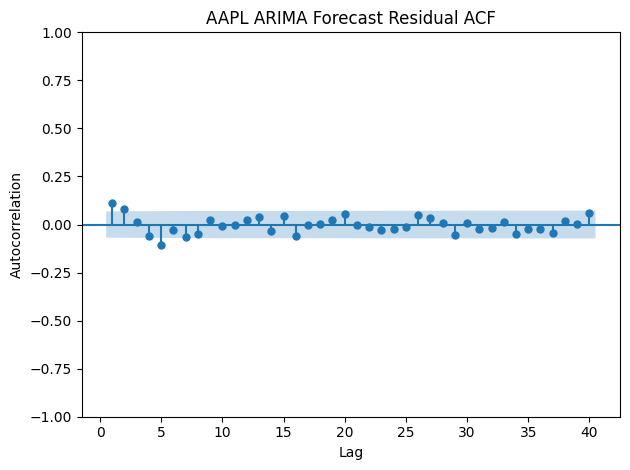


===== LJUNG-BOX TEST =====
      lb_stat  lb_pvalue
5   27.866805   0.000039
10  34.103361   0.000177
20  44.393075   0.001333
40  60.129480   0.021301


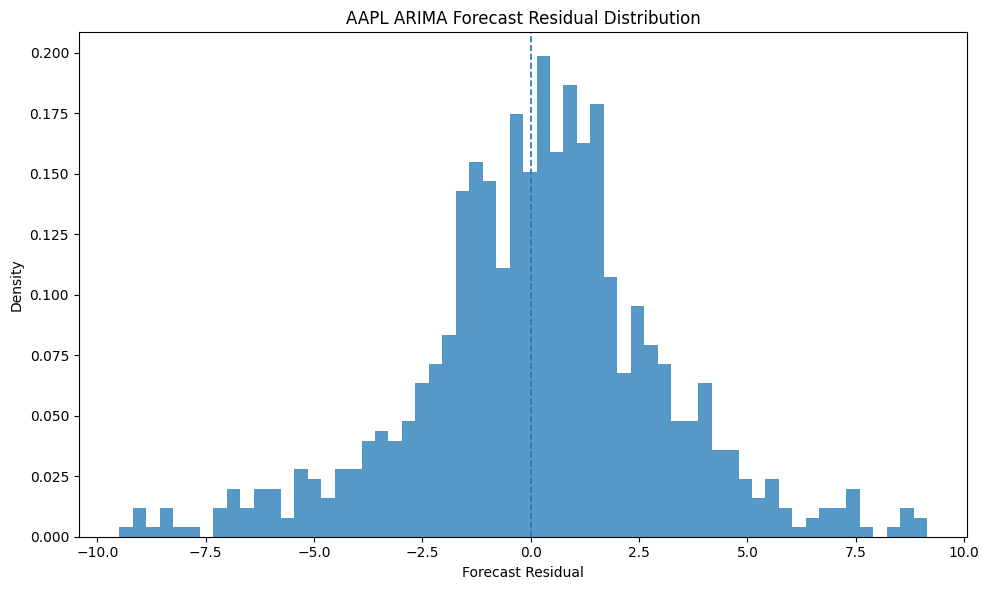

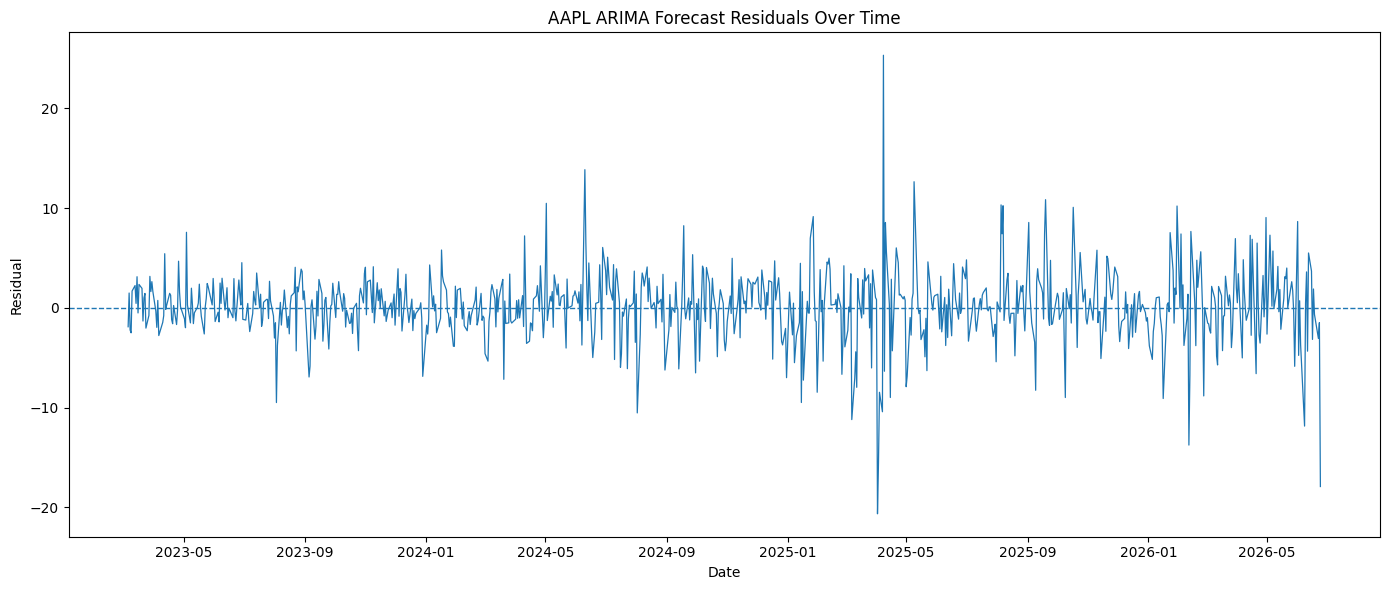


ARIMA RESIDUAL DIAGNOSTICS: MSFT
Residual observations: 829


<Figure size 1000x600 with 0 Axes>

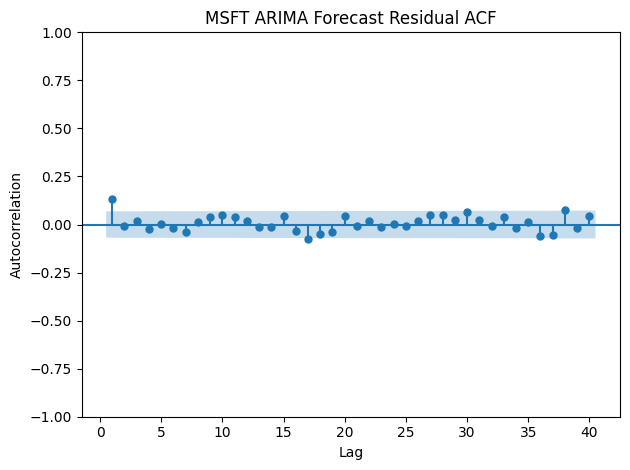


===== LJUNG-BOX TEST =====
      lb_stat  lb_pvalue
5   15.264917   0.009288
10  20.259722   0.026890
20  34.564978   0.022547
40  59.146594   0.026000


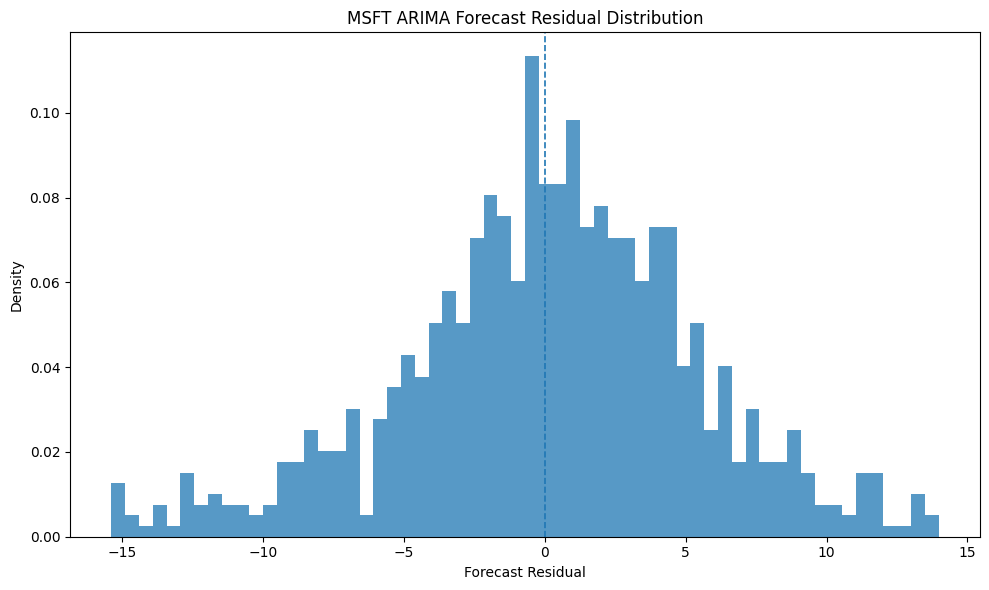

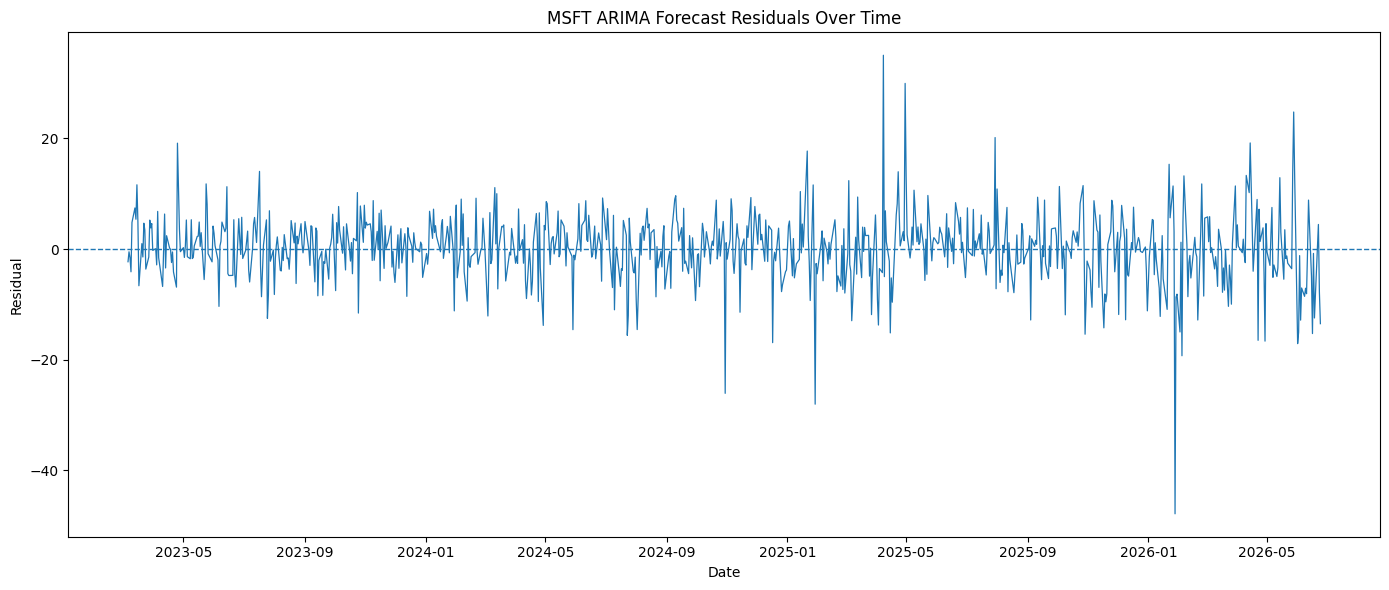


ARIMA RESIDUAL DIAGNOSTICS: NVDA
Residual observations: 829


<Figure size 1000x600 with 0 Axes>

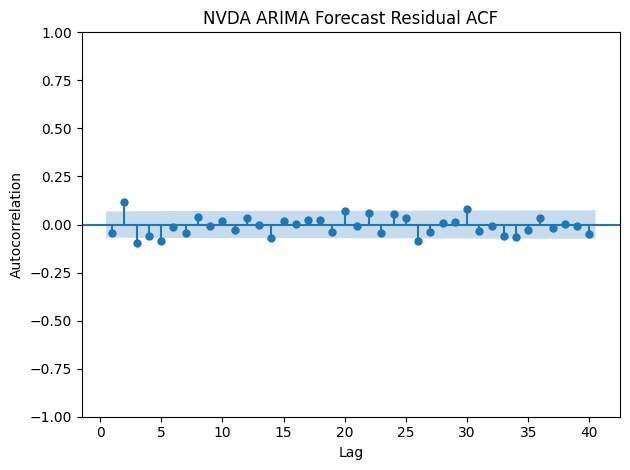


===== LJUNG-BOX TEST =====
      lb_stat  lb_pvalue
5   30.471196   0.000012
10  33.950998   0.000188
20  46.268186   0.000740
40  79.049039   0.000228


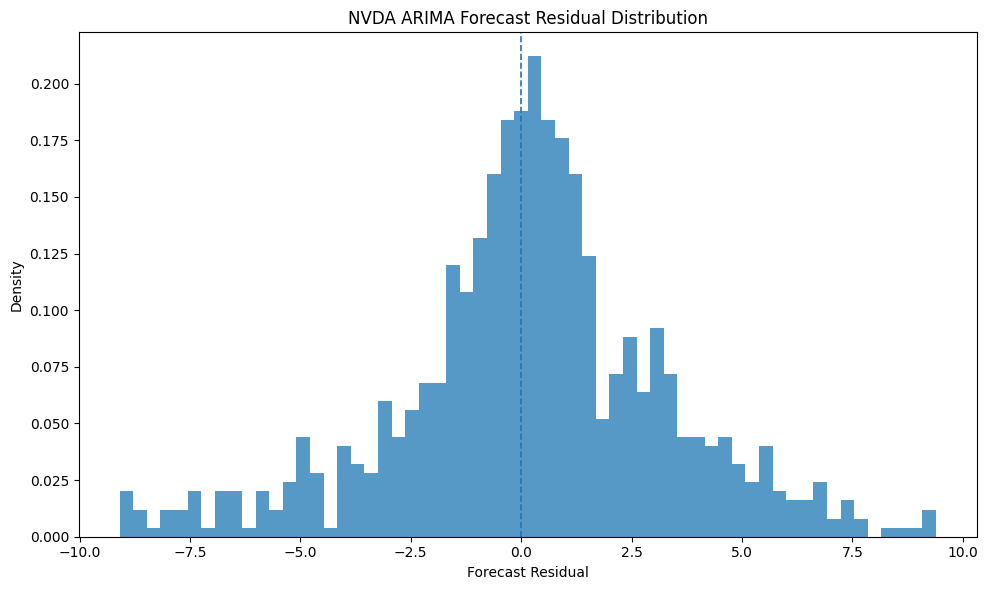

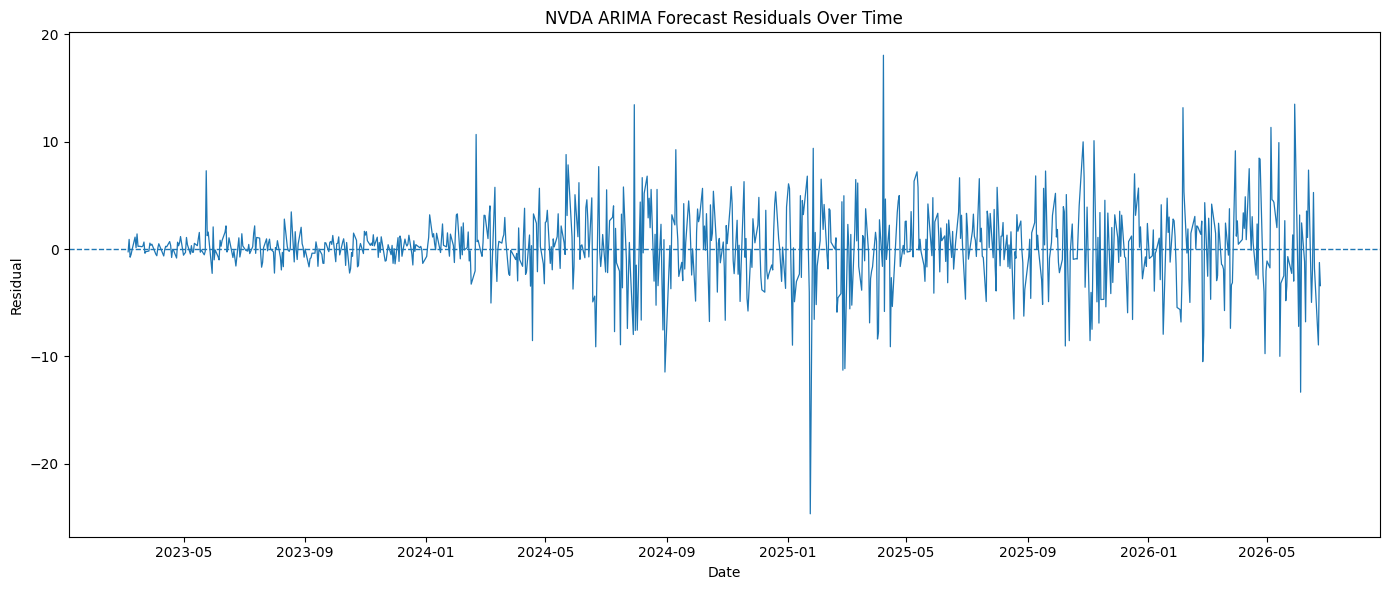


ARIMA RESIDUAL CHARACTERISTICS
Company  Observations  Mean Residual  Median Residual  Residual Std  Skewness  Excess Kurtosis  Minimum Residual  Maximum Residual
   AAPL           829       0.155723         0.282032      3.515629 -0.130750         6.699072        -20.649582         25.311027
   MSFT           829       0.134394         0.344962      6.281097 -0.462594         6.591659        -47.850194         35.036240
   NVDA           829       0.212951         0.268997      3.596389 -0.359043         4.542789        -24.660037         18.062695

ARIMA LJUNG-BOX RESULTS
Company  Lag  Ljung-Box Statistic  p-value                           Conclusion
   AAPL    5            27.866805 0.000039 Significant residual autocorrelation
   AAPL   10            34.103361 0.000177 Significant residual autocorrelation
   AAPL   20            44.393075 0.001333 Significant residual autocorrelation
   AAPL   40            60.129480 0.021301 Significant residual autocorrelation
   MSFT    5       

In [26]:
# ==========================================
# SECTION 24 — ARIMA RESIDUAL DIAGNOSTICS
# ACF + Ljung-Box + residual characteristics
#
# Purpose:
# Examine whether ARIMA forecast residuals still contain
# systematic temporal dependence that could be learned
# by a nonlinear model.
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats


# ==========================================================
# 24.1 — CONFIGURATION
# ==========================================================

RESIDUAL_ACF_LAGS = 40

LJUNG_BOX_LAGS = [
    5,
    10,
    20,
    40
]


# ==========================================================
# 24.2 — COLLECT ARIMA TEST RESIDUALS
#
# Uses prediction-level outputs created in SECTION 23:
#
# hybrid_prediction_store[company]
#
# ARIMA_Error =
# True_Next_Close - ARIMA_Prediction
# ==========================================================

residual_diagnostic_records = []

ljung_box_records = []

arima_residual_store = {}


for company in HYBRID_DATASETS.keys():

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"ARIMA RESIDUAL DIAGNOSTICS: {company}"
    )

    print(
        "=" * 70
    )

    prediction_df = (
        hybrid_prediction_store[
            company
        ]
        .copy()
    )

    residuals = (
        prediction_df[
            "ARIMA_Error"
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna()
        .astype(float)
        .reset_index(drop=True)
    )

    arima_residual_store[
        company
    ] = residuals

    print(
        "Residual observations:",
        len(residuals)
    )


    # ======================================================
    # 24.3 — RESIDUAL CHARACTERISTICS
    # ======================================================

    mean_residual = (
        residuals.mean()
    )

    std_residual = (
        residuals.std(
            ddof=1
        )
    )

    median_residual = (
        residuals.median()
    )

    skewness = (
        stats.skew(
            residuals,
            bias=False
        )
    )

    excess_kurtosis = (
        stats.kurtosis(
            residuals,
            fisher=True,
            bias=False
        )
    )

    residual_diagnostic_records.append({

        "Company":
            company,

        "Observations":
            len(residuals),

        "Mean Residual":
            mean_residual,

        "Median Residual":
            median_residual,

        "Residual Std":
            std_residual,

        "Skewness":
            skewness,

        "Excess Kurtosis":
            excess_kurtosis,

        "Minimum Residual":
            residuals.min(),

        "Maximum Residual":
            residuals.max()
    })


    # ======================================================
    # 24.4 — RESIDUAL ACF
    # ======================================================

    plt.figure(
        figsize=(10, 6)
    )

    plot_acf(
        residuals,
        lags=
            RESIDUAL_ACF_LAGS,
        zero=False,
        alpha=0.05
    )

    plt.title(
        f"{company} ARIMA Forecast Residual ACF"
    )

    plt.xlabel(
        "Lag"
    )

    plt.ylabel(
        "Autocorrelation"
    )

    plt.tight_layout()

    plt.savefig(
        f"{company}_arima_residual_acf.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # ======================================================
    # 24.5 — LJUNG-BOX TEST
    #
    # H0:
    # No serial correlation up to the selected lag.
    #
    # p > 0.05:
    # fail to reject H0
    # -> limited evidence of remaining autocorrelation
    #
    # p < 0.05:
    # reject H0
    # -> residual temporal structure remains
    # ======================================================

    ljung_box_result = (
        acorr_ljungbox(
            residuals,
            lags=
                LJUNG_BOX_LAGS,
            return_df=True
        )
    )

    print(
        "\n===== LJUNG-BOX TEST ====="
    )

    print(
        ljung_box_result
        .to_string()
    )


    for lag in LJUNG_BOX_LAGS:

        lb_stat = (
            ljung_box_result
            .loc[
                lag,
                "lb_stat"
            ]
        )

        lb_pvalue = (
            ljung_box_result
            .loc[
                lag,
                "lb_pvalue"
            ]
        )

        if (
            lb_pvalue
            < 0.05
        ):

            conclusion = (
                "Significant residual autocorrelation"
            )

        else:

            conclusion = (
                "No significant residual autocorrelation"
            )


        ljung_box_records.append({

            "Company":
                company,

            "Lag":
                lag,

            "Ljung-Box Statistic":
                lb_stat,

            "p-value":
                lb_pvalue,

            "Conclusion":
                conclusion
        })


    # ======================================================
    # 24.6 — RESIDUAL DISTRIBUTION
    # ======================================================

    lower = (
        residuals.quantile(
            0.01
        )
    )

    upper = (
        residuals.quantile(
            0.99
        )
    )

    display_residuals = (
        residuals[
            (
                residuals
                >= lower
            )
            &
            (
                residuals
                <= upper
            )
        ]
    )

    plt.figure(
        figsize=(10, 6)
    )

    plt.hist(
        display_residuals,
        bins=60,
        density=True,
        alpha=0.75
    )

    plt.axvline(
        x=0,
        linestyle="--",
        linewidth=1.2
    )

    plt.title(
        f"{company} ARIMA Forecast Residual Distribution"
    )

    plt.xlabel(
        "Forecast Residual"
    )

    plt.ylabel(
        "Density"
    )

    plt.tight_layout()

    plt.savefig(
        f"{company}_arima_residual_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # ======================================================
    # 24.7 — RESIDUAL OVER TIME
    # ======================================================

    residual_dates = (
        prediction_df[
            "Date"
        ]
        .iloc[
            :len(residuals)
        ]
    )

    plt.figure(
        figsize=(14, 6)
    )

    plt.plot(
        residual_dates,
        residuals,
        linewidth=0.9
    )

    plt.axhline(
        y=0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        f"{company} ARIMA Forecast Residuals Over Time"
    )

    plt.xlabel(
        "Date"
    )

    plt.ylabel(
        "Residual"
    )

    plt.tight_layout()

    plt.savefig(
        f"{company}_arima_residual_over_time.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ==========================================================
# 24.8 — SUMMARY TABLES
# ==========================================================

arima_residual_characteristics_df = (
    pd.DataFrame(
        residual_diagnostic_records
    )
)

arima_ljung_box_results_df = (
    pd.DataFrame(
        ljung_box_records
    )
)


print(
    "\n"
    + "=" * 70
)

print(
    "ARIMA RESIDUAL CHARACTERISTICS"
)

print(
    "=" * 70
)

print(
    arima_residual_characteristics_df
    .to_string(
        index=False
    )
)


print(
    "\n"
    + "=" * 70
)

print(
    "ARIMA LJUNG-BOX RESULTS"
)

print(
    "=" * 70
)

print(
    arima_ljung_box_results_df
    .to_string(
        index=False
    )
)


# ==========================================================
# 24.9 — COMPACT INTERPRETATION TABLE
# ==========================================================

residual_interpretation_records = []

for company in HYBRID_DATASETS.keys():

    company_lb = (
        arima_ljung_box_results_df[
            arima_ljung_box_results_df[
                "Company"
            ]
            == company
        ]
    )

    significant_count = (
        (
            company_lb[
                "p-value"
            ]
            < 0.05
        )
        .sum()
    )

    total_tests = (
        len(
            company_lb
        )
    )

    if (
        significant_count
        == 0
    ):

        overall_conclusion = (
            "Little evidence of remaining serial dependence"
        )

    elif (
        significant_count
        < total_tests
    ):

        overall_conclusion = (
            "Some residual serial dependence remains"
        )

    else:

        overall_conclusion = (
            "Strong evidence of remaining serial dependence"
        )


    residual_interpretation_records.append({

        "Company":
            company,

        "Significant Ljung-Box Tests":
            significant_count,

        "Total Ljung-Box Tests":
            total_tests,

        "Overall Interpretation":
            overall_conclusion
    })


arima_residual_interpretation_df = (
    pd.DataFrame(
        residual_interpretation_records
    )
)


print(
    "\n===== RESIDUAL INTERPRETATION ====="
)

print(
    arima_residual_interpretation_df
    .to_string(
        index=False
    )
)


# ==========================================================
# 24.10 — SAVE
# ==========================================================

arima_residual_characteristics_df.to_csv(
    "arima_residual_characteristics.csv",
    index=False
)

arima_ljung_box_results_df.to_csv(
    "arima_residual_ljung_box_results.csv",
    index=False
)

arima_residual_interpretation_df.to_csv(
    "arima_residual_interpretation.csv",
    index=False
)


print(
    "\nSaved:"
)

print(
    "arima_residual_characteristics.csv"
)

print(
    "arima_residual_ljung_box_results.csv"
)

print(
    "arima_residual_interpretation.csv"
)


RESIDUAL STRUCTURE ANALYSIS: AAPL
Residual observations: 829

===== RESIDUAL ACF =====
Lag 1: 0.110993
Lag 2: 0.079250
Lag 3: 0.011282
Lag 5: -0.104615
Lag 10: -0.005735
Lag 20: 0.054950
Lag 40: 0.057671

===== RESIDUAL PACF =====
Lag 1: 0.110993
Lag 2: 0.067765
Lag 3: -0.004516
Lag 5: -0.093725
Lag 10: -0.014631
Lag 20: 0.058049
Lag 40: 0.049587


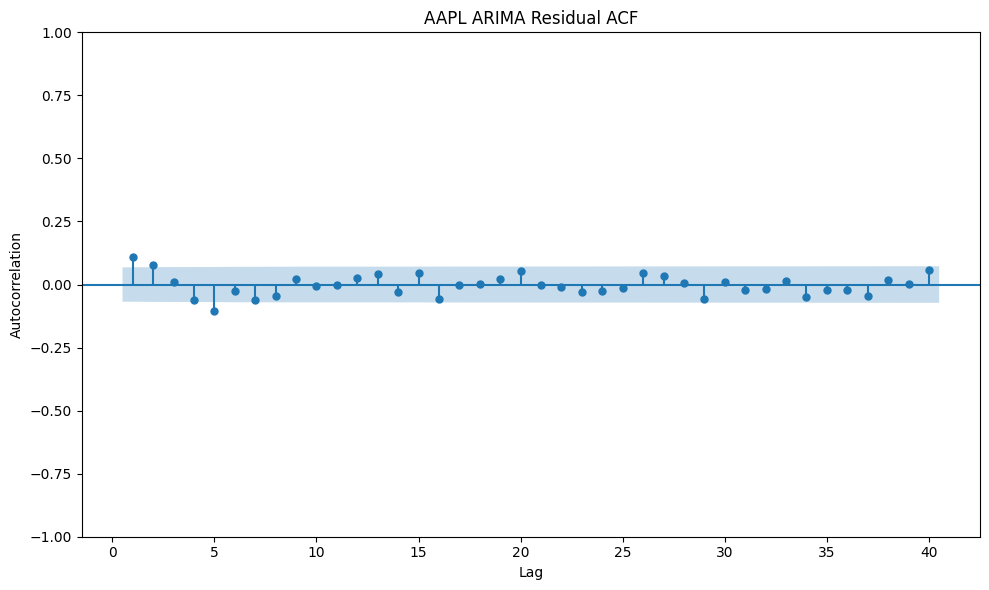

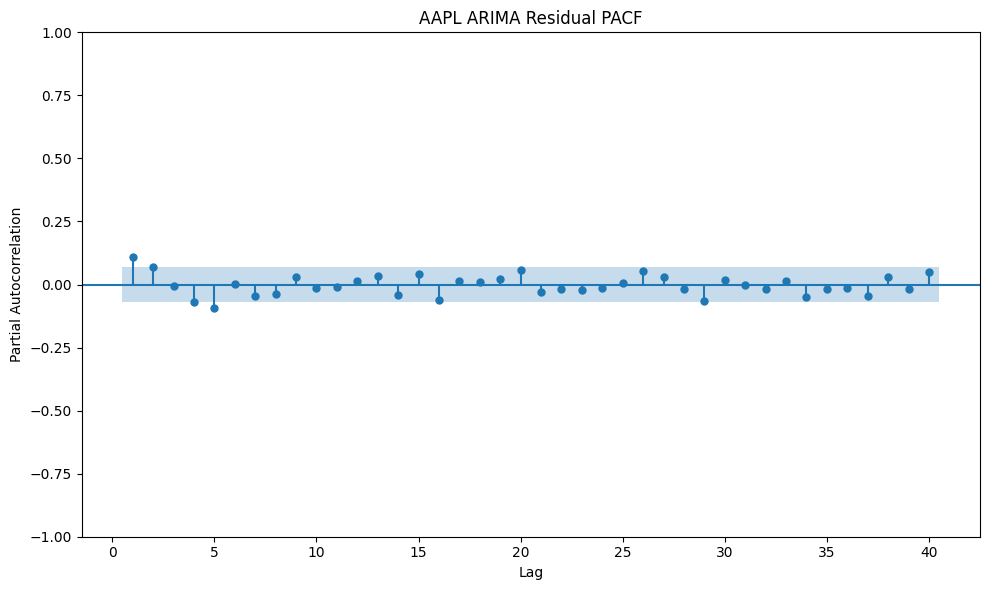


===== ARCH-LM TEST =====
Lag 5 | LM p-value: 0.000000 | Significant ARCH effect
Lag 10 | LM p-value: 0.000000 | Significant ARCH effect
Lag 20 | LM p-value: 0.000000 | Significant ARCH effect


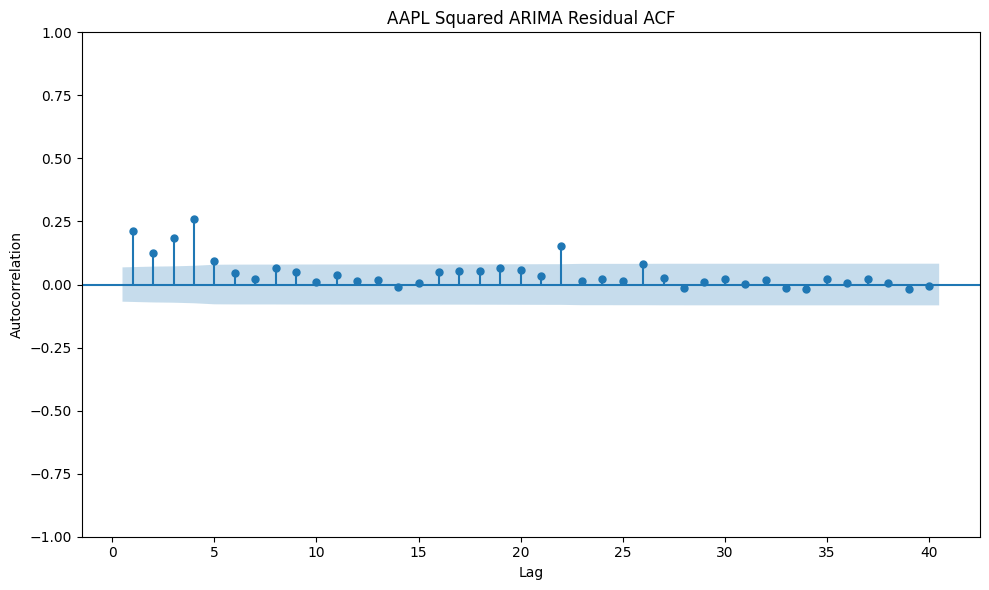


===== LJUNG-BOX ON SQUARED RESIDUALS =====
       lb_stat     lb_pvalue
5   143.947696  2.590002e-29
10  152.061492  1.403326e-27
20  167.586955  2.551245e-25
40  198.225722  7.733725e-23

RESIDUAL STRUCTURE ANALYSIS: MSFT
Residual observations: 829

===== RESIDUAL ACF =====
Lag 1: 0.131899
Lag 2: -0.009110
Lag 3: 0.020401
Lag 5: 0.003781
Lag 10: 0.051102
Lag 20: 0.045695
Lag 40: 0.043671

===== RESIDUAL PACF =====
Lag 1: 0.131899
Lag 2: -0.026976
Lag 3: 0.025658
Lag 5: 0.011424
Lag 10: 0.043806
Lag 20: 0.049799
Lag 40: 0.050618


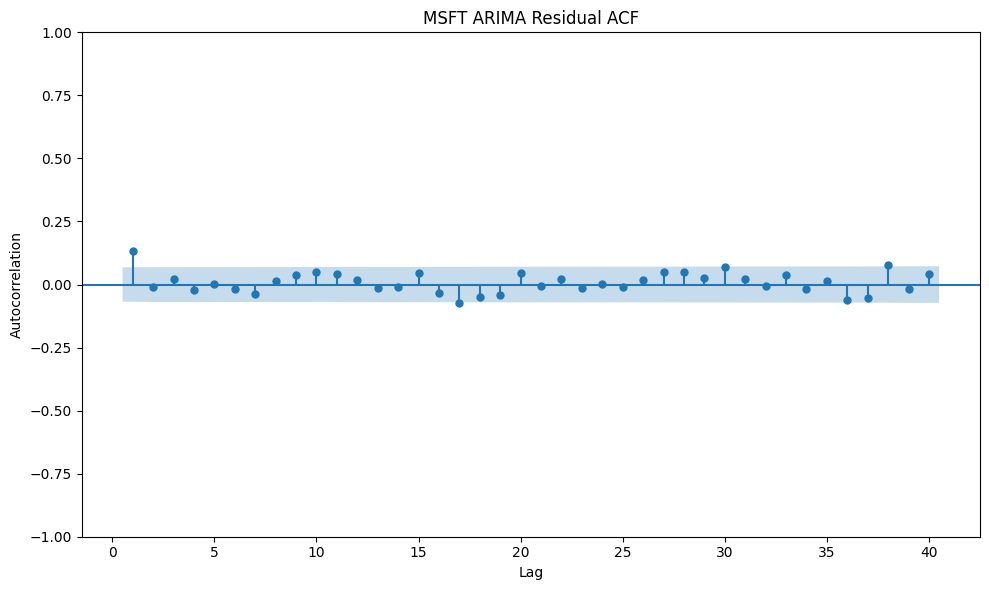

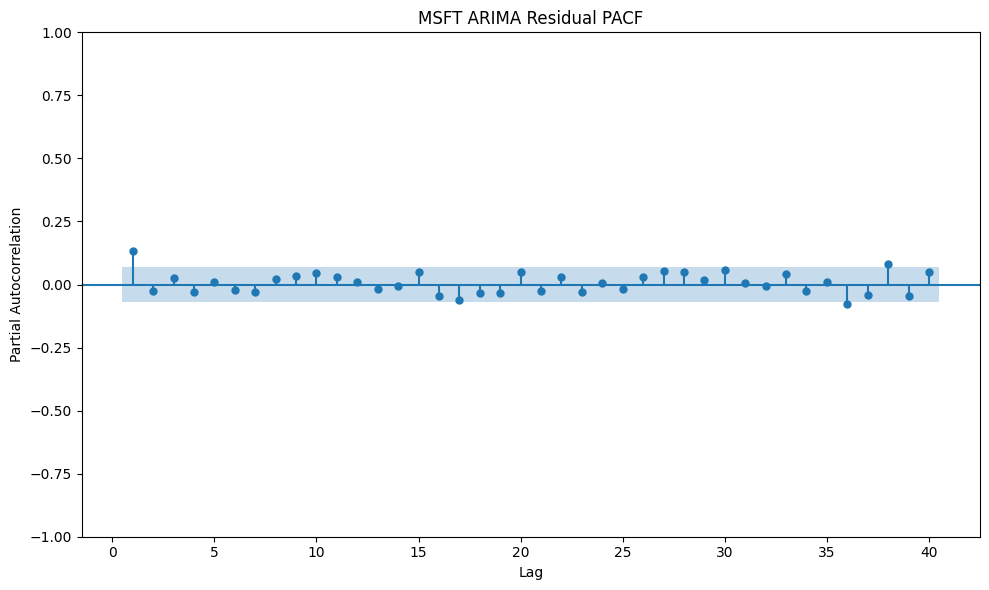


===== ARCH-LM TEST =====
Lag 5 | LM p-value: 0.004734 | Significant ARCH effect
Lag 10 | LM p-value: 0.034709 | Significant ARCH effect
Lag 20 | LM p-value: 0.033580 | Significant ARCH effect


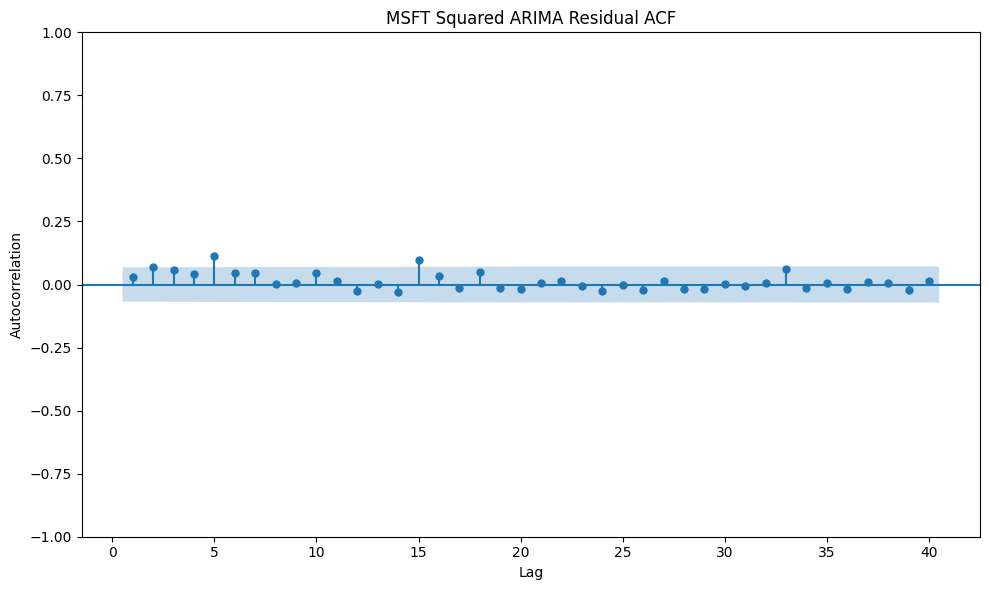


===== LJUNG-BOX ON SQUARED RESIDUALS =====
      lb_stat  lb_pvalue
5   19.626643   0.001468
10  25.008464   0.005329
20  38.425756   0.007852
40  44.594016   0.284637

RESIDUAL STRUCTURE ANALYSIS: NVDA
Residual observations: 829

===== RESIDUAL ACF =====
Lag 1: -0.044317
Lag 2: 0.118564
Lag 3: -0.097910
Lag 5: -0.084752
Lag 10: 0.019365
Lag 20: 0.070625
Lag 40: -0.047903

===== RESIDUAL PACF =====
Lag 1: -0.044317
Lag 2: 0.116829
Lag 3: -0.089486
Lag 5: -0.069858
Lag 10: -0.003659
Lag 20: 0.069127
Lag 40: -0.081561


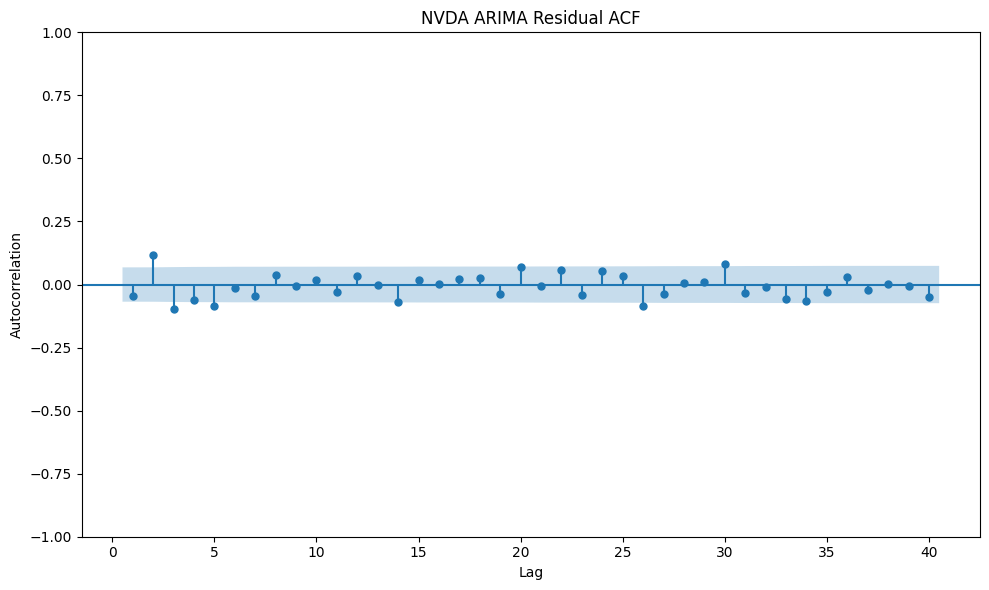

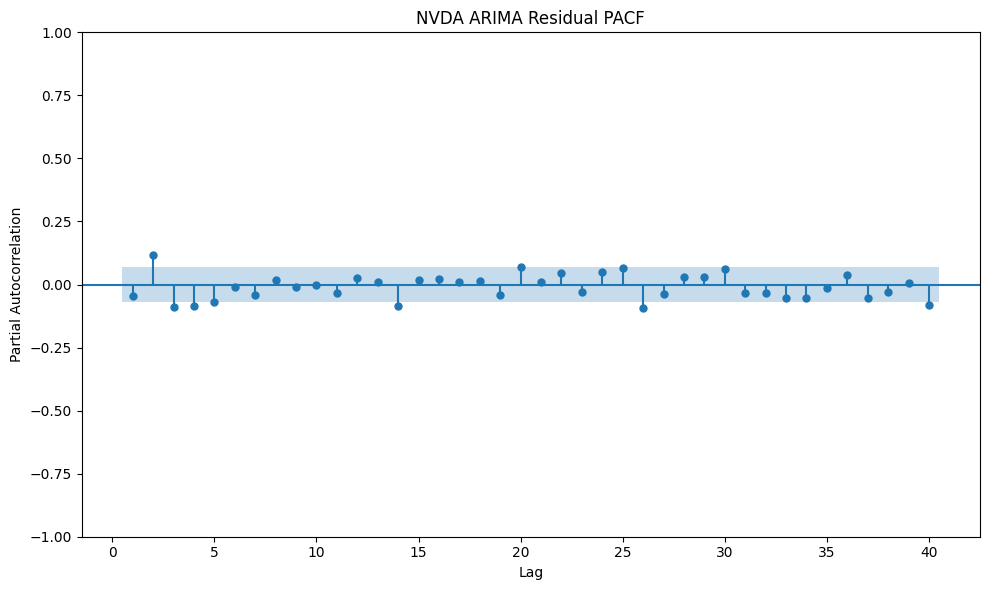


===== ARCH-LM TEST =====
Lag 5 | LM p-value: 0.000018 | Significant ARCH effect
Lag 10 | LM p-value: 0.000065 | Significant ARCH effect
Lag 20 | LM p-value: 0.002762 | Significant ARCH effect


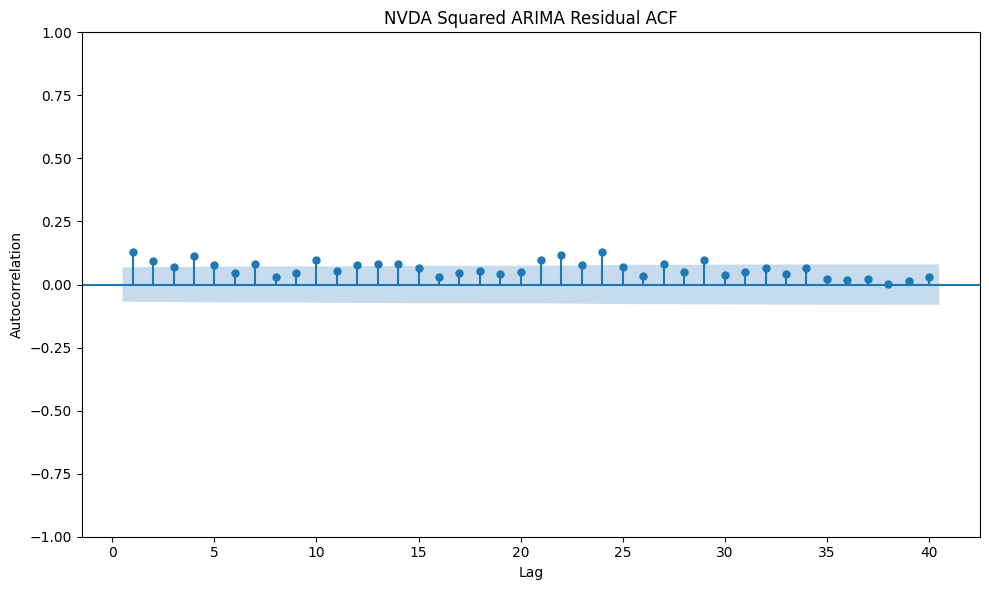


===== LJUNG-BOX ON SQUARED RESIDUALS =====
       lb_stat     lb_pvalue
5    41.168332  8.676039e-08
10   58.253431  7.744912e-09
20   88.934993  1.137482e-10
40  163.835586  6.386340e-17

RESIDUAL ACF SUMMARY
Company  Lag       ACF
   AAPL    1  0.110993
   AAPL    2  0.079250
   AAPL    3  0.011282
   AAPL    5 -0.104615
   AAPL   10 -0.005735
   AAPL   20  0.054950
   AAPL   40  0.057671
   MSFT    1  0.131899
   MSFT    2 -0.009110
   MSFT    3  0.020401
   MSFT    5  0.003781
   MSFT   10  0.051102
   MSFT   20  0.045695
   MSFT   40  0.043671
   NVDA    1 -0.044317
   NVDA    2  0.118564
   NVDA    3 -0.097910
   NVDA    5 -0.084752
   NVDA   10  0.019365
   NVDA   20  0.070625
   NVDA   40 -0.047903

RESIDUAL PACF SUMMARY
Company  Lag      PACF
   AAPL    1  0.110993
   AAPL    2  0.067765
   AAPL    3 -0.004516
   AAPL    5 -0.093725
   AAPL   10 -0.014631
   AAPL   20  0.058049
   AAPL   40  0.049587
   MSFT    1  0.131899
   MSFT    2 -0.026976
   MSFT    3  0.025658
   MSFT

In [27]:
# ==========================================
# SECTION 25 — ARIMA RESIDUAL STRUCTURE ANALYSIS
# ACF/PACF + ARCH-LM + Squared-Residual Diagnostics
#
# Purpose:
# Identify what type of structure remains in ARIMA residuals.
#
# Questions:
# 1. Which lags show the strongest residual autocorrelation?
# 2. Does volatility clustering / ARCH effect remain?
# 3. Is the remaining structure mainly in the mean,
#    the variance, or both?
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox


# ==========================================================
# 25.1 — CONFIGURATION
# ==========================================================

MAX_RESIDUAL_LAG = 40

SELECTED_LAGS = [
    1,
    2,
    3,
    5,
    10,
    20,
    40
]

ARCH_LAGS = [
    5,
    10,
    20
]


# ==========================================================
# 25.2 — STORAGE
# ==========================================================

residual_acf_records = []

residual_pacf_records = []

arch_test_records = []

squared_residual_ljungbox_records = []

residual_structure_summary_records = []


# ==========================================================
# 25.3 — RUN ANALYSIS FOR EACH COMPANY
# ==========================================================

for company in HYBRID_DATASETS.keys():

    print(
        "\n"
        + "=" * 72
    )

    print(
        f"RESIDUAL STRUCTURE ANALYSIS: {company}"
    )

    print(
        "=" * 72
    )

    residuals = (
        arima_residual_store[
            company
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna()
        .astype(float)
        .reset_index(drop=True)
    )

    print(
        "Residual observations:",
        len(residuals)
    )


    # ======================================================
    # 25.4 — RESIDUAL ACF NUMERICAL VALUES
    # ======================================================

    residual_acf_values = acf(
        residuals,
        nlags=MAX_RESIDUAL_LAG,
        fft=True
    )

    print(
        "\n===== RESIDUAL ACF ====="
    )

    for lag in SELECTED_LAGS:

        value = (
            residual_acf_values[
                lag
            ]
        )

        print(
            f"Lag {lag}: "
            f"{value:.6f}"
        )

        residual_acf_records.append({

            "Company":
                company,

            "Lag":
                lag,

            "ACF":
                value
        })


    # ======================================================
    # 25.5 — RESIDUAL PACF NUMERICAL VALUES
    # ======================================================

    residual_pacf_values = pacf(
        residuals,
        nlags=MAX_RESIDUAL_LAG,
        method="ywm"
    )

    print(
        "\n===== RESIDUAL PACF ====="
    )

    for lag in SELECTED_LAGS:

        value = (
            residual_pacf_values[
                lag
            ]
        )

        print(
            f"Lag {lag}: "
            f"{value:.6f}"
        )

        residual_pacf_records.append({

            "Company":
                company,

            "Lag":
                lag,

            "PACF":
                value
        })


    # ======================================================
    # 25.6 — ACF PLOT
    # ======================================================

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    plot_acf(
        residuals,
        lags=MAX_RESIDUAL_LAG,
        zero=False,
        alpha=0.05,
        ax=ax
    )

    ax.set_title(
        f"{company} ARIMA Residual ACF"
    )

    ax.set_xlabel(
        "Lag"
    )

    ax.set_ylabel(
        "Autocorrelation"
    )

    fig.tight_layout()

    fig.savefig(
        f"{company}_arima_residual_acf_section25.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # ======================================================
    # 25.7 — PACF PLOT
    # ======================================================

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    plot_pacf(
        residuals,
        lags=MAX_RESIDUAL_LAG,
        zero=False,
        alpha=0.05,
        method="ywm",
        ax=ax
    )

    ax.set_title(
        f"{company} ARIMA Residual PACF"
    )

    ax.set_xlabel(
        "Lag"
    )

    ax.set_ylabel(
        "Partial Autocorrelation"
    )

    fig.tight_layout()

    fig.savefig(
        f"{company}_arima_residual_pacf.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # ======================================================
    # 25.8 — ARCH-LM TEST
    #
    # H0:
    # No ARCH effect.
    #
    # p < 0.05:
    # Significant conditional heteroskedasticity.
    # ======================================================

    print(
        "\n===== ARCH-LM TEST ====="
    )

    company_arch_significant = 0

    for lag in ARCH_LAGS:

        arch_result = het_arch(
            residuals,
            nlags=lag
        )

        lm_stat = (
            arch_result[0]
        )

        lm_pvalue = (
            arch_result[1]
        )

        f_stat = (
            arch_result[2]
        )

        f_pvalue = (
            arch_result[3]
        )

        if (
            lm_pvalue < 0.05
        ):

            conclusion = (
                "Significant ARCH effect"
            )

            company_arch_significant += 1

        else:

            conclusion = (
                "No significant ARCH effect"
            )

        print(
            f"Lag {lag} | "
            f"LM p-value: "
            f"{lm_pvalue:.6f} | "
            f"{conclusion}"
        )

        arch_test_records.append({

            "Company":
                company,

            "Lag":
                lag,

            "LM Statistic":
                lm_stat,

            "LM p-value":
                lm_pvalue,

            "F Statistic":
                f_stat,

            "F p-value":
                f_pvalue,

            "Conclusion":
                conclusion
        })


    # ======================================================
    # 25.9 — SQUARED RESIDUALS
    #
    # If squared residuals are autocorrelated,
    # volatility clustering may remain.
    # ======================================================

    squared_residuals = (
        residuals ** 2
    )

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    plot_acf(
        squared_residuals,
        lags=MAX_RESIDUAL_LAG,
        zero=False,
        alpha=0.05,
        ax=ax
    )

    ax.set_title(
        f"{company} Squared ARIMA Residual ACF"
    )

    ax.set_xlabel(
        "Lag"
    )

    ax.set_ylabel(
        "Autocorrelation"
    )

    fig.tight_layout()

    fig.savefig(
        f"{company}_squared_arima_residual_acf.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # ======================================================
    # 25.10 — LJUNG-BOX ON SQUARED RESIDUALS
    # ======================================================

    squared_lb = (
        acorr_ljungbox(
            squared_residuals,
            lags=[
                5,
                10,
                20,
                40
            ],
            return_df=True
        )
    )

    print(
        "\n===== LJUNG-BOX ON SQUARED RESIDUALS ====="
    )

    print(
        squared_lb.to_string()
    )

    squared_significant_count = 0

    for lag in [
        5,
        10,
        20,
        40
    ]:

        stat = (
            squared_lb.loc[
                lag,
                "lb_stat"
            ]
        )

        pvalue = (
            squared_lb.loc[
                lag,
                "lb_pvalue"
            ]
        )

        if (
            pvalue < 0.05
        ):

            conclusion = (
                "Significant squared-residual autocorrelation"
            )

            squared_significant_count += 1

        else:

            conclusion = (
                "No significant squared-residual autocorrelation"
            )

        squared_residual_ljungbox_records.append({

            "Company":
                company,

            "Lag":
                lag,

            "Ljung-Box Statistic":
                stat,

            "p-value":
                pvalue,

            "Conclusion":
                conclusion
        })


    # ======================================================
    # 25.11 — AUTOMATIC STRUCTURE INTERPRETATION
    # ======================================================

    mean_dependence = (
        arima_ljung_box_results_df[
            (
                arima_ljung_box_results_df[
                    "Company"
                ]
                == company
            )
            &
            (
                arima_ljung_box_results_df[
                    "p-value"
                ]
                < 0.05
            )
        ]
        .shape[0]
    )

    variance_dependence = (
        squared_significant_count
    )

    if (
        mean_dependence > 0
        and variance_dependence > 0
    ):

        structure_type = (
            "Dependence remains in both mean and variance"
        )

    elif (
        mean_dependence > 0
        and variance_dependence == 0
    ):

        structure_type = (
            "Dependence mainly remains in conditional mean"
        )

    elif (
        mean_dependence == 0
        and variance_dependence > 0
    ):

        structure_type = (
            "Dependence mainly remains in conditional variance"
        )

    else:

        structure_type = (
            "Little remaining serial structure"
        )

    residual_structure_summary_records.append({

        "Company":
            company,

        "Significant Residual Ljung-Box Tests":
            mean_dependence,

        "Significant ARCH Tests":
            company_arch_significant,

        "Significant Squared-Residual Ljung-Box Tests":
            variance_dependence,

        "Overall Structure":
            structure_type
    })


# ==========================================================
# 25.12 — CREATE RESULT TABLES
# ==========================================================

residual_acf_summary_df = (
    pd.DataFrame(
        residual_acf_records
    )
)

residual_pacf_summary_df = (
    pd.DataFrame(
        residual_pacf_records
    )
)

arch_test_results_df = (
    pd.DataFrame(
        arch_test_records
    )
)

squared_residual_ljungbox_df = (
    pd.DataFrame(
        squared_residual_ljungbox_records
    )
)

residual_structure_summary_df = (
    pd.DataFrame(
        residual_structure_summary_records
    )
)


# ==========================================================
# 25.13 — PRINT FINAL TABLES
# ==========================================================

print(
    "\n"
    + "=" * 72
)

print(
    "RESIDUAL ACF SUMMARY"
)

print(
    "=" * 72
)

print(
    residual_acf_summary_df
    .to_string(
        index=False
    )
)


print(
    "\n"
    + "=" * 72
)

print(
    "RESIDUAL PACF SUMMARY"
)

print(
    "=" * 72
)

print(
    residual_pacf_summary_df
    .to_string(
        index=False
    )
)


print(
    "\n"
    + "=" * 72
)

print(
    "ARCH-LM RESULTS"
)

print(
    "=" * 72
)

print(
    arch_test_results_df
    .to_string(
        index=False
    )
)


print(
    "\n"
    + "=" * 72
)

print(
    "SQUARED-RESIDUAL LJUNG-BOX RESULTS"
)

print(
    "=" * 72
)

print(
    squared_residual_ljungbox_df
    .to_string(
        index=False
    )
)


print(
    "\n"
    + "=" * 72
)

print(
    "FINAL RESIDUAL STRUCTURE SUMMARY"
)

print(
    "=" * 72
)

print(
    residual_structure_summary_df
    .to_string(
        index=False
    )
)


# ==========================================================
# 25.14 — SAVE RESULTS
# ==========================================================

residual_acf_summary_df.to_csv(
    "arima_residual_acf_summary.csv",
    index=False
)

residual_pacf_summary_df.to_csv(
    "arima_residual_pacf_summary.csv",
    index=False
)

arch_test_results_df.to_csv(
    "arima_residual_arch_lm_results.csv",
    index=False
)

squared_residual_ljungbox_df.to_csv(
    "arima_squared_residual_ljungbox_results.csv",
    index=False
)

residual_structure_summary_df.to_csv(
    "arima_residual_structure_summary.csv",
    index=False
)


print(
    "\nSaved:"
)

print(
    "arima_residual_acf_summary.csv"
)

print(
    "arima_residual_pacf_summary.csv"
)

print(
    "arima_residual_arch_lm_results.csv"
)

print(
    "arima_squared_residual_ljungbox_results.csv"
)

print(
    "arima_residual_structure_summary.csv"
)

ARIMA-GARCH datasets: {'AAPL': 'AAPL_mid_clean.csv', 'MSFT': 'MSFT_mid_clean.csv', 'NVDA': 'NVDA_mid_clean.csv'}
ARIMA order: (5, 1, 0)
GARCH order: (1, 1)
GARCH innovation distribution: t

ARIMA-GARCH ANALYSIS: AAPL
Total rows: 4144
Training rows: 3315
Test rows: 829
Train period: 2010-01-04 00:00:00 to 2023-03-06 00:00:00
Test period: 2023-03-07 00:00:00 to 2026-06-25 00:00:00

Fitting ARIMA...
Usable ARIMA training residuals: 3295

Fitting Student-t GARCH(1,1)...
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2919.10
Distribution:      Standardized Student's t   AIC:                           5846.20
Method:                  Maximum Likelihood   BIC:                           5870.60
                   

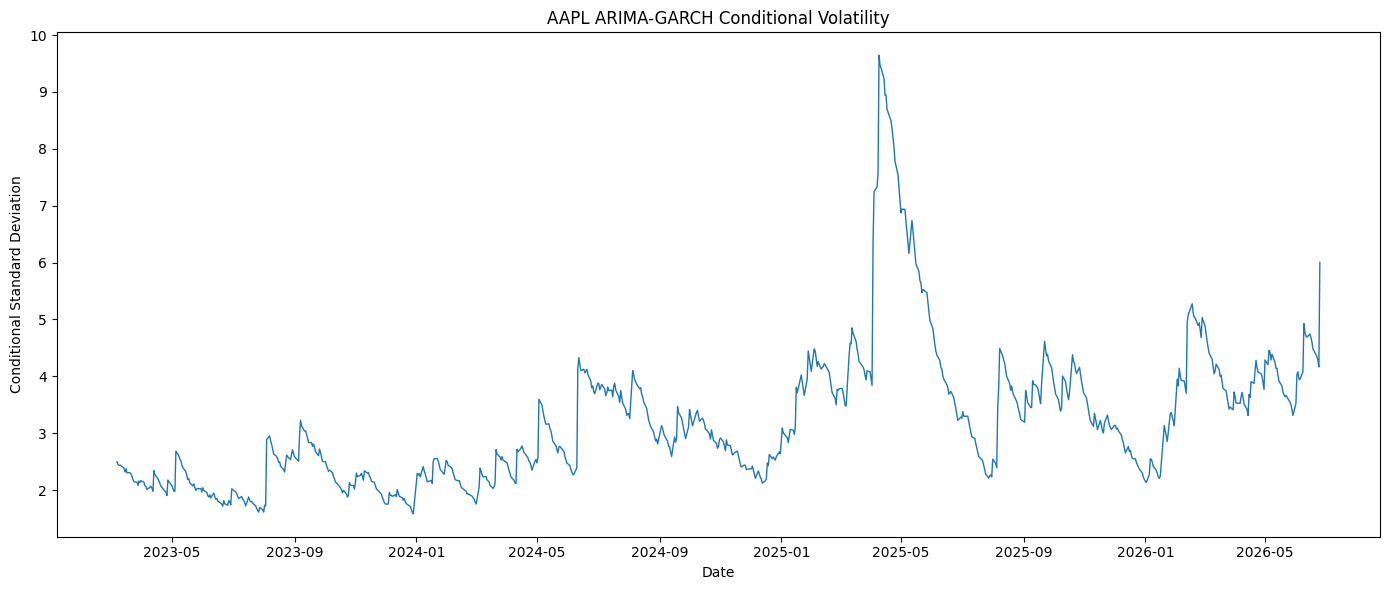

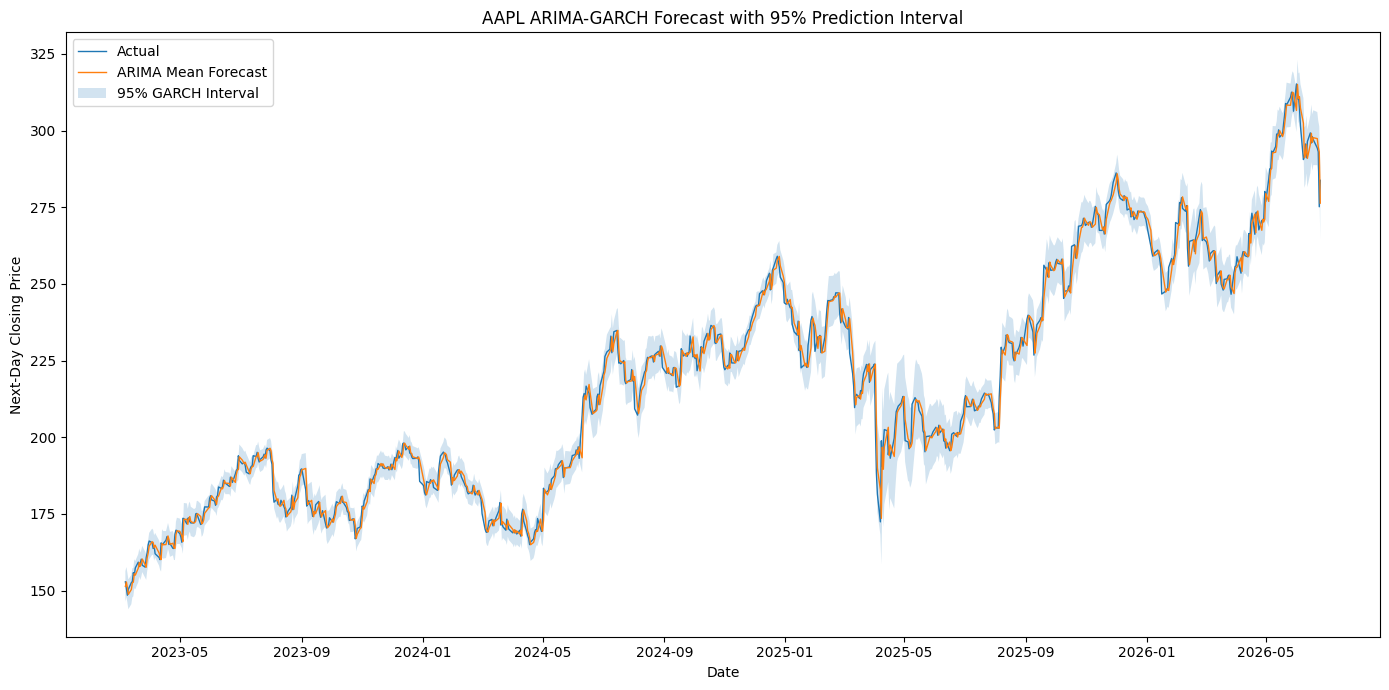

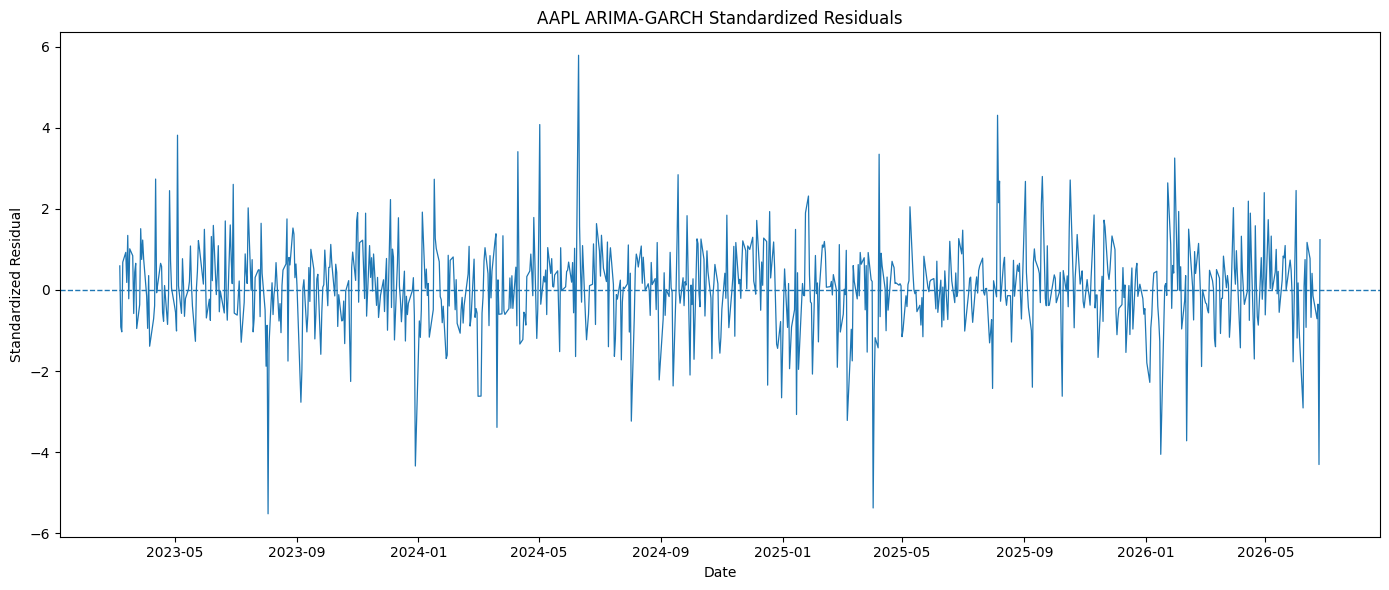

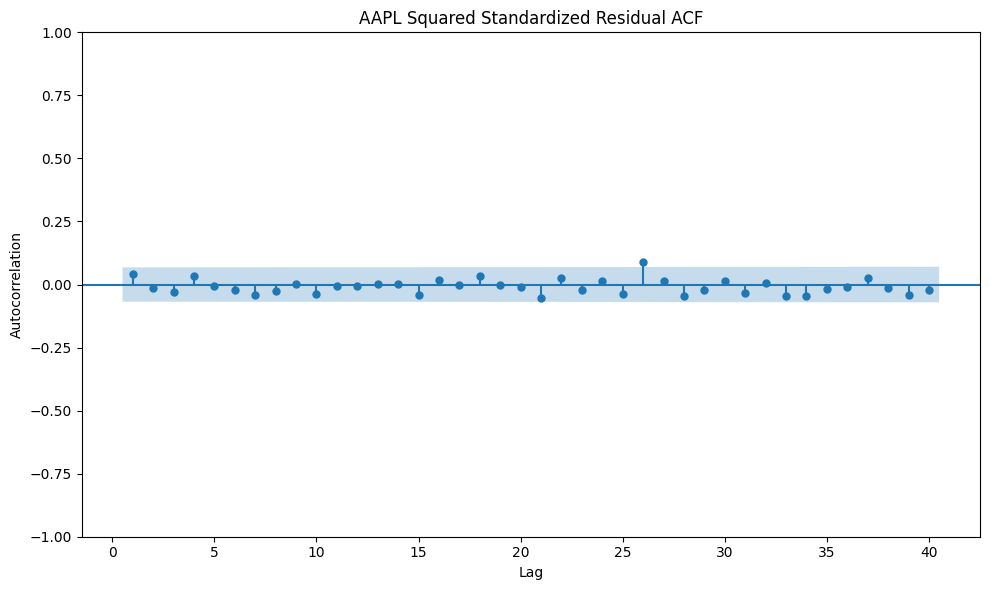


------------------------------------------------------------
AAPL ARIMA-GARCH RESULTS
------------------------------------------------------------
Point forecast MAPE: 1.117 %
Point forecast RMSE: 3.5268
95% interval coverage: 93.61 %
Average interval width: 12.7941
ARCH tests still significant: 0 / 3
Squared standardized Ljung-Box tests still significant: 0 / 4
Conclusion: GARCH successfully removed detectable conditional variance dependence

ARIMA-GARCH ANALYSIS: MSFT
Total rows: 4144
Training rows: 3315
Test rows: 829
Train period: 2010-01-04 00:00:00 to 2023-03-06 00:00:00
Test period: 2023-03-07 00:00:00 to 2026-06-25 00:00:00

Fitting ARIMA...
Usable ARIMA training residuals: 3295

Fitting Student-t GARCH(1,1)...
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:     

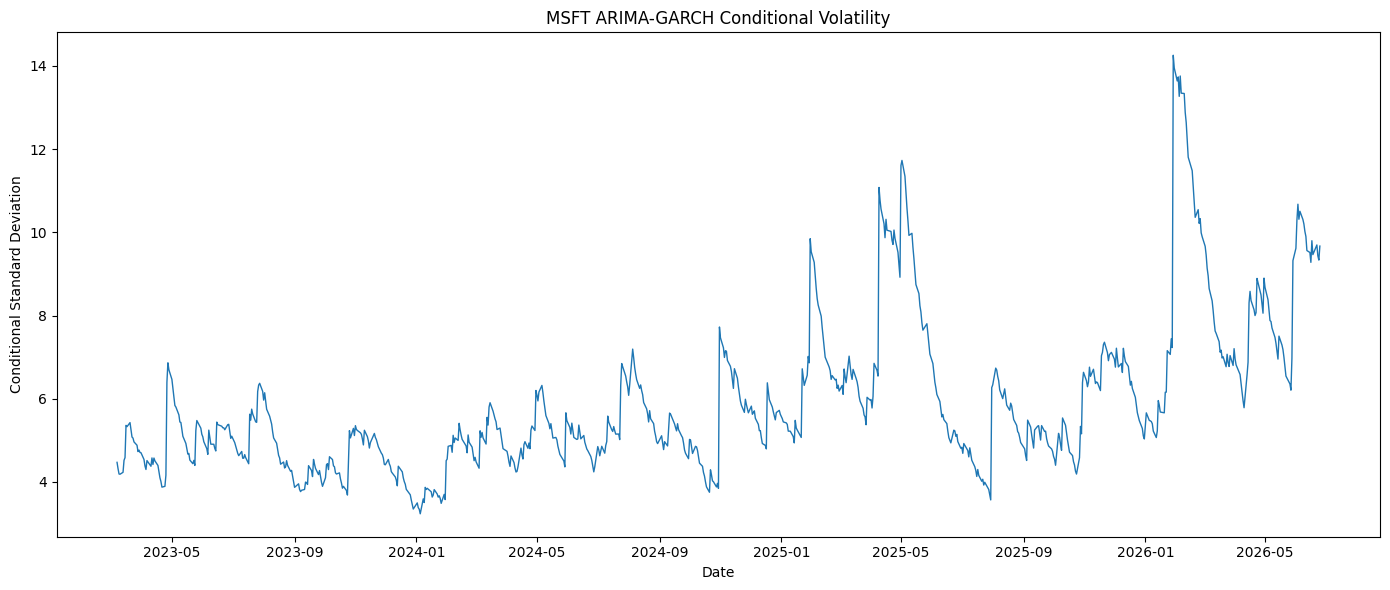

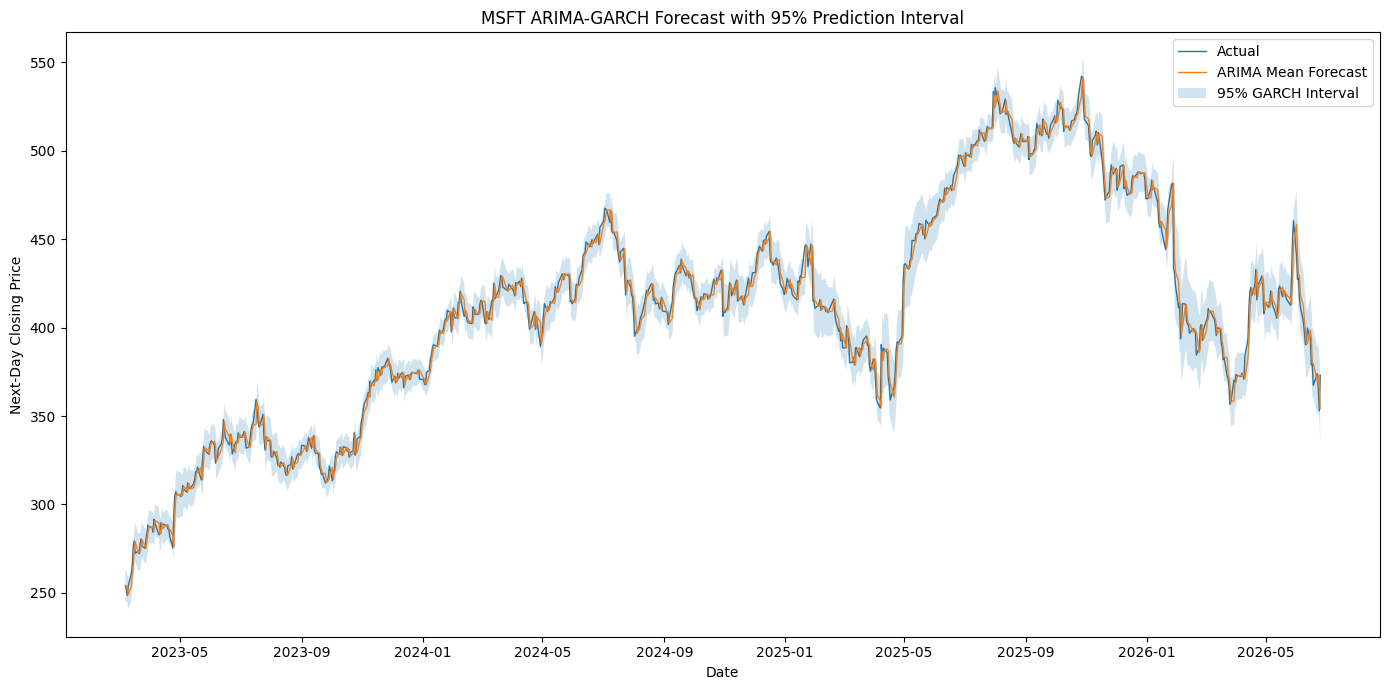

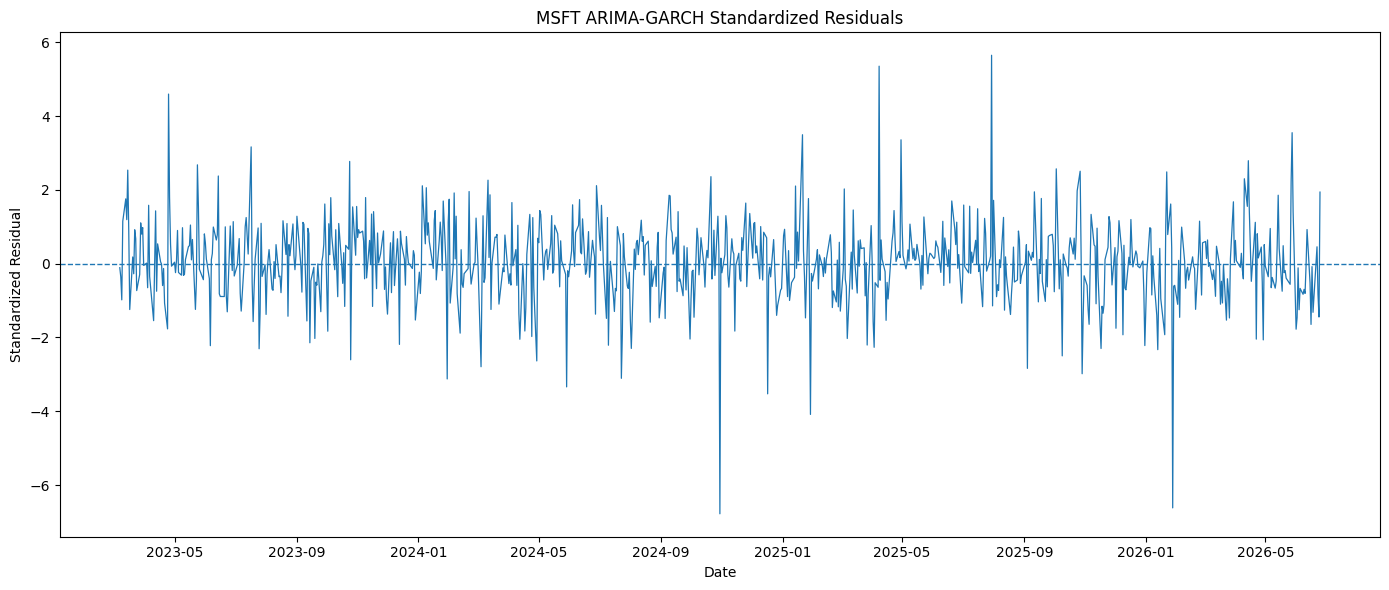

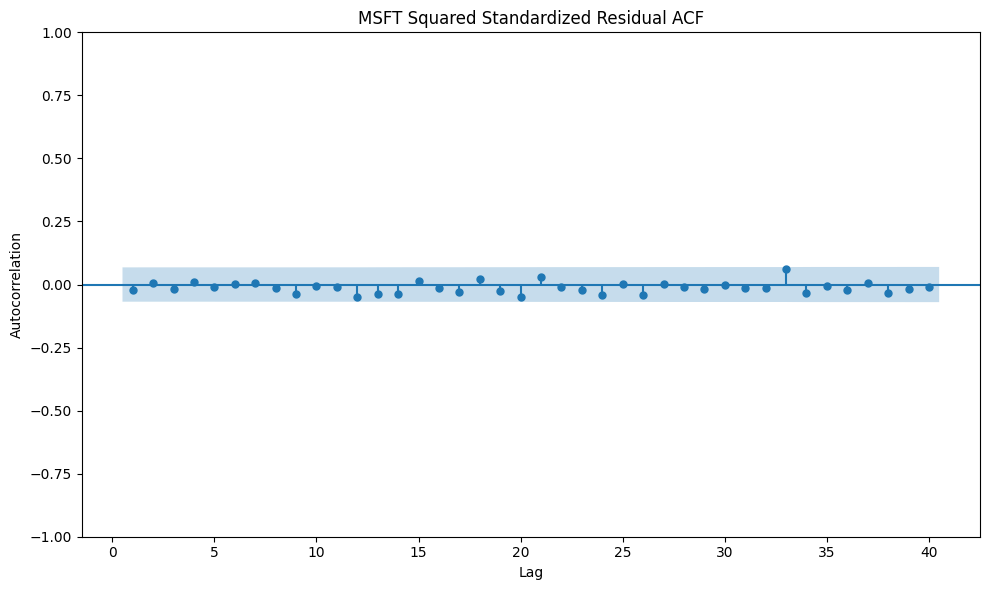


------------------------------------------------------------
MSFT ARIMA-GARCH RESULTS
------------------------------------------------------------
Point forecast MAPE: 1.1121 %
Point forecast RMSE: 6.3122
95% interval coverage: 93.49 %
Average interval width: 23.4972
ARCH tests still significant: 0 / 3
Squared standardized Ljung-Box tests still significant: 0 / 4
Conclusion: GARCH successfully removed detectable conditional variance dependence

ARIMA-GARCH ANALYSIS: NVDA
Total rows: 4144
Training rows: 3315
Test rows: 829
Train period: 2010-01-04 00:00:00 to 2023-03-06 00:00:00
Test period: 2023-03-07 00:00:00 to 2026-06-25 00:00:00

Fitting ARIMA...
Usable ARIMA training residuals: 3295

Fitting Student-t GARCH(1,1)...
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:    

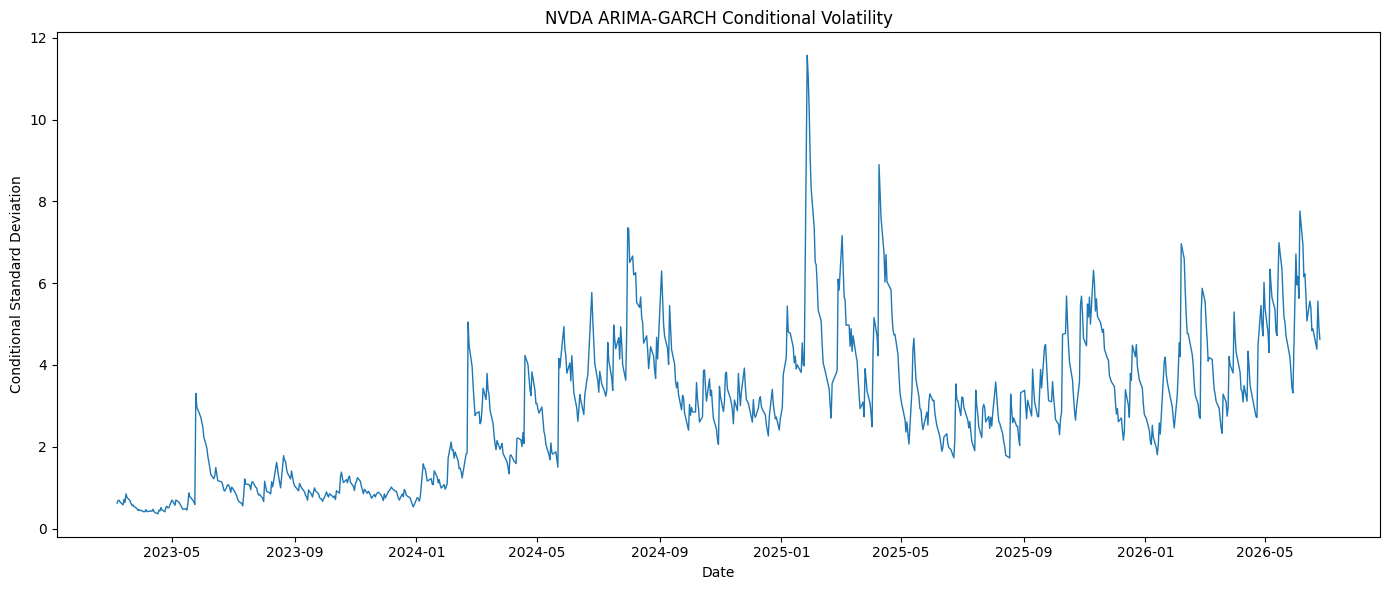

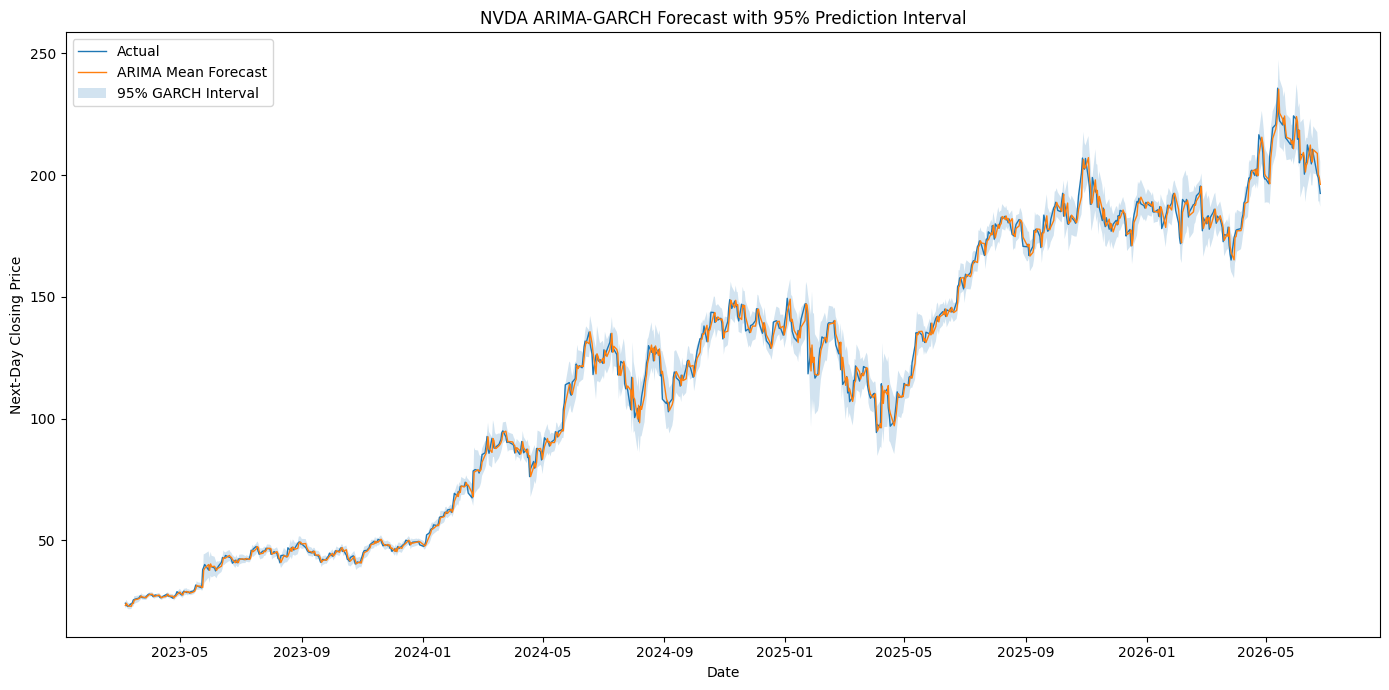

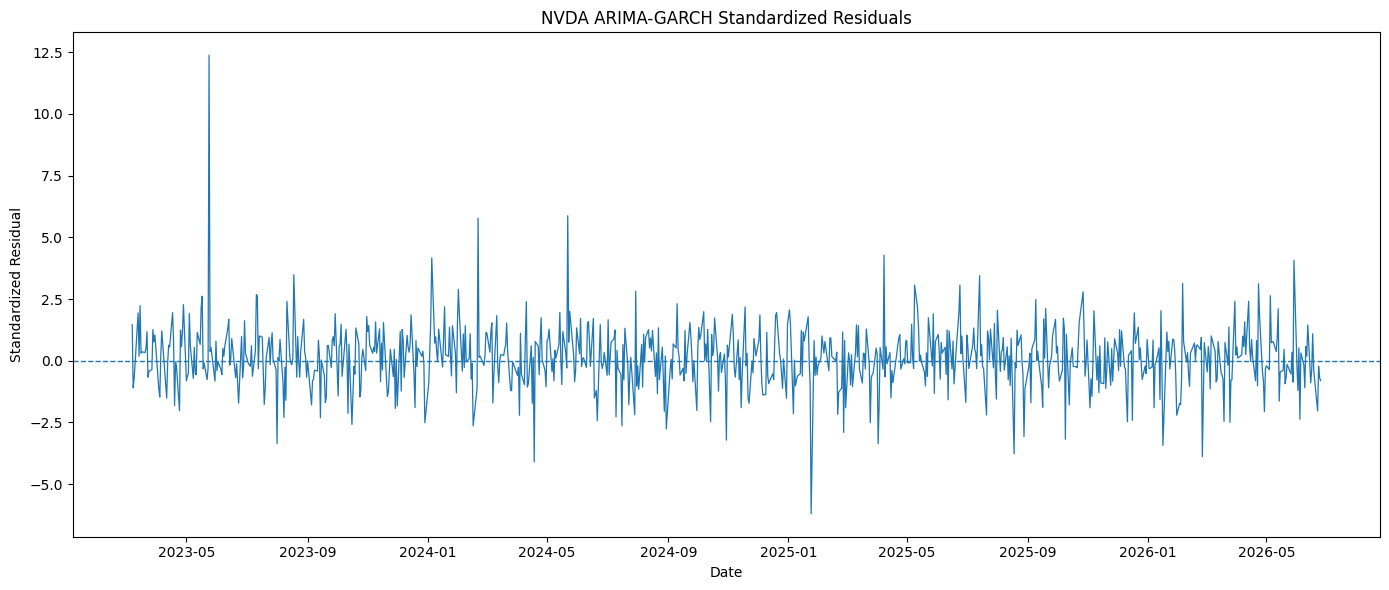

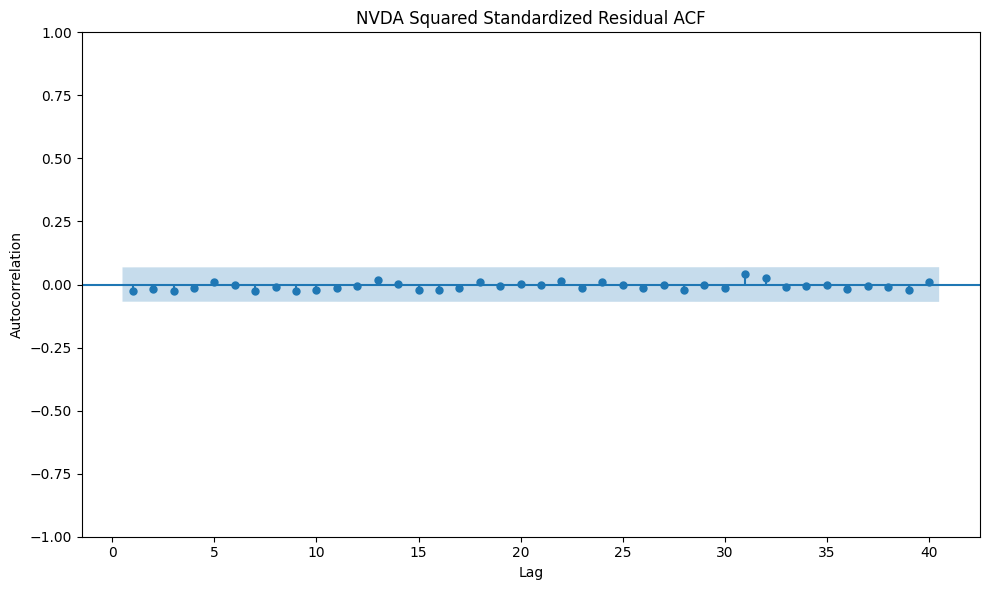


------------------------------------------------------------
NVDA ARIMA-GARCH RESULTS
------------------------------------------------------------
Point forecast MAPE: 2.1787 %
Point forecast RMSE: 3.6031
95% interval coverage: 90.59 %
Average interval width: 11.7018
ARCH tests still significant: 0 / 3
Squared standardized Ljung-Box tests still significant: 0 / 4
Conclusion: GARCH successfully removed detectable conditional variance dependence

ARIMA-GARCH FINAL RESULTS
Company              Model ARIMA Order GARCH Order      MAE     RMSE  MAPE (%)       R2  Directional Accuracy (%)  95% Interval Coverage (%)  Average 95% Interval Width
   AAPL ARIMA-GARCH(1,1)-t   (5, 1, 0)       (1,1) 2.418581 3.526754  1.117036 0.991218                 47.044632                  93.606755                   12.794150
   MSFT ARIMA-GARCH(1,1)-t   (5, 1, 0)       (1,1) 4.477894 6.312221  1.112094 0.989582                 49.698432                  93.486128                   23.497226
   NVDA ARIMA-GAR

In [28]:
# ==========================================
# SECTION 26 — ARIMA-GARCH
# Conditional volatility modelling +
# standardized residual diagnostics
#
# Purpose:
# 1. Use ARIMA for next-day price-level forecasting.
# 2. Use GARCH(1,1) to model remaining conditional variance.
# 3. Evaluate whether GARCH removes the ARCH structure
#    detected in Sections 24–25.
# 4. Construct volatility-aware prediction intervals.
#
# Important:
# Standard ARIMA-GARCH does NOT change the ARIMA conditional
# mean forecast. GARCH models forecast uncertainty / variance.
# ==========================================


# ==========================================================
# 26.1 — INSTALL / IMPORT
# ==========================================================

!pip install arch -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arch import arch_model

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_arch
)

from scipy import stats


# ==========================================================
# 26.2 — CONFIGURATION
# ==========================================================

GARCH_DATASETS = {
    "AAPL": "AAPL_mid_clean.csv",
    "MSFT": "MSFT_mid_clean.csv",
    "NVDA": "NVDA_mid_clean.csv"
}

ARIMA_GARCH_ORDER = (
    5,
    1,
    0
)

GARCH_P = 1
GARCH_Q = 1

TRAIN_RATIO_GARCH = 0.80

DIAGNOSTIC_LAGS = [
    5,
    10,
    20,
    40
]

ARCH_TEST_LAGS = [
    5,
    10,
    20
]


# Student-t is used because Section 24 showed
# strongly leptokurtic / heavy-tailed ARIMA residuals.

GARCH_DISTRIBUTION = "t"


print(
    "ARIMA-GARCH datasets:",
    GARCH_DATASETS
)

print(
    "ARIMA order:",
    ARIMA_GARCH_ORDER
)

print(
    "GARCH order:",
    (
        GARCH_P,
        GARCH_Q
    )
)

print(
    "GARCH innovation distribution:",
    GARCH_DISTRIBUTION
)


# ==========================================================
# 26.3 — EVALUATION FUNCTION
# ==========================================================

def evaluate_arima_garch_price(
    y_true,
    y_pred,
    current_close
):

    y_true = (
        np.asarray(
            y_true,
            dtype=float
        )
        .flatten()
    )

    y_pred = (
        np.asarray(
            y_pred,
            dtype=float
        )
        .flatten()
    )

    current_close = (
        np.asarray(
            current_close,
            dtype=float
        )
        .flatten()
    )

    if not (
        len(y_true)
        == len(y_pred)
        == len(current_close)
    ):

        raise ValueError(
            "Price-evaluation arrays "
            "must have equal lengths."
        )

    mae = (
        mean_absolute_error(
            y_true,
            y_pred
        )
    )

    rmse = (
        np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )
    )

    mape = (
        np.mean(
            np.abs(
                (
                    y_true
                    - y_pred
                )
                / y_true
            )
        )
        * 100
    )

    r2 = (
        r2_score(
            y_true,
            y_pred
        )
    )

    true_direction = (
        y_true
        > current_close
    )

    predicted_direction = (
        y_pred
        > current_close
    )

    directional_accuracy = (
        np.mean(
            true_direction
            == predicted_direction
        )
        * 100
    )

    return {
        "MAE":
            mae,

        "RMSE":
            rmse,

        "MAPE (%)":
            mape,

        "R2":
            r2,

        "Directional Accuracy (%)":
            directional_accuracy
    }


# ==========================================================
# 26.4 — STUDENT-t CRITICAL VALUE
#
# arch uses a standardised Student-t distribution.
# The correction below gives unit variance.
# ==========================================================

def standardized_t_critical_value(
    nu,
    confidence=0.95
):

    alpha = (
        1
        - confidence
    )

    raw_quantile = (
        stats.t.ppf(
            1
            - alpha / 2,
            df=nu
        )
    )

    adjustment = (
        np.sqrt(
            (
                nu - 2
            )
            / nu
        )
    )

    return (
        raw_quantile
        * adjustment
    )


# ==========================================================
# 26.5 — STORAGE
# ==========================================================

arima_garch_results = []

garch_parameter_records = []

standardized_ljungbox_records = []

standardized_arch_records = []

arima_garch_diagnostic_summary = []

arima_garch_prediction_store = {}


# ==========================================================
# 26.6 — MAIN LOOP
# ==========================================================

for company, file_path \
        in GARCH_DATASETS.items():

    print(
        "\n"
        + "=" * 76
    )

    print(
        f"ARIMA-GARCH ANALYSIS: "
        f"{company}"
    )

    print(
        "=" * 76
    )


    # ------------------------------------------------------
    # Load
    # ------------------------------------------------------

    df = (
        pd.read_csv(
            file_path
        )
    )

    df["Date"] = (
        pd.to_datetime(
            df["Date"],
            errors="coerce"
        )
    )

    df = (
        df
        .dropna(
            subset=[
                "Date",
                "Close",
                "Target_Next_Close"
            ]
        )
        .sort_values(
            "Date"
        )
        .reset_index(
            drop=True
        )
    )


    y = (
        df[
            "Target_Next_Close"
        ]
        .to_numpy(
            dtype=float
        )
    )

    current_close = (
        df[
            "Close"
        ]
        .to_numpy(
            dtype=float
        )
    )

    dates = (
        df[
            "Date"
        ]
        .to_numpy()
    )


    # ------------------------------------------------------
    # Chronological split
    # ------------------------------------------------------

    split_index = int(
        len(df)
        * TRAIN_RATIO_GARCH
    )

    y_train = (
        y[
            :split_index
        ]
    )

    y_test = (
        y[
            split_index:
        ]
    )

    close_test = (
        current_close[
            split_index:
        ]
    )

    test_dates = (
        dates[
            split_index:
        ]
    )


    print(
        "Total rows:",
        len(df)
    )

    print(
        "Training rows:",
        len(y_train)
    )

    print(
        "Test rows:",
        len(y_test)
    )

    print(
        "Train period:",
        df["Date"]
        .iloc[0],
        "to",
        df["Date"]
        .iloc[
            split_index - 1
        ]
    )

    print(
        "Test period:",
        df["Date"]
        .iloc[
            split_index
        ],
        "to",
        df["Date"]
        .iloc[-1]
    )


    # ======================================================
    # 26.7 — FIT ARIMA ON TRAINING DATA
    # ======================================================

    print(
        "\nFitting ARIMA..."
    )

    arima_model = (
        ARIMA(
            y_train,
            order=
                ARIMA_GARCH_ORDER
        )
    )

    arima_fit = (
        arima_model.fit()
    )


    # ------------------------------------------------------
    # Training residuals
    # ------------------------------------------------------

    train_residuals = (
        np.asarray(
            arima_fit.resid,
            dtype=float
        )
        .flatten()
    )


    # Remove early unstable values caused by ARIMA
    # initialisation.

    warmup = max(
        20,
        (
            ARIMA_GARCH_ORDER[0]
            + ARIMA_GARCH_ORDER[2]
            + 5
        )
    )

    train_residuals_clean = (
        train_residuals[
            warmup:
        ]
    )

    train_residuals_clean = (
        train_residuals_clean[
            np.isfinite(
                train_residuals_clean
            )
        ]
    )


    print(
        "Usable ARIMA training residuals:",
        len(
            train_residuals_clean
        )
    )


    # ======================================================
    # 26.8 — FIT GARCH(1,1) TO ARIMA RESIDUALS
    # ======================================================

    print(
        "\nFitting Student-t GARCH(1,1)..."
    )

    garch_model = (
        arch_model(
            train_residuals_clean,
            mean="Zero",
            vol="GARCH",
            p=GARCH_P,
            q=GARCH_Q,
            dist=
                GARCH_DISTRIBUTION,
            rescale=False
        )
    )

    garch_fit = (
        garch_model.fit(
            disp="off"
        )
    )


    print(
        garch_fit.summary()
    )


    # ------------------------------------------------------
    # Extract parameters
    # ------------------------------------------------------

    omega = (
        float(
            garch_fit.params[
                "omega"
            ]
        )
    )

    alpha = (
        float(
            garch_fit.params[
                "alpha[1]"
            ]
        )
    )

    beta = (
        float(
            garch_fit.params[
                "beta[1]"
            ]
        )
    )


    if (
        "nu"
        in garch_fit.params.index
    ):

        nu = (
            float(
                garch_fit.params[
                    "nu"
                ]
            )
        )

    else:

        nu = np.nan


    persistence = (
        alpha
        + beta
    )


    garch_parameter_records.append({

        "Company":
            company,

        "Omega":
            omega,

        "Alpha":
            alpha,

        "Beta":
            beta,

        "Alpha + Beta":
            persistence,

        "Student-t nu":
            nu,

        "AIC":
            garch_fit.aic,

        "BIC":
            garch_fit.bic
    })


    print(
        "\nGARCH parameters:"
    )

    print(
        "omega =",
        round(
            omega,
            6
        )
    )

    print(
        "alpha =",
        round(
            alpha,
            6
        )
    )

    print(
        "beta =",
        round(
            beta,
            6
        )
    )

    print(
        "alpha + beta =",
        round(
            persistence,
            6
        )
    )

    print(
        "nu =",
        round(
            nu,
            4
        )
        if np.isfinite(nu)
        else "N/A"
    )


    # ======================================================
    # 26.9 — INITIAL GARCH STATE
    # ======================================================

    conditional_volatility_train = (
        np.asarray(
            garch_fit
            .conditional_volatility,
            dtype=float
        )
        .flatten()
    )

    conditional_variance_train = (
        conditional_volatility_train
        ** 2
    )


    previous_residual = (
        train_residuals_clean[
            -1
        ]
    )

    previous_variance = (
        conditional_variance_train[
            -1
        ]
    )


    # ======================================================
    # 26.10 — CAUSAL ONE-STEP ARIMA + GARCH FORECASTING
    #
    # ARIMA parameters are estimated on training data.
    #
    # For each test date:
    # 1. Forecast next-day price using ARIMA.
    # 2. Forecast variance using GARCH recursion.
    # 3. Observe actual price.
    # 4. Update residual for the next day's variance.
    #
    # Test observations are NEVER used before they become
    # historically available.
    # ======================================================

    print(
        "\nGenerating causal "
        "ARIMA-GARCH test forecasts..."
    )


    arima_state = (
        arima_fit
    )


    arima_predictions = []

    garch_variances = []

    garch_volatilities = []

    test_residuals = []

    standardized_residuals = []


    for i in range(
        len(y_test)
    ):

        # ----------------------------------------------
        # ARIMA conditional-mean forecast
        # ----------------------------------------------

        forecast_value = (
            arima_state
            .forecast(
                steps=1
            )
        )

        forecast_value = (
            float(
                np.asarray(
                    forecast_value
                )
                .flatten()[0]
            )
        )

        arima_predictions.append(
            forecast_value
        )


        # ----------------------------------------------
        # GARCH one-step conditional variance
        #
        # sigma_t^2 =
        # omega
        # + alpha * epsilon_(t-1)^2
        # + beta * sigma_(t-1)^2
        # ----------------------------------------------

        variance_forecast = (
            omega
            + alpha
            * (
                previous_residual
                ** 2
            )
            + beta
            * previous_variance
        )


        # Numerical safety
        variance_forecast = max(
            float(
                variance_forecast
            ),
            1e-12
        )

        volatility_forecast = (
            np.sqrt(
                variance_forecast
            )
        )


        garch_variances.append(
            variance_forecast
        )

        garch_volatilities.append(
            volatility_forecast
        )


        # ----------------------------------------------
        # Actual forecast error
        # ----------------------------------------------

        actual_value = (
            float(
                y_test[i]
            )
        )

        residual = (
            actual_value
            - forecast_value
        )

        standardised_residual = (
            residual
            / volatility_forecast
        )


        test_residuals.append(
            residual
        )

        standardized_residuals.append(
            standardised_residual
        )


        # ----------------------------------------------
        # Update states for NEXT prediction only
        # ----------------------------------------------

        previous_residual = (
            residual
        )

        previous_variance = (
            variance_forecast
        )


        # Update ARIMA filter with the actual
        # observation without re-estimating parameters.

        arima_state = (
            arima_state.append(
                [
                    actual_value
                ],
                refit=False
            )
        )


    # ======================================================
    # 26.11 — ARRAYS / ALIGNMENT
    # ======================================================

    arima_predictions = (
        np.asarray(
            arima_predictions,
            dtype=float
        )
    )

    garch_variances = (
        np.asarray(
            garch_variances,
            dtype=float
        )
    )

    garch_volatilities = (
        np.asarray(
            garch_volatilities,
            dtype=float
        )
    )

    test_residuals = (
        np.asarray(
            test_residuals,
            dtype=float
        )
    )

    standardized_residuals = (
        np.asarray(
            standardized_residuals,
            dtype=float
        )
    )


    print(
        "\nAlignment check:"
    )

    print(
        "Actual:",
        len(
            y_test
        )
    )

    print(
        "ARIMA forecasts:",
        len(
            arima_predictions
        )
    )

    print(
        "GARCH volatility forecasts:",
        len(
            garch_volatilities
        )
    )

    print(
        "Standardized residuals:",
        len(
            standardized_residuals
        )
    )


    assert (
        len(y_test)
        == len(arima_predictions)
        == len(garch_volatilities)
        == len(standardized_residuals)
    ), (
        "ARIMA-GARCH alignment error."
    )


    # ======================================================
    # 26.12 — POINT FORECAST EVALUATION
    #
    # IMPORTANT:
    # Standard GARCH changes conditional variance,
    # not the ARIMA conditional mean.
    #
    # Therefore ARIMA-GARCH point forecast =
    # ARIMA point forecast.
    # ======================================================

    point_metrics = (
        evaluate_arima_garch_price(
            y_true=
                y_test,

            y_pred=
                arima_predictions,

            current_close=
                close_test
        )
    )


    # ======================================================
    # 26.13 — 95% PREDICTION INTERVALS
    # ======================================================

    if (
        np.isfinite(
            nu
        )
        and nu > 2
    ):

        critical_value = (
            standardized_t_critical_value(
                nu=nu,
                confidence=0.95
            )
        )

    else:

        critical_value = (
            stats.norm.ppf(
                0.975
            )
        )


    lower_95 = (
        arima_predictions
        - critical_value
        * garch_volatilities
    )

    upper_95 = (
        arima_predictions
        + critical_value
        * garch_volatilities
    )


    interval_coverage = (
        np.mean(
            (
                y_test
                >= lower_95
            )
            &
            (
                y_test
                <= upper_95
            )
        )
        * 100
    )


    average_interval_width = (
        np.mean(
            upper_95
            - lower_95
        )
    )


    # ======================================================
    # 26.14 — STANDARDIZED RESIDUAL LJUNG-BOX
    # ======================================================

    standardized_lb = (
        acorr_ljungbox(
            standardized_residuals,
            lags=
                DIAGNOSTIC_LAGS,
            return_df=True
        )
    )


    print(
        "\n===== LJUNG-BOX: "
        "STANDARDIZED RESIDUALS ====="
    )

    print(
        standardized_lb
        .to_string()
    )


    for lag in DIAGNOSTIC_LAGS:

        p_value = (
            standardized_lb
            .loc[
                lag,
                "lb_pvalue"
            ]
        )

        standardized_ljungbox_records.append({

            "Company":
                company,

            "Residual Type":
                "Standardized",

            "Lag":
                lag,

            "Ljung-Box Statistic":
                standardized_lb
                .loc[
                    lag,
                    "lb_stat"
                ],

            "p-value":
                p_value,

            "Conclusion":
                (
                    "Significant residual autocorrelation"
                    if p_value < 0.05

                    else
                    "No significant residual autocorrelation"
                )
        })


    # ======================================================
    # 26.15 — STANDARDIZED SQUARED RESIDUAL LJUNG-BOX
    #
    # This is one of the MOST IMPORTANT diagnostics.
    #
    # If p-values become > 0.05 after GARCH,
    # much of the conditional variance structure
    # has been successfully captured.
    # ======================================================

    standardized_squared = (
        standardized_residuals
        ** 2
    )


    standardized_squared_lb = (
        acorr_ljungbox(
            standardized_squared,
            lags=
                DIAGNOSTIC_LAGS,
            return_df=True
        )
    )


    print(
        "\n===== LJUNG-BOX: "
        "SQUARED STANDARDIZED RESIDUALS ====="
    )

    print(
        standardized_squared_lb
        .to_string()
    )


    squared_significant_count = 0


    for lag in DIAGNOSTIC_LAGS:

        p_value = (
            standardized_squared_lb
            .loc[
                lag,
                "lb_pvalue"
            ]
        )


        if (
            p_value < 0.05
        ):

            squared_significant_count += 1


        standardized_ljungbox_records.append({

            "Company":
                company,

            "Residual Type":
                "Squared Standardized",

            "Lag":
                lag,

            "Ljung-Box Statistic":
                standardized_squared_lb
                .loc[
                    lag,
                    "lb_stat"
                ],

            "p-value":
                p_value,

            "Conclusion":
                (
                    "Significant variance dependence remains"
                    if p_value < 0.05

                    else
                    "No significant variance dependence"
                )
        })


    # ======================================================
    # 26.16 — ARCH-LM ON STANDARDIZED RESIDUALS
    # ======================================================

    print(
        "\n===== ARCH-LM: "
        "STANDARDIZED RESIDUALS ====="
    )


    arch_significant_count = 0


    for lag in ARCH_TEST_LAGS:

        arch_result = (
            het_arch(
                standardized_residuals,
                nlags=lag
            )
        )


        lm_stat = (
            arch_result[0]
        )

        lm_pvalue = (
            arch_result[1]
        )

        f_stat = (
            arch_result[2]
        )

        f_pvalue = (
            arch_result[3]
        )


        if (
            lm_pvalue < 0.05
        ):

            arch_significant_count += 1

            conclusion = (
                "Significant ARCH effect remains"
            )

        else:

            conclusion = (
                "No significant ARCH effect"
            )


        print(
            f"Lag {lag} | "
            f"LM p-value: "
            f"{lm_pvalue:.6f} | "
            f"{conclusion}"
        )


        standardized_arch_records.append({

            "Company":
                company,

            "Lag":
                lag,

            "LM Statistic":
                lm_stat,

            "LM p-value":
                lm_pvalue,

            "F Statistic":
                f_stat,

            "F p-value":
                f_pvalue,

            "Conclusion":
                conclusion
        })


    # ======================================================
    # 26.17 — FINAL COMPANY INTERPRETATION
    # ======================================================

    if (
        arch_significant_count == 0
        and squared_significant_count == 0
    ):

        volatility_conclusion = (
            "GARCH successfully removed "
            "detectable conditional variance dependence"
        )

    elif (
        arch_significant_count
        < len(
            ARCH_TEST_LAGS
        )
        or squared_significant_count
        < len(
            DIAGNOSTIC_LAGS
        )
    ):

        volatility_conclusion = (
            "GARCH reduced but did not fully remove "
            "conditional variance dependence"
        )

    else:

        volatility_conclusion = (
            "Substantial conditional variance "
            "dependence remains after GARCH"
        )


    arima_garch_diagnostic_summary.append({

        "Company":
            company,

        "GARCH Alpha":
            alpha,

        "GARCH Beta":
            beta,

        "GARCH Persistence":
            persistence,

        "Student-t nu":
            nu,

        "Significant Standardized ARCH Tests":
            arch_significant_count,

        "Total ARCH Tests":
            len(
                ARCH_TEST_LAGS
            ),

        "Significant Squared-Standardized "
        "Ljung-Box Tests":
            squared_significant_count,

        "Total Squared Ljung-Box Tests":
            len(
                DIAGNOSTIC_LAGS
            ),

        "95% Interval Coverage (%)":
            interval_coverage,

        "Average 95% Interval Width":
            average_interval_width,

        "Interpretation":
            volatility_conclusion
    })


    # ======================================================
    # 26.18 — RESULT RECORD
    # ======================================================

    arima_garch_results.append({

        "Company":
            company,

        "Model":
            "ARIMA-GARCH(1,1)-t",

        "ARIMA Order":
            str(
                ARIMA_GARCH_ORDER
            ),

        "GARCH Order":
            "(1,1)",

        "MAE":
            point_metrics[
                "MAE"
            ],

        "RMSE":
            point_metrics[
                "RMSE"
            ],

        "MAPE (%)":
            point_metrics[
                "MAPE (%)"
            ],

        "R2":
            point_metrics[
                "R2"
            ],

        "Directional Accuracy (%)":
            point_metrics[
                "Directional Accuracy (%)"
            ],

        "95% Interval Coverage (%)":
            interval_coverage,

        "Average 95% Interval Width":
            average_interval_width
    })


    # ======================================================
    # 26.19 — PREDICTION DATAFRAME
    # ======================================================

    prediction_df = pd.DataFrame({

        "Date":
            pd.to_datetime(
                test_dates
            ),

        "Current_Close":
            close_test,

        "True_Next_Close":
            y_test,

        "ARIMA_GARCH_Point_Forecast":
            arima_predictions,

        "Forecast_Error":
            test_residuals,

        "GARCH_Variance":
            garch_variances,

        "GARCH_Volatility":
            garch_volatilities,

        "Standardized_Residual":
            standardized_residuals,

        "Lower_95":
            lower_95,

        "Upper_95":
            upper_95
    })


    arima_garch_prediction_store[
        company
    ] = (
        prediction_df
    )


    prediction_df.to_csv(
        f"{company}_arima_garch_predictions.csv",
        index=False
    )


    # ======================================================
    # 26.20 — VOLATILITY OVER TIME
    # ======================================================

    plt.figure(
        figsize=(
            14,
            6
        )
    )

    plt.plot(
        prediction_df[
            "Date"
        ],
        prediction_df[
            "GARCH_Volatility"
        ],
        linewidth=1.0
    )

    plt.title(
        f"{company} ARIMA-GARCH "
        f"Conditional Volatility"
    )

    plt.xlabel(
        "Date"
    )

    plt.ylabel(
        "Conditional Standard Deviation"
    )

    plt.tight_layout()

    plt.savefig(
        f"{company}_arima_garch_volatility.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # ======================================================
    # 26.21 — FORECAST + 95% INTERVAL
    # ======================================================

    plt.figure(
        figsize=(
            14,
            7
        )
    )

    plt.plot(
        prediction_df[
            "Date"
        ],
        prediction_df[
            "True_Next_Close"
        ],
        label="Actual",
        linewidth=1.0
    )

    plt.plot(
        prediction_df[
            "Date"
        ],
        prediction_df[
            "ARIMA_GARCH_Point_Forecast"
        ],
        label="ARIMA Mean Forecast",
        linewidth=1.0
    )

    plt.fill_between(
        prediction_df[
            "Date"
        ],
        prediction_df[
            "Lower_95"
        ],
        prediction_df[
            "Upper_95"
        ],
        alpha=0.20,
        label="95% GARCH Interval"
    )

    plt.title(
        f"{company} ARIMA-GARCH Forecast "
        f"with 95% Prediction Interval"
    )

    plt.xlabel(
        "Date"
    )

    plt.ylabel(
        "Next-Day Closing Price"
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        f"{company}_arima_garch_prediction_interval.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # ======================================================
    # 26.22 — STANDARDIZED RESIDUAL PLOT
    # ======================================================

    plt.figure(
        figsize=(
            14,
            6
        )
    )

    plt.plot(
        prediction_df[
            "Date"
        ],
        prediction_df[
            "Standardized_Residual"
        ],
        linewidth=0.9
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        f"{company} ARIMA-GARCH "
        f"Standardized Residuals"
    )

    plt.xlabel(
        "Date"
    )

    plt.ylabel(
        "Standardized Residual"
    )

    plt.tight_layout()

    plt.savefig(
        f"{company}_arima_garch_standardized_residuals.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # ======================================================
    # 26.23 — SQUARED STANDARDIZED RESIDUAL ACF
    # ======================================================

    from statsmodels.graphics.tsaplots import (
        plot_acf
    )


    fig, ax = plt.subplots(
        figsize=(
            10,
            6
        )
    )

    plot_acf(
        standardized_squared,
        lags=40,
        zero=False,
        alpha=0.05,
        ax=ax
    )

    ax.set_title(
        f"{company} Squared Standardized "
        f"Residual ACF"
    )

    ax.set_xlabel(
        "Lag"
    )

    ax.set_ylabel(
        "Autocorrelation"
    )

    fig.tight_layout()

    fig.savefig(
        f"{company}_arima_garch_squared_"
        f"standardized_residual_acf.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # ======================================================
    # 26.24 — COMPANY SUMMARY
    # ======================================================

    print(
        "\n"
        + "-" * 60
    )

    print(
        f"{company} ARIMA-GARCH RESULTS"
    )

    print(
        "-" * 60
    )

    print(
        "Point forecast MAPE:",
        round(
            point_metrics[
                "MAPE (%)"
            ],
            4
        ),
        "%"
    )

    print(
        "Point forecast RMSE:",
        round(
            point_metrics[
                "RMSE"
            ],
            4
        )
    )

    print(
        "95% interval coverage:",
        round(
            interval_coverage,
            2
        ),
        "%"
    )

    print(
        "Average interval width:",
        round(
            average_interval_width,
            4
        )
    )

    print(
        "ARCH tests still significant:",
        arch_significant_count,
        "/",
        len(
            ARCH_TEST_LAGS
        )
    )

    print(
        "Squared standardized "
        "Ljung-Box tests still significant:",
        squared_significant_count,
        "/",
        len(
            DIAGNOSTIC_LAGS
        )
    )

    print(
        "Conclusion:",
        volatility_conclusion
    )


# ==========================================================
# 26.25 — RESULT DATAFRAMES
# ==========================================================

arima_garch_results_df = (
    pd.DataFrame(
        arima_garch_results
    )
)

garch_parameters_df = (
    pd.DataFrame(
        garch_parameter_records
    )
)

standardized_ljungbox_df = (
    pd.DataFrame(
        standardized_ljungbox_records
    )
)

standardized_arch_df = (
    pd.DataFrame(
        standardized_arch_records
    )
)

arima_garch_diagnostic_summary_df = (
    pd.DataFrame(
        arima_garch_diagnostic_summary
    )
)


# ==========================================================
# 26.26 — PRINT FINAL TABLES
# ==========================================================

print(
    "\n"
    + "=" * 76
)

print(
    "ARIMA-GARCH FINAL RESULTS"
)

print(
    "=" * 76
)

print(
    arima_garch_results_df
    .to_string(
        index=False
    )
)


print(
    "\n"
    + "=" * 76
)

print(
    "GARCH PARAMETER ESTIMATES"
)

print(
    "=" * 76
)

print(
    garch_parameters_df
    .to_string(
        index=False
    )
)


print(
    "\n"
    + "=" * 76
)

print(
    "STANDARDIZED RESIDUAL LJUNG-BOX RESULTS"
)

print(
    "=" * 76
)

print(
    standardized_ljungbox_df
    .to_string(
        index=False
    )
)


print(
    "\n"
    + "=" * 76
)

print(
    "STANDARDIZED RESIDUAL ARCH-LM RESULTS"
)

print(
    "=" * 76
)

print(
    standardized_arch_df
    .to_string(
        index=False
    )
)


print(
    "\n"
    + "=" * 76
)

print(
    "ARIMA-GARCH DIAGNOSTIC SUMMARY"
)

print(
    "=" * 76
)

print(
    arima_garch_diagnostic_summary_df
    .to_string(
        index=False
    )
)


# ==========================================================
# 26.27 — SAVE
# ==========================================================

arima_garch_results_df.to_csv(
    "arima_garch_final_results.csv",
    index=False
)

garch_parameters_df.to_csv(
    "arima_garch_parameter_estimates.csv",
    index=False
)

standardized_ljungbox_df.to_csv(
    "arima_garch_standardized_ljungbox.csv",
    index=False
)

standardized_arch_df.to_csv(
    "arima_garch_standardized_arch_lm.csv",
    index=False
)

arima_garch_diagnostic_summary_df.to_csv(
    "arima_garch_diagnostic_summary.csv",
    index=False
)


print(
    "\nSaved:"
)

print(
    "arima_garch_final_results.csv"
)

print(
    "arima_garch_parameter_estimates.csv"
)

print(
    "arima_garch_standardized_ljungbox.csv"
)

print(
    "arima_garch_standardized_arch_lm.csv"
)

print(
    "arima_garch_diagnostic_summary.csv"
)

print(
    "AAPL/MSFT/NVDA "
    "prediction-level CSV files"
)

In [29]:
# ==========================================
# SECTION 27 — ROLLING-ORIGIN ROBUST
# CROSS-FAMILY FORECAST ENSEMBLE
#
# ARIMA + Random Forest + LSTM
#
# Statistical + Machine Learning + Deep Learning
#
# PURPOSE
# ----------------------------------------------------------
# Improve the robustness of cross-family forecast
# combination by replacing a single validation period
# with multiple expanding-window validation folds.
#
# Models:
# 1. ARIMA
#    - directly predicts next-day closing price
#
# 2. Random Forest
#    - predicts next-day return
#    - converted back to next-day closing price
#
# 3. LSTM
#    - predicts next-day return
#    - converted back to next-day closing price
#
# Ensembles:
# 4. Equal-weight ensemble
#
# 5. Rolling-validation optimised ensemble
#
# Rolling-origin design:
#
# Fold 1:
# Train 0–50%
# Validate 50–60%
#
# Fold 2:
# Train 0–60%
# Validate 60–70%
#
# Fold 3:
# Train 0–70%
# Validate 70–80%
#
# Final test:
# Development 0–80%
# Test 80–100%
#
# IMPORTANT:
# - Test data are never used for model selection.
# - Ensemble weights are estimated using ONLY
#   rolling-origin validation predictions.
# - Scaling is fitted using each fold's training data only.
# ==========================================


# ============================================================
# 27.1 — IMPORTS
# ============================================================

import gc
import random

import numpy as np
import pandas as pd
import tensorflow as tf

from scipy.optimize import minimize

from statsmodels.tsa.arima.model import ARIMA

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam


# ============================================================
# 27.2 — CONFIGURATION
# ============================================================

ROLLING_ENSEMBLE_DATASETS = {

    "AAPL":
        "AAPL_mid_clean.csv",

    "MSFT":
        "MSFT_mid_clean.csv",

    "NVDA":
        "NVDA_mid_clean.csv"
}


# ------------------------------------------------------------
# Final test = final 20%
# ------------------------------------------------------------

FINAL_TEST_RATIO = 0.20

DEVELOPMENT_RATIO = (
    1.0
    - FINAL_TEST_RATIO
)


# ------------------------------------------------------------
# Rolling-origin validation folds
#
# Each validation block = 10% of complete dataset
# ------------------------------------------------------------

ROLLING_TRAIN_END_RATIOS = [
    0.50,
    0.60,
    0.70
]

ROLLING_VALIDATION_RATIO = 0.10


# ------------------------------------------------------------
# Sequence
# ------------------------------------------------------------

ROLLING_SEQ_LEN = 20


# ------------------------------------------------------------
# Seeds
# ------------------------------------------------------------

ROLLING_SEEDS = [
    42,
    123,
    2026
]


# ------------------------------------------------------------
# ARIMA
# ------------------------------------------------------------

ROLLING_ARIMA_ORDER = (
    5,
    1,
    0
)


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

ROLLING_RF_ESTIMATORS = 500

ROLLING_RF_MIN_SAMPLES_LEAF = 2


# ------------------------------------------------------------
# LSTM
# ------------------------------------------------------------

ROLLING_LSTM_UNITS = 64

ROLLING_LSTM_DROPOUT = 0.10

ROLLING_LSTM_LR = 0.001

ROLLING_LSTM_BATCH = 16

ROLLING_LSTM_MAX_EPOCHS = 60

ROLLING_LSTM_PATIENCE = 8


print(
    "Rolling-origin datasets:",
    ROLLING_ENSEMBLE_DATASETS
)

print(
    "Final development ratio:",
    DEVELOPMENT_RATIO
)

print(
    "Final test ratio:",
    FINAL_TEST_RATIO
)

print(
    "Rolling train-end ratios:",
    ROLLING_TRAIN_END_RATIOS
)

print(
    "Validation block ratio:",
    ROLLING_VALIDATION_RATIO
)

print(
    "Sequence length:",
    ROLLING_SEQ_LEN
)

print(
    "ARIMA order:",
    ROLLING_ARIMA_ORDER
)

print(
    "Seeds:",
    ROLLING_SEEDS
)


# ============================================================
# 27.3 — RANDOM SEED
# ============================================================

def set_rolling_seed(
    seed
):

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    tf.random.set_seed(
        seed
    )

    try:

        tf.keras.utils.set_random_seed(
            seed
        )

    except Exception:

        pass


# ============================================================
# 27.4 — SHARED FEATURE ENGINEERING
#
# RF + LSTM:
# next-day return target
#
# ARIMA:
# next-day closing-price target
# ============================================================

def build_rolling_features(
    file_name
):

    df = pd.read_csv(
        file_name
    )


    df["Date"] = pd.to_datetime(
        df["Date"],
        errors="coerce"
    )


    df = (
        df
        .dropna(
            subset=[
                "Date",
                "Close"
            ]
        )
        .sort_values(
            "Date"
        )
        .drop_duplicates(
            subset=[
                "Date"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    # ========================================================
    # RETURNS
    # ========================================================

    df["Return_1d"] = (
        df["Close"]
        .pct_change()
    )


    df["Log_Return"] = (
        np.log(
            df["Close"]
            / df["Close"].shift(1)
        )
    )


    # ========================================================
    # MOVING AVERAGES
    # ========================================================

    for window in [
        5,
        10,
        20
    ]:

        df[
            f"SMA_{window}"
        ] = (
            df["Close"]
            .rolling(
                window
            )
            .mean()
        )


        df[
            f"EMA_{window}"
        ] = (
            df["Close"]
            .ewm(
                span=window,
                adjust=False
            )
            .mean()
        )


    # ========================================================
    # VOLATILITY
    # ========================================================

    df["Volatility_5"] = (
        df["Return_1d"]
        .rolling(
            5
        )
        .std()
    )


    df["Volatility_10"] = (
        df["Return_1d"]
        .rolling(
            10
        )
        .std()
    )


    # ========================================================
    # MOMENTUM
    # ========================================================

    df["Momentum_5"] = (
        df["Close"]
        - df["Close"].shift(
            5
        )
    )


    df["Momentum_10"] = (
        df["Close"]
        - df["Close"].shift(
            10
        )
    )


    # ========================================================
    # RSI
    # ========================================================

    delta = (
        df["Close"]
        .diff()
    )


    gain = (
        delta
        .clip(
            lower=0
        )
    )


    loss = (
        -delta
        .clip(
            upper=0
        )
    )


    avg_gain = (
        gain
        .rolling(
            14
        )
        .mean()
    )


    avg_loss = (
        loss
        .rolling(
            14
        )
        .mean()
    )


    rs = (
        avg_gain
        / avg_loss
    )


    df["RSI_14"] = (
        100
        - (
            100
            / (
                1
                + rs
            )
        )
    )


    # ========================================================
    # MACD
    # ========================================================

    ema12 = (
        df["Close"]
        .ewm(
            span=12,
            adjust=False
        )
        .mean()
    )


    ema26 = (
        df["Close"]
        .ewm(
            span=26,
            adjust=False
        )
        .mean()
    )


    df["MACD"] = (
        ema12
        - ema26
    )


    df["MACD_Signal"] = (
        df["MACD"]
        .ewm(
            span=9,
            adjust=False
        )
        .mean()
    )


    # ========================================================
    # BOLLINGER BANDS
    # ========================================================

    rolling_mean_20 = (
        df["Close"]
        .rolling(
            20
        )
        .mean()
    )


    rolling_std_20 = (
        df["Close"]
        .rolling(
            20
        )
        .std()
    )


    df["BB_Upper"] = (
        rolling_mean_20
        + 2
        * rolling_std_20
    )


    df["BB_Lower"] = (
        rolling_mean_20
        - 2
        * rolling_std_20
    )


    # ========================================================
    # TARGETS
    # ========================================================

    df[
        "Target_Next_Close"
    ] = (
        df["Close"]
        .shift(
            -1
        )
    )


    df[
        "Target_Next_Return"
    ] = (
        df[
            "Target_Next_Close"
        ]
        / df["Close"]
        - 1
    )


    # ========================================================
    # FINAL FEATURE SET
    # ========================================================

    feature_cols = [

        "Open",
        "High",
        "Low",
        "Close",
        "Volume",

        "Return_1d",
        "Log_Return",

        "SMA_5",
        "SMA_10",
        "SMA_20",

        "EMA_5",
        "EMA_10",
        "EMA_20",

        "Volatility_5",
        "Volatility_10",

        "Momentum_5",
        "Momentum_10",

        "RSI_14",

        "MACD",
        "MACD_Signal",

        "BB_Upper",
        "BB_Lower"
    ]


    df = (
        df
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna(
            subset=(
                feature_cols
                + [
                    "Target_Next_Close",
                    "Target_Next_Return"
                ]
            )
        )
        .reset_index(
            drop=True
        )
    )


    return (
        df,
        feature_cols
    )


# ============================================================
# 27.5 — SEQUENCE CREATION
# ============================================================

def create_rolling_sequences(
    X,
    y,
    seq_len
):

    X_seq = []

    y_seq = []


    for i in range(
        seq_len,
        len(
            X
        )
    ):

        X_seq.append(
            X[
                i-seq_len:
                i
            ]
        )

        y_seq.append(
            y[
                i
            ]
        )


    return (

        np.asarray(
            X_seq,
            dtype=np.float32
        ),

        np.asarray(
            y_seq,
            dtype=np.float32
        )
    )


# ============================================================
# 27.6 — BUILD ONE ROLLING FOLD
#
# IMPORTANT:
# Scalers are fitted ONLY on this fold's training block.
# ============================================================

def build_rolling_fold(
    df,
    feature_cols,
    train_end,
    val_end,
    seq_len
):

    train_df = (
        df
        .iloc[
            :train_end
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    val_df = (
        df
        .iloc[
            train_end:
            val_end
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    # --------------------------------------------------------
    # Scale TRAIN only
    # --------------------------------------------------------

    X_scaler = (
        MinMaxScaler()
    )


    y_scaler = (
        MinMaxScaler()
    )


    X_train_scaled = (
        X_scaler
        .fit_transform(
            train_df[
                feature_cols
            ]
        )
    )


    X_val_scaled = (
        X_scaler
        .transform(
            val_df[
                feature_cols
            ]
        )
    )


    y_train_scaled = (
        y_scaler
        .fit_transform(
            train_df[
                [
                    "Target_Next_Return"
                ]
            ]
        )
        .flatten()
    )


    y_val_scaled = (
        y_scaler
        .transform(
            val_df[
                [
                    "Target_Next_Return"
                ]
            ]
        )
        .flatten()
    )


    # --------------------------------------------------------
    # Training sequences
    # --------------------------------------------------------

    (
        X_train_seq,
        y_train_seq
    ) = (
        create_rolling_sequences(

            X_train_scaled,

            y_train_scaled,

            seq_len
        )
    )


    # --------------------------------------------------------
    # Validation sequences
    #
    # Training tail provides historical context.
    # --------------------------------------------------------

    X_val_all = (
        np.vstack([

            X_train_scaled[
                -seq_len:
            ],

            X_val_scaled
        ])
    )


    y_val_all = (
        np.concatenate([

            y_train_scaled[
                -seq_len:
            ],

            y_val_scaled
        ])
    )


    (
        X_val_seq,
        y_val_seq
    ) = (
        create_rolling_sequences(

            X_val_all,

            y_val_all,

            seq_len
        )
    )


    current_close_val = (
        val_df[
            "Close"
        ]
        .to_numpy(
            dtype=float
        )
    )


    true_close_val = (
        val_df[
            "Target_Next_Close"
        ]
        .to_numpy(
            dtype=float
        )
    )


    assert (
        len(
            X_val_seq
        )
        == len(
            val_df
        )
        == len(
            current_close_val
        )
        == len(
            true_close_val
        )
    ), (
        "Rolling validation alignment error."
    )


    return {

        "train_df":
            train_df,

        "val_df":
            val_df,

        "X_train":
            X_train_seq,

        "y_train":
            y_train_seq,

        "X_val":
            X_val_seq,

        "y_val":
            y_val_seq,

        "current_close_val":
            current_close_val,

        "true_close_val":
            true_close_val,

        "X_scaler":
            X_scaler,

        "y_scaler":
            y_scaler
    }


# ============================================================
# 27.7 — BUILD FINAL DEVELOPMENT / TEST DATA
# ============================================================

def build_final_rolling_test_data(
    df,
    feature_cols,
    development_end,
    seq_len
):

    development_df = (
        df
        .iloc[
            :development_end
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    test_df = (
        df
        .iloc[
            development_end:
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    X_scaler = (
        MinMaxScaler()
    )


    y_scaler = (
        MinMaxScaler()
    )


    X_dev_scaled = (
        X_scaler
        .fit_transform(
            development_df[
                feature_cols
            ]
        )
    )


    X_test_scaled = (
        X_scaler
        .transform(
            test_df[
                feature_cols
            ]
        )
    )


    y_dev_scaled = (
        y_scaler
        .fit_transform(
            development_df[
                [
                    "Target_Next_Return"
                ]
            ]
        )
        .flatten()
    )


    y_test_scaled = (
        y_scaler
        .transform(
            test_df[
                [
                    "Target_Next_Return"
                ]
            ]
        )
        .flatten()
    )


    (
        X_dev_seq,
        y_dev_seq
    ) = (
        create_rolling_sequences(

            X_dev_scaled,

            y_dev_scaled,

            seq_len
        )
    )


    # --------------------------------------------------------
    # Test context
    # --------------------------------------------------------

    X_test_all = (
        np.vstack([

            X_dev_scaled[
                -seq_len:
            ],

            X_test_scaled
        ])
    )


    y_test_all = (
        np.concatenate([

            y_dev_scaled[
                -seq_len:
            ],

            y_test_scaled
        ])
    )


    (
        X_test_seq,
        y_test_seq
    ) = (
        create_rolling_sequences(

            X_test_all,

            y_test_all,

            seq_len
        )
    )


    current_close_test = (
        test_df[
            "Close"
        ]
        .to_numpy(
            dtype=float
        )
    )


    true_close_test = (
        test_df[
            "Target_Next_Close"
        ]
        .to_numpy(
            dtype=float
        )
    )


    test_dates = (
        pd.to_datetime(
            test_df[
                "Date"
            ]
        )
    )


    assert (
        len(
            X_test_seq
        )
        == len(
            test_df
        )
        == len(
            current_close_test
        )
        == len(
            true_close_test
        )
    ), (
        "Final test alignment error."
    )


    return {

        "development_df":
            development_df,

        "test_df":
            test_df,

        "X_dev":
            X_dev_seq,

        "y_dev":
            y_dev_seq,

        "X_test":
            X_test_seq,

        "y_test":
            y_test_seq,

        "current_close_test":
            current_close_test,

        "true_close_test":
            true_close_test,

        "test_dates":
            test_dates,

        "X_scaler":
            X_scaler,

        "y_scaler":
            y_scaler
    }


# ============================================================
# 27.8 — EVALUATION
# ============================================================

def evaluate_rolling_forecast(
    y_true,
    y_pred,
    current_close
):

    y_true = (
        np.asarray(
            y_true,
            dtype=float
        )
        .flatten()
    )


    y_pred = (
        np.asarray(
            y_pred,
            dtype=float
        )
        .flatten()
    )


    current_close = (
        np.asarray(
            current_close,
            dtype=float
        )
        .flatten()
    )


    if not (
        len(
            y_true
        )
        == len(
            y_pred
        )
        == len(
            current_close
        )
    ):

        raise ValueError(
            "Evaluation length mismatch."
        )


    mae = (
        mean_absolute_error(
            y_true,
            y_pred
        )
    )


    rmse = (
        np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )
    )


    mape = (
        np.mean(
            np.abs(
                (
                    y_true
                    - y_pred
                )
                / y_true
            )
        )
        * 100
    )


    r2 = (
        r2_score(
            y_true,
            y_pred
        )
    )


    true_direction = (
        y_true
        > current_close
    )


    predicted_direction = (
        y_pred
        > current_close
    )


    directional_accuracy = (
        np.mean(
            true_direction
            == predicted_direction
        )
        * 100
    )


    return {

        "MAE":
            mae,

        "RMSE":
            rmse,

        "MAPE (%)":
            mape,

        "R2":
            r2,

        "Directional Accuracy (%)":
            directional_accuracy
    }


# ============================================================
# 27.9 — ARIMA ROLLING VALIDATION
# ============================================================

def rolling_arima_validation(
    train_df,
    val_df,
    order
):

    train_target = (
        train_df[
            "Target_Next_Close"
        ]
        .to_numpy(
            dtype=float
        )
    )


    val_target = (
        val_df[
            "Target_Next_Close"
        ]
        .to_numpy(
            dtype=float
        )
    )


    model = (
        ARIMA(
            train_target,
            order=
                order
        )
    )


    state = (
        model.fit()
    )


    predictions = []


    for actual in val_target:

        forecast = (
            state
            .forecast(
                steps=1
            )
        )


        prediction = float(
            np.asarray(
                forecast
            )
            .flatten()[0]
        )


        predictions.append(
            prediction
        )


        state = (
            state
            .append(
                [
                    float(
                        actual
                    )
                ],
                refit=False
            )
        )


    return (
        np.asarray(
            predictions,
            dtype=float
        )
    )


# ============================================================
# 27.10 — FINAL ARIMA TEST FORECAST
# ============================================================

def final_arima_test_forecast(
    development_df,
    test_df,
    order
):

    development_target = (
        development_df[
            "Target_Next_Close"
        ]
        .to_numpy(
            dtype=float
        )
    )


    test_target = (
        test_df[
            "Target_Next_Close"
        ]
        .to_numpy(
            dtype=float
        )
    )


    model = (
        ARIMA(
            development_target,
            order=
                order
        )
    )


    state = (
        model.fit()
    )


    predictions = []


    for actual in test_target:

        forecast = (
            state
            .forecast(
                steps=1
            )
        )


        prediction = float(
            np.asarray(
                forecast
            )
            .flatten()[0]
        )


        predictions.append(
            prediction
        )


        state = (
            state
            .append(
                [
                    float(
                        actual
                    )
                ],
                refit=False
            )
        )


    return (
        np.asarray(
            predictions,
            dtype=float
        )
    )


# ============================================================
# 27.11 — RANDOM FOREST
# ============================================================

def fit_predict_rolling_rf(
    X_train,
    y_train,
    X_predict,
    y_scaler,
    current_close,
    seed
):

    X_train_flat = (
        X_train
        .reshape(
            len(
                X_train
            ),
            -1
        )
    )


    X_predict_flat = (
        X_predict
        .reshape(
            len(
                X_predict
            ),
            -1
        )
    )


    model = (
        RandomForestRegressor(

            n_estimators=
                ROLLING_RF_ESTIMATORS,

            min_samples_leaf=
                ROLLING_RF_MIN_SAMPLES_LEAF,

            random_state=
                seed,

            n_jobs=-1
        )
    )


    model.fit(
        X_train_flat,
        y_train
    )


    prediction_scaled = (
        model.predict(
            X_predict_flat
        )
        .reshape(
            -1,
            1
        )
    )


    prediction_return = (
        y_scaler
        .inverse_transform(
            prediction_scaled
        )
        .flatten()
    )


    prediction_price = (
        np.asarray(
            current_close,
            dtype=float
        )
        * (
            1
            + prediction_return
        )
    )


    return (
        model,
        prediction_price
    )


# ============================================================
# 27.12 — LSTM MODEL
# ============================================================

def build_rolling_lstm(
    seq_len,
    n_features
):

    model = Sequential([

        Input(
            shape=(
                seq_len,
                n_features
            )
        ),

        LSTM(
            ROLLING_LSTM_UNITS
        ),

        Dropout(
            ROLLING_LSTM_DROPOUT
        ),

        Dense(1)
    ])


    model.compile(

        optimizer=
            Adam(
                learning_rate=
                    ROLLING_LSTM_LR
            ),

        loss=
            "mse"
    )


    return model


# ============================================================
# 27.13 — LSTM ROLLING VALIDATION
# ============================================================

def fit_predict_rolling_lstm_validation(
    fold_data,
    seed
):

    tf.keras.backend.clear_session()

    gc.collect()

    set_rolling_seed(
        seed
    )


    model = (
        build_rolling_lstm(

            seq_len=
                fold_data[
                    "X_train"
                ]
                .shape[1],

            n_features=
                fold_data[
                    "X_train"
                ]
                .shape[2]
        )
    )


    early_stop = (
        EarlyStopping(

            monitor=
                "val_loss",

            patience=
                ROLLING_LSTM_PATIENCE,

            restore_best_weights=
                True,

            verbose=
                0
        )
    )


    reduce_lr = (
        ReduceLROnPlateau(

            monitor=
                "val_loss",

            factor=
                0.5,

            patience=
                4,

            min_lr=
                1e-5,

            verbose=
                0
        )
    )


    history = (
        model.fit(

            fold_data[
                "X_train"
            ],

            fold_data[
                "y_train"
            ],

            validation_data=(

                fold_data[
                    "X_val"
                ],

                fold_data[
                    "y_val"
                ]
            ),

            epochs=
                ROLLING_LSTM_MAX_EPOCHS,

            batch_size=
                ROLLING_LSTM_BATCH,

            shuffle=
                False,

            verbose=
                0,

            callbacks=[
                early_stop,
                reduce_lr
            ]
        )
    )


    prediction_scaled = (
        model.predict(
            fold_data[
                "X_val"
            ],
            verbose=0
        )
    )


    prediction_return = (
        fold_data[
            "y_scaler"
        ]
        .inverse_transform(
            prediction_scaled
        )
        .flatten()
    )


    prediction_price = (
        fold_data[
            "current_close_val"
        ]
        * (
            1
            + prediction_return
        )
    )


    epochs_used = (
        len(
            history.history[
                "loss"
            ]
        )
    )


    return (

        model,

        prediction_price,

        epochs_used
    )


# ============================================================
# 27.14 — FINAL LSTM TRAINING
#
# Uses all development observations.
#
# No test-based early stopping.
#
# Number of epochs comes from median number of epochs
# selected across rolling validation folds.
# ============================================================

def fit_final_rolling_lstm(
    final_data,
    seed,
    final_epochs
):

    tf.keras.backend.clear_session()

    gc.collect()

    set_rolling_seed(
        seed
    )


    model = (
        build_rolling_lstm(

            seq_len=
                final_data[
                    "X_dev"
                ]
                .shape[1],

            n_features=
                final_data[
                    "X_dev"
                ]
                .shape[2]
        )
    )


    model.fit(

        final_data[
            "X_dev"
        ],

        final_data[
            "y_dev"
        ],

        epochs=
            final_epochs,

        batch_size=
            ROLLING_LSTM_BATCH,

        shuffle=
            False,

        verbose=
            0
    )


    test_scaled = (
        model.predict(
            final_data[
                "X_test"
            ],
            verbose=0
        )
    )


    test_return = (
        final_data[
            "y_scaler"
        ]
        .inverse_transform(
            test_scaled
        )
        .flatten()
    )


    test_price = (
        final_data[
            "current_close_test"
        ]
        * (
            1
            + test_return
        )
    )


    return (
        model,
        test_price
    )


# ============================================================
# 27.15 — ROBUST ENSEMBLE WEIGHT OPTIMISATION
#
# Uses concatenated predictions from ALL rolling folds.
#
# Objective:
#
# minimise pooled validation RMSE
#
# subject to:
#
# w_ARIMA + w_RF + w_LSTM = 1
#
# w >= 0
# ============================================================

def optimise_rolling_weights(
    y_true,
    prediction_matrix
):

    y_true = (
        np.asarray(
            y_true,
            dtype=float
        )
        .flatten()
    )


    prediction_matrix = (
        np.asarray(
            prediction_matrix,
            dtype=float
        )
    )


    n_models = (
        prediction_matrix
        .shape[1]
    )


    def objective(
        weights
    ):

        ensemble_prediction = (
            prediction_matrix
            @ weights
        )


        return (
            np.sqrt(
                mean_squared_error(
                    y_true,
                    ensemble_prediction
                )
            )
        )


    initial_weights = (
        np.repeat(
            1.0
            / n_models,
            n_models
        )
    )


    bounds = [

        (
            0.0,
            1.0
        )

        for _
        in range(
            n_models
        )
    ]


    constraints = {

        "type":
            "eq",

        "fun":
            lambda w:
                np.sum(
                    w
                )
                - 1.0
    }


    result = (
        minimize(

            objective,

            x0=
                initial_weights,

            method=
                "SLSQP",

            bounds=
                bounds,

            constraints=
                constraints,

            options={

                "maxiter":
                    1000,

                "ftol":
                    1e-12
            }
        )
    )


    if not (
        result.success
    ):

        print(
            "WARNING: rolling weight "
            "optimisation failed."
        )

        print(
            result.message
        )


        return (
            initial_weights
        )


    weights = (
        np.asarray(
            result.x,
            dtype=float
        )
    )


    weights = (
        np.clip(
            weights,
            0,
            1
        )
    )


    weights = (
        weights
        / weights.sum()
    )


    return weights


# ============================================================
# 27.16 — STORAGE
# ============================================================

rolling_fold_results = []

rolling_final_results = []

rolling_weight_records = []

rolling_prediction_store = {}


# ============================================================
# 27.17 — MAIN EXPERIMENT
# ============================================================

for company, file_path \
        in ROLLING_ENSEMBLE_DATASETS.items():

    print(
        "\n"
        + "=" * 82
    )


    print(
        f"ROLLING-ORIGIN ROBUST ENSEMBLE: "
        f"{company}"
    )


    print(
        "=" * 82
    )


    # --------------------------------------------------------
    # Data
    # --------------------------------------------------------

    (
        df,
        feature_cols
    ) = (
        build_rolling_features(
            file_path
        )
    )


    n = len(
        df
    )


    development_end = int(
        n
        * DEVELOPMENT_RATIO
    )


    print(
        "Usable rows:",
        n
    )


    print(
        "Features:",
        len(
            feature_cols
        )
    )


    print(
        "Development observations:",
        development_end
    )


    print(
        "Final test observations:",
        n
        - development_end
    )


    print(
        "Final test starts:",
        df[
            "Date"
        ]
        .iloc[
            development_end
        ]
    )


    # ========================================================
    # EACH SEED
    # ========================================================

    for seed in ROLLING_SEEDS:

        print(
            "\n"
            + "-" * 68
        )


        print(
            f"{company} | Seed {seed}"
        )


        print(
            "-" * 68
        )


        # ----------------------------------------------------
        # Store predictions from all rolling folds
        # ----------------------------------------------------

        pooled_true = []

        pooled_arima = []

        pooled_rf = []

        pooled_lstm = []

        fold_lstm_epochs = []


        # ====================================================
        # ROLLING VALIDATION FOLDS
        # ====================================================

        for fold_number, train_ratio \
                in enumerate(
                    ROLLING_TRAIN_END_RATIOS,
                    start=1
                ):

            train_end = int(
                n
                * train_ratio
            )


            val_end = int(
                n
                * (
                    train_ratio
                    + ROLLING_VALIDATION_RATIO
                )
            )


            # ------------------------------------------------
            # Safety:
            # validation must remain inside first 80%
            # ------------------------------------------------

            val_end = min(
                val_end,
                development_end
            )


            print(
                f"\nFold {fold_number}"
            )


            print(
                "Train:",
                df["Date"]
                .iloc[0],
                "to",
                df["Date"]
                .iloc[
                    train_end - 1
                ]
            )


            print(
                "Validation:",
                df["Date"]
                .iloc[
                    train_end
                ],
                "to",
                df["Date"]
                .iloc[
                    val_end - 1
                ]
            )


            fold_data = (
                build_rolling_fold(

                    df=
                        df,

                    feature_cols=
                        feature_cols,

                    train_end=
                        train_end,

                    val_end=
                        val_end,

                    seq_len=
                        ROLLING_SEQ_LEN
                )
            )


            true_val = (
                fold_data[
                    "true_close_val"
                ]
            )


            current_val = (
                fold_data[
                    "current_close_val"
                ]
            )


            # ================================================
            # ARIMA
            # ================================================

            arima_val_pred = (
                rolling_arima_validation(

                    train_df=
                        fold_data[
                            "train_df"
                        ],

                    val_df=
                        fold_data[
                            "val_df"
                        ],

                    order=
                        ROLLING_ARIMA_ORDER
                )
            )


            # ================================================
            # RANDOM FOREST
            # ================================================

            (
                rf_model,
                rf_val_pred
            ) = (
                fit_predict_rolling_rf(

                    X_train=
                        fold_data[
                            "X_train"
                        ],

                    y_train=
                        fold_data[
                            "y_train"
                        ],

                    X_predict=
                        fold_data[
                            "X_val"
                        ],

                    y_scaler=
                        fold_data[
                            "y_scaler"
                        ],

                    current_close=
                        current_val,

                    seed=
                        seed
                )
            )


            # ================================================
            # LSTM
            # ================================================

            print(
                "Training fold LSTM..."
            )


            (
                lstm_model,
                lstm_val_pred,
                epochs_used
            ) = (
                fit_predict_rolling_lstm_validation(

                    fold_data=
                        fold_data,

                    seed=
                        seed
                )
            )


            fold_lstm_epochs.append(
                epochs_used
            )


            # ================================================
            # FOLD METRICS
            # ================================================

            arima_fold_metrics = (
                evaluate_rolling_forecast(

                    true_val,

                    arima_val_pred,

                    current_val
                )
            )


            rf_fold_metrics = (
                evaluate_rolling_forecast(

                    true_val,

                    rf_val_pred,

                    current_val
                )
            )


            lstm_fold_metrics = (
                evaluate_rolling_forecast(

                    true_val,

                    lstm_val_pred,

                    current_val
                )
            )


            for (
                model_name,
                metrics
            ) in [

                (
                    "ARIMA",
                    arima_fold_metrics
                ),

                (
                    "Random_Forest",
                    rf_fold_metrics
                ),

                (
                    "LSTM",
                    lstm_fold_metrics
                )

            ]:

                rolling_fold_results.append({

                    "Company":
                        company,

                    "Seed":
                        seed,

                    "Fold":
                        fold_number,

                    "Model":
                        model_name,

                    "Train End Ratio":
                        train_ratio,

                    "Validation Start":
                        fold_data[
                            "val_df"
                        ][
                            "Date"
                        ]
                        .min(),

                    "Validation End":
                        fold_data[
                            "val_df"
                        ][
                            "Date"
                        ]
                        .max(),

                    **metrics
                })


            print(
                "Validation RMSE:",
                {

                    "ARIMA":
                        round(
                            arima_fold_metrics[
                                "RMSE"
                            ],
                            4
                        ),

                    "RF":
                        round(
                            rf_fold_metrics[
                                "RMSE"
                            ],
                            4
                        ),

                    "LSTM":
                        round(
                            lstm_fold_metrics[
                                "RMSE"
                            ],
                            4
                        )
                }
            )


            print(
                "LSTM epochs:",
                epochs_used
            )


            # ================================================
            # POOL ROLLING VALIDATION PREDICTIONS
            # ================================================

            pooled_true.extend(
                true_val
            )


            pooled_arima.extend(
                arima_val_pred
            )


            pooled_rf.extend(
                rf_val_pred
            )


            pooled_lstm.extend(
                lstm_val_pred
            )


        # ====================================================
        # OPTIMISE ROBUST WEIGHTS ACROSS ALL FOLDS
        # ====================================================

        pooled_true = (
            np.asarray(
                pooled_true,
                dtype=float
            )
        )


        pooled_validation_matrix = (
            np.column_stack([

                np.asarray(
                    pooled_arima,
                    dtype=float
                ),

                np.asarray(
                    pooled_rf,
                    dtype=float
                ),

                np.asarray(
                    pooled_lstm,
                    dtype=float
                )
            ])
        )


        robust_weights = (
            optimise_rolling_weights(

                y_true=
                    pooled_true,

                prediction_matrix=
                    pooled_validation_matrix
            )
        )


        pooled_equal_prediction = (
            pooled_validation_matrix
            .mean(
                axis=1
            )
        )


        pooled_optimised_prediction = (
            pooled_validation_matrix
            @ robust_weights
        )


        pooled_arima_rmse = (
            np.sqrt(
                mean_squared_error(

                    pooled_true,

                    pooled_validation_matrix[
                        :,
                        0
                    ]
                )
            )
        )


        pooled_rf_rmse = (
            np.sqrt(
                mean_squared_error(

                    pooled_true,

                    pooled_validation_matrix[
                        :,
                        1
                    ]
                )
            )
        )


        pooled_lstm_rmse = (
            np.sqrt(
                mean_squared_error(

                    pooled_true,

                    pooled_validation_matrix[
                        :,
                        2
                    ]
                )
            )
        )


        pooled_equal_rmse = (
            np.sqrt(
                mean_squared_error(

                    pooled_true,

                    pooled_equal_prediction
                )
            )
        )


        pooled_optimised_rmse = (
            np.sqrt(
                mean_squared_error(

                    pooled_true,

                    pooled_optimised_prediction
                )
            )
        )


        print(
            "\nRobust rolling-validation weights:"
        )


        print({

            "ARIMA":
                round(
                    robust_weights[
                        0
                    ],
                    4
                ),

            "RF":
                round(
                    robust_weights[
                        1
                    ],
                    4
                ),

            "LSTM":
                round(
                    robust_weights[
                        2
                    ],
                    4
                )
        })


        print(
            "Pooled rolling-validation RMSE:",
            {

                "ARIMA":
                    round(
                        pooled_arima_rmse,
                        4
                    ),

                "RF":
                    round(
                        pooled_rf_rmse,
                        4
                    ),

                "LSTM":
                    round(
                        pooled_lstm_rmse,
                        4
                    ),

                "Equal":
                    round(
                        pooled_equal_rmse,
                        4
                    ),

                "Optimised":
                    round(
                        pooled_optimised_rmse,
                        4
                    )
            }
        )


        # ====================================================
        # CHOOSE FINAL LSTM TRAINING EPOCHS
        #
        # Median across rolling folds.
        # ====================================================

        final_lstm_epochs = int(
            np.median(
                fold_lstm_epochs
            )
        )


        final_lstm_epochs = max(
            final_lstm_epochs,
            1
        )


        print(
            "Fold LSTM epochs:",
            fold_lstm_epochs
        )


        print(
            "Final LSTM epochs:",
            final_lstm_epochs
        )


        # ====================================================
        # BUILD FINAL DEVELOPMENT / TEST DATA
        # ====================================================

        final_data = (
            build_final_rolling_test_data(

                df=
                    df,

                feature_cols=
                    feature_cols,

                development_end=
                    development_end,

                seq_len=
                    ROLLING_SEQ_LEN
            )
        )


        true_test = (
            final_data[
                "true_close_test"
            ]
        )


        current_test = (
            final_data[
                "current_close_test"
            ]
        )


        # ====================================================
        # FINAL ARIMA
        # ====================================================

        print(
            "\nRunning final ARIMA..."
        )


        arima_test_pred = (
            final_arima_test_forecast(

                development_df=
                    final_data[
                        "development_df"
                    ],

                test_df=
                    final_data[
                        "test_df"
                    ],

                order=
                    ROLLING_ARIMA_ORDER
            )
        )


        # ====================================================
        # FINAL RANDOM FOREST
        # ====================================================

        print(
            "Training final Random Forest..."
        )


        (
            final_rf_model,
            rf_test_pred
        ) = (
            fit_predict_rolling_rf(

                X_train=
                    final_data[
                        "X_dev"
                    ],

                y_train=
                    final_data[
                        "y_dev"
                    ],

                X_predict=
                    final_data[
                        "X_test"
                    ],

                y_scaler=
                    final_data[
                        "y_scaler"
                    ],

                current_close=
                    current_test,

                seed=
                    seed
            )
        )


        # ====================================================
        # FINAL LSTM
        # ====================================================

        print(
            "Training final LSTM..."
        )


        (
            final_lstm_model,
            lstm_test_pred
        ) = (
            fit_final_rolling_lstm(

                final_data=
                    final_data,

                seed=
                    seed,

                final_epochs=
                    final_lstm_epochs
            )
        )


        # ====================================================
        # FINAL ENSEMBLES
        # ====================================================

        test_matrix = (
            np.column_stack([

                arima_test_pred,

                rf_test_pred,

                lstm_test_pred
            ])
        )


        equal_test_pred = (
            test_matrix
            .mean(
                axis=1
            )
        )


        robust_test_pred = (
            test_matrix
            @ robust_weights
        )


        # ====================================================
        # FINAL TEST METRICS
        # ====================================================

        model_predictions = {

            "ARIMA":
                arima_test_pred,

            "Random_Forest":
                rf_test_pred,

            "LSTM":
                lstm_test_pred,

            "Equal_Weight_Ensemble":
                equal_test_pred,

            "Rolling_Optimised_Ensemble":
                robust_test_pred
        }


        seed_metrics = {}


        for (
            model_name,
            prediction
        ) in (
            model_predictions
            .items()
        ):

            metrics = (
                evaluate_rolling_forecast(

                    true_test,

                    prediction,

                    current_test
                )
            )


            seed_metrics[
                model_name
            ] = metrics


            # ARIMA is deterministic.
            # Store it only once per company.
            if (
                model_name
                == "ARIMA"
                and seed
                != ROLLING_SEEDS[
                    0
                ]
            ):

                continue


            rolling_final_results.append({

                "Company":
                    company,

                "Seed":
                    (
                        0
                        if model_name
                        == "ARIMA"
                        else seed
                    ),

                "Model":
                    model_name,

                "Final LSTM Epochs":
                    (
                        final_lstm_epochs
                        if model_name
                        == "LSTM"
                        else 0
                    ),

                **metrics
            })


        # ====================================================
        # STORE WEIGHTS
        # ====================================================

        rolling_weight_records.append({

            "Company":
                company,

            "Seed":
                seed,

            "ARIMA Weight":
                robust_weights[
                    0
                ],

            "RF Weight":
                robust_weights[
                    1
                ],

            "LSTM Weight":
                robust_weights[
                    2
                ],

            "Rolling ARIMA RMSE":
                pooled_arima_rmse,

            "Rolling RF RMSE":
                pooled_rf_rmse,

            "Rolling LSTM RMSE":
                pooled_lstm_rmse,

            "Rolling Equal RMSE":
                pooled_equal_rmse,

            "Rolling Optimised RMSE":
                pooled_optimised_rmse,

            "Final LSTM Epochs":
                final_lstm_epochs
        })


        print(
            "\nFINAL TEST MAPE:"
        )


        print({

            model:
                round(
                    values[
                        "MAPE (%)"
                    ],
                    4
                )

            for model,
                values
            in seed_metrics.items()
        })


        print(
            "FINAL TEST RMSE:"
        )


        print({

            model:
                round(
                    values[
                        "RMSE"
                    ],
                    4
                )

            for model,
                values
            in seed_metrics.items()
        })


        # ====================================================
        # STORE PREDICTIONS
        # ====================================================

        if (
            company
            not in rolling_prediction_store
        ):

            rolling_prediction_store[
                company
            ] = {

                "Date":
                    np.asarray(
                        final_data[
                            "test_dates"
                        ]
                    ),

                "Current_Close":
                    current_test,

                "True_Next_Close":
                    true_test,

                "ARIMA":
                    arima_test_pred
            }


        rolling_prediction_store[
            company
        ][
            f"RF_{seed}"
        ] = (
            rf_test_pred
        )


        rolling_prediction_store[
            company
        ][
            f"LSTM_{seed}"
        ] = (
            lstm_test_pred
        )


        rolling_prediction_store[
            company
        ][
            f"Equal_Ensemble_{seed}"
        ] = (
            equal_test_pred
        )


        rolling_prediction_store[
            company
        ][
            f"Rolling_Optimised_Ensemble_{seed}"
        ] = (
            robust_test_pred
        )


# ============================================================
# 27.18 — CREATE DATAFRAMES
# ============================================================

rolling_fold_results_df = (
    pd.DataFrame(
        rolling_fold_results
    )
)


rolling_final_results_df = (
    pd.DataFrame(
        rolling_final_results
    )
)


rolling_weights_df = (
    pd.DataFrame(
        rolling_weight_records
    )
)


# ============================================================
# 27.19 — ROLLING FOLD PERFORMANCE SUMMARY
# ============================================================

rolling_fold_summary_df = (

    rolling_fold_results_df

    .groupby(
        [
            "Company",
            "Model"
        ]
    )[
        [
            "MAE",
            "RMSE",
            "MAPE (%)",
            "R2",
            "Directional Accuracy (%)"
        ]
    ]

    .agg(
        [
            "mean",
            "std"
        ]
    )

    .reset_index()
)


rolling_fold_summary_df.columns = [

    (
        f"{column[0]}_{column[1]}"

        if column[1]

        else column[0]
    )

    for column
    in rolling_fold_summary_df.columns
]


print(
    "\n"
    + "=" * 90
)


print(
    "ROLLING-ORIGIN VALIDATION SUMMARY"
)


print(
    "=" * 90
)


print(
    rolling_fold_summary_df
    .to_string(
        index=False
    )
)


# ============================================================
# 27.20 — FINAL MODEL SUMMARY
# ============================================================

metric_columns = [

    "MAE",

    "RMSE",

    "MAPE (%)",

    "R2",

    "Directional Accuracy (%)"
]


rolling_final_summary_df = (

    rolling_final_results_df

    .groupby(
        [
            "Company",
            "Model"
        ]
    )[
        metric_columns
    ]

    .agg(
        [
            "mean",
            "std",
            "count"
        ]
    )

    .reset_index()
)


rolling_final_summary_df.columns = [

    (
        f"{column[0]}_{column[1]}"

        if column[1]

        else column[0]
    )

    for column
    in rolling_final_summary_df.columns
]


rolling_final_summary_df[
    "Runs"
] = (
    rolling_final_summary_df[
        "MAE_count"
    ]
)


count_cols = [

    column

    for column
    in rolling_final_summary_df.columns

    if column.endswith(
        "_count"
    )
]


rolling_final_summary_df = (
    rolling_final_summary_df
    .drop(
        columns=
            count_cols
    )
)


summary_order = [

    "Company",

    "Model",

    "Runs",

    "MAE_mean",
    "MAE_std",

    "RMSE_mean",
    "RMSE_std",

    "MAPE (%)_mean",
    "MAPE (%)_std",

    "R2_mean",
    "R2_std",

    "Directional Accuracy (%)_mean",
    "Directional Accuracy (%)_std"
]


rolling_final_summary_df = (
    rolling_final_summary_df[
        summary_order
    ]
)


print(
    "\n"
    + "=" * 90
)


print(
    "FINAL ROLLING-ORIGIN MODEL SUMMARY"
)


print(
    "=" * 90
)


print(
    rolling_final_summary_df
    .to_string(
        index=False
    )
)


# ============================================================
# 27.21 — ROBUST WEIGHT SUMMARY
# ============================================================

rolling_weight_summary_df = (

    rolling_weights_df

    .groupby(
        "Company"
    )[
        [
            "ARIMA Weight",
            "RF Weight",
            "LSTM Weight",

            "Rolling ARIMA RMSE",
            "Rolling RF RMSE",
            "Rolling LSTM RMSE",
            "Rolling Equal RMSE",
            "Rolling Optimised RMSE",

            "Final LSTM Epochs"
        ]
    ]

    .agg(
        [
            "mean",
            "std"
        ]
    )

    .reset_index()
)


rolling_weight_summary_df.columns = [

    (
        f"{column[0]}_{column[1]}"

        if column[1]

        else column[0]
    )

    for column
    in rolling_weight_summary_df.columns
]


print(
    "\n"
    + "=" * 90
)


print(
    "ROBUST ROLLING-VALIDATION WEIGHT SUMMARY"
)


print(
    "=" * 90
)


print(
    rolling_weight_summary_df
    .to_string(
        index=False
    )
)


# ============================================================
# 27.22 — FINAL MODEL RANKING
# ============================================================

rolling_ranking_df = (

    rolling_final_summary_df[
        [
            "Company",
            "Model",
            "Runs",

            "MAE_mean",
            "RMSE_mean",
            "MAPE (%)_mean",

            "R2_mean",

            "Directional Accuracy (%)_mean"
        ]
    ]

    .copy()
)


rolling_ranking_df[
    "RMSE Rank"
] = (

    rolling_ranking_df

    .groupby(
        "Company"
    )[
        "RMSE_mean"
    ]

    .rank(
        method="min",
        ascending=True
    )
)


rolling_ranking_df[
    "MAE Rank"
] = (

    rolling_ranking_df

    .groupby(
        "Company"
    )[
        "MAE_mean"
    ]

    .rank(
        method="min",
        ascending=True
    )
)


rolling_ranking_df[
    "MAPE Rank"
] = (

    rolling_ranking_df

    .groupby(
        "Company"
    )[
        "MAPE (%)_mean"
    ]

    .rank(
        method="min",
        ascending=True
    )
)


rolling_ranking_df[
    "Average Error Rank"
] = (

    rolling_ranking_df[
        [
            "RMSE Rank",
            "MAE Rank",
            "MAPE Rank"
        ]
    ]

    .mean(
        axis=1
    )
)


rolling_ranking_df = (

    rolling_ranking_df

    .sort_values(
        [
            "Company",
            "Average Error Rank",
            "RMSE Rank"
        ]
    )

    .reset_index(
        drop=True
    )
)


print(
    "\n"
    + "=" * 90
)


print(
    "FINAL ROLLING-ORIGIN MODEL RANKING"
)


print(
    "=" * 90
)


print(
    rolling_ranking_df
    .to_string(
        index=False
    )
)


# ============================================================
# 27.23 — BEST MODEL BY COMPANY
# ============================================================

rolling_best_models_df = (

    rolling_ranking_df

    .sort_values(
        [
            "Company",
            "Average Error Rank",
            "RMSE Rank"
        ]
    )

    .groupby(
        "Company",
        as_index=False
    )

    .first()
)


print(
    "\n"
    + "=" * 90
)


print(
    "BEST MODEL BY COMPANY"
)


print(
    "=" * 90
)


print(
    rolling_best_models_df[
        [
            "Company",

            "Model",

            "MAE_mean",

            "RMSE_mean",

            "MAPE (%)_mean",

            "R2_mean",

            "Directional Accuracy (%)_mean"
        ]
    ]

    .to_string(
        index=False
    )
)


# ============================================================
# 27.24 — CROSS-STOCK AVERAGE RANK
# ============================================================

rolling_cross_stock_rank_df = (

    rolling_ranking_df

    .groupby(
        "Model"
    )[
        [
            "RMSE Rank",

            "MAE Rank",

            "MAPE Rank",

            "Average Error Rank"
        ]
    ]

    .mean()

    .reset_index()

    .sort_values(
        "Average Error Rank"
    )

    .reset_index(
        drop=True
    )
)


print(
    "\n"
    + "=" * 90
)


print(
    "CROSS-STOCK AVERAGE RANK"
)


print(
    "=" * 90
)


print(
    rolling_cross_stock_rank_df
    .to_string(
        index=False
    )
)


# ============================================================
# 27.25 — SAVE RESULTS
# ============================================================

rolling_fold_results_df.to_csv(

    "rolling_origin_fold_results.csv",

    index=False
)


rolling_fold_summary_df.to_csv(

    "rolling_origin_validation_summary.csv",

    index=False
)


rolling_final_results_df.to_csv(

    "rolling_origin_final_test_all_runs.csv",

    index=False
)


rolling_final_summary_df.to_csv(

    "rolling_origin_final_model_summary.csv",

    index=False
)


rolling_weights_df.to_csv(

    "rolling_origin_ensemble_weights_all_runs.csv",

    index=False
)


rolling_weight_summary_df.to_csv(

    "rolling_origin_ensemble_weight_summary.csv",

    index=False
)


rolling_ranking_df.to_csv(

    "rolling_origin_final_model_ranking.csv",

    index=False
)


rolling_best_models_df.to_csv(

    "rolling_origin_best_models.csv",

    index=False
)


rolling_cross_stock_rank_df.to_csv(

    "rolling_origin_cross_stock_rank.csv",

    index=False
)


# ------------------------------------------------------------
# Prediction files
# ------------------------------------------------------------

for (
    company,
    prediction_data
) in (
    rolling_prediction_store
    .items()
):

    prediction_df = (
        pd.DataFrame(
            prediction_data
        )
    )


    prediction_df.to_csv(

        f"{company}_rolling_origin_predictions.csv",

        index=False
    )


# ============================================================
# 27.26 — FINAL SAVE SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 90
)


print(
    "SECTION 27 COMPLETED"
)


print(
    "=" * 90
)


print(
    "\nSaved:"
)


print(
    "rolling_origin_fold_results.csv"
)

print(
    "rolling_origin_validation_summary.csv"
)

print(
    "rolling_origin_final_test_all_runs.csv"
)

print(
    "rolling_origin_final_model_summary.csv"
)

print(
    "rolling_origin_ensemble_weights_all_runs.csv"
)

print(
    "rolling_origin_ensemble_weight_summary.csv"
)

print(
    "rolling_origin_final_model_ranking.csv"
)

print(
    "rolling_origin_best_models.csv"
)

print(
    "rolling_origin_cross_stock_rank.csv"
)

print(
    "AAPL/MSFT/NVDA rolling-origin prediction files"
)

Rolling-origin datasets: {'AAPL': 'AAPL_mid_clean.csv', 'MSFT': 'MSFT_mid_clean.csv', 'NVDA': 'NVDA_mid_clean.csv'}
Final development ratio: 0.8
Final test ratio: 0.2
Rolling train-end ratios: [0.5, 0.6, 0.7]
Validation block ratio: 0.1
Sequence length: 20
ARIMA order: (5, 1, 0)
Seeds: [42, 123, 2026]

ROLLING-ORIGIN ROBUST ENSEMBLE: AAPL
Usable rows: 4124
Features: 22
Development observations: 3299
Final test observations: 825
Final test starts: 2023-03-10 00:00:00

--------------------------------------------------------------------
AAPL | Seed 42
--------------------------------------------------------------------

Fold 1
Train: 2010-02-01 00:00:00 to 2018-04-10 00:00:00
Validation: 2018-04-11 00:00:00 to 2019-11-26 00:00:00
Training fold LSTM...


E0000 00:00:1787947104.705900 15821011 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1787947111.205943 15821011 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type

Validation RMSE: {'ARIMA': np.float64(0.8527), 'RF': np.float64(0.887), 'LSTM': np.float64(0.9727)}
LSTM epochs: 15

Fold 2
Train: 2010-02-01 00:00:00 to 2019-11-26 00:00:00
Validation: 2019-11-27 00:00:00 to 2021-07-19 00:00:00
Training fold LSTM...


E0000 00:00:1787947197.861739 15821011 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1787947203.691314 15821011 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type

Validation RMSE: {'ARIMA': np.float64(2.4329), 'RF': np.float64(2.5609), 'LSTM': np.float64(2.4656)}
LSTM epochs: 11

Fold 3
Train: 2010-02-01 00:00:00 to 2021-07-19 00:00:00
Validation: 2021-07-20 00:00:00 to 2023-03-09 00:00:00
Training fold LSTM...


...

Validation RMSE: {'ARIMA': np.float64(0.3381), 'RF': np.float64(1.0773), 'LSTM': np.float64(0.5646)}
LSTM epochs: 9

Fold 3
Train: 2010-02-01 00:00:00 to 2021-07-19 00:00:00
Validation: 2021-07-20 00:00:00 to 2023-03-09 00:00:00
Training fold LSTM...


E0000 00:00:1787951990.809745 15821011 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1787951997.492619 15821011 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type

Validation RMSE: {'ARIMA': np.float64(0.7874), 'RF': np.float64(0.9857), 'LSTM': np.float64(0.8819)}
LSTM epochs: 11

Robust rolling-validation weights:
{'ARIMA': np.float64(0.944), 'RF': np.float64(0.0), 'LSTM': np.float64(0.056)}
Pooled rolling-validation RMSE: {'ARIMA': np.float64(0.5014), 'RF': np.float64(0.8476), 'LSTM': np.float64(0.6101), 'Equal': np.float64(0.5675), 'Optimised': np.float64(0.501)}
Fold LSTM epochs: [20, 9, 11]
Final LSTM epochs: 11

Running final ARIMA...
Training final Random Forest...
Training final LSTM...


E0000 00:00:1787952193.969256 15821011 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1787952201.369787 15821011 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type


FINAL TEST MAPE:
{'ARIMA': np.float64(2.1761), 'Random_Forest': np.float64(2.3506), 'LSTM': np.float64(13.5595), 'Equal_Weight_Ensemble': np.float64(4.7069), 'Rolling_Optimised_Ensemble': np.float64(2.3275)}
FINAL TEST RMSE:
{'ARIMA': np.float64(3.6096), 'Random_Forest': np.float64(3.9236), 'LSTM': np.float64(22.9881), 'Equal_Weight_Ensemble': np.float64(8.0977), 'Rolling_Optimised_Ensemble': np.float64(3.8581)}

ROLLING-ORIGIN VALIDATION SUMMARY
Company         Model  MAE_mean  MAE_std  RMSE_mean  RMSE_std  MAPE (%)_mean  MAPE (%)_std  R2_mean   R2_std  Directional Accuracy (%)_mean  Directional Accuracy (%)_std
   AAPL         ARIMA  1.567010 0.752182   2.105259  0.974371       1.513010      0.217755 0.971334 0.022965                      49.229726                      2.367376
   AAPL          LSTM  1.693950 0.747939   2.257615  0.987137       1.645401      0.299359 0.968901 0.020803                      51.330936                      2.877043
   AAPL Random_Forest  1.626985 0.7719

In [30]:
# ==========================================
# SECTION 28 — YEAR-BY-YEAR FINAL TEST
# ROBUSTNESS ANALYSIS
#
# Purpose:
# Examine whether model performance is stable
# across different calendar periods within the
# final unseen test sample.
#
# Models:
# - ARIMA
# - Random Forest
# - LSTM
# - Equal-Weight Ensemble
# - Rolling-Optimised Ensemble
#
# Metrics:
# - MAE
# - RMSE
# - MAPE
# - R2
# - Directional Accuracy
#
# IMPORTANT:
# 2023 and 2026 are partial calendar years
# because the final test period begins in
# March 2023 and ends in June 2026.
# ==========================================


# ============================================================
# 28.1 — IMPORTS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 28.2 — EVALUATION FUNCTION
# ============================================================

def evaluate_yearly_forecast(
    y_true,
    y_pred,
    current_close
):

    y_true = (
        np.asarray(
            y_true,
            dtype=float
        )
        .flatten()
    )

    y_pred = (
        np.asarray(
            y_pred,
            dtype=float
        )
        .flatten()
    )

    current_close = (
        np.asarray(
            current_close,
            dtype=float
        )
        .flatten()
    )


    if not (
        len(y_true)
        == len(y_pred)
        == len(current_close)
    ):

        raise ValueError(
            "Yearly evaluation length mismatch."
        )


    mae = (
        mean_absolute_error(
            y_true,
            y_pred
        )
    )


    rmse = (
        np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )
    )


    mape = (
        np.mean(
            np.abs(
                (
                    y_true
                    - y_pred
                )
                / y_true
            )
        )
        * 100
    )


    # R2 requires variation in true observations.
    if len(y_true) > 1:

        r2 = (
            r2_score(
                y_true,
                y_pred
            )
        )

    else:

        r2 = np.nan


    true_direction = (
        y_true
        > current_close
    )


    predicted_direction = (
        y_pred
        > current_close
    )


    directional_accuracy = (
        np.mean(
            true_direction
            == predicted_direction
        )
        * 100
    )


    return {

        "MAE":
            mae,

        "RMSE":
            rmse,

        "MAPE (%)":
            mape,

        "R2":
            r2,

        "Directional Accuracy (%)":
            directional_accuracy
    }


# ============================================================
# 28.3 — STORAGE
# ============================================================

yearly_results = []


# ============================================================
# 28.4 — EXTRACT YEARLY PERFORMANCE
# ============================================================

for company, store \
        in rolling_prediction_store.items():

    print(
        "\n"
        + "=" * 80
    )

    print(
        f"YEAR-BY-YEAR ROBUSTNESS: "
        f"{company}"
    )

    print(
        "=" * 80
    )


    # --------------------------------------------------------
    # Base information
    # --------------------------------------------------------

    dates = (
        pd.to_datetime(
            store[
                "Date"
            ]
        )
    )


    current_close = (
        np.asarray(
            store[
                "Current_Close"
            ],
            dtype=float
        )
    )


    true_close = (
        np.asarray(
            store[
                "True_Next_Close"
            ],
            dtype=float
        )
    )


    # --------------------------------------------------------
    # Safety check
    # --------------------------------------------------------

    assert (
        len(dates)
        == len(current_close)
        == len(true_close)
    ), (
        f"{company}: base arrays "
        f"are not aligned."
    )


    # --------------------------------------------------------
    # Build model-column mapping
    # --------------------------------------------------------

    model_columns = {

        "ARIMA": [
            "ARIMA"
        ]
    }


    # Random Forest
    rf_columns = [

        key

        for key
        in store.keys()

        if key.startswith(
            "RF_"
        )
    ]


    # LSTM
    lstm_columns = [

        key

        for key
        in store.keys()

        if key.startswith(
            "LSTM_"
        )
    ]


    # Equal-weight ensemble
    equal_columns = [

        key

        for key
        in store.keys()

        if key.startswith(
            "Equal_Ensemble_"
        )
    ]


    # Rolling optimised ensemble
    optimised_columns = [

        key

        for key
        in store.keys()

        if key.startswith(
            "Rolling_Optimised_Ensemble_"
        )
    ]


    model_columns[
        "Random_Forest"
    ] = rf_columns


    model_columns[
        "LSTM"
    ] = lstm_columns


    model_columns[
        "Equal_Weight_Ensemble"
    ] = equal_columns


    model_columns[
        "Rolling_Optimised_Ensemble"
    ] = optimised_columns


    print(
        "Prediction columns found:"
    )

    for model_name, columns \
            in model_columns.items():

        print(
            model_name,
            "->",
            columns
        )


    # ========================================================
    # YEAR LOOP
    # ========================================================

    unique_years = (
        sorted(
            dates.year.unique()
        )
    )


    for year in unique_years:

        mask = (
            dates.year
            == year
        )


        n_obs = int(
            mask.sum()
        )


        year_start = (
            dates[
                mask
            ]
            .min()
        )


        year_end = (
            dates[
                mask
            ]
            .max()
        )


        print(
            "\n"
            + "-" * 60
        )

        print(
            f"{company} | "
            f"{year}"
        )

        print(
            "Observations:",
            n_obs
        )

        print(
            "Period:",
            year_start,
            "to",
            year_end
        )


        year_true = (
            true_close[
                mask
            ]
        )


        year_current = (
            current_close[
                mask
            ]
        )


        # ====================================================
        # MODEL LOOP
        # ====================================================

        for model_name, columns \
                in model_columns.items():

            # ------------------------------------------------
            # ARIMA only has one deterministic run.
            #
            # RF / LSTM / ensembles have one column per seed.
            # ------------------------------------------------

            for column_name in columns:

                prediction = (
                    np.asarray(
                        store[
                            column_name
                        ],
                        dtype=float
                    )
                )


                if len(
                    prediction
                ) != len(
                    dates
                ):

                    raise ValueError(

                        f"{company} | "
                        f"{column_name}: "
                        f"prediction length mismatch."
                    )


                year_prediction = (
                    prediction[
                        mask
                    ]
                )


                metrics = (
                    evaluate_yearly_forecast(

                        y_true=
                            year_true,

                        y_pred=
                            year_prediction,

                        current_close=
                            year_current
                    )
                )


                # --------------------------------------------
                # Extract seed
                # --------------------------------------------

                if model_name == "ARIMA":

                    seed = 0

                else:

                    try:

                        seed = int(
                            column_name
                            .split(
                                "_"
                            )[-1]
                        )

                    except Exception:

                        seed = np.nan


                yearly_results.append({

                    "Company":
                        company,

                    "Year":
                        year,

                    "Period Start":
                        year_start,

                    "Period End":
                        year_end,

                    "Observations":
                        n_obs,

                    "Model":
                        model_name,

                    "Seed":
                        seed,

                    **metrics
                })


# ============================================================
# 28.5 — ALL YEARLY RUNS
# ============================================================

yearly_results_df = (
    pd.DataFrame(
        yearly_results
    )
)


print(
    "\n"
    + "=" * 90
)

print(
    "YEAR-BY-YEAR ALL RUN RESULTS"
)

print(
    "=" * 90
)


print(
    yearly_results_df
    .sort_values(
        [
            "Company",
            "Year",
            "Model",
            "Seed"
        ]
    )
    .to_string(
        index=False
    )
)


# ============================================================
# 28.6 — YEARLY MODEL SUMMARY
#
# Mean ± SD across seeds.
#
# ARIMA:
# one deterministic run.
# ============================================================

metric_columns = [

    "MAE",

    "RMSE",

    "MAPE (%)",

    "R2",

    "Directional Accuracy (%)"
]


yearly_summary_df = (

    yearly_results_df

    .groupby(
        [
            "Company",
            "Year",
            "Model"
        ]
    )[
        metric_columns
    ]

    .agg(
        [
            "mean",
            "std",
            "count"
        ]
    )

    .reset_index()
)


yearly_summary_df.columns = [

    (
        f"{column[0]}_{column[1]}"

        if column[1]

        else column[0]
    )

    for column
    in yearly_summary_df.columns
]


yearly_summary_df[
    "Runs"
] = (
    yearly_summary_df[
        "MAE_count"
    ]
)


count_columns = [

    column

    for column
    in yearly_summary_df.columns

    if column.endswith(
        "_count"
    )
]


yearly_summary_df = (
    yearly_summary_df
    .drop(
        columns=
            count_columns
    )
)


yearly_summary_df = (
    yearly_summary_df[
        [
            "Company",
            "Year",
            "Model",
            "Runs",

            "MAE_mean",
            "MAE_std",

            "RMSE_mean",
            "RMSE_std",

            "MAPE (%)_mean",
            "MAPE (%)_std",

            "R2_mean",
            "R2_std",

            "Directional Accuracy (%)_mean",
            "Directional Accuracy (%)_std"
        ]
    ]
)


print(
    "\n"
    + "=" * 90
)

print(
    "YEAR-BY-YEAR MODEL SUMMARY"
)

print(
    "=" * 90
)


print(
    yearly_summary_df
    .to_string(
        index=False
    )
)


# ============================================================
# 28.7 — YEARLY MODEL RANKING
#
# Ranking based on:
# - RMSE
# - MAE
# - MAPE
# ============================================================

yearly_ranking_df = (

    yearly_summary_df[
        [
            "Company",
            "Year",
            "Model",

            "MAE_mean",
            "RMSE_mean",
            "MAPE (%)_mean",

            "R2_mean",

            "Directional Accuracy (%)_mean"
        ]
    ]

    .copy()
)


yearly_ranking_df[
    "RMSE Rank"
] = (

    yearly_ranking_df

    .groupby(
        [
            "Company",
            "Year"
        ]
    )[
        "RMSE_mean"
    ]

    .rank(
        method=
            "min",

        ascending=
            True
    )
)


yearly_ranking_df[
    "MAE Rank"
] = (

    yearly_ranking_df

    .groupby(
        [
            "Company",
            "Year"
        ]
    )[
        "MAE_mean"
    ]

    .rank(
        method=
            "min",

        ascending=
            True
    )
)


yearly_ranking_df[
    "MAPE Rank"
] = (

    yearly_ranking_df

    .groupby(
        [
            "Company",
            "Year"
        ]
    )[
        "MAPE (%)_mean"
    ]

    .rank(
        method=
            "min",

        ascending=
            True
    )
)


yearly_ranking_df[
    "Average Error Rank"
] = (

    yearly_ranking_df[
        [
            "RMSE Rank",
            "MAE Rank",
            "MAPE Rank"
        ]
    ]

    .mean(
        axis=1
    )
)


yearly_ranking_df = (

    yearly_ranking_df

    .sort_values(
        [
            "Company",
            "Year",
            "Average Error Rank",
            "RMSE Rank"
        ]
    )

    .reset_index(
        drop=True
    )
)


print(
    "\n"
    + "=" * 90
)

print(
    "YEAR-BY-YEAR MODEL RANKING"
)

print(
    "=" * 90
)


print(
    yearly_ranking_df
    .to_string(
        index=False
    )
)


# ============================================================
# 28.8 — BEST MODEL BY COMPANY AND YEAR
# ============================================================

yearly_best_model_df = (

    yearly_ranking_df

    .sort_values(
        [
            "Company",
            "Year",
            "Average Error Rank",
            "RMSE Rank"
        ]
    )

    .groupby(
        [
            "Company",
            "Year"
        ],
        as_index=False
    )

    .first()
)


yearly_best_model_df = (
    yearly_best_model_df[
        [
            "Company",
            "Year",

            "Model",

            "MAE_mean",
            "RMSE_mean",
            "MAPE (%)_mean",

            "R2_mean",

            "Directional Accuracy (%)_mean"
        ]
    ]
)


print(
    "\n"
    + "=" * 90
)

print(
    "BEST MODEL BY COMPANY AND YEAR"
)

print(
    "=" * 90
)


print(
    yearly_best_model_df
    .to_string(
        index=False
    )
)


# ============================================================
# 28.9 — MODEL WIN COUNTS
#
# How often is each model ranked first?
# ============================================================

yearly_win_counts_df = (

    yearly_best_model_df

    .groupby(
        "Model"
    )

    .size()

    .reset_index(
        name=
            "Number of Best Company-Year Periods"
    )

    .sort_values(
        "Number of Best Company-Year Periods",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


total_company_year_periods = (
    len(
        yearly_best_model_df
    )
)


yearly_win_counts_df[
    "Win Rate (%)"
] = (

    yearly_win_counts_df[
        "Number of Best Company-Year Periods"
    ]

    / total_company_year_periods

    * 100
)


print(
    "\n"
    + "=" * 90
)

print(
    "YEARLY MODEL WIN COUNTS"
)

print(
    "=" * 90
)


print(
    yearly_win_counts_df
    .to_string(
        index=False
    )
)


# ============================================================
# 28.10 — YEARLY CROSS-STOCK AVERAGE PERFORMANCE
#
# Average performance across AAPL / MSFT / NVDA
# within each calendar year.
# ============================================================

yearly_cross_stock_df = (

    yearly_summary_df

    .groupby(
        [
            "Year",
            "Model"
        ]
    )[
        [
            "MAE_mean",
            "RMSE_mean",
            "MAPE (%)_mean",
            "R2_mean",
            "Directional Accuracy (%)_mean"
        ]
    ]

    .mean()

    .reset_index()
)


print(
    "\n"
    + "=" * 90
)

print(
    "YEARLY CROSS-STOCK AVERAGE PERFORMANCE"
)

print(
    "=" * 90
)


print(
    yearly_cross_stock_df
    .sort_values(
        [
            "Year",
            "RMSE_mean"
        ]
    )
    .to_string(
        index=False
    )
)


# ============================================================
# 28.11 — ARIMA VS OTHER MODELS BY YEAR
#
# Positive RMSE difference means:
# comparison model is worse than ARIMA.
#
# Negative RMSE difference means:
# comparison model beats ARIMA.
# ============================================================

arima_yearly = (

    yearly_summary_df[
        yearly_summary_df[
            "Model"
        ]
        == "ARIMA"
    ][
        [
            "Company",
            "Year",
            "RMSE_mean",
            "MAPE (%)_mean"
        ]
    ]

    .rename(
        columns={

            "RMSE_mean":
                "ARIMA RMSE",

            "MAPE (%)_mean":
                "ARIMA MAPE (%)"
        }
    )
)


non_arima_yearly = (

    yearly_summary_df[
        yearly_summary_df[
            "Model"
        ]
        != "ARIMA"
    ][
        [
            "Company",
            "Year",
            "Model",
            "RMSE_mean",
            "MAPE (%)_mean"
        ]
    ]
)


arima_comparison_by_year_df = (

    non_arima_yearly

    .merge(

        arima_yearly,

        on=[
            "Company",
            "Year"
        ],

        how="left"
    )
)


arima_comparison_by_year_df[
    "RMSE Difference vs ARIMA"
] = (

    arima_comparison_by_year_df[
        "RMSE_mean"
    ]

    - arima_comparison_by_year_df[
        "ARIMA RMSE"
    ]
)


arima_comparison_by_year_df[
    "RMSE Change vs ARIMA (%)"
] = (

    (
        arima_comparison_by_year_df[
            "RMSE_mean"
        ]

        - arima_comparison_by_year_df[
            "ARIMA RMSE"
        ]
    )

    / arima_comparison_by_year_df[
        "ARIMA RMSE"
    ]

    * 100
)


arima_comparison_by_year_df[
    "MAPE Difference vs ARIMA"
] = (

    arima_comparison_by_year_df[
        "MAPE (%)_mean"
    ]

    - arima_comparison_by_year_df[
        "ARIMA MAPE (%)"
    ]
)


print(
    "\n"
    + "=" * 90
)

print(
    "ARIMA VS OTHER MODELS BY YEAR"
)

print(
    "=" * 90
)


print(
    arima_comparison_by_year_df
    .sort_values(
        [
            "Company",
            "Year",
            "RMSE_mean"
        ]
    )
    .to_string(
        index=False
    )
)


# ============================================================
# 28.12 — PERIOD INFORMATION
#
# Important for dissertation:
# 2023 and 2026 are partial years.
# ============================================================

period_information_df = (

    yearly_results_df[
        [
            "Company",
            "Year",
            "Period Start",
            "Period End",
            "Observations"
        ]
    ]

    .drop_duplicates()

    .sort_values(
        [
            "Company",
            "Year"
        ]
    )

    .reset_index(
        drop=True
    )
)


period_information_df[
    "Period Type"
] = (
    period_information_df[
        "Year"
    ]
    .apply(
        lambda year:

            "Full calendar year"

            if year in [
                2024,
                2025
            ]

            else
                "Partial calendar year"
    )
)


print(
    "\n"
    + "=" * 90
)

print(
    "TEST PERIOD INFORMATION"
)

print(
    "=" * 90
)


print(
    period_information_df
    .to_string(
        index=False
    )
)


# ============================================================
# 28.13 — SAVE RESULTS
# ============================================================

yearly_results_df.to_csv(
    "yearly_final_test_all_runs.csv",
    index=False
)


yearly_summary_df.to_csv(
    "yearly_final_test_model_summary.csv",
    index=False
)


yearly_ranking_df.to_csv(
    "yearly_final_test_model_ranking.csv",
    index=False
)


yearly_best_model_df.to_csv(
    "yearly_best_model_by_company.csv",
    index=False
)


yearly_win_counts_df.to_csv(
    "yearly_model_win_counts.csv",
    index=False
)


yearly_cross_stock_df.to_csv(
    "yearly_cross_stock_average_performance.csv",
    index=False
)


arima_comparison_by_year_df.to_csv(
    "yearly_arima_vs_other_models.csv",
    index=False
)


period_information_df.to_csv(
    "yearly_test_period_information.csv",
    index=False
)


# ============================================================
# 28.14 — FINAL OUTPUT
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "SECTION 28 COMPLETED"
)

print(
    "=" * 90
)


print(
    "\nSaved:"
)

print(
    "yearly_final_test_all_runs.csv"
)

print(
    "yearly_final_test_model_summary.csv"
)

print(
    "yearly_final_test_model_ranking.csv"
)

print(
    "yearly_best_model_by_company.csv"
)

print(
    "yearly_model_win_counts.csv"
)

print(
    "yearly_cross_stock_average_performance.csv"
)

print(
    "yearly_arima_vs_other_models.csv"
)

print(
    "yearly_test_period_information.csv"
)


YEAR-BY-YEAR ROBUSTNESS: AAPL
Prediction columns found:
ARIMA -> ['ARIMA']
Random_Forest -> ['RF_42', 'RF_123', 'RF_2026']
LSTM -> ['LSTM_42', 'LSTM_123', 'LSTM_2026']
Equal_Weight_Ensemble -> ['Equal_Ensemble_42', 'Equal_Ensemble_123', 'Equal_Ensemble_2026']
Rolling_Optimised_Ensemble -> ['Rolling_Optimised_Ensemble_42', 'Rolling_Optimised_Ensemble_123', 'Rolling_Optimised_Ensemble_2026']

------------------------------------------------------------
AAPL | 2023
Observations: 204
Period: 2023-03-10 00:00:00 to 2023-12-29 00:00:00

------------------------------------------------------------
AAPL | 2024
Observations: 252
Period: 2024-01-02 00:00:00 to 2024-12-31 00:00:00

------------------------------------------------------------
AAPL | 2025
Observations: 250
Period: 2025-01-02 00:00:00 to 2025-12-31 00:00:00

------------------------------------------------------------
AAPL | 2026
Observations: 119
Period: 2026-01-02 00:00:00 to 2026-06-24 00:00:00

YEAR-BY-YEAR ROBUSTNESS: MSFT
Pre

In [31]:
# ============================================================
# SECTION 25A
# WHY DOES RETURN-TARGET OUTPERFORM PRICE-TARGET?
#
# Controlled comparison for:
# AAPL, MSFT and NVDA
#
# Tests:
# 1. ADF + KPSS stationarity tests
# 2. Return-distribution characteristics
# 3. Naive vs Direct Price LSTM vs Return LSTM
# 4. Repeated runs using identical settings
# 5. Diebold-Mariano significance test
# ============================================================

import os
import gc
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam


# ============================================================
# 1. CONFIGURATION
# ============================================================

# Change only these filenames if your files have different names
DATASETS = {
    "AAPL": "AAPL_mid_clean.csv",
    "MSFT": "MSFT_mid_clean.csv",
    "NVDA": "NVDA_mid_clean.csv"
}

SEQ_LEN = 20
TRAIN_RATIO = 0.80

LSTM_UNITS = 64
DROPOUT_RATE = 0.10
LEARNING_RATE = 0.001
BATCH_SIZE = 16
MAX_EPOCHS = 60
PATIENCE = 8

# Multiple seeds are important because neural networks are stochastic
SEEDS = [42, 123, 2026]

print("Configuration loaded.")

Configuration loaded.


In [32]:
# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

def set_all_seeds(seed):
    """
    Set Python, NumPy and TensorFlow random seeds.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    try:
        tf.keras.utils.set_random_seed(seed)
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

In [33]:
# ============================================================
# 3. DATA LOADING AND TARGET CREATION
# ============================================================

def load_and_prepare_stock(file_path):
    """
    Load one stock dataset and create:
    - Target_Next_Close
    - Target_Next_Return
    - Log_Return

    All targets are based only on the next trading day.
    """

    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"File not found: {file_path}\n"
            f"Please check the filename or working directory."
        )

    df = pd.read_csv(file_path)

    if "Date" not in df.columns:
        raise ValueError(f"{file_path} does not contain a Date column.")

    if "Close" not in df.columns:
        raise ValueError(f"{file_path} does not contain a Close column.")

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    # Ensure numeric columns
    for col in df.columns:
        if col != "Date":
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = (
        df
        .dropna(subset=["Date", "Close"])
        .sort_values("Date")
        .drop_duplicates(subset=["Date"])
        .reset_index(drop=True)
    )

    # Current-day simple return, useful as an input feature
    if "Return_1d" not in df.columns:
        df["Return_1d"] = df["Close"].pct_change()

    # Current-day log return
    df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))

    # Prediction targets
    df["Target_Next_Close"] = df["Close"].shift(-1)

    df["Target_Next_Return"] = (
        df["Target_Next_Close"] / df["Close"] - 1
    )

    # Remove inf and missing observations
    df = df.replace([np.inf, -np.inf], np.nan)

    # Drop rows without target
    df = df.dropna(
        subset=[
            "Target_Next_Close",
            "Target_Next_Return"
        ]
    ).reset_index(drop=True)

    return df

In [34]:
# ============================================================
# 4. FEATURE SELECTION
# ============================================================

FEATURE_CANDIDATES = [
    # Price and volume
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume",

    # Returns
    "Return_1d",
    "Log_Return",

    # Moving averages
    "MA_5",
    "MA_10",
    "MA_20",
    "SMA_5",
    "SMA_10",
    "SMA_20",
    "EMA_5",
    "EMA_10",
    "EMA_20",

    # Volatility
    "Volatility_5",
    "Volatility_10",
    "Volatility_20",
    "ATR_14",

    # Momentum
    "Momentum_5",
    "Momentum_10",
    "ROC_5",
    "ROC_10",

    # Technical indicators
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "BB_Upper",
    "BB_Lower"
]


def select_available_features(df):
    """
    Use the same feature-selection rule for all three companies.
    """

    available_features = [
        col for col in FEATURE_CANDIDATES
        if col in df.columns
    ]

    if len(available_features) == 0:
        raise ValueError(
            "No usable feature columns were found."
        )

    return available_features

In [35]:
# ============================================================
# 5. STATIONARITY TESTS
# ============================================================

def safe_adf(series):
    """
    ADF null hypothesis:
    The series contains a unit root / is non-stationary.
    """

    clean = pd.Series(series).dropna().astype(float)

    try:
        result = adfuller(
            clean,
            autolag="AIC"
        )

        return {
            "ADF Statistic": result[0],
            "ADF p-value": result[1],
            "ADF Lags": result[2],
            "ADF Result": (
                "Stationary"
                if result[1] < 0.05
                else "Non-stationary"
            )
        }

    except Exception as error:
        return {
            "ADF Statistic": np.nan,
            "ADF p-value": np.nan,
            "ADF Lags": np.nan,
            "ADF Result": f"Test failed: {error}"
        }


def safe_kpss(series):
    """
    KPSS null hypothesis:
    The series is stationary.
    """

    clean = pd.Series(series).dropna().astype(float)

    try:
        result = kpss(
            clean,
            regression="c",
            nlags="auto"
        )

        return {
            "KPSS Statistic": result[0],
            "KPSS p-value": result[1],
            "KPSS Lags": result[2],
            "KPSS Result": (
                "Stationary"
                if result[1] >= 0.05
                else "Non-stationary"
            )
        }

    except Exception as error:
        return {
            "KPSS Statistic": np.nan,
            "KPSS p-value": np.nan,
            "KPSS Lags": np.nan,
            "KPSS Result": f"Test failed: {error}"
        }


def run_stationarity_analysis(datasets):
    """
    Run ADF and KPSS on:
    - Raw closing price
    - Simple return
    - Log return
    """

    records = []

    for company, file_path in datasets.items():
        df = load_and_prepare_stock(file_path)

        test_series = {
            "Price": df["Close"],
            "Simple_Return": df["Return_1d"],
            "Log_Return": df["Log_Return"]
        }

        for variable_name, series in test_series.items():
            adf_result = safe_adf(series)
            kpss_result = safe_kpss(series)

            records.append({
                "Company": company,
                "Variable": variable_name,
                **adf_result,
                **kpss_result
            })

    return pd.DataFrame(records)


stationarity_results_df = run_stationarity_analysis(DATASETS)

print("\n===== STATIONARITY TEST RESULTS =====")
print(stationarity_results_df.to_string(index=False))

stationarity_results_df.to_csv(
    "stationarity_price_vs_return_results.csv",
    index=False
)

print(
    "\nSaved: stationarity_price_vs_return_results.csv"
)


===== STATIONARITY TEST RESULTS =====
Company      Variable  ADF Statistic  ADF p-value  ADF Lags     ADF Result  KPSS Statistic  KPSS p-value  KPSS Lags    KPSS Result
   AAPL         Price       1.212771     0.996073         9 Non-stationary        8.921377      0.010000         40 Non-stationary
   AAPL Simple_Return     -21.907410     0.000000         8     Stationary        0.042411      0.100000         13     Stationary
   AAPL    Log_Return     -21.771495     0.000000         8     Stationary        0.038804      0.100000         12     Stationary
   MSFT         Price      -0.396623     0.910661        30 Non-stationary        9.058181      0.010000         40 Non-stationary
   MSFT Simple_Return     -22.516985     0.000000         8     Stationary        0.180546      0.100000         27     Stationary
   MSFT    Log_Return     -22.452701     0.000000         8     Stationary        0.160059      0.100000         25     Stationary
   NVDA         Price       1.657035     0.9

In [36]:
# ============================================================
# 6. RETURN DISTRIBUTION CHARACTERISTICS
# ============================================================

def calculate_stock_characteristics(datasets):
    """
    Calculate characteristics that may explain why the
    performance difference varies across companies.
    """

    records = []

    for company, file_path in datasets.items():
        df = load_and_prepare_stock(file_path)

        returns = (
            df["Return_1d"]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        if len(returns) == 0:
            continue

        return_std = returns.std()

        # Extreme return:
        # observations more than 3 standard deviations from mean
        extreme_threshold = 3 * return_std

        extreme_frequency = (
            np.abs(returns - returns.mean())
            > extreme_threshold
        ).mean() * 100

        records.append({
            "Company": company,
            "Observations": len(df),

            "Start Date": df["Date"].min(),
            "End Date": df["Date"].max(),

            "Start Price": df["Close"].iloc[0],
            "End Price": df["Close"].iloc[-1],

            "Price Growth Multiple": (
                df["Close"].iloc[-1]
                / df["Close"].iloc[0]
            ),

            "Mean Daily Return (%)": (
                returns.mean() * 100
            ),

            "Daily Volatility (%)": (
                return_std * 100
            ),

            "Annualised Volatility (%)": (
                return_std
                * np.sqrt(252)
                * 100
            ),

            "Skewness": stats.skew(
                returns,
                bias=False
            ),

            "Excess Kurtosis": stats.kurtosis(
                returns,
                fisher=True,
                bias=False
            ),

            "Minimum Return (%)": (
                returns.min() * 100
            ),

            "Maximum Return (%)": (
                returns.max() * 100
            ),

            "1% Quantile (%)": (
                returns.quantile(0.01) * 100
            ),

            "99% Quantile (%)": (
                returns.quantile(0.99) * 100
            ),

            "Extreme Return Frequency (%)": (
                extreme_frequency
            )
        })

    return pd.DataFrame(records)


stock_characteristics_df = calculate_stock_characteristics(
    DATASETS
)

print("\n===== STOCK CHARACTERISTICS =====")
print(stock_characteristics_df.to_string(index=False))

stock_characteristics_df.to_csv(
    "stock_characteristics_comparison.csv",
    index=False
)

print(
    "\nSaved: stock_characteristics_comparison.csv"
)


===== STOCK CHARACTERISTICS =====
Company  Observations Start Date   End Date  Start Price  End Price  Price Growth Multiple  Mean Daily Return (%)  Daily Volatility (%)  Annualised Volatility (%)  Skewness  Excess Kurtosis  Minimum Return (%)  Maximum Return (%)  1% Quantile (%)  99% Quantile (%)  Extreme Return Frequency (%)
   AAPL          4143 2010-01-04 2026-06-24     7.643214 293.079987              38.345123               0.103702              1.768266                  28.070346  0.065823         6.109132          -12.864696           15.328853        -4.663773          4.840895                      1.400290
   MSFT          4143 2010-01-04 2026-06-24    30.950001 365.459991              11.808077               0.072798              1.623436                  25.771242  0.042234         7.551687          -14.739031           14.216888        -4.128677          4.248902                      1.303718
   NVDA          4143 2010-01-04 2026-06-24     0.462250 199.000000             

In [37]:
# ============================================================
# CORRECTED SEQUENCE CREATION
# Removes duplicate column names
# ============================================================

def build_train_test_sequences(
    df,
    feature_cols,
    target_col,
    seq_len=20,
    train_ratio=0.80
):
    """
    Chronological train/test split.

    Important:
    - Removes duplicate column names.
    - Fits scalers on training data only.
    - Uses the final training observations as context
      for the first test sequence.
    - Each 20-day input window ends at trading day t
      and predicts the target associated with t+1.
    """

    # --------------------------------------------------------
    # 1. Build a unique list of required columns
    # --------------------------------------------------------

    required_cols = (
        ["Date"]
        + list(feature_cols)
        + [target_col, "Close", "Target_Next_Close"]
    )

    # Preserve order while removing duplicates
    required_cols = list(dict.fromkeys(required_cols))

    missing_cols = [
        col for col in required_cols
        if col not in df.columns
    ]

    if missing_cols:
        raise ValueError(
            f"Missing required columns: {missing_cols}"
        )

    clean_df = (
        df[required_cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .reset_index(drop=True)
    )

    # Additional safety check
    if clean_df.columns.duplicated().any():
        duplicate_names = clean_df.columns[
            clean_df.columns.duplicated()
        ].tolist()

        raise ValueError(
            f"Duplicate columns remain: {duplicate_names}"
        )

    # --------------------------------------------------------
    # 2. Chronological split
    # --------------------------------------------------------

    split_index = int(len(clean_df) * train_ratio)

    train_df = clean_df.iloc[:split_index].copy()
    test_df = clean_df.iloc[split_index:].copy()

    if len(train_df) < seq_len:
        raise ValueError(
            "Training data is too short for the selected "
            "sequence length."
        )

    if len(test_df) == 0:
        raise ValueError(
            "The test dataset is empty."
        )

    # --------------------------------------------------------
    # 3. Fit scalers on training data only
    # --------------------------------------------------------

    X_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    X_train_scaled = X_scaler.fit_transform(
        train_df[feature_cols].to_numpy()
    )

    X_test_scaled = X_scaler.transform(
        test_df[feature_cols].to_numpy()
    )

    y_train_scaled = y_scaler.fit_transform(
        train_df[[target_col]].to_numpy()
    )

    y_test_scaled = y_scaler.transform(
        test_df[[target_col]].to_numpy()
    )

    # --------------------------------------------------------
    # 4. Training sequences
    #
    # For row i:
    # input = rows i-seq_len+1 ... i
    # target = target stored at row i
    #
    # With seq_len=20:
    # x_(t-19), ..., x_t -> target_(t+1)
    # --------------------------------------------------------

    X_train_seq = []
    y_train_seq = []

    for i in range(
        seq_len - 1,
        len(train_df)
    ):

        X_train_seq.append(
            X_train_scaled[
                i - seq_len + 1:
                i + 1
            ]
        )

        y_train_seq.append(
            y_train_scaled[i, 0]
        )

    # --------------------------------------------------------
    # 5. Test sequences
    #
    # The first test observation must be predicted using
    # seq_len - 1 historical training observations plus
    # the current test observation.
    # --------------------------------------------------------

    context_length = seq_len - 1

    X_combined = np.vstack([
        X_train_scaled[-context_length:],
        X_test_scaled
    ])

    y_combined = np.vstack([
        y_train_scaled[-context_length:],
        y_test_scaled
    ])

    # Explicitly force all metadata arrays to one dimension
    close_combined = np.concatenate([
        train_df["Close"]
        .iloc[-context_length:]
        .to_numpy(dtype=float)
        .reshape(-1),

        test_df["Close"]
        .to_numpy(dtype=float)
        .reshape(-1)
    ])

    next_close_combined = np.concatenate([
        train_df["Target_Next_Close"]
        .iloc[-context_length:]
        .to_numpy(dtype=float)
        .reshape(-1),

        test_df["Target_Next_Close"]
        .to_numpy(dtype=float)
        .reshape(-1)
    ])

    date_combined = pd.concat([
        train_df["Date"].iloc[-context_length:],
        test_df["Date"]
    ]).reset_index(drop=True)

    date_combined = pd.to_datetime(
        date_combined,
        errors="coerce"
    )

    # --------------------------------------------------------
    # 6. Build test samples
    #
    # For each current row i:
    # input = previous seq_len-1 observations + current row
    # target = next-day target stored at current row
    # --------------------------------------------------------

    X_test_seq = []
    y_test_seq = []
    current_close_test = []
    true_next_close_test = []
    test_dates = []

    for i in range(
        seq_len - 1,
        len(X_combined)
    ):

        X_test_seq.append(
            X_combined[
                i - seq_len + 1:
                i + 1
            ]
        )

        y_test_seq.append(
            y_combined[i, 0]
        )

        current_close_test.append(
            float(close_combined[i])
        )

        true_next_close_test.append(
            float(next_close_combined[i])
        )

        test_dates.append(
            date_combined.iloc[i]
        )

    # --------------------------------------------------------
    # 7. Convert outputs to correct shapes
    # --------------------------------------------------------

    X_train_seq = np.asarray(
        X_train_seq,
        dtype=np.float32
    )

    y_train_seq = np.asarray(
        y_train_seq,
        dtype=np.float32
    ).reshape(-1)

    X_test_seq = np.asarray(
        X_test_seq,
        dtype=np.float32
    )

    y_test_seq = np.asarray(
        y_test_seq,
        dtype=np.float32
    ).reshape(-1)

    current_close_test = np.asarray(
        current_close_test,
        dtype=float
    ).reshape(-1)

    true_next_close_test = np.asarray(
        true_next_close_test,
        dtype=float
    ).reshape(-1)

    test_dates = pd.DatetimeIndex(
        test_dates
    )

    return {
        "X_train": X_train_seq,
        "y_train": y_train_seq,

        "X_test": X_test_seq,
        "y_test": y_test_seq,

        "current_close_test": current_close_test,
        "true_next_close_test": true_next_close_test,
        "test_dates": test_dates,

        "X_scaler": X_scaler,
        "y_scaler": y_scaler,

        "train_rows": len(train_df),
        "test_rows": len(test_df),

        "feature_cols": list(feature_cols),
        "target_col": target_col
    }

In [38]:
df_aapl = load_and_prepare_stock(
    "AAPL_mid_clean.csv"
)

feature_cols_aapl = select_available_features(
    df_aapl
)

aapl_seq_data = build_train_test_sequences(
    df=df_aapl,
    feature_cols=feature_cols_aapl,
    target_col="Target_Next_Close",
    seq_len=20,
    train_ratio=0.80
)

In [39]:
print("test_dates shape:",
      np.asarray(aapl_seq_data["test_dates"]).shape)

print("current_close_test shape:",
      aapl_seq_data["current_close_test"].shape)

print("true_next_close_test shape:",
      aapl_seq_data["true_next_close_test"].shape)

test_dates shape: (829,)
current_close_test shape: (829,)
true_next_close_test shape: (829,)


In [40]:
preview_df = pd.DataFrame({
    "Date": aapl_seq_data["test_dates"],
    "Current_Close":
        aapl_seq_data["current_close_test"],
    "True_Next_Close":
        aapl_seq_data["true_next_close_test"]
})

print(preview_df.head(10))

        Date  Current_Close  True_Next_Close
0 2023-03-06     153.830002       151.600006
1 2023-03-07     151.600006       152.869995
2 2023-03-08     152.869995       150.589996
3 2023-03-09     150.589996       148.500000
4 2023-03-10     148.500000       150.470001
5 2023-03-13     150.470001       152.589996
6 2023-03-14     152.589996       152.990005
7 2023-03-15     152.990005       155.850006
8 2023-03-16     155.850006       155.000000
9 2023-03-17     155.000000       157.399994


In [41]:
print("X_test samples:",
      len(aapl_seq_data["X_test"]))

print("y_test samples:",
      len(aapl_seq_data["y_test"]))

print("Date samples:",
      len(aapl_seq_data["test_dates"]))

print("Current close samples:",
      len(aapl_seq_data["current_close_test"]))

print("True next close samples:",
      len(aapl_seq_data["true_next_close_test"]))

X_test samples: 829
y_test samples: 829
Date samples: 829
Current close samples: 829
True next close samples: 829


In [42]:
# ============================================================
# 8. IDENTICAL LSTM MODEL
# ============================================================

def build_controlled_lstm(
    seq_len,
    n_features,
    units=64,
    dropout_rate=0.10,
    learning_rate=0.001
):
    """
    Identical architecture for price-target and return-target.
    """

    model = Sequential([
        LSTM(
            units,
            input_shape=(
                seq_len,
                n_features
            )
        ),

        Dropout(dropout_rate),

        Dense(1)
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="mse"
    )

    return model

In [43]:
# ============================================================
# 9. PRICE-LEVEL EVALUATION
# ============================================================

def evaluate_price_forecast(
    y_true_price,
    y_pred_price,
    current_close
):
    """
    All models are evaluated on next-day price,
    including return-target models.
    """

    y_true_price = np.asarray(
        y_true_price
    ).flatten()

    y_pred_price = np.asarray(
        y_pred_price
    ).flatten()

    current_close = np.asarray(
        current_close
    ).flatten()

    mae = mean_absolute_error(
        y_true_price,
        y_pred_price
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true_price,
            y_pred_price
        )
    )

    mape = np.mean(
        np.abs(
            (
                y_true_price
                - y_pred_price
            )
            / y_true_price
        )
    ) * 100

    r2 = r2_score(
        y_true_price,
        y_pred_price
    )

    true_direction = (
        y_true_price > current_close
    ).astype(int)

    predicted_direction = (
        y_pred_price > current_close
    ).astype(int)

    directional_accuracy = np.mean(
        true_direction == predicted_direction
    ) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2,
        "Directional Accuracy (%)": (
            directional_accuracy
        )
    }

In [44]:
# ============================================================
# 10. TRAIN ONE TARGET MODEL
# ============================================================

def train_target_model(
    df,
    feature_cols,
    target_type,
    seed
):
    """
    target_type:
    - "price"
    - "return"
    """

    if target_type == "price":
        target_col = "Target_Next_Close"

    elif target_type == "return":
        target_col = "Target_Next_Return"

    else:
        raise ValueError(
            "target_type must be 'price' or 'return'."
        )

    set_all_seeds(seed)
    tf.keras.backend.clear_session()
    gc.collect()

    data = build_train_test_sequences(
        df=df,
        feature_cols=feature_cols,
        target_col=target_col,
        seq_len=SEQ_LEN,
        train_ratio=TRAIN_RATIO
    )

    model = build_controlled_lstm(
        seq_len=SEQ_LEN,
        n_features=len(feature_cols),
        units=LSTM_UNITS,
        dropout_rate=DROPOUT_RATE,
        learning_rate=LEARNING_RATE
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=0
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-5,
        verbose=0
    )

    history = model.fit(
        data["X_train"],
        data["y_train"],

        validation_split=0.10,

        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,

        shuffle=False,
        verbose=0,

        callbacks=[
            early_stop,
            reduce_lr
        ]
    )

    pred_scaled = model.predict(
        data["X_test"],
        verbose=0
    )

    pred_target = (
        data["y_scaler"]
        .inverse_transform(pred_scaled)
        .flatten()
    )

    current_close = data[
        "current_close_test"
    ]

    true_next_close = data[
        "true_next_close_test"
    ]

    # Convert target output into price
    if target_type == "price":
        predicted_next_close = pred_target

    else:
        predicted_next_close = (
            current_close
            * (1 + pred_target)
        )

    metrics = evaluate_price_forecast(
        y_true_price=true_next_close,
        y_pred_price=predicted_next_close,
        current_close=current_close
    )

    prediction_df = pd.DataFrame({
        "Date": data["test_dates"],
        "Current_Close": current_close,
        "True_Next_Close": true_next_close,
        "Predicted_Next_Close": (
            predicted_next_close
        ),
        "Error": (
            true_next_close
            - predicted_next_close
        ),
        "Absolute_Error": np.abs(
            true_next_close
            - predicted_next_close
        ),
        "Squared_Error": (
            true_next_close
            - predicted_next_close
        ) ** 2
    })

    return {
        "metrics": metrics,
        "predictions": prediction_df,
        "epochs_used": len(
            history.history["loss"]
        ),
        "train_rows": data["train_rows"],
        "test_rows": data["test_rows"]
    }

In [45]:
# ============================================================
# 11. HAC-ADJUSTED PAIRED FORECAST-LOSS COMPARISON
# Direct-price target vs return target
# ============================================================

from scipy.stats import norm


def hac_long_run_variance(
    series,
    max_lag=5
):
    """
    Estimate the long-run variance of a time-series
    loss differential using a Newey-West style
    HAC estimator with Bartlett weights.
    """

    x = np.asarray(
        series,
        dtype=float
    ).flatten()

    # Remove non-finite values
    x = x[
        np.isfinite(x)
    ]

    n = len(x)

    if n < 2:
        return np.nan

    # Centre the series
    x_centered = (
        x - np.mean(x)
    )

    # Lag-0 covariance
    gamma_0 = (
        np.dot(
            x_centered,
            x_centered
        )
        / n
    )

    long_run_variance = gamma_0

    # Add weighted autocovariances
    for lag in range(
        1,
        max_lag + 1
    ):

        if lag >= n:
            break

        gamma_lag = (
            np.dot(
                x_centered[lag:],
                x_centered[:-lag]
            )
            / n
        )

        bartlett_weight = (
            1
            - lag
            / (
                max_lag + 1
            )
        )

        long_run_variance += (
            2
            * bartlett_weight
            * gamma_lag
        )

    return long_run_variance


def paired_target_loss_test(
    actual,
    price_forecast,
    return_forecast,
    loss="squared",
    hac_lag=5
):
    """
    Compare direct-price and return-target forecasts.

    Loss differential:

        d_t =
        L(price forecast)
        - L(return forecast)

    Interpretation:

        d_t > 0
        -> return-target has lower average forecast loss

        d_t < 0
        -> direct-price target has lower average forecast loss

    Null hypothesis:
        Equal predictive accuracy.

    The test statistic uses a HAC-adjusted
    long-run variance estimate.
    """

    actual = np.asarray(
        actual,
        dtype=float
    ).flatten()

    price_forecast = np.asarray(
        price_forecast,
        dtype=float
    ).flatten()

    return_forecast = np.asarray(
        return_forecast,
        dtype=float
    ).flatten()


    # --------------------------------------------------------
    # 1. Check input lengths
    # --------------------------------------------------------

    if not (
        len(actual)
        == len(price_forecast)
        == len(return_forecast)
    ):
        raise ValueError(
            "Forecast comparison inputs "
            "must have equal lengths."
        )


    # --------------------------------------------------------
    # 2. Forecast errors
    # --------------------------------------------------------

    price_error = (
        actual
        - price_forecast
    )

    return_error = (
        actual
        - return_forecast
    )


    # --------------------------------------------------------
    # 3. Loss functions
    # --------------------------------------------------------

    if loss == "squared":

        price_loss = (
            price_error ** 2
        )

        return_loss = (
            return_error ** 2
        )

    elif loss == "absolute":

        price_loss = np.abs(
            price_error
        )

        return_loss = np.abs(
            return_error
        )

    else:

        raise ValueError(
            "loss must be "
            "'squared' or 'absolute'."
        )


    # --------------------------------------------------------
    # 4. Loss differential
    # --------------------------------------------------------

    loss_difference = (
        price_loss
        - return_loss
    )

    # Remove any non-finite values jointly
    valid_mask = np.isfinite(
        loss_difference
    )

    loss_difference = (
        loss_difference[
            valid_mask
        ]
    )

    n = len(
        loss_difference
    )

    if n < 2:

        return {
            "N": n,
            "HAC Lag": hac_lag,
            "Mean Loss Difference": np.nan,
            "Test Statistic": np.nan,
            "p-value": np.nan,
            "Conclusion": "Test unavailable"
        }


    mean_difference = (
        np.mean(
            loss_difference
        )
    )


    # --------------------------------------------------------
    # 5. HAC long-run variance
    # --------------------------------------------------------

    long_run_variance = (
        hac_long_run_variance(
            loss_difference,
            max_lag=hac_lag
        )
    )


    if (
        not np.isfinite(
            long_run_variance
        )
        or long_run_variance <= 0
    ):

        statistic = np.nan
        p_value = np.nan

    else:

        standard_error = np.sqrt(
            long_run_variance
            / n
        )

        statistic = (
            mean_difference
            / standard_error
        )

        # Two-sided p-value
        p_value = (
            2
            * (
                1
                - norm.cdf(
                    abs(
                        statistic
                    )
                )
            )
        )


    # --------------------------------------------------------
    # 6. Interpretation
    # --------------------------------------------------------

    if np.isnan(
        p_value
    ):

        conclusion = (
            "Test unavailable"
        )

    elif p_value < 0.05:

        if mean_difference > 0:

            conclusion = (
                "Return-target significantly better"
            )

        elif mean_difference < 0:

            conclusion = (
                "Direct-price target significantly better"
            )

        else:

            conclusion = (
                "No statistically significant difference"
            )

    else:

        conclusion = (
            "No statistically significant difference"
        )


    # --------------------------------------------------------
    # 7. Return results
    # --------------------------------------------------------

    return {
        "N":
            n,

        "HAC Lag":
            hac_lag,

        "Mean Loss Difference":
            mean_difference,

        "Test Statistic":
            statistic,

        "p-value":
            p_value,

        "Conclusion":
            conclusion
    }

In [46]:
# ============================================================
# 12. FULL CONTROLLED TARGET EXPERIMENT
# Direct-price target vs return target
# ============================================================

all_run_results = []
all_loss_test_results = []
all_predictions = {}


for company, file_path in DATASETS.items():

    print("\n" + "=" * 65)
    print(f"CONTROLLED PRICE VS RETURN TEST: {company}")
    print("=" * 65)

    # --------------------------------------------------------
    # Load and prepare data
    # --------------------------------------------------------

    df = load_and_prepare_stock(
        file_path
    )

    feature_cols = select_available_features(
        df
    )

    print(
        f"{company} usable rows: {len(df)}"
    )

    print(
        f"{company} number of features: "
        f"{len(feature_cols)}"
    )

    print(
        "Features:",
        feature_cols
    )


    # --------------------------------------------------------
    # Store prediction-level outputs
    # --------------------------------------------------------

    company_price_predictions = []
    company_return_predictions = []


    # ========================================================
    # Repeat controlled comparison across seeds
    # ========================================================

    for seed in SEEDS:

        print(
            f"\n{company} | Seed {seed}"
        )


        # ====================================================
        # 1. DIRECT PRICE-TARGET MODEL
        # ====================================================

        print(
            "Training direct price-target model..."
        )

        price_result = train_target_model(
            df=df,
            feature_cols=feature_cols,
            target_type="price",
            seed=seed
        )


        # ====================================================
        # 2. RETURN-TARGET MODEL
        # ====================================================

        print(
            "Training return-target model..."
        )

        return_result = train_target_model(
            df=df,
            feature_cols=feature_cols,
            target_type="return",
            seed=seed
        )


        # ----------------------------------------------------
        # Extract evaluation metrics
        # ----------------------------------------------------

        price_metrics = (
            price_result[
                "metrics"
            ]
        )

        return_metrics = (
            return_result[
                "metrics"
            ]
        )


        # ----------------------------------------------------
        # Common test observations
        #
        # Both target formulations are evaluated on exactly
        # the same next-day closing-price observations.
        # ----------------------------------------------------

        common_actual = (
            price_result[
                "predictions"
            ][
                "True_Next_Close"
            ]
            .values
        )

        price_current_close = (
            price_result[
                "predictions"
            ][
                "Current_Close"
            ]
            .values
        )

        return_actual = (
            return_result[
                "predictions"
            ][
                "True_Next_Close"
            ]
            .values
        )

        return_current_close = (
            return_result[
                "predictions"
            ][
                "Current_Close"
            ]
            .values
        )


        # ----------------------------------------------------
        # Sanity checks:
        # target formulations must use identical test samples
        # ----------------------------------------------------

        if not np.allclose(
            common_actual,
            return_actual,
            equal_nan=True
        ):
            raise ValueError(
                f"{company}, seed {seed}: "
                "price-target and return-target "
                "test observations are not aligned."
            )

        if not np.allclose(
            price_current_close,
            return_current_close,
            equal_nan=True
        ):
            raise ValueError(
                f"{company}, seed {seed}: "
                "current closing-price arrays "
                "are not aligned."
            )


        # ====================================================
        # STORE MODEL METRICS
        # ====================================================

        for (
            model_name,
            metric_set,
            epochs
        ) in [

            (
                "LSTM_DirectPriceTarget",
                price_metrics,
                price_result[
                    "epochs_used"
                ]
            ),

            (
                "LSTM_ReturnTarget",
                return_metrics,
                return_result[
                    "epochs_used"
                ]
            )

        ]:

            all_run_results.append({

                "Company":
                    company,

                "Seed":
                    seed,

                "Model":
                    model_name,

                "Sequence Length":
                    SEQ_LEN,

                "LSTM Units":
                    LSTM_UNITS,

                "Dropout":
                    DROPOUT_RATE,

                "Learning Rate":
                    LEARNING_RATE,

                "Batch Size":
                    BATCH_SIZE,

                "Epochs Used":
                    epochs,

                **metric_set
            })


        # ====================================================
        # FORECAST-LOSS COMPARISON
        # Direct-price target vs return target
        # ====================================================

        price_pred = (
            price_result[
                "predictions"
            ][
                "Predicted_Next_Close"
            ]
            .values
        )

        return_pred = (
            return_result[
                "predictions"
            ][
                "Predicted_Next_Close"
            ]
            .values
        )


        # ----------------------------------------------------
        # Squared-error loss
        # ----------------------------------------------------

        loss_test_squared = (
            paired_target_loss_test(
                actual=
                    common_actual,

                price_forecast=
                    price_pred,

                return_forecast=
                    return_pred,

                loss=
                    "squared",

                hac_lag=
                    5
            )
        )


        # ----------------------------------------------------
        # Absolute-error loss
        # ----------------------------------------------------

        loss_test_absolute = (
            paired_target_loss_test(
                actual=
                    common_actual,

                price_forecast=
                    price_pred,

                return_forecast=
                    return_pred,

                loss=
                    "absolute",

                hac_lag=
                    5
            )
        )


        all_loss_test_results.append({

            "Company":
                company,

            "Seed":
                seed,

            "Loss Function":
                "Squared Error",

            **loss_test_squared
        })


        all_loss_test_results.append({

            "Company":
                company,

            "Seed":
                seed,

            "Loss Function":
                "Absolute Error",

            **loss_test_absolute
        })


        # ====================================================
        # STORE PREDICTIONS FOR LATER ANALYSIS
        # ====================================================

        price_prediction_df = (
            price_result[
                "predictions"
            ]
            .copy()
        )

        return_prediction_df = (
            return_result[
                "predictions"
            ]
            .copy()
        )


        price_prediction_df[
            "Seed"
        ] = seed

        return_prediction_df[
            "Seed"
        ] = seed


        company_price_predictions.append(
            price_prediction_df
        )

        company_return_predictions.append(
            return_prediction_df
        )


        # ====================================================
        # PRINT RUN SUMMARY
        # ====================================================

        print(
            f"Price Target MAPE: "
            f"{price_metrics['MAPE (%)']:.4f}%"
        )

        print(
            f"Return Target MAPE: "
            f"{return_metrics['MAPE (%)']:.4f}%"
        )

        print(
            "Squared-error forecast-loss "
            f"p-value: "
            f"{loss_test_squared['p-value']:.6f}"
        )

        print(
            "Squared-error conclusion: "
            f"{loss_test_squared['Conclusion']}"
        )


    # ========================================================
    # STORE COMPANY-LEVEL PREDICTION FILES
    # ========================================================

    all_predictions[
        company
    ] = {

        "price":
            pd.concat(
                company_price_predictions,
                ignore_index=True
            ),

        "return":
            pd.concat(
                company_return_predictions,
                ignore_index=True
            )
    }


# ============================================================
# CREATE RESULT DATAFRAMES
# ============================================================

controlled_results_df = (
    pd.DataFrame(
        all_run_results
    )
)

target_loss_tests_df = (
    pd.DataFrame(
        all_loss_test_results
    )
)


# ============================================================
# PRINT RESULTS
# ============================================================

print(
    "\n===== ALL CONTROLLED "
    "TARGET RUN RESULTS ====="
)

print(
    controlled_results_df.to_string(
        index=False
    )
)


print(
    "\n===== PRICE VS RETURN "
    "FORECAST-LOSS TEST RESULTS ====="
)

print(
    target_loss_tests_df.to_string(
        index=False
    )
)


CONTROLLED PRICE VS RETURN TEST: AAPL
AAPL usable rows: 4143
AAPL number of features: 8
Features: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Return_1d', 'Log_Return']

AAPL | Seed 42
Training direct price-target model...


E0000 00:00:1787952224.380293 15821011 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Training return-target model...


E0000 00:00:1787952239.883319 15821011 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Price Target MAPE: 5.1225%
Return Target MAPE: 1.4215%
Squared-error forecast-loss p-value: 0.000000
Squared-error conclusion: Return-target significantly better

AAPL | Seed 123
Training direct price-target model...


...

Price Target MAPE: 8.8924%
Return Target MAPE: 2.5904%
Squared-error forecast-loss p-value: 0.000000
Squared-error conclusion: Return-target significantly better

NVDA | Seed 2026
Training direct price-target model...


E0000 00:00:1787952512.782966 15821011 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Training return-target model...


E0000 00:00:1787952526.079044 15821011 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Price Target MAPE: 10.3502%
Return Target MAPE: 8.5401%
Squared-error forecast-loss p-value: 0.000005
Squared-error conclusion: Return-target significantly better

===== ALL CONTROLLED TARGET RUN RESULTS =====
Company  Seed                  Model  Sequence Length  LSTM Units  Dropout  Learning Rate  Batch Size  Epochs Used       MAE      RMSE  MAPE (%)       R2  Directional Accuracy (%)
   AAPL    42 LSTM_DirectPriceTarget               20          64      0.1          0.001          16           34 12.241157 15.440628  5.122461 0.831640                 46.200241
   AAPL    42      LSTM_ReturnTarget               20          64      0.1          0.001          16           24  3.210066  4.303614  1.421497 0.986921                 46.200241
   AAPL   123 LSTM_DirectPriceTarget               20          64      0.1          0.001          16           41  6.423402  8.493765  2.709750 0.949054                 47.044632
   AAPL   123      LSTM_ReturnTarget               20          64     

In [47]:
# ============================================================
# 13. CONTROLLED TARGET EXPERIMENT SUMMARY
# Mean and standard deviation across random seeds
# ============================================================

metric_columns = [
    "MAE",
    "RMSE",
    "MAPE (%)",
    "R2",
    "Directional Accuracy (%)"
]


controlled_summary_df = (
    controlled_results_df
    .groupby(
        [
            "Company",
            "Model"
        ]
    )[metric_columns]
    .agg(
        [
            "mean",
            "std"
        ]
    )
    .reset_index()
)


# ------------------------------------------------------------
# Flatten MultiIndex column names
# ------------------------------------------------------------

controlled_summary_df.columns = [
    (
        f"{column[0]}_{column[1]}"
        if column[1]
        else column[0]
    )
    for column
    in controlled_summary_df.columns
]


print(
    "\n===== MEAN AND STANDARD DEVIATION "
    "ACROSS SEEDS ====="
)


print(
    controlled_summary_df.to_string(
        index=False
    )
)


===== MEAN AND STANDARD DEVIATION ACROSS SEEDS =====
Company                  Model  MAE_mean  MAE_std  RMSE_mean  RMSE_std  MAPE (%)_mean  MAPE (%)_std  R2_mean   R2_std  Directional Accuracy (%)_mean  Directional Accuracy (%)_std
   AAPL LSTM_DirectPriceTarget  8.750940 3.078219  11.262673  3.681547       3.674568      1.276838 0.904043 0.063319                      46.602332                      0.423629
   AAPL      LSTM_ReturnTarget  3.362609 0.161758   4.472919  0.183382       1.482854      0.064437 0.985856 0.001163                      46.401287                      0.184261
   MSFT LSTM_DirectPriceTarget  5.922454 0.149895   7.940970  0.200798       1.461897      0.034171 0.983623 0.000834                      51.467632                      2.283437
   MSFT      LSTM_ReturnTarget  5.027631 0.401434   6.723133  0.382447       1.226355      0.086790 0.988241 0.001357                      47.808605                      0.921306
   NVDA LSTM_DirectPriceTarget 11.034352 3.812660  

In [48]:
# ============================================================
# 14. PRICE VS RETURN IMPROVEMENT SUMMARY
# Direct-price target vs return target
# ============================================================

comparison_records = []


for company in (
    controlled_results_df[
        "Company"
    ].unique()
):

    company_results = (
        controlled_results_df[
            controlled_results_df[
                "Company"
            ]
            == company
        ]
    )


    # --------------------------------------------------------
    # Extract the two target formulations
    # --------------------------------------------------------

    price_rows = (
        company_results[
            company_results[
                "Model"
            ]
            == "LSTM_DirectPriceTarget"
        ]
    )


    return_rows = (
        company_results[
            company_results[
                "Model"
            ]
            == "LSTM_ReturnTarget"
        ]
    )


    if (
        price_rows.empty
        or return_rows.empty
    ):

        print(
            f"Skipping {company}: "
            "incomplete target-comparison results."
        )

        continue


    # --------------------------------------------------------
    # Mean performance across seeds
    # --------------------------------------------------------

    price_mae = (
        price_rows[
            "MAE"
        ]
        .mean()
    )

    return_mae = (
        return_rows[
            "MAE"
        ]
        .mean()
    )


    price_rmse = (
        price_rows[
            "RMSE"
        ]
        .mean()
    )

    return_rmse = (
        return_rows[
            "RMSE"
        ]
        .mean()
    )


    price_mape = (
        price_rows[
            "MAPE (%)"
        ]
        .mean()
    )

    return_mape = (
        return_rows[
            "MAPE (%)"
        ]
        .mean()
    )


    price_r2 = (
        price_rows[
            "R2"
        ]
        .mean()
    )

    return_r2 = (
        return_rows[
            "R2"
        ]
        .mean()
    )


    # --------------------------------------------------------
    # Percentage reduction in error
    #
    # Positive value:
    # return-target has lower error
    #
    # Negative value:
    # direct-price target has lower error
    # --------------------------------------------------------

    mae_improvement = (
        (
            price_mae
            - return_mae
        )
        / price_mae
        * 100
    )


    rmse_improvement = (
        (
            price_rmse
            - return_rmse
        )
        / price_rmse
        * 100
    )


    mape_improvement = (
        (
            price_mape
            - return_mape
        )
        / price_mape
        * 100
    )


    comparison_records.append({

        "Company":
            company,

        "Direct Price MAE":
            price_mae,

        "Return Target MAE":
            return_mae,

        "MAE Improvement (%)":
            mae_improvement,

        "Direct Price RMSE":
            price_rmse,

        "Return Target RMSE":
            return_rmse,

        "RMSE Improvement (%)":
            rmse_improvement,

        "Direct Price MAPE (%)":
            price_mape,

        "Return Target MAPE (%)":
            return_mape,

        "MAPE Improvement (%)":
            mape_improvement,

        "Direct Price R2":
            price_r2,

        "Return Target R2":
            return_r2,

        "Direct Price MAPE Std":
            price_rows[
                "MAPE (%)"
            ]
            .std(),

        "Return Target MAPE Std":
            return_rows[
                "MAPE (%)"
            ]
            .std()
    })


price_return_comparison_df = (
    pd.DataFrame(
        comparison_records
    )
)


print(
    "\n===== PRICE VS RETURN "
    "FINAL COMPARISON ====="
)


print(
    price_return_comparison_df.to_string(
        index=False
    )
)


===== PRICE VS RETURN FINAL COMPARISON =====
Company  Direct Price MAE  Return Target MAE  MAE Improvement (%)  Direct Price RMSE  Return Target RMSE  RMSE Improvement (%)  Direct Price MAPE (%)  Return Target MAPE (%)  MAPE Improvement (%)  Direct Price R2  Return Target R2  Direct Price MAPE Std  Return Target MAPE Std
   AAPL          8.750940           3.362609            61.574312          11.262673            4.472919             60.285455               3.674568                1.482854             59.645497         0.904043          0.985856               1.276838                0.064437
   MSFT          5.922454           5.027631            15.108977           7.940970            6.723133             15.336127               1.461897                1.226355             16.112039         0.983623          0.988241               0.034171                0.086790
   NVDA         11.034352           7.705705            30.166226          15.262225            9.723092             36.

In [49]:
# ============================================================
# 15. TARGET EXTRAPOLATION ANALYSIS
#
# Examine how often test-period target values fall
# outside the range observed during training.
# ============================================================

extrapolation_records = []


for company, file_path \
        in DATASETS.items():

    # --------------------------------------------------------
    # Load data
    # --------------------------------------------------------

    df = load_and_prepare_stock(
        file_path
    )

    feature_cols = (
        select_available_features(
            df
        )
    )


    required_cols = (
        list(
            dict.fromkeys(
                [
                    "Date"
                ]
                + feature_cols
                + [
                    "Target_Next_Close",
                    "Target_Next_Return",
                    "Close"
                ]
            )
        )
    )


    clean_df = (
        df[
            required_cols
        ]
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
        .reset_index(
            drop=True
        )
    )


    # --------------------------------------------------------
    # Chronological split
    # Same 80/20 split as controlled target experiment
    # --------------------------------------------------------

    split_index = int(
        len(clean_df)
        * TRAIN_RATIO
    )


    train_df = (
        clean_df
        .iloc[
            :split_index
        ]
        .copy()
    )


    test_df = (
        clean_df
        .iloc[
            split_index:
        ]
        .copy()
    )


    # ========================================================
    # PRICE TARGET
    # ========================================================

    train_price_min = (
        train_df[
            "Target_Next_Close"
        ]
        .min()
    )


    train_price_max = (
        train_df[
            "Target_Next_Close"
        ]
        .max()
    )


    test_price_below = (
        (
            test_df[
                "Target_Next_Close"
            ]
            < train_price_min
        )
        .mean()
        * 100
    )


    test_price_above = (
        (
            test_df[
                "Target_Next_Close"
            ]
            > train_price_max
        )
        .mean()
        * 100
    )


    # ========================================================
    # RETURN TARGET
    # ========================================================

    train_return_min = (
        train_df[
            "Target_Next_Return"
        ]
        .min()
    )


    train_return_max = (
        train_df[
            "Target_Next_Return"
        ]
        .max()
    )


    test_return_below = (
        (
            test_df[
                "Target_Next_Return"
            ]
            < train_return_min
        )
        .mean()
        * 100
    )


    test_return_above = (
        (
            test_df[
                "Target_Next_Return"
            ]
            > train_return_max
        )
        .mean()
        * 100
    )


    # ========================================================
    # STORE RESULTS
    # ========================================================

    extrapolation_records.append({

        "Company":
            company,

        "Train Price Min":
            train_price_min,

        "Train Price Max":
            train_price_max,

        "Test Price Min":
            test_df[
                "Target_Next_Close"
            ]
            .min(),

        "Test Price Max":
            test_df[
                "Target_Next_Close"
            ]
            .max(),

        "Test Price Above Train Max (%)":
            test_price_above,

        "Test Price Below Train Min (%)":
            test_price_below,

        "Train Return Min":
            train_return_min,

        "Train Return Max":
            train_return_max,

        "Test Return Above Train Max (%)":
            test_return_above,

        "Test Return Below Train Min (%)":
            test_return_below
    })


extrapolation_df = (
    pd.DataFrame(
        extrapolation_records
    )
)


print(
    "\n===== TARGET EXTRAPOLATION "
    "ANALYSIS ====="
)


print(
    extrapolation_df.to_string(
        index=False
    )
)


extrapolation_df.to_csv(
    "target_extrapolation_analysis.csv",
    index=False
)


===== TARGET EXTRAPOLATION ANALYSIS =====
Company  Train Price Min  Train Price Max  Test Price Min  Test Price Max  Test Price Above Train Max (%)  Test Price Below Train Min (%)  Train Return Min  Train Return Max  Test Return Above Train Max (%)  Test Return Below Train Min (%)
   AAPL         6.858929       182.009995      148.500000      315.200012                       78.166466                             0.0         -0.128647          0.119808                         0.120627                              0.0
   MSFT        23.010000       343.109985      248.589996      542.070007                       81.061520                             0.0         -0.147390          0.142169                         0.000000                              0.0
   NVDA         0.222000        33.375999       22.965000      235.740005                       93.244873                             0.0         -0.187559          0.298067                         0.000000                              0

In [50]:
# ============================================================
# 16. ERROR BY PRICE-LEVEL GROUP
# Direct-price target vs return target
# ============================================================

price_level_records = []


for company in DATASETS.keys():

    price_predictions = (
        all_predictions[
            company
        ][
            "price"
        ]
    )

    return_predictions = (
        all_predictions[
            company
        ][
            "return"
        ]
    )


    for seed in SEEDS:

        # ----------------------------------------------------
        # Extract predictions from the same seed
        # ----------------------------------------------------

        price_df = (
            price_predictions[
                price_predictions[
                    "Seed"
                ]
                == seed
            ]
            .sort_values(
                "Date"
            )
            .reset_index(
                drop=True
            )
        )


        return_df = (
            return_predictions[
                return_predictions[
                    "Seed"
                ]
                == seed
            ]
            .sort_values(
                "Date"
            )
            .reset_index(
                drop=True
            )
        )


        # ----------------------------------------------------
        # Alignment checks
        # ----------------------------------------------------

        if len(
            price_df
        ) != len(
            return_df
        ):

            raise ValueError(
                f"{company}, seed {seed}: "
                "price and return prediction "
                "lengths are different."
            )


        if not np.array_equal(
            pd.to_datetime(
                price_df[
                    "Date"
                ]
            ).values,

            pd.to_datetime(
                return_df[
                    "Date"
                ]
            ).values
        ):

            raise ValueError(
                f"{company}, seed {seed}: "
                "price and return prediction "
                "dates are not aligned."
            )


        # ----------------------------------------------------
        # Build analysis dataset
        # ----------------------------------------------------

        analysis_df = (
            pd.DataFrame({

                "Date":
                    price_df[
                        "Date"
                    ],

                "Current_Close":
                    price_df[
                        "Current_Close"
                    ],

                "True_Next_Close":
                    price_df[
                        "True_Next_Close"
                    ],

                "Price_Prediction":
                    price_df[
                        "Predicted_Next_Close"
                    ],

                "Return_Prediction":
                    return_df[
                        "Predicted_Next_Close"
                    ]
            })
        )


        # ----------------------------------------------------
        # Divide test observations into three price levels
        # ----------------------------------------------------

        analysis_df[
            "Price_Level_Group"
        ] = (
            pd.qcut(
                analysis_df[
                    "Current_Close"
                ],
                q=3,
                labels=[
                    "Low",
                    "Medium",
                    "High"
                ],
                duplicates="drop"
            )
        )


        # ====================================================
        # PERFORMANCE WITHIN EACH PRICE LEVEL
        # ====================================================

        for (
            group_name,
            group_df
        ) in analysis_df.groupby(
            "Price_Level_Group",
            observed=True
        ):

            # ------------------------------------------------
            # MAE
            # ------------------------------------------------

            price_mae = (
                mean_absolute_error(
                    group_df[
                        "True_Next_Close"
                    ],
                    group_df[
                        "Price_Prediction"
                    ]
                )
            )


            return_mae = (
                mean_absolute_error(
                    group_df[
                        "True_Next_Close"
                    ],
                    group_df[
                        "Return_Prediction"
                    ]
                )
            )


            # ------------------------------------------------
            # MAPE
            # ------------------------------------------------

            price_mape = (
                np.mean(
                    np.abs(
                        (
                            group_df[
                                "True_Next_Close"
                            ]
                            - group_df[
                                "Price_Prediction"
                            ]
                        )
                        / group_df[
                            "True_Next_Close"
                        ]
                    )
                )
                * 100
            )


            return_mape = (
                np.mean(
                    np.abs(
                        (
                            group_df[
                                "True_Next_Close"
                            ]
                            - group_df[
                                "Return_Prediction"
                            ]
                        )
                        / group_df[
                            "True_Next_Close"
                        ]
                    )
                )
                * 100
            )


            # ------------------------------------------------
            # Store results
            # ------------------------------------------------

            price_level_records.append({

                "Company":
                    company,

                "Seed":
                    seed,

                "Price Level":
                    group_name,

                "Observations":
                    len(
                        group_df
                    ),

                "Mean Current Price":
                    group_df[
                        "Current_Close"
                    ]
                    .mean(),

                "Direct Price MAE":
                    price_mae,

                "Return Target MAE":
                    return_mae,

                "Direct Price MAPE (%)":
                    price_mape,

                "Return Target MAPE (%)":
                    return_mape,

                "MAPE Improvement (%)":
                    (
                        (
                            price_mape
                            - return_mape
                        )
                        / price_mape
                        * 100
                    )
            })


# ============================================================
# RESULT DATAFRAMES
# ============================================================

price_level_results_df = (
    pd.DataFrame(
        price_level_records
    )
)


price_level_summary_df = (
    price_level_results_df
    .groupby(
        [
            "Company",
            "Price Level"
        ],
        observed=True
    )[
        [
            "Mean Current Price",
            "Direct Price MAE",
            "Return Target MAE",
            "Direct Price MAPE (%)",
            "Return Target MAPE (%)",
            "MAPE Improvement (%)"
        ]
    ]
    .mean()
    .reset_index()
)


print(
    "\n===== ERROR BY PRICE LEVEL ====="
)


print(
    price_level_summary_df.to_string(
        index=False
    )
)


price_level_summary_df.to_csv(
    "error_by_price_level.csv",
    index=False
)


===== ERROR BY PRICE LEVEL =====
Company Price Level  Mean Current Price  Direct Price MAE  Return Target MAE  Direct Price MAPE (%)  Return Target MAPE (%)  MAPE Improvement (%)
   AAPL        High          261.210288         15.962172           4.899247               5.997472                1.848398             66.287528
   AAPL         Low          176.880144          3.030320           1.982860               1.681369                1.111302             31.850843
   AAPL      Medium          212.783673          7.249488           3.204580               3.342464                1.488904             51.379508
   MSFT        High          475.819891          6.359239           5.983762               1.358750                1.262680              6.336855
   MSFT         Low          339.773682          5.199051           4.241437               1.517728                1.240692             18.191059
   MSFT      Medium          412.017564          6.211155           4.856459              

In [51]:
# ============================================================
# 17. SAFE SAVE TARGET-ANALYSIS RESULTS
# ============================================================

saved_files = []
skipped_files = []


def safe_save_dataframe(
    df_name,
    filename
):
    """
    Save a DataFrame only if it exists,
    is a DataFrame, and is not empty.
    """

    if df_name not in globals():

        skipped_files.append(
            f"{filename}: variable "
            f"'{df_name}' does not exist"
        )

        return


    df_object = globals()[
        df_name
    ]


    if not isinstance(
        df_object,
        pd.DataFrame
    ):

        skipped_files.append(
            f"{filename}: "
            f"'{df_name}' is not a DataFrame"
        )

        return


    if df_object.empty:

        skipped_files.append(
            f"{filename}: "
            f"'{df_name}' is empty"
        )

        return


    df_object.to_csv(
        filename,
        index=False
    )

    saved_files.append(
        filename
    )


# ============================================================
# MAIN CONTROLLED TARGET RESULTS
# ============================================================

safe_save_dataframe(
    "controlled_results_df",
    "price_vs_return_controlled_all_runs.csv"
)


safe_save_dataframe(
    "controlled_summary_df",
    "price_vs_return_controlled_summary.csv"
)


safe_save_dataframe(
    "price_return_comparison_df",
    "price_vs_return_improvement_summary.csv"
)


safe_save_dataframe(
    "target_loss_tests_df",
    "price_vs_return_forecast_loss_tests.csv"
)


# ============================================================
# TARGET-DIAGNOSTIC RESULTS
# ============================================================

safe_save_dataframe(
    "stationarity_results_df",
    "stationarity_price_vs_return_results.csv"
)


safe_save_dataframe(
    "stock_characteristics_df",
    "stock_characteristics_comparison.csv"
)


safe_save_dataframe(
    "extrapolation_df",
    "target_extrapolation_analysis.csv"
)


safe_save_dataframe(
    "price_level_summary_df",
    "error_by_price_level.csv"
)


# Optional analysis if created elsewhere
safe_save_dataframe(
    "volatility_regime_summary_df",
    "error_by_volatility_regime.csv"
)


# ============================================================
# SAVE PREDICTION-LEVEL OUTPUTS
# ============================================================

if (
    "all_predictions"
    in globals()
    and isinstance(
        all_predictions,
        dict
    )
):

    for (
        company,
        prediction_sets
    ) in all_predictions.items():


        # ----------------------------------------------------
        # Direct-price target predictions
        # ----------------------------------------------------

        if (
            "price"
            in prediction_sets
            and isinstance(
                prediction_sets[
                    "price"
                ],
                pd.DataFrame
            )
        ):

            filename = (
                f"{company}_"
                "direct_price_predictions.csv"
            )

            prediction_sets[
                "price"
            ].to_csv(
                filename,
                index=False
            )

            saved_files.append(
                filename
            )


        # ----------------------------------------------------
        # Return-target predictions
        # ----------------------------------------------------

        if (
            "return"
            in prediction_sets
            and isinstance(
                prediction_sets[
                    "return"
                ],
                pd.DataFrame
            )
        ):

            filename = (
                f"{company}_"
                "return_target_predictions.csv"
            )

            prediction_sets[
                "return"
            ].to_csv(
                filename,
                index=False
            )

            saved_files.append(
                filename
            )


else:

    skipped_files.append(
        "Prediction files: "
        "all_predictions is unavailable"
    )


# ============================================================
# PRINT SAVE SUMMARY
# ============================================================

print(
    "\n===== SAVED FILES ====="
)


for filename in saved_files:

    print(
        "Saved:",
        filename
    )


if skipped_files:

    print(
        "\n===== SKIPPED FILES ====="
    )

    for message in skipped_files:

        print(
            "Skipped:",
            message
        )


print(
    "\nTarget-analysis save process completed."
)


===== SAVED FILES =====
Saved: price_vs_return_controlled_all_runs.csv
Saved: price_vs_return_controlled_summary.csv
Saved: price_vs_return_improvement_summary.csv
Saved: price_vs_return_forecast_loss_tests.csv
Saved: stationarity_price_vs_return_results.csv
Saved: stock_characteristics_comparison.csv
Saved: target_extrapolation_analysis.csv
Saved: error_by_price_level.csv
Saved: AAPL_direct_price_predictions.csv
Saved: AAPL_return_target_predictions.csv
Saved: MSFT_direct_price_predictions.csv
Saved: MSFT_return_target_predictions.csv
Saved: NVDA_direct_price_predictions.csv
Saved: NVDA_return_target_predictions.csv

===== SKIPPED FILES =====
Skipped: error_by_volatility_regime.csv: variable 'volatility_regime_summary_df' does not exist

Target-analysis save process completed.


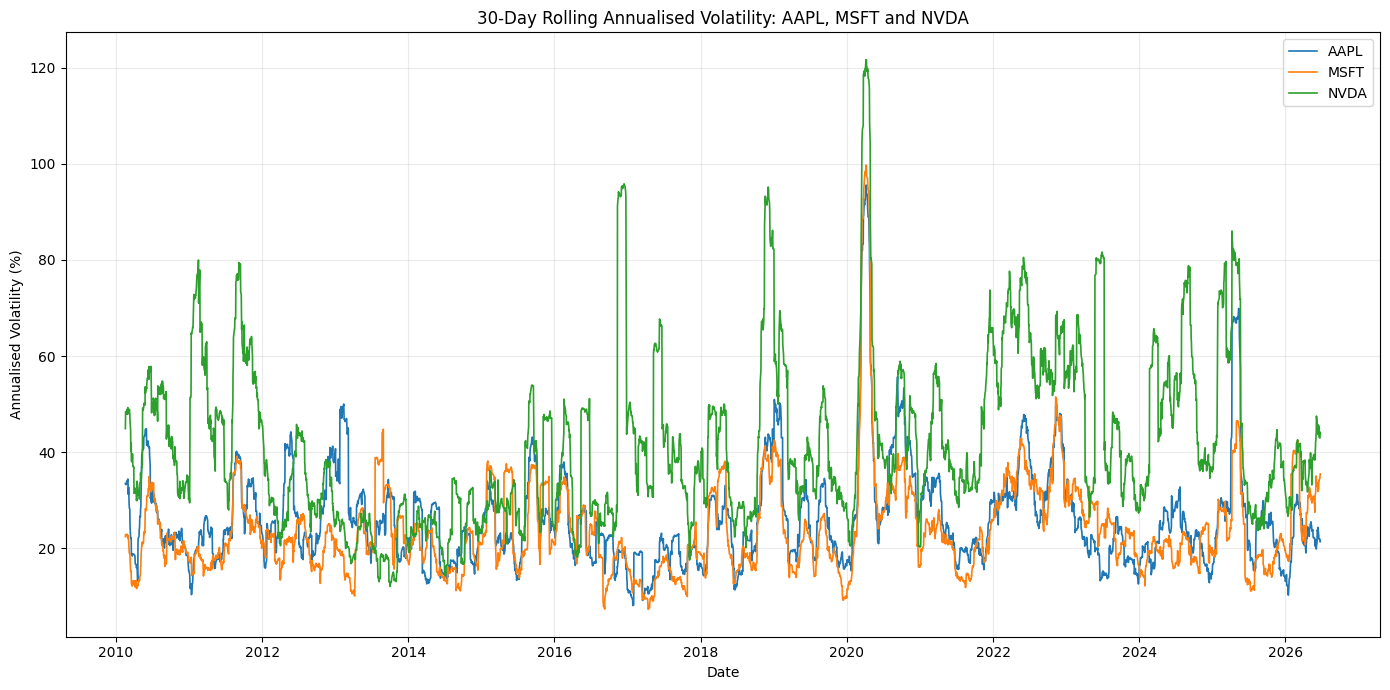

In [52]:
# ============================================================
# SECTION 18 — ROLLING VOLATILITY ANALYSIS
# AAPL, MSFT and NVDA
# ============================================================

plt.figure(
    figsize=(14, 7)
)


for company, file_path \
        in DATASETS.items():

    df = load_and_prepare_stock(
        file_path
    )

    # 30-day rolling standard deviation
    # annualised using 252 trading days
    df[
        "Rolling_Volatility_30"
    ] = (
        df[
            "Return_1d"
        ]
        .rolling(30)
        .std()
        * np.sqrt(252)
        * 100
    )

    plt.plot(
        df["Date"],
        df[
            "Rolling_Volatility_30"
        ],
        label=company,
        linewidth=1.2
    )


plt.title(
    "30-Day Rolling Annualised Volatility: "
    "AAPL, MSFT and NVDA"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Annualised Volatility (%)"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    "rolling_volatility_three_companies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

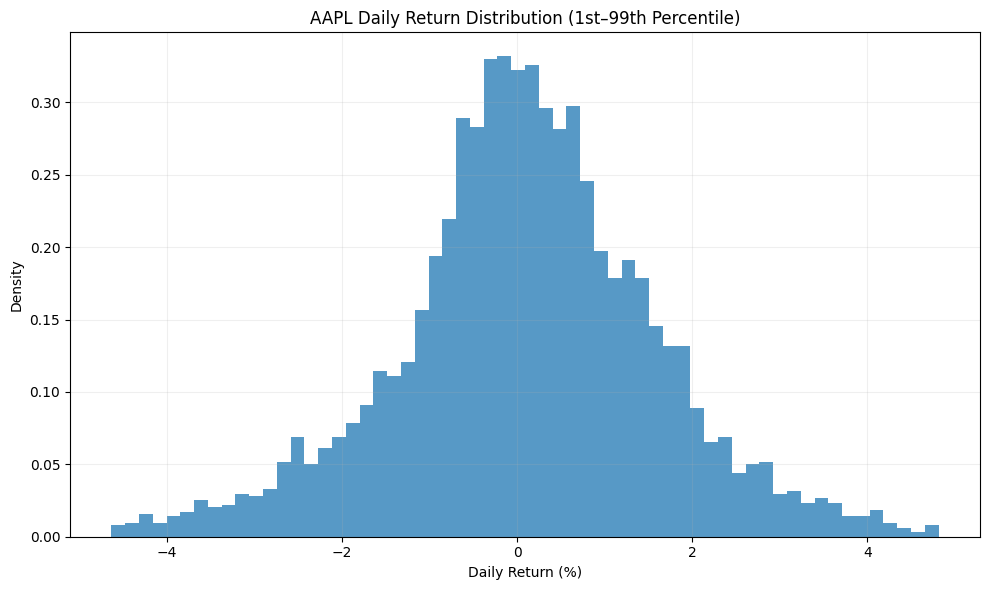

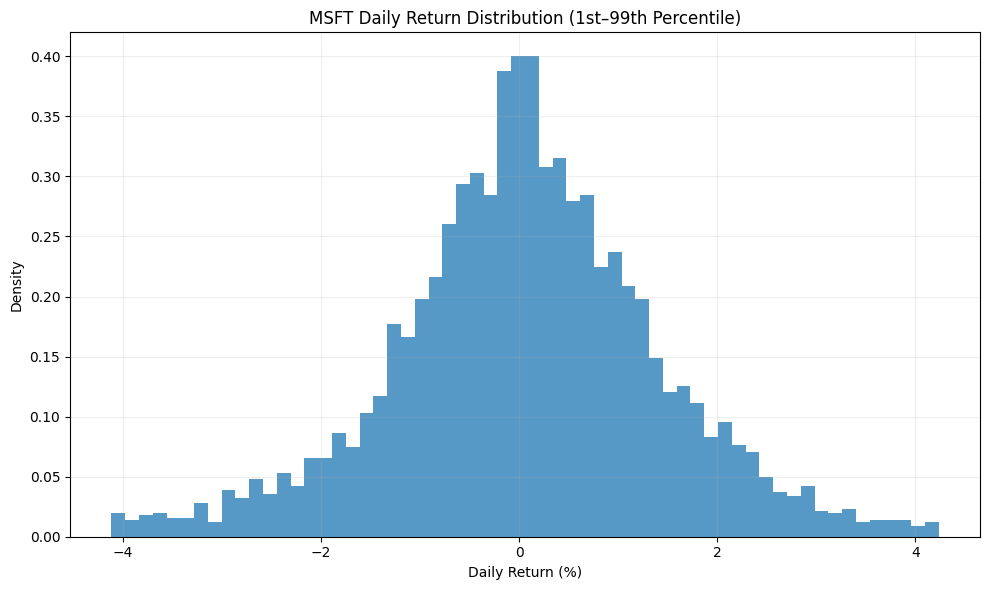

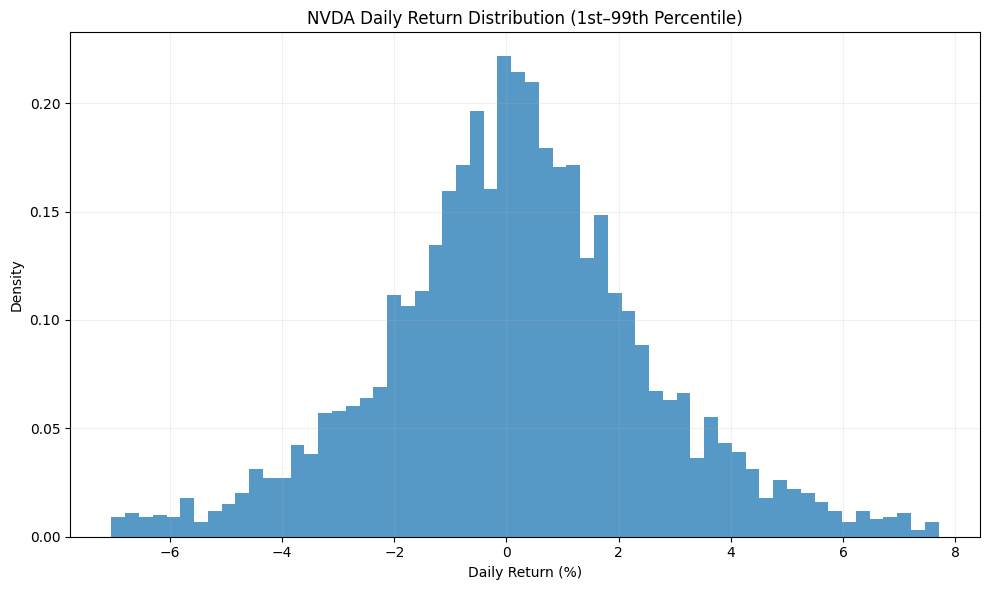

In [53]:
# ============================================================
# SECTION 19 — RETURN DISTRIBUTION ANALYSIS
# AAPL, MSFT and NVDA
# ============================================================

for company, file_path \
        in DATASETS.items():

    df = load_and_prepare_stock(
        file_path
    )

    returns = (
        df[
            "Return_1d"
        ]
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
        * 100
    )


    # --------------------------------------------------------
    # Restrict the DISPLAY to the 1st–99th percentile.
    #
    # This affects visualisation only.
    # The full return series is retained for statistical tests.
    # --------------------------------------------------------

    lower = returns.quantile(
        0.01
    )

    upper = returns.quantile(
        0.99
    )

    display_returns = (
        returns[
            (
                returns
                >= lower
            )
            &
            (
                returns
                <= upper
            )
        ]
    )


    plt.figure(
        figsize=(10, 6)
    )

    plt.hist(
        display_returns,
        bins=60,
        density=True,
        alpha=0.75
    )

    plt.title(
        f"{company} Daily Return Distribution "
        "(1st–99th Percentile)"
    )

    plt.xlabel(
        "Daily Return (%)"
    )

    plt.ylabel(
        "Density"
    )

    plt.grid(
        alpha=0.20
    )

    plt.tight_layout()


    plt.savefig(
        f"{company}_return_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

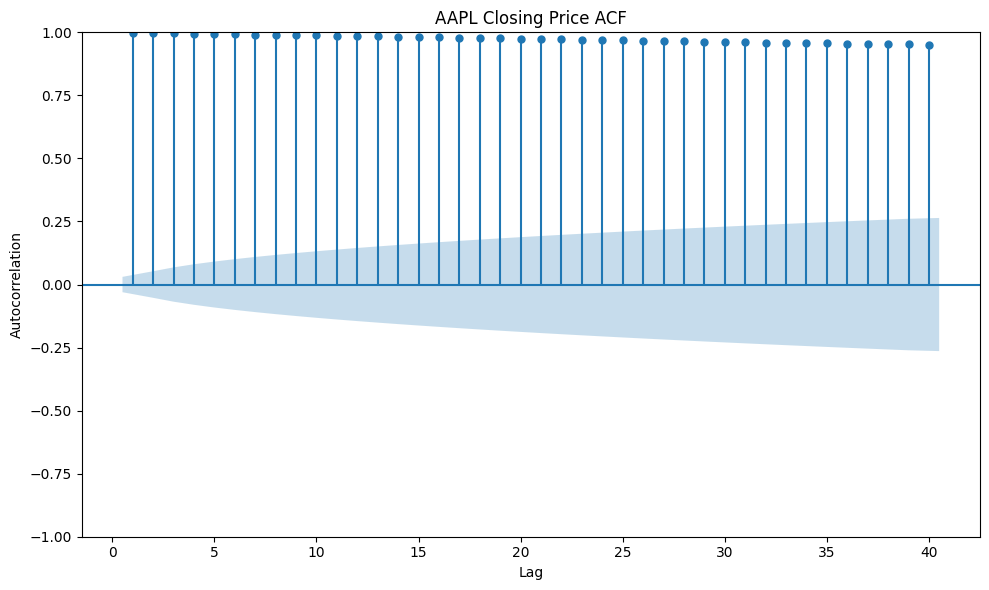

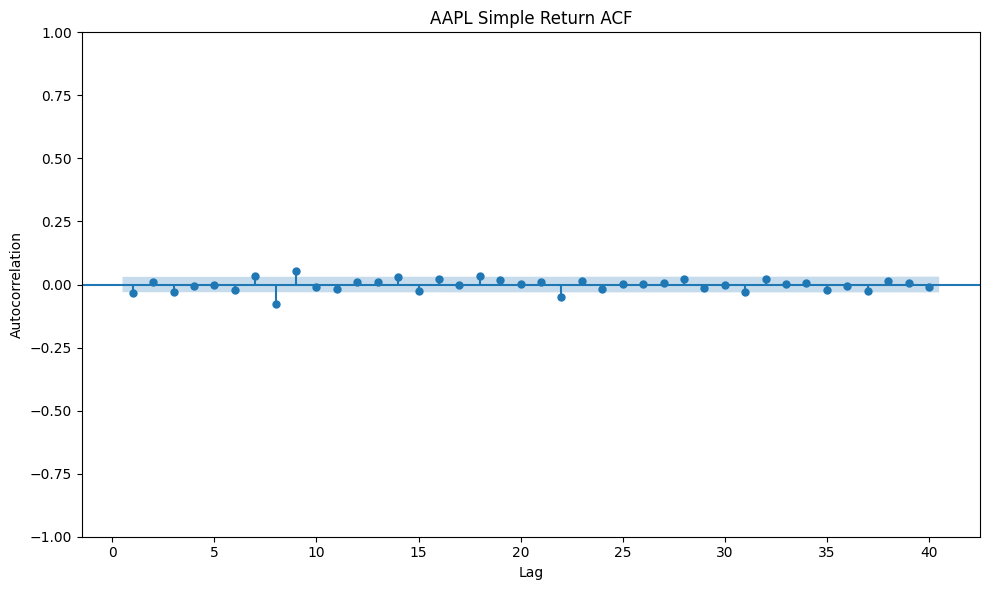

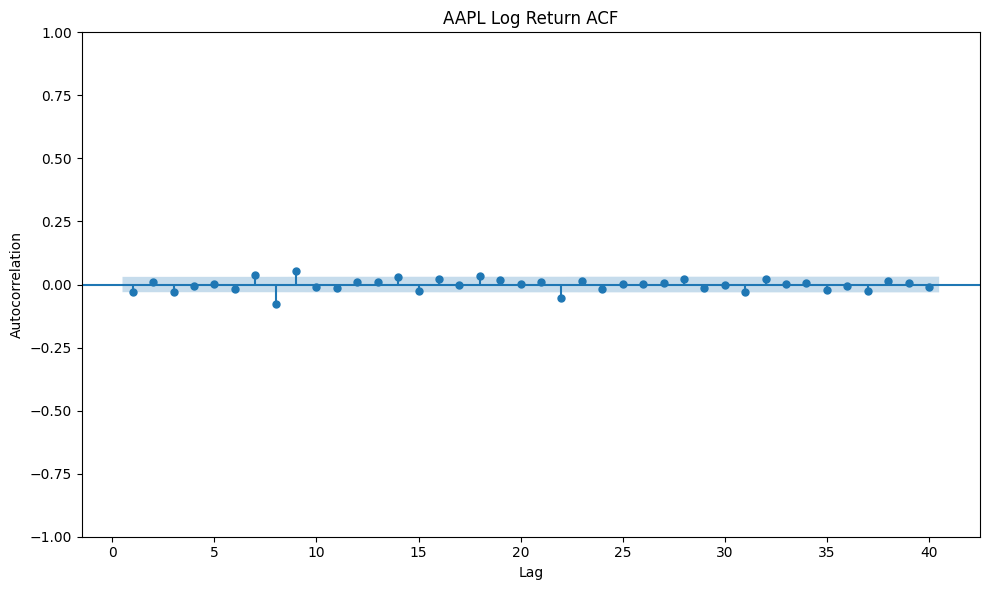

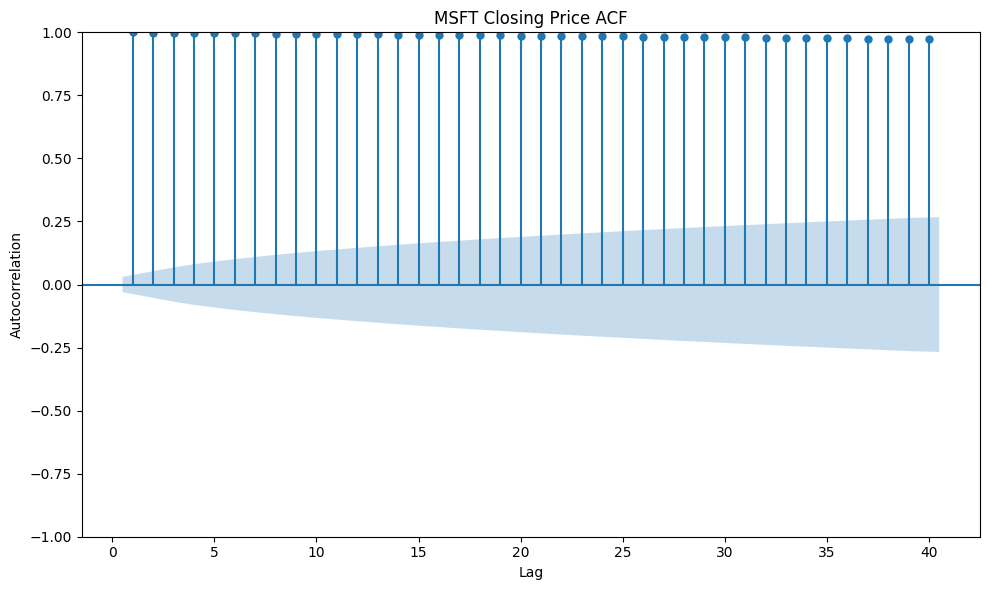

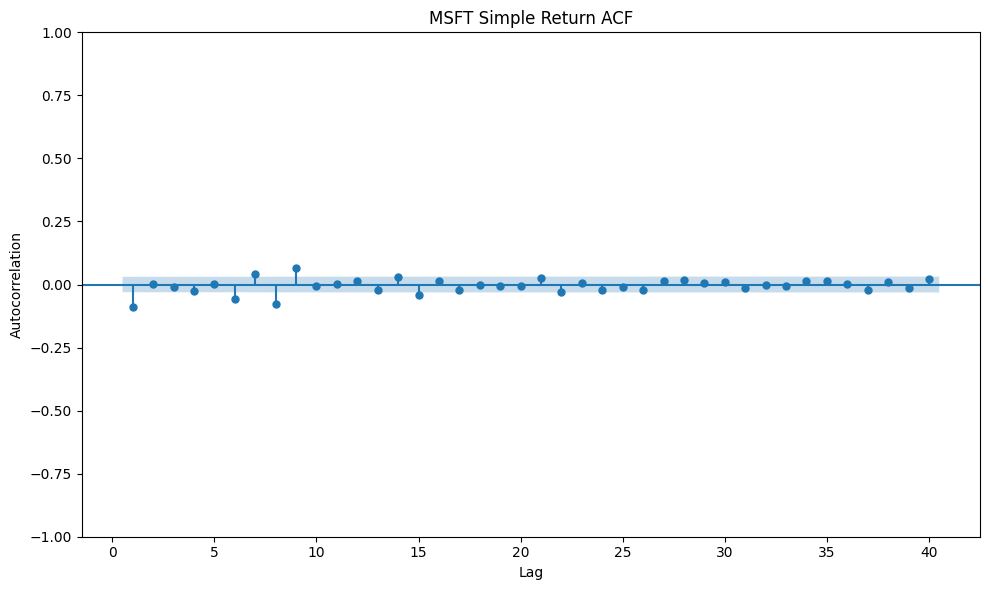

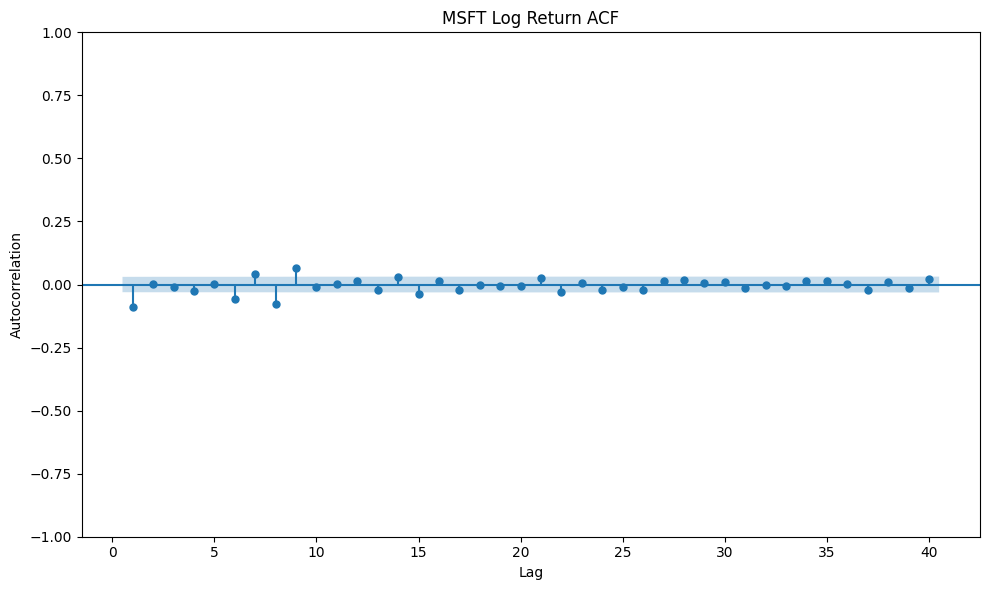

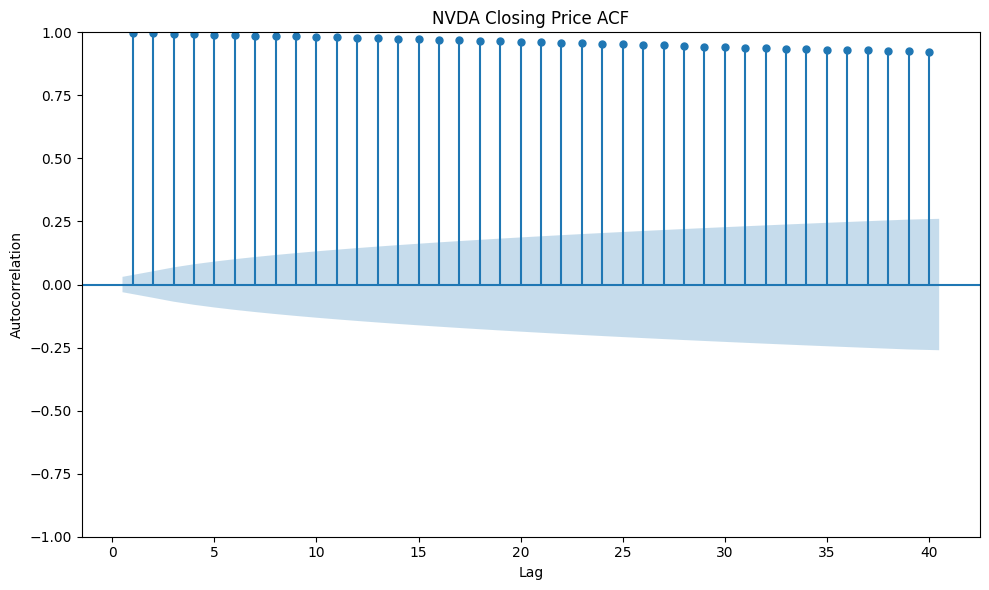

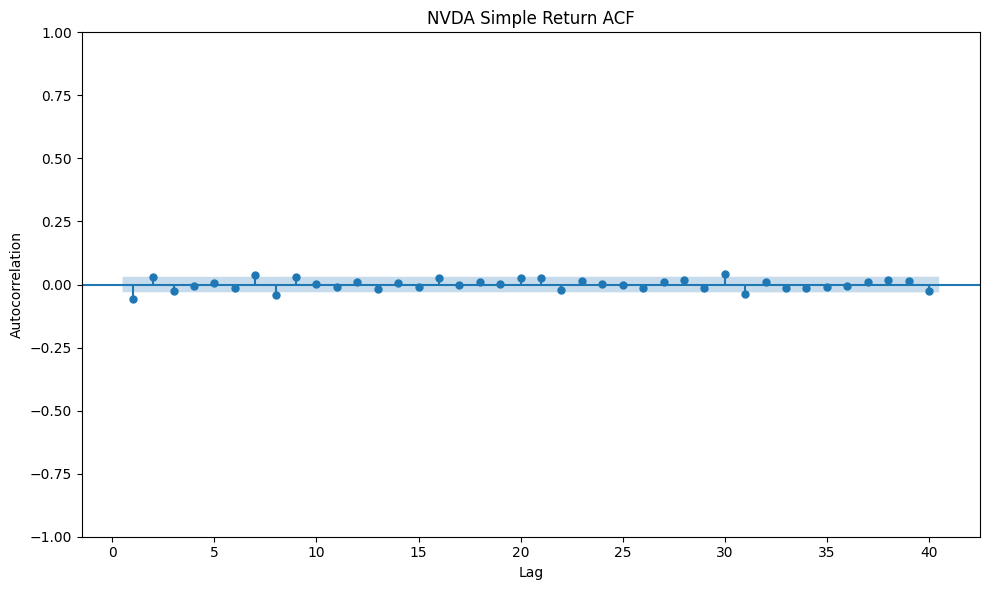

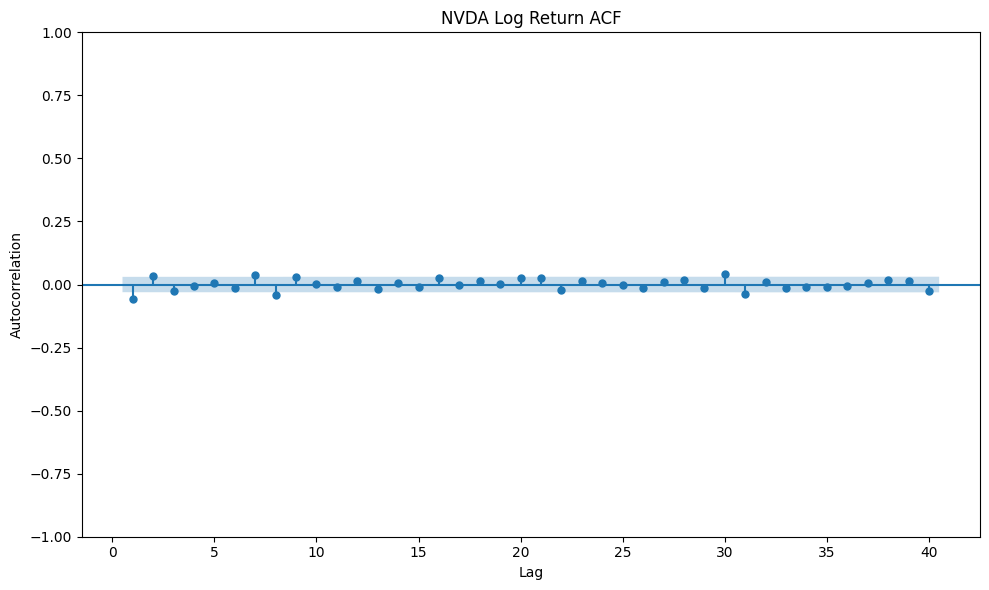

In [54]:
# ============================================================
# SECTION 20 — PRICE VS RETURN ACF PLOTS
# AAPL, MSFT and NVDA
# ============================================================

from statsmodels.graphics.tsaplots import plot_acf


MAX_LAGS = 40


for company, file_path \
        in DATASETS.items():

    df = load_and_prepare_stock(
        file_path
    )


    price_series = (
        df[
            "Close"
        ]
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
        .astype(float)
    )


    return_series = (
        df[
            "Return_1d"
        ]
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
        .astype(float)
    )


    log_return_series = (
        df[
            "Log_Return"
        ]
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
        .astype(float)
    )


    # ========================================================
    # PRICE ACF
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    plot_acf(
        price_series,
        lags=MAX_LAGS,
        zero=False,
        alpha=0.05,
        ax=ax
    )

    ax.set_title(
        f"{company} Closing Price ACF"
    )

    ax.set_xlabel(
        "Lag"
    )

    ax.set_ylabel(
        "Autocorrelation"
    )

    fig.tight_layout()


    fig.savefig(
        f"{company}_price_acf.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # ========================================================
    # SIMPLE RETURN ACF
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    plot_acf(
        return_series,
        lags=MAX_LAGS,
        zero=False,
        alpha=0.05,
        ax=ax
    )

    ax.set_title(
        f"{company} Simple Return ACF"
    )

    ax.set_xlabel(
        "Lag"
    )

    ax.set_ylabel(
        "Autocorrelation"
    )

    fig.tight_layout()


    fig.savefig(
        f"{company}_simple_return_acf.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # ========================================================
    # LOG RETURN ACF
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    plot_acf(
        log_return_series,
        lags=MAX_LAGS,
        zero=False,
        alpha=0.05,
        ax=ax
    )

    ax.set_title(
        f"{company} Log Return ACF"
    )

    ax.set_xlabel(
        "Lag"
    )

    ax.set_ylabel(
        "Autocorrelation"
    )

    fig.tight_layout()


    fig.savefig(
        f"{company}_log_return_acf.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [55]:
# ============================================================
# SECTION 21 — ACF NUMERICAL SUMMARY
# Selected lags for price, simple return and log return
# ============================================================

from statsmodels.tsa.stattools import acf


acf_records = []

SELECTED_LAGS = [
    1,
    5,
    10,
    20,
    40
]


for company, file_path \
        in DATASETS.items():

    df = load_and_prepare_stock(
        file_path
    )


    series_dict = {

        "Price":
            (
                df[
                    "Close"
                ]
                .replace(
                    [
                        np.inf,
                        -np.inf
                    ],
                    np.nan
                )
                .dropna()
                .astype(float)
            ),

        "Simple_Return":
            (
                df[
                    "Return_1d"
                ]
                .replace(
                    [
                        np.inf,
                        -np.inf
                    ],
                    np.nan
                )
                .dropna()
                .astype(float)
            ),

        "Log_Return":
            (
                df[
                    "Log_Return"
                ]
                .replace(
                    [
                        np.inf,
                        -np.inf
                    ],
                    np.nan
                )
                .dropna()
                .astype(float)
            )
    }


    for (
        variable_name,
        series
    ) in series_dict.items():

        acf_values = acf(
            series,
            nlags=MAX_LAGS,
            fft=True
        )


        record = {

            "Company":
                company,

            "Variable":
                variable_name
        }


        for lag in SELECTED_LAGS:

            record[
                f"ACF_Lag_{lag}"
            ] = (
                acf_values[
                    lag
                ]
            )


        acf_records.append(
            record
        )


acf_summary_df = (
    pd.DataFrame(
        acf_records
    )
)


print(
    "\n===== ACF NUMERICAL SUMMARY ====="
)


print(
    acf_summary_df.to_string(
        index=False
    )
)


acf_summary_df.to_csv(
    "price_vs_return_acf_summary.csv",
    index=False
)


print(
    "\nSaved: "
    "price_vs_return_acf_summary.csv"
)


===== ACF NUMERICAL SUMMARY =====
Company      Variable  ACF_Lag_1  ACF_Lag_5  ACF_Lag_10  ACF_Lag_20  ACF_Lag_40
   AAPL         Price   0.998776   0.993757    0.987747    0.974741    0.951049
   AAPL Simple_Return  -0.033447  -0.001497   -0.011637    0.003247   -0.008974
   AAPL    Log_Return  -0.031074   0.000460   -0.011337    0.003732   -0.008876
   MSFT         Price   0.999396   0.997031    0.993924    0.986856    0.973157
   MSFT Simple_Return  -0.088363   0.001166   -0.007743   -0.004590    0.022368
   MSFT    Log_Return  -0.087412   0.002505   -0.008249   -0.004874    0.022592
   NVDA         Price   0.998173   0.990742    0.981895    0.962864    0.922871
   NVDA Simple_Return  -0.058048   0.007344    0.002580    0.027210   -0.023722
   NVDA    Log_Return  -0.056280   0.007684    0.002910    0.027733   -0.023876

Saved: price_vs_return_acf_summary.csv


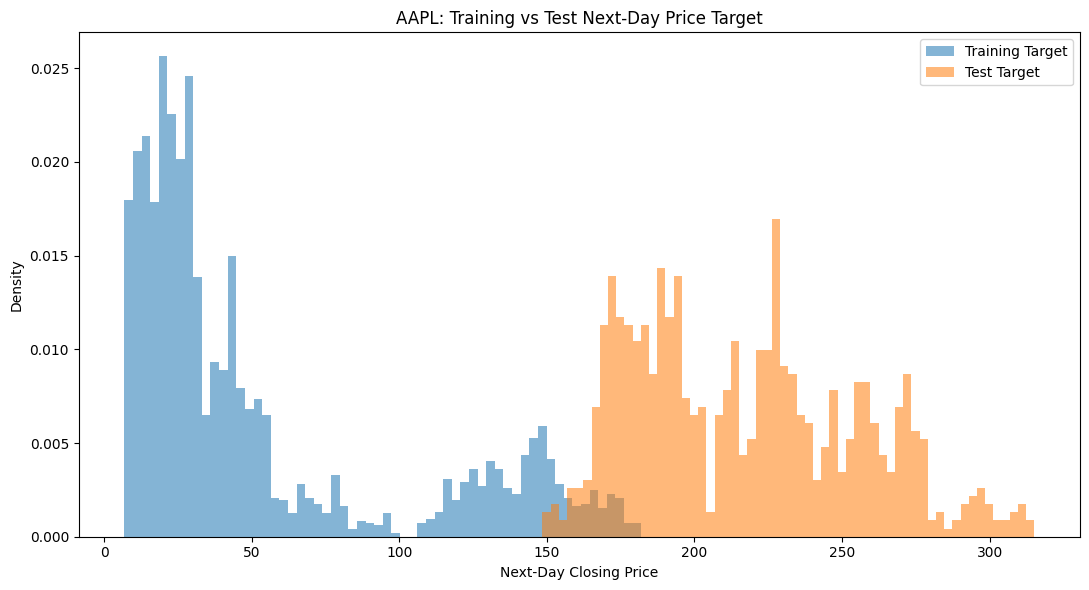

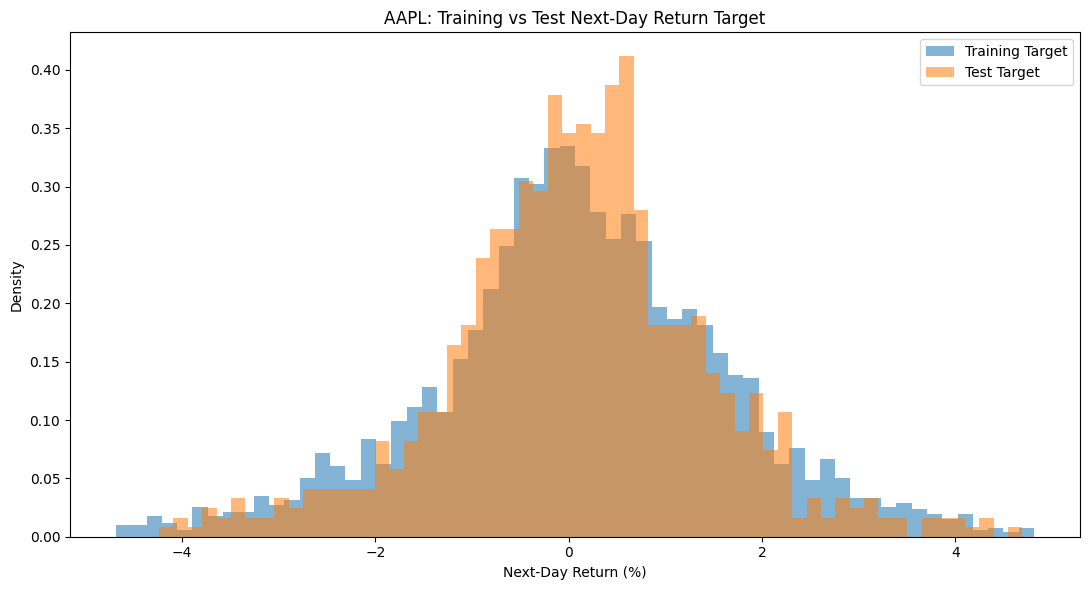

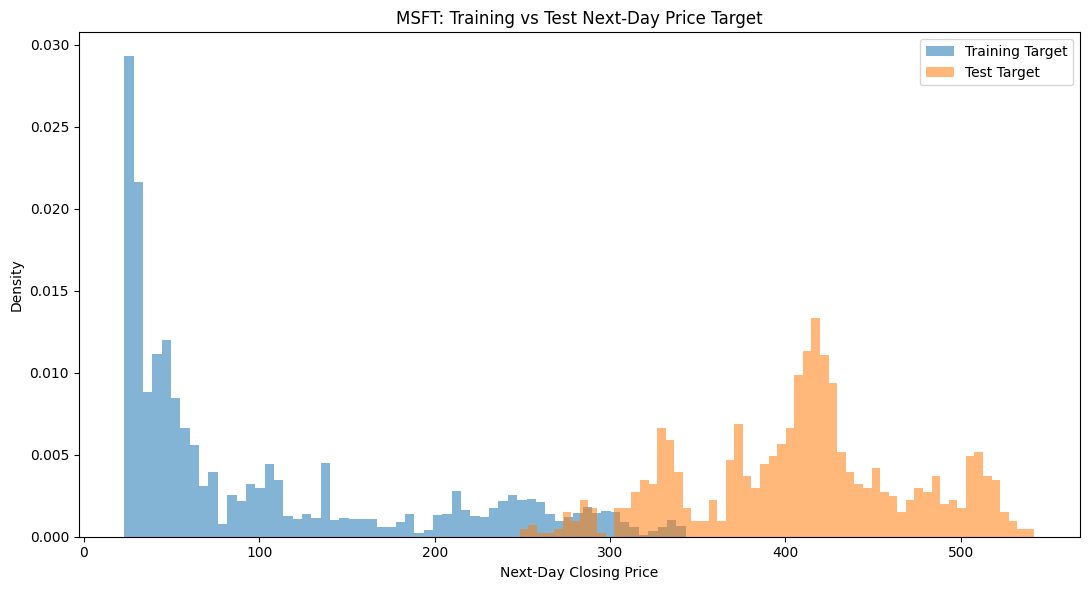

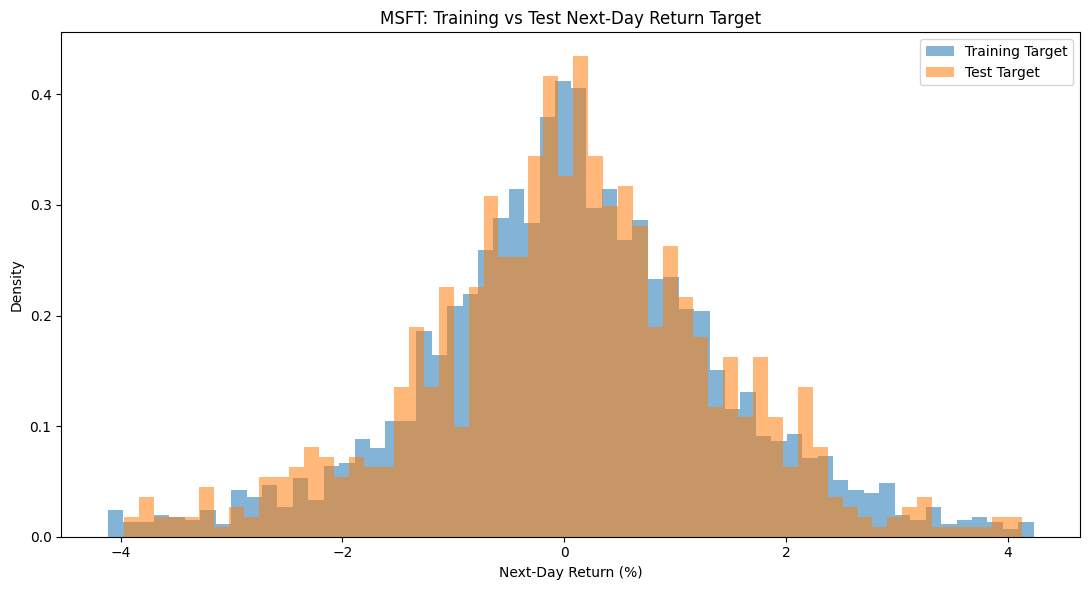

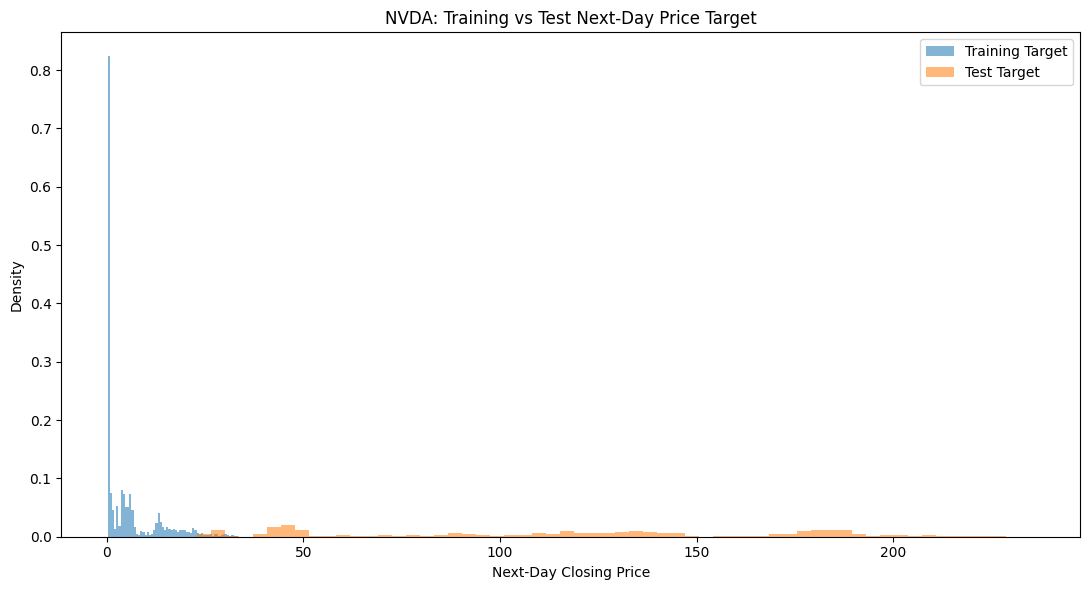

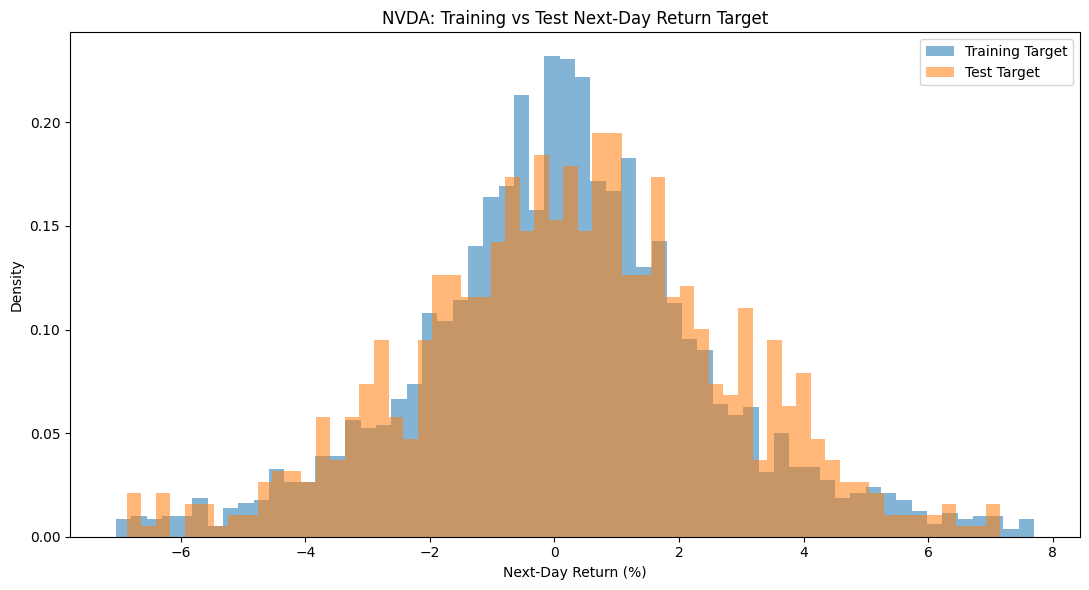

In [56]:
# ============================================================
# SECTION 22 — TRAIN / TEST TARGET DISTRIBUTIONS
# Histogram density comparison
# ============================================================


def prepare_target_split(
    file_path,
    train_ratio=0.80
):
    """
    Create the chronological train/test split used
    in the controlled target-representation analysis.
    """

    df = (
        load_and_prepare_stock(
            file_path
        )
        .copy()
    )


    required_cols = [
        "Date",
        "Close",
        "Target_Next_Close",
        "Target_Next_Return"
    ]


    clean_df = (
        df[
            required_cols
        ]
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
        .sort_values(
            "Date"
        )
        .reset_index(
            drop=True
        )
    )


    split_index = int(
        len(clean_df)
        * train_ratio
    )


    train_df = (
        clean_df
        .iloc[
            :split_index
        ]
        .copy()
    )


    test_df = (
        clean_df
        .iloc[
            split_index:
        ]
        .copy()
    )


    return (
        train_df,
        test_df
    )


for company, file_path \
        in DATASETS.items():

    train_df, test_df = (
        prepare_target_split(
            file_path=file_path,
            train_ratio=TRAIN_RATIO
        )
    )


    # ========================================================
    # PRICE TARGET DISTRIBUTION
    # ========================================================

    train_price = (
        train_df[
            "Target_Next_Close"
        ]
        .to_numpy(
            dtype=float
        )
    )


    test_price = (
        test_df[
            "Target_Next_Close"
        ]
        .to_numpy(
            dtype=float
        )
    )


    plt.figure(
        figsize=(11, 6)
    )


    plt.hist(
        train_price,
        bins=60,
        density=True,
        alpha=0.55,
        label="Training Target"
    )


    plt.hist(
        test_price,
        bins=60,
        density=True,
        alpha=0.55,
        label="Test Target"
    )


    plt.title(
        f"{company}: Training vs Test "
        "Next-Day Price Target"
    )

    plt.xlabel(
        "Next-Day Closing Price"
    )

    plt.ylabel(
        "Density"
    )

    plt.legend()

    plt.tight_layout()


    plt.savefig(
        f"{company}_train_test_price_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # ========================================================
    # RETURN TARGET DISTRIBUTION
    # ========================================================

    train_return = (
        train_df[
            "Target_Next_Return"
        ]
        .to_numpy(
            dtype=float
        )
        * 100
    )


    test_return = (
        test_df[
            "Target_Next_Return"
        ]
        .to_numpy(
            dtype=float
        )
        * 100
    )


    # Display range based on combined
    # 1st–99th percentile only.
    all_returns = np.concatenate(
        [
            train_return,
            test_return
        ]
    )


    lower = np.quantile(
        all_returns,
        0.01
    )

    upper = np.quantile(
        all_returns,
        0.99
    )


    train_display = (
        train_return[
            (
                train_return
                >= lower
            )
            &
            (
                train_return
                <= upper
            )
        ]
    )


    test_display = (
        test_return[
            (
                test_return
                >= lower
            )
            &
            (
                test_return
                <= upper
            )
        ]
    )


    plt.figure(
        figsize=(11, 6)
    )


    plt.hist(
        train_display,
        bins=60,
        density=True,
        alpha=0.55,
        label="Training Target"
    )


    plt.hist(
        test_display,
        bins=60,
        density=True,
        alpha=0.55,
        label="Test Target"
    )


    plt.title(
        f"{company}: Training vs Test "
        "Next-Day Return Target"
    )

    plt.xlabel(
        "Next-Day Return (%)"
    )

    plt.ylabel(
        "Density"
    )

    plt.legend()

    plt.tight_layout()


    plt.savefig(
        f"{company}_train_test_return_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

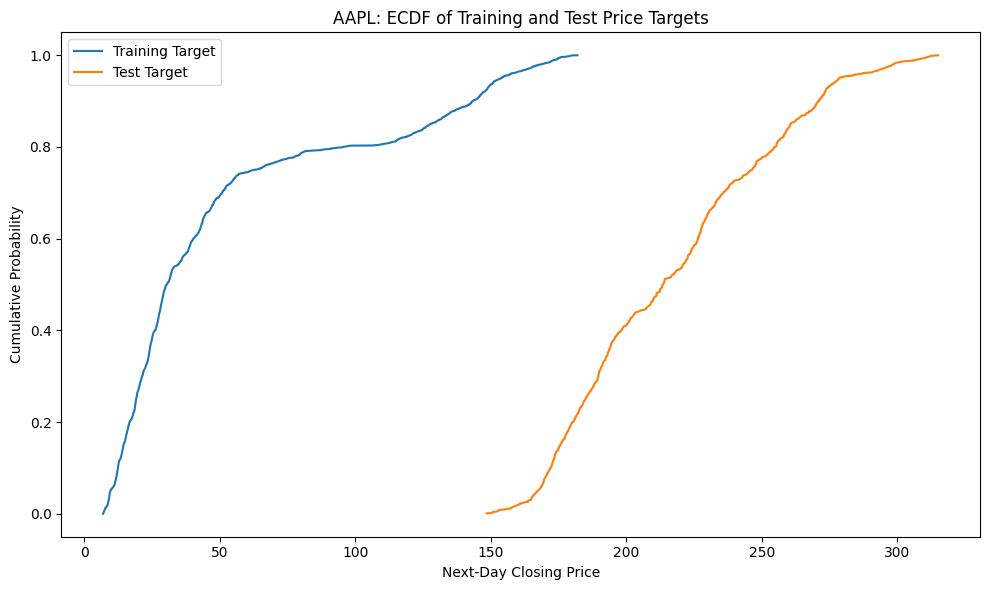

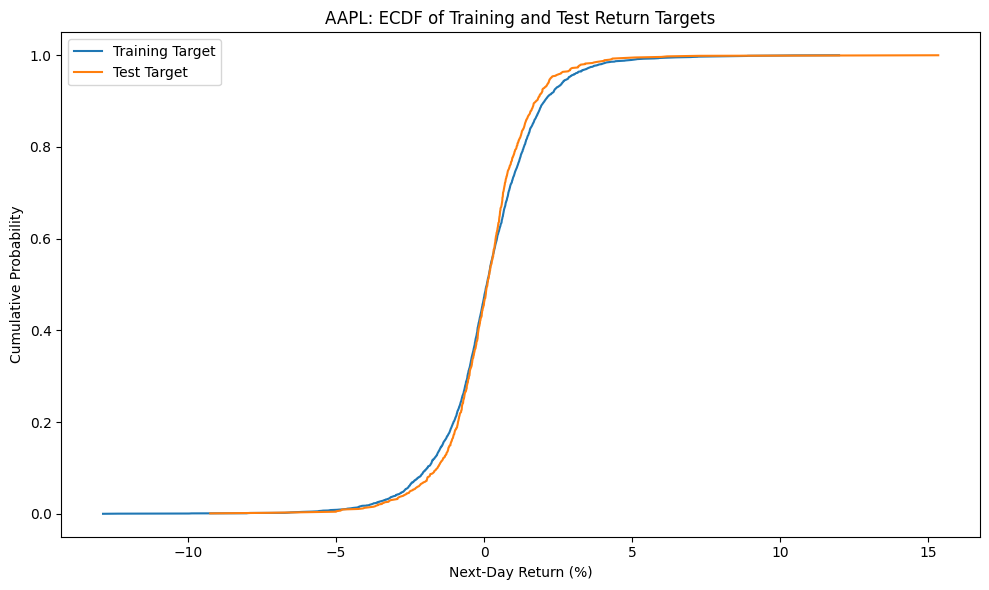

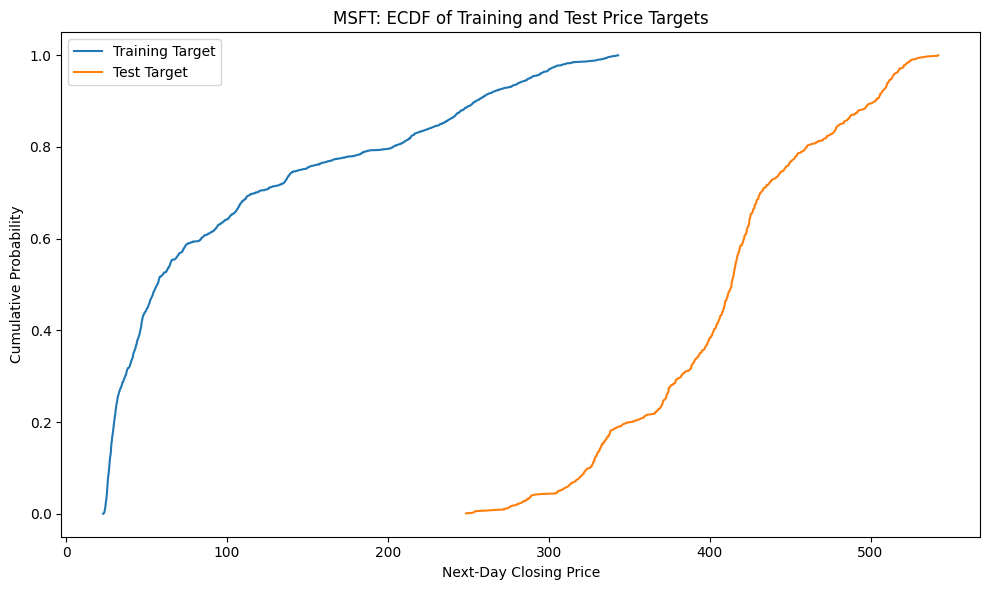

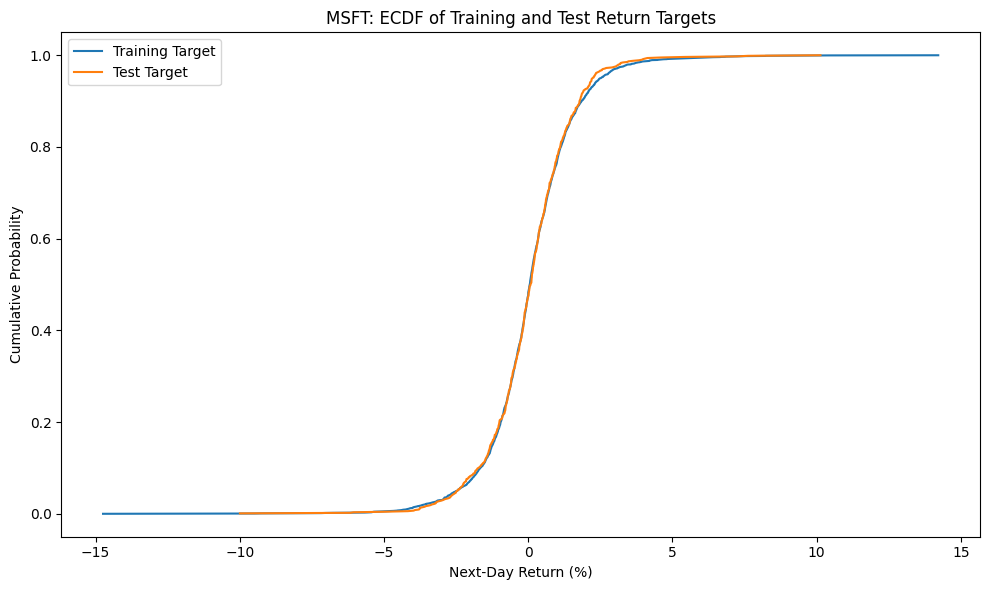

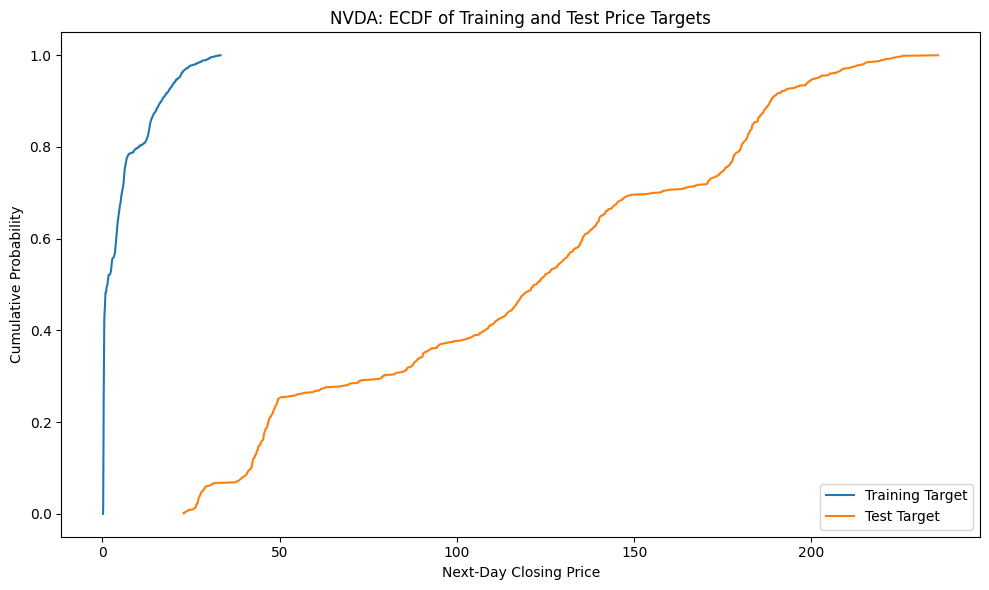

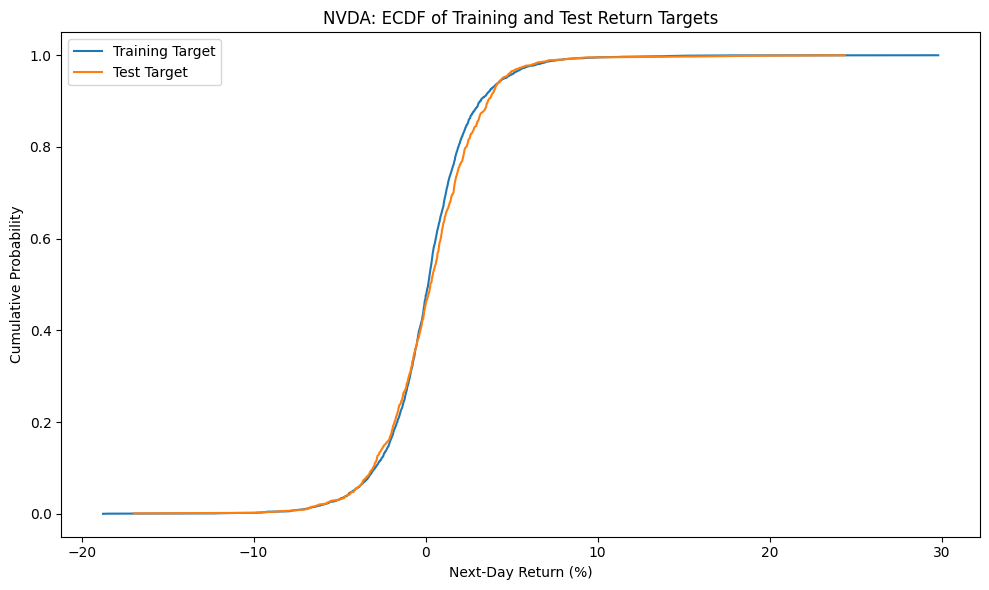

In [57]:
# ============================================================
# SECTION 23 — TRAIN / TEST EMPIRICAL CDF
# Price target and return target
# ============================================================


def empirical_cdf(
    values
):
    """
    Return sorted finite values and
    corresponding empirical cumulative probabilities.
    """

    values = np.asarray(
        values,
        dtype=float
    )


    values = (
        values[
            np.isfinite(
                values
            )
        ]
    )


    if len(values) == 0:

        raise ValueError(
            "Cannot calculate an empirical CDF "
            "for an empty series."
        )


    sorted_values = (
        np.sort(
            values
        )
    )


    cumulative_probabilities = (
        np.arange(
            1,
            len(
                sorted_values
            )
            + 1
        )
        / len(
            sorted_values
        )
    )


    return (
        sorted_values,
        cumulative_probabilities
    )


for company, file_path \
        in DATASETS.items():

    train_df, test_df = (
        prepare_target_split(
            file_path=file_path,
            train_ratio=TRAIN_RATIO
        )
    )


    # ========================================================
    # PRICE TARGET ECDF
    # ========================================================

    (
        train_price_x,
        train_price_y
    ) = empirical_cdf(
        train_df[
            "Target_Next_Close"
        ]
    )


    (
        test_price_x,
        test_price_y
    ) = empirical_cdf(
        test_df[
            "Target_Next_Close"
        ]
    )


    plt.figure(
        figsize=(10, 6)
    )


    plt.plot(
        train_price_x,
        train_price_y,
        label="Training Target"
    )


    plt.plot(
        test_price_x,
        test_price_y,
        label="Test Target"
    )


    plt.title(
        f"{company}: ECDF of Training "
        "and Test Price Targets"
    )

    plt.xlabel(
        "Next-Day Closing Price"
    )

    plt.ylabel(
        "Cumulative Probability"
    )

    plt.legend()

    plt.tight_layout()


    plt.savefig(
        f"{company}_train_test_price_ecdf.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # ========================================================
    # RETURN TARGET ECDF
    # ========================================================

    (
        train_return_x,
        train_return_y
    ) = empirical_cdf(
        train_df[
            "Target_Next_Return"
        ]
        * 100
    )


    (
        test_return_x,
        test_return_y
    ) = empirical_cdf(
        test_df[
            "Target_Next_Return"
        ]
        * 100
    )


    plt.figure(
        figsize=(10, 6)
    )


    plt.plot(
        train_return_x,
        train_return_y,
        label="Training Target"
    )


    plt.plot(
        test_return_x,
        test_return_y,
        label="Test Target"
    )


    plt.title(
        f"{company}: ECDF of Training "
        "and Test Return Targets"
    )

    plt.xlabel(
        "Next-Day Return (%)"
    )

    plt.ylabel(
        "Cumulative Probability"
    )

    plt.legend()

    plt.tight_layout()


    plt.savefig(
        f"{company}_train_test_return_ecdf.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [58]:
# ============================================================
# SECTION 24 — TRAIN / TEST DISTRIBUTION SHIFT STATISTICS
# Kolmogorov–Smirnov test and Wasserstein distance
# ============================================================

from scipy.stats import (
    ks_2samp,
    wasserstein_distance
)


distribution_shift_records = []


for company, file_path \
        in DATASETS.items():

    train_df, test_df = (
        prepare_target_split(
            file_path=file_path,
            train_ratio=TRAIN_RATIO
        )
    )


    target_dict = {

        "Price":
            (
                train_df[
                    "Target_Next_Close"
                ]
                .to_numpy(
                    dtype=float
                ),

                test_df[
                    "Target_Next_Close"
                ]
                .to_numpy(
                    dtype=float
                )
            ),

        "Return":
            (
                train_df[
                    "Target_Next_Return"
                ]
                .to_numpy(
                    dtype=float
                ),

                test_df[
                    "Target_Next_Return"
                ]
                .to_numpy(
                    dtype=float
                )
            )
    }


    for (
        target_name,
        (
            train_values,
            test_values
        )
    ) in target_dict.items():


        train_values = (
            train_values[
                np.isfinite(
                    train_values
                )
            ]
        )


        test_values = (
            test_values[
                np.isfinite(
                    test_values
                )
            ]
        )


        # ----------------------------------------------------
        # Kolmogorov–Smirnov two-sample test
        # ----------------------------------------------------

        ks_result = (
            ks_2samp(
                train_values,
                test_values,
                alternative="two-sided",
                method="auto"
            )
        )


        # ----------------------------------------------------
        # Raw Wasserstein distance
        # ----------------------------------------------------

        wasserstein_raw = (
            wasserstein_distance(
                train_values,
                test_values
            )
        )


        # ----------------------------------------------------
        # Scale-standardised Wasserstein distance
        # Allows more meaningful comparison between
        # price and return targets.
        # ----------------------------------------------------

        pooled_values = (
            np.concatenate(
                [
                    train_values,
                    test_values
                ]
            )
        )


        pooled_std = np.std(
            pooled_values,
            ddof=1
        )


        if (
            np.isfinite(
                pooled_std
            )
            and pooled_std > 0
        ):

            wasserstein_standardised = (
                wasserstein_raw
                / pooled_std
            )

        else:

            wasserstein_standardised = (
                np.nan
            )


        distribution_shift_records.append({

            "Company":
                company,

            "Target":
                target_name,

            "Train Observations":
                len(
                    train_values
                ),

            "Test Observations":
                len(
                    test_values
                ),

            "Train Mean":
                np.mean(
                    train_values
                ),

            "Test Mean":
                np.mean(
                    test_values
                ),

            "Train Std":
                np.std(
                    train_values,
                    ddof=1
                ),

            "Test Std":
                np.std(
                    test_values,
                    ddof=1
                ),

            "KS Statistic":
                ks_result.statistic,

            "KS p-value":
                ks_result.pvalue,

            "Wasserstein Distance":
                wasserstein_raw,

            "Standardised Wasserstein Distance":
                wasserstein_standardised,

            "Distribution Shift":
                (
                    "Statistically significant"
                    if (
                        ks_result.pvalue
                        < 0.05
                    )
                    else
                    "Not statistically significant"
                )
        })


distribution_shift_df = (
    pd.DataFrame(
        distribution_shift_records
    )
)


print(
    "\n===== TRAIN / TEST "
    "DISTRIBUTION SHIFT ====="
)


print(
    distribution_shift_df.to_string(
        index=False
    )
)


distribution_shift_df.to_csv(
    "train_test_target_distribution_shift.csv",
    index=False
)


print(
    "\nSaved: "
    "train_test_target_distribution_shift.csv"
)


===== TRAIN / TEST DISTRIBUTION SHIFT =====
Company Target  Train Observations  Test Observations  Train Mean  Test Mean  Train Std  Test Std  KS Statistic    KS p-value  Wasserstein Distance  Standardised Wasserstein Distance            Distribution Shift
   AAPL  Price                3314                829   52.533294 217.114451  48.208509 37.653678      0.948709 4.446591e-323            164.581157                           2.044705     Statistically significant
   AAPL Return                3314                829    0.001070   0.000831   0.018082  0.016129      0.054469  3.741953e-02              0.001962                           0.110800     Statistically significant
   MSFT  Price                3314                829  102.062734 409.312678  89.292869 62.103006      0.932435 1.235164e-322            307.249944                           2.059257     Statistically significant
   MSFT Return                3314                829    0.000774   0.000502   0.016443  0.015418      

In [59]:
# ============================================================
# SECTION 25 — COMPACT DISTRIBUTION SHIFT SUMMARY
# Price target vs return target
# ============================================================

distribution_shift_summary_df = (
    distribution_shift_df[
        [
            "Company",
            "Target",
            "KS Statistic",
            "KS p-value",
            "Standardised Wasserstein Distance"
        ]
    ]
    .pivot(
        index="Company",
        columns="Target"
    )
)


distribution_shift_summary_df.columns = [
    f"{metric}_{target}"
    for (
        metric,
        target
    )
    in distribution_shift_summary_df.columns
]


distribution_shift_summary_df = (
    distribution_shift_summary_df
    .reset_index()
)


print(
    "\n===== PRICE VS RETURN "
    "DISTRIBUTION SHIFT SUMMARY ====="
)


print(
    distribution_shift_summary_df.to_string(
        index=False
    )
)


distribution_shift_summary_df.to_csv(
    "price_vs_return_distribution_shift_summary.csv",
    index=False
)


===== PRICE VS RETURN DISTRIBUTION SHIFT SUMMARY =====
Company  KS Statistic_Price  KS Statistic_Return  KS p-value_Price  KS p-value_Return  Standardised Wasserstein Distance_Price  Standardised Wasserstein Distance_Return
   AAPL            0.948709             0.054469     4.446591e-323           0.037420                                 2.044705                                  0.110800
   MSFT            0.932435             0.020521     1.235164e-322           0.936267                                 2.059257                                  0.041453
   NVDA            0.969830             0.061979      0.000000e+00           0.011641                                 2.150329                                  0.085835


In [60]:
# ============================================================
# SECTION 26 — VARIANCE RATIO TEST
# Lo–MacKinlay-style heteroskedasticity-robust test
# ============================================================

from scipy import stats


def variance_ratio_test(
    price_series,
    lag=2,
    robust=True
):
    """
    Variance-ratio test applied to a positive
    stock-price series.

    The test is conducted on log prices.

    Null hypothesis:
        The log-price process is consistent with
        a random walk at aggregation horizon q.

    Parameters
    ----------
    price_series : array-like
        Positive stock prices ordered chronologically.

    lag : int
        Variance-ratio aggregation horizon q.

    robust : bool
        If True, use the heteroskedasticity-robust
        Lo–MacKinlay variance estimator.

    Returns
    -------
    dict
        Variance ratio, test statistic,
        p-value and interpretation.
    """

    prices = (
        pd.Series(
            price_series
        )
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
        .astype(float)
        .to_numpy()
    )


    prices = (
        prices[
            prices > 0
        ]
    )


    if (
        len(prices)
        <= lag + 2
    ):

        raise ValueError(
            f"Insufficient observations "
            f"for lag={lag}."
        )


    log_prices = (
        np.log(
            prices
        )
    )


    # --------------------------------------------------------
    # One-period log returns
    # --------------------------------------------------------

    returns = (
        np.diff(
            log_prices
        )
    )


    n = len(
        returns
    )


    if lag >= n:

        raise ValueError(
            f"Lag {lag} must be smaller "
            f"than the number of returns ({n})."
        )


    mean_return = (
        np.mean(
            returns
        )
    )


    # --------------------------------------------------------
    # One-period variance
    # --------------------------------------------------------

    variance_1 = (
        np.sum(
            (
                returns
                - mean_return
            ) ** 2
        )
        / (
            n - 1
        )
    )


    if (
        not np.isfinite(
            variance_1
        )
        or variance_1 <= 0
    ):

        raise ValueError(
            "One-period return variance "
            "is zero or invalid."
        )


    # --------------------------------------------------------
    # q-period overlapping returns
    # --------------------------------------------------------

    q_returns = (
        log_prices[
            lag:
        ]
        - log_prices[
            :-lag
        ]
    )


    q_mean = (
        lag
        * mean_return
    )


    m = (
        lag
        * (
            n
            - lag
            + 1
        )
        * (
            1
            - lag / n
        )
    )


    variance_q = (
        np.sum(
            (
                q_returns
                - q_mean
            ) ** 2
        )
        / m
    )


    variance_ratio = (
        variance_q
        / variance_1
    )


    # ========================================================
    # ASYMPTOTIC VARIANCE
    # ========================================================

    if robust:

        denominator = (
            np.sum(
                (
                    returns
                    - mean_return
                ) ** 2
            )
            ** 2
        )


        theta = 0.0


        for j in range(
            1,
            lag
        ):

            numerator = np.sum(
                (
                    returns[
                        j:
                    ]
                    - mean_return
                ) ** 2
                *
                (
                    returns[
                        :-j
                    ]
                    - mean_return
                ) ** 2
            )


            delta_j = (
                n
                * numerator
                / denominator
            )


            weight = (
                2
                * (
                    lag
                    - j
                )
                / lag
            ) ** 2


            theta += (
                weight
                * delta_j
            )


    else:

        theta = (
            2
            * (
                2 * lag
                - 1
            )
            * (
                lag
                - 1
            )
            / (
                3
                * lag
                * n
            )
        )


    # ========================================================
    # TEST STATISTIC
    # ========================================================

    if (
        not np.isfinite(
            theta
        )
        or theta <= 0
    ):

        z_statistic = np.nan
        p_value = np.nan

    else:

        z_statistic = (
            variance_ratio
            - 1
        ) / np.sqrt(
            theta
        )


        p_value = (
            2
            * (
                1
                - stats.norm.cdf(
                    abs(
                        z_statistic
                    )
                )
            )
        )


    # ========================================================
    # INTERPRETATION
    # ========================================================

    if np.isnan(
        p_value
    ):

        conclusion = (
            "Test unavailable"
        )

    elif p_value < 0.05:

        conclusion = (
            "Reject random-walk null"
        )

    else:

        conclusion = (
            "Fail to reject random-walk null"
        )


    return {

        "Lag":
            lag,

        "Variance Ratio":
            variance_ratio,

        "Z Statistic":
            z_statistic,

        "p-value":
            p_value,

        "Conclusion":
            conclusion
    }

In [61]:
# ============================================================
# SECTION 27 — RUN VARIANCE RATIO TESTS
# ============================================================

VR_LAGS = [
    2,
    5,
    10,
    20,
    40
]


variance_ratio_records = []


for company, file_path \
        in DATASETS.items():

    df = load_and_prepare_stock(
        file_path
    )


    price_series = (
        df[
            "Close"
        ]
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
        .astype(float)
    )


    for lag in VR_LAGS:

        result = (
            variance_ratio_test(
                price_series=
                    price_series,

                lag=
                    lag,

                robust=
                    True
            )
        )


        variance_ratio_records.append({

            "Company":
                company,

            **result
        })


variance_ratio_results_df = (
    pd.DataFrame(
        variance_ratio_records
    )
)


print(
    "\n===== VARIANCE RATIO "
    "TEST RESULTS ====="
)


print(
    variance_ratio_results_df.to_string(
        index=False
    )
)


variance_ratio_results_df.to_csv(
    "variance_ratio_test_results.csv",
    index=False
)


print(
    "\nSaved: "
    "variance_ratio_test_results.csv"
)


===== VARIANCE RATIO TEST RESULTS =====
Company  Lag  Variance Ratio  Z Statistic  p-value                      Conclusion
   AAPL    2        0.969384    -0.018255 0.985435 Fail to reject random-walk null
   AAPL    5        0.939996    -0.016998 0.986439 Fail to reject random-walk null
   AAPL   10        0.905987    -0.017885 0.985731 Fail to reject random-walk null
   AAPL   20        0.908674    -0.012395 0.990110 Fail to reject random-walk null
   AAPL   40        0.940258    -0.006041 0.995180 Fail to reject random-walk null
   MSFT    2        0.912775    -0.041935 0.966551 Fail to reject random-walk null
   MSFT    5        0.846905    -0.036383 0.970977 Fail to reject random-walk null
   MSFT   10        0.768064    -0.038922 0.968952 Fail to reject random-walk null
   MSFT   20        0.719900    -0.034404 0.972555 Fail to reject random-walk null
   MSFT   40        0.661407    -0.031699 0.974712 Fail to reject random-walk null
   NVDA    2        0.944144    -0.038474 0.96

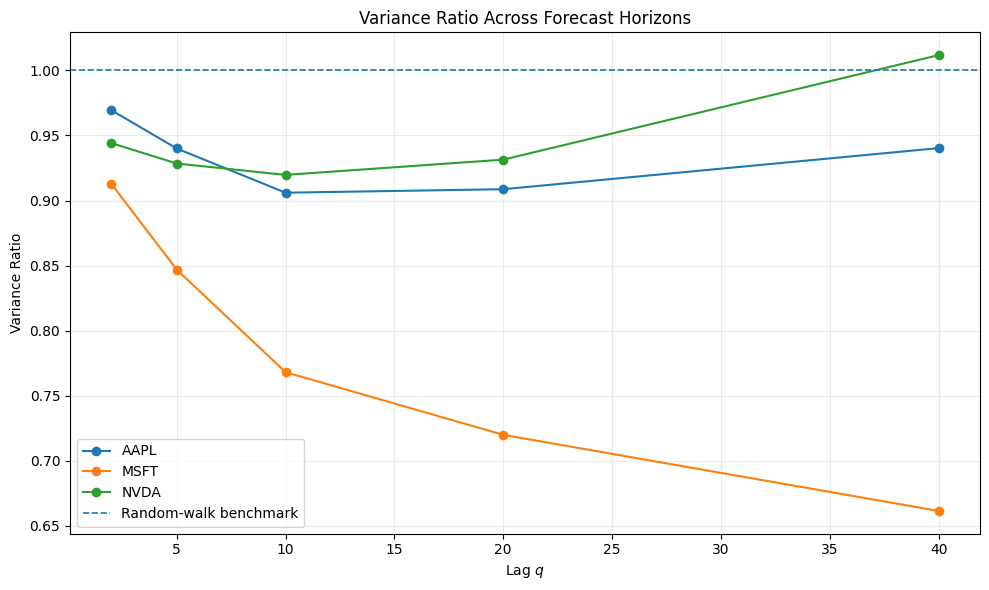

In [62]:
# ============================================================
# SECTION 28 — VARIANCE RATIO COMPARISON PLOT
# ============================================================

plt.figure(
    figsize=(10, 6)
)


for company in DATASETS.keys():

    company_df = (
        variance_ratio_results_df[
            variance_ratio_results_df[
                "Company"
            ]
            == company
        ]
        .sort_values(
            "Lag"
        )
    )


    plt.plot(
        company_df[
            "Lag"
        ],
        company_df[
            "Variance Ratio"
        ],
        marker="o",
        label=company
    )


plt.axhline(
    y=1.0,
    linestyle="--",
    linewidth=1.2,
    label="Random-walk benchmark"
)


plt.title(
    "Variance Ratio Across Forecast Horizons"
)

plt.xlabel(
    "Lag $q$"
)

plt.ylabel(
    "Variance Ratio"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    "variance_ratio_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
# ============================================================
# FIND EXISTING ARIMA / RESIDUAL VARIABLES — SAFE VERSION
# ============================================================

global_items = list(globals().items())

for name, obj in global_items:

    name_lower = name.lower()

    if (
        "resid" in name_lower
        or "arima" in name_lower
    ):

        try:
            shape = getattr(obj, "shape", None)
            length = len(obj) if hasattr(obj, "__len__") else None
        except Exception:
            shape = None
            length = None

        print(
            f"{name:55s}",
            "| type:", type(obj).__name__,
            "| shape:", shape,
            "| len:", length
        )

ARIMA                                                   | type: type | shape: None | len: None
arima_results                                           | type: list | shape: None | len: 3
arima_results_df                                        | type: DataFrame | shape: (3, 9) | len: 3
HYBRID_ARIMA_ORDER                                      | type: tuple | shape: None | len: 3
ARIMA_WARMUP                                            | type: int | shape: None | len: None
generate_arima_training_residuals                       | type: function | shape: None | len: None
generate_arima_test_forecasts                           | type: function | shape: None | len: None
build_residual_training_sequences                       | type: function | shape: None | len: None
build_residual_test_sequences                           | type: function | shape: None | len: None
build_residual_lstm                                     | type: function | shape: None | len: None
arima_train_forecast            

In [64]:
print(arima_residual_store.keys())

for k, v in arima_residual_store.items():
    print(
        k,
        "| type:", type(v).__name__,
        "| shape:", getattr(v, "shape", None),
        "| len:", len(v) if hasattr(v, "__len__") else None
    )

dict_keys(['AAPL', 'MSFT', 'NVDA'])
AAPL | type: Series | shape: (829,) | len: 829
MSFT | type: Series | shape: (829,) | len: 829
NVDA | type: Series | shape: (829,) | len: 829


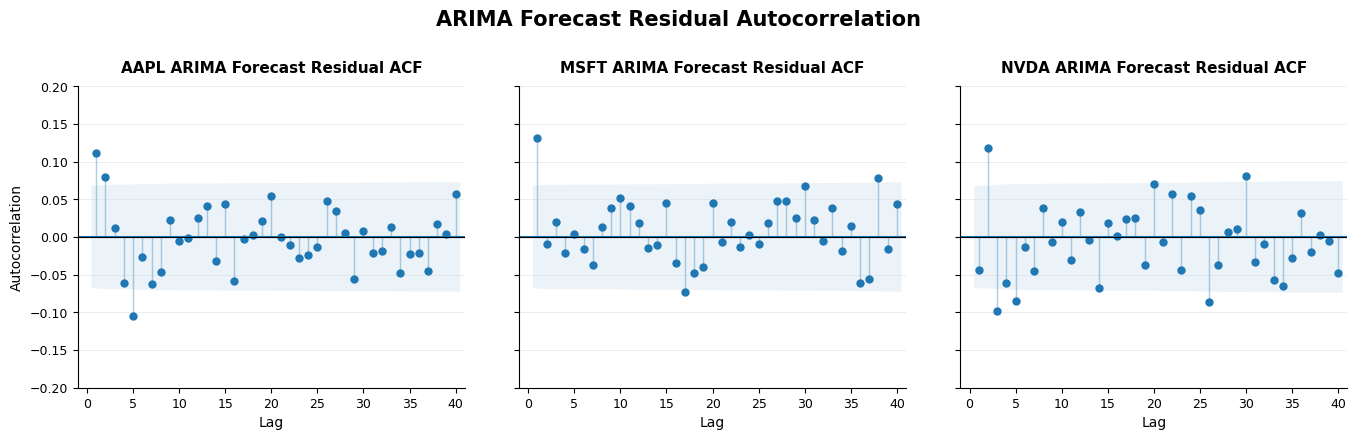

In [65]:
# ============================================================
# FIGURE 4.X — ARIMA FORECAST RESIDUAL ACF
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf


STOCKS = ["AAPL", "MSFT", "NVDA"]
NLAGS = 40


residual_dict = {
    stock: np.asarray(
        arima_residual_store[stock],
        dtype=float
    )
    for stock in STOCKS
}


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


BLUE = "#1F77B4"
CI_BLUE = "#C9DDEB"
GRID = "#D9DEE2"


# ------------------------------------------------------------
# Common y-axis
# ------------------------------------------------------------

all_acf_values = []

for stock in STOCKS:

    values = acf(
        residual_dict[stock],
        nlags=NLAGS,
        fft=True
    )[1:]

    all_acf_values.extend(values)


max_abs = max(
    abs(np.min(all_acf_values)),
    abs(np.max(all_acf_values))
)

y_limit = max(
    0.20,
    np.ceil((max_abs + 0.03) * 20) / 20
)


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.8, 4.5),
    sharey=True
)


for ax, stock in zip(axes, STOCKS):

    residuals = residual_dict[stock]

    plot_acf(
        residuals,
        lags=NLAGS,
        ax=ax,
        alpha=0.05,
        zero=False,
        title="",
        color=BLUE,
        vlines_kwargs={
            "colors": BLUE,
            "linewidth": 1.05,
            "alpha": 0.90
        }
    )

    for collection in ax.collections:
        try:
            collection.set_facecolor(CI_BLUE)
            collection.set_alpha(0.35)
        except Exception:
            pass

    ax.set_title(
        f"{stock} ARIMA Forecast Residual ACF",
        fontweight="semibold",
        pad=10
    )

    ax.set_xlabel("Lag")

    if stock == "AAPL":
        ax.set_ylabel("Autocorrelation")

    ax.set_xlim(-1, NLAGS + 1)
    ax.set_ylim(-y_limit, y_limit)

    ax.axhline(
        0,
        color="black",
        linewidth=0.8
    )

    ax.grid(
        axis="y",
        color=GRID,
        linewidth=0.55,
        alpha=0.70
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")

    ax.tick_params(
        colors="black",
        width=0.8,
        length=3.5
    )


fig.suptitle(
    "ARIMA Forecast Residual Autocorrelation",
    fontsize=15,
    fontweight="semibold",
    y=0.99
)


plt.subplots_adjust(
    left=0.065,
    right=0.985,
    bottom=0.15,
    top=0.82,
    wspace=0.14
)


plt.savefig(
    "figure_4_x_arima_residual_acf.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.06
)

plt.savefig(
    "figure_4_x_arima_residual_acf.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.06
)

plt.show()

Common y-axis range: -0.30 to 0.30


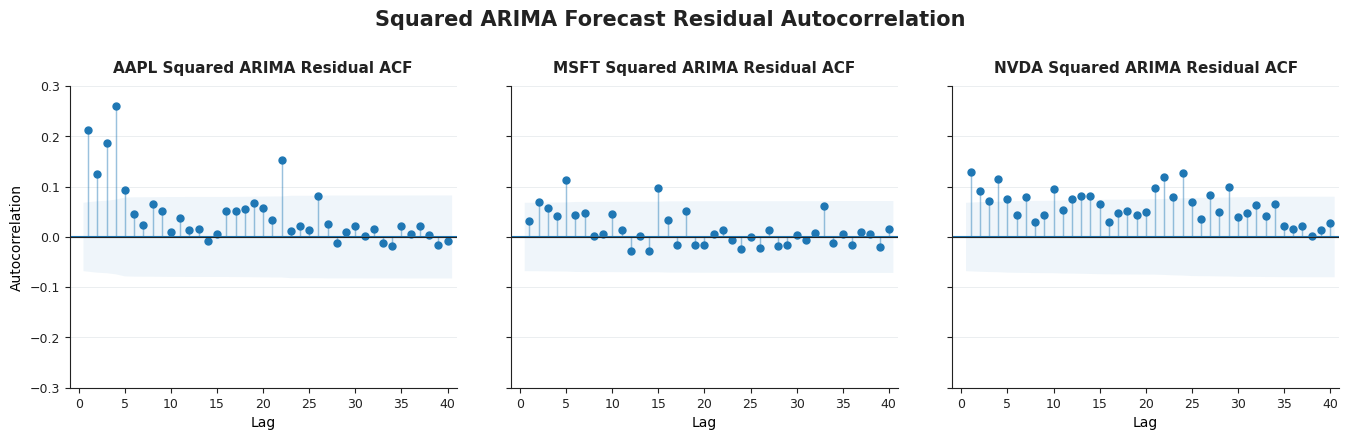

In [66]:
# ============================================================
# FIGURE 4.X — SQUARED ARIMA FORECAST RESIDUAL ACF
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf


# ============================================================
# 1. SETTINGS
# ============================================================

STOCKS = ["AAPL", "MSFT", "NVDA"]
NLAGS = 40


squared_residual_dict = {
    stock:
        np.asarray(
            arima_residual_store[stock],
            dtype=float
        ) ** 2

    for stock in STOCKS
}


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# Standard publication blue
BLUE = "#1F77B4"

# Light blue confidence interval
CI_BLUE = "#DCEAF5"

GRID = "#D9DEE2"
TEXT = "#222222"


# ============================================================
# 2. COMMON Y-AXIS
# ============================================================

all_acf_values = []

for stock in STOCKS:

    values = acf(
        squared_residual_dict[stock],
        nlags=NLAGS,
        fft=True
    )[1:]

    all_acf_values.extend(values)


max_abs = max(
    abs(np.min(all_acf_values)),
    abs(np.max(all_acf_values))
)


y_limit = max(
    0.20,
    np.ceil((max_abs + 0.03) * 20) / 20
)


print(
    f"Common y-axis range: "
    f"{-y_limit:.2f} to {y_limit:.2f}"
)


# ============================================================
# 3. FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.8, 4.5),
    sharey=True
)


# ============================================================
# 4. DRAW EACH PANEL
# ============================================================

for ax, stock in zip(axes, STOCKS):

    values = squared_residual_dict[stock]

    plot_acf(
        values,
        lags=NLAGS,
        ax=ax,
        alpha=0.05,
        zero=False,
        title="",
        color=BLUE,
        vlines_kwargs={
            "colors": BLUE,
            "linewidth": 1.05,
            "alpha": 0.95
        }
    )


    # --------------------------------------------------------
    # Confidence interval
    # --------------------------------------------------------

    for collection in ax.collections:
        try:
            collection.set_facecolor(CI_BLUE)
            collection.set_alpha(0.45)
        except Exception:
            pass


    # --------------------------------------------------------
    # Panel title
    # --------------------------------------------------------

    ax.set_title(
        f"{stock} Squared ARIMA Residual ACF",
        fontweight="semibold",
        color=TEXT,
        pad=10
    )


    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------

    ax.set_xlabel(
        "Lag"
    )

    if stock == "AAPL":
        ax.set_ylabel(
            "Autocorrelation"
        )
    else:
        ax.set_ylabel("")


    # --------------------------------------------------------
    # Axes limits
    # --------------------------------------------------------

    ax.set_xlim(
        -1,
        NLAGS + 1
    )

    ax.set_ylim(
        -y_limit,
        y_limit
    )


    # --------------------------------------------------------
    # Zero reference line
    # --------------------------------------------------------

    ax.axhline(
        0,
        color="#222222",
        linewidth=0.8
    )


    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(
        axis="y",
        color=GRID,
        linewidth=0.55,
        alpha=0.65
    )

    ax.set_axisbelow(True)


    # --------------------------------------------------------
    # Clean publication styling
    # --------------------------------------------------------

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#222222")
    ax.spines["bottom"].set_color("#222222")

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        colors="#222222",
        width=0.8,
        length=3.5
    )


# ============================================================
# 5. MAIN TITLE
# ============================================================

fig.suptitle(
    "Squared ARIMA Forecast Residual Autocorrelation",
    fontsize=15,
    fontweight="semibold",
    color=TEXT,
    y=0.99
)


# ============================================================
# 6. LAYOUT
# ============================================================

plt.subplots_adjust(
    left=0.065,
    right=0.985,
    bottom=0.15,
    top=0.82,
    wspace=0.14
)


# ============================================================
# 7. SAVE
# ============================================================

plt.savefig(
    "figure_4_x_arima_squared_residual_acf.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.06
)

plt.savefig(
    "figure_4_x_arima_squared_residual_acf.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.06
)

plt.show()

In [67]:
# ============================================================
# INSPECT ARIMA-GARCH STORE
# ============================================================

print(
    arima_garch_prediction_store.keys()
)

for stock, store in arima_garch_prediction_store.items():

    print(
        "\n",
        "=" * 60
    )

    print(stock)

    print("=" * 60)

    if isinstance(store, dict):

        for key, value in store.items():

            try:
                print(
                    f"{key:40s}",
                    "| type:",
                    type(value).__name__,
                    "| shape:",
                    getattr(value, "shape", None),
                    "| len:",
                    len(value)
                    if hasattr(value, "__len__")
                    else None
                )

            except Exception:

                print(
                    key,
                    "|",
                    type(value).__name__
                )

    else:

        print(
            type(store),
            getattr(store, "shape", None)
        )

dict_keys(['AAPL', 'MSFT', 'NVDA'])

AAPL
<class 'pandas.core.frame.DataFrame'> (829, 10)

MSFT
<class 'pandas.core.frame.DataFrame'> (829, 10)

NVDA
<class 'pandas.core.frame.DataFrame'> (829, 10)


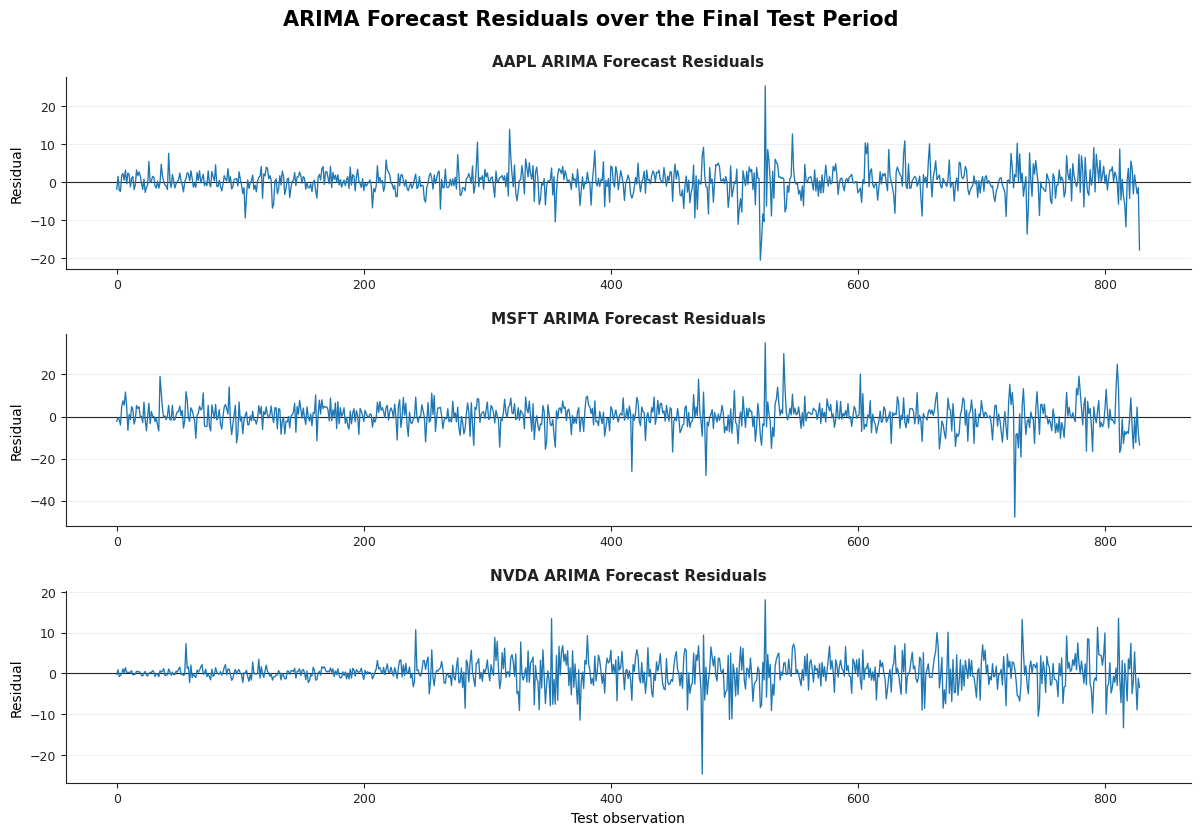

In [68]:
# ============================================================
# FIGURE 4.X — ARIMA FORECAST RESIDUALS OVER TIME
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. SETTINGS
# ============================================================

STOCKS = ["AAPL", "MSFT", "NVDA"]

# Standard publication blue
BLUE = "#1F77B4"

# Supporting colours
ZERO_COLOUR = "#222222"
GRID_COLOUR = "#D9DEE2"
TEXT_COLOUR = "#222222"


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ============================================================
# 2. CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12.5, 8.5),
    sharex=False
)


# ============================================================
# 3. DRAW EACH STOCK
# ============================================================

for ax, stock in zip(axes, STOCKS):

    series = arima_residual_store[stock].copy()

    values = np.asarray(
        series,
        dtype=float
    )


    # --------------------------------------------------------
    # Use datetime index where available
    # --------------------------------------------------------

    if isinstance(
        series.index,
        pd.DatetimeIndex
    ):

        x = series.index
        xlabel = "Date"

    else:

        x = np.arange(
            len(values)
        )

        xlabel = "Test observation"


    # --------------------------------------------------------
    # Residual series
    # --------------------------------------------------------

    ax.plot(
        x,
        values,
        linewidth=0.95,
        color=BLUE
    )


    # --------------------------------------------------------
    # Zero reference line
    # --------------------------------------------------------

    ax.axhline(
        0,
        color=ZERO_COLOUR,
        linewidth=0.8,
        linestyle="-",
        zorder=1
    )


    # --------------------------------------------------------
    # Panel title
    # --------------------------------------------------------

    ax.set_title(
        f"{stock} ARIMA Forecast Residuals",
        fontweight="semibold",
        color=TEXT_COLOUR,
        pad=8
    )


    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------

    ax.set_ylabel(
        "Residual"
    )


    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(
        axis="y",
        color=GRID_COLOUR,
        linewidth=0.5,
        alpha=0.65
    )

    ax.set_axisbelow(True)


    # --------------------------------------------------------
    # Clean publication styling
    # --------------------------------------------------------

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#222222")
    ax.spines["bottom"].set_color("#222222")

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        colors="#222222",
        width=0.8
    )


# ============================================================
# 4. X-AXIS LABEL
# ============================================================

axes[-1].set_xlabel(
    xlabel
)


# ============================================================
# 5. MAIN TITLE
# ============================================================

fig.suptitle(
    "ARIMA Forecast Residuals over the Final Test Period",
    fontsize=15,
    fontweight="semibold",
    y=0.99
)


# ============================================================
# 6. LAYOUT
# ============================================================

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.08,
    top=0.91,
    hspace=0.34
)


# ============================================================
# 7. SAVE
# ============================================================

plt.savefig(
    "figure_4_x_arima_residuals_over_time.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.06
)

plt.savefig(
    "figure_4_x_arima_residuals_over_time.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.06
)

plt.show()

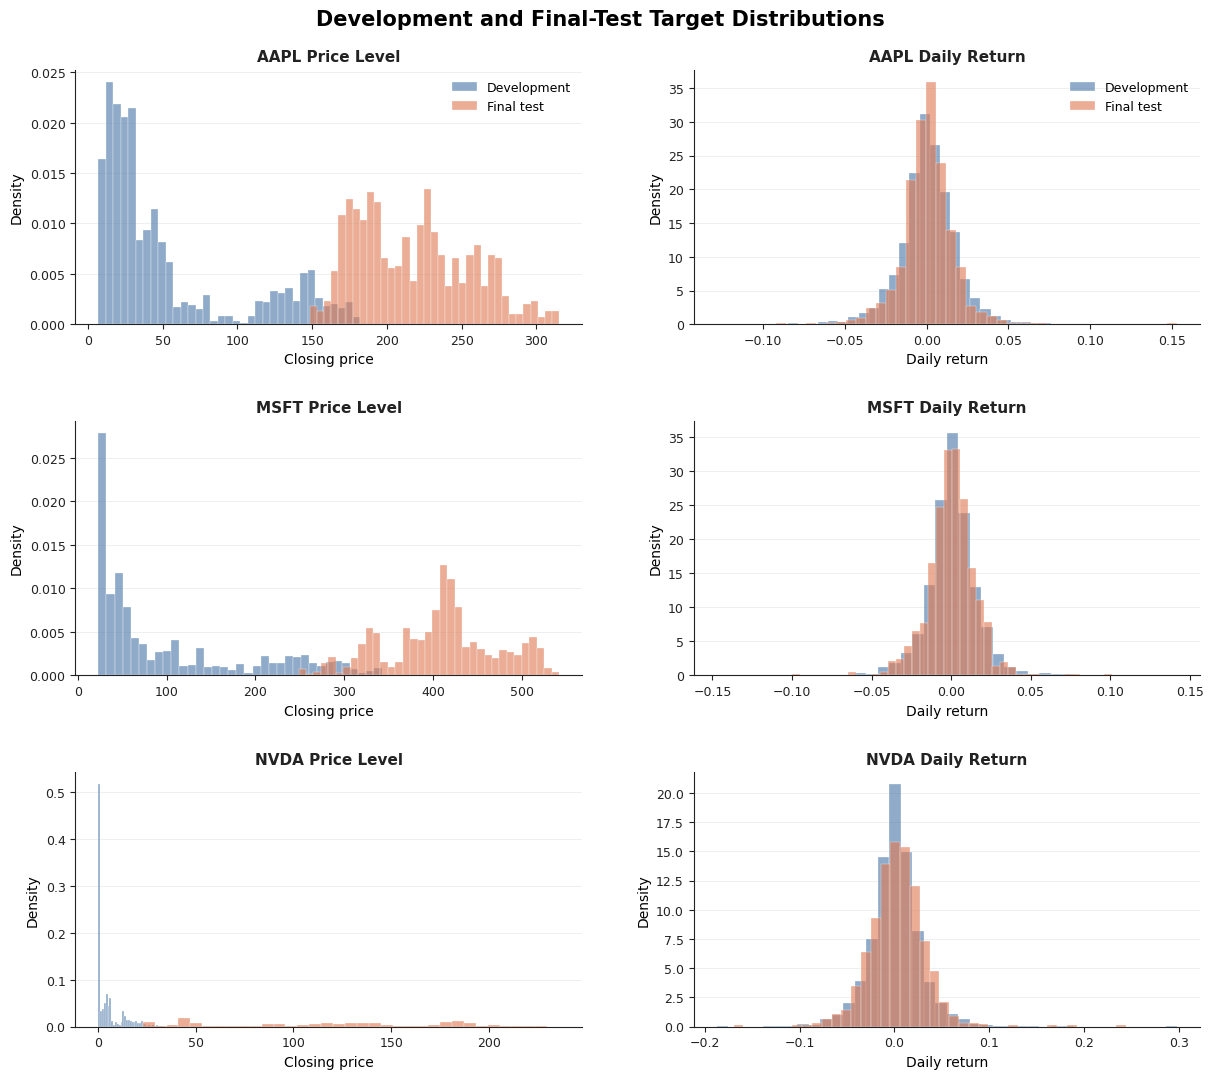

In [69]:
# ============================================================
# FIGURE 4.X — TRAIN/TEST DISTRIBUTION COMPARISON
#
# Rows:
#   AAPL / MSFT / NVDA
#
# Columns:
#   Price level / Daily return
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. DATA
# ============================================================

FILES = {
    "AAPL": "AAPL_mid_clean.csv",
    "MSFT": "MSFT_mid_clean.csv",
    "NVDA": "NVDA_mid_clean.csv"
}

STOCKS = ["AAPL", "MSFT", "NVDA"]

DEVELOPMENT_RATIO = 0.8


# ============================================================
# 2. PUBLICATION COLOURS
# ============================================================

# Muted blue
DEVELOPMENT_COLOUR = "#4C78A8"

# Muted vermillion / orange
TEST_COLOUR = "#E07B54"

TEXT_COLOUR = "#222222"
GRID_COLOUR = "#D9DEE2"


# ============================================================
# 3. GLOBAL STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ============================================================
# 4. CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    3,
    2,
    figsize=(12.5, 11)
)


# ============================================================
# 5. DRAW EACH STOCK
# ============================================================

for row, stock in enumerate(STOCKS):

    df = pd.read_csv(FILES[stock])

    df["Date"] = pd.to_datetime(
        df["Date"]
    )

    df = (
        df
        .sort_values("Date")
        .reset_index(drop=True)
    )

    # Daily simple return
    df["Return"] = (
        df["Close"]
        .pct_change()
    )

    df = (
        df
        .dropna(
            subset=["Close", "Return"]
        )
        .reset_index(drop=True)
    )

    # Chronological 80/20 split
    split = int(
        len(df) * DEVELOPMENT_RATIO
    )

    development = df.iloc[:split]
    final_test = df.iloc[split:]


    # ========================================================
    # LEFT COLUMN — PRICE LEVEL
    # ========================================================

    ax = axes[row, 0]

    ax.hist(
        development["Close"],
        bins=35,
        density=True,
        alpha=0.62,
        label="Development",
        color=DEVELOPMENT_COLOUR,
        edgecolor="white",
        linewidth=0.35
    )

    ax.hist(
        final_test["Close"],
        bins=35,
        density=True,
        alpha=0.62,
        label="Final test",
        color=TEST_COLOUR,
        edgecolor="white",
        linewidth=0.35
    )

    ax.set_title(
        f"{stock} Price Level",
        fontweight="semibold",
        color=TEXT_COLOUR
    )

    ax.set_xlabel(
        "Closing price"
    )

    ax.set_ylabel(
        "Density"
    )


    # ========================================================
    # RIGHT COLUMN — DAILY RETURN
    # ========================================================

    ax = axes[row, 1]

    ax.hist(
        development["Return"],
        bins=40,
        density=True,
        alpha=0.62,
        label="Development",
        color=DEVELOPMENT_COLOUR,
        edgecolor="white",
        linewidth=0.35
    )

    ax.hist(
        final_test["Return"],
        bins=40,
        density=True,
        alpha=0.62,
        label="Final test",
        color=TEST_COLOUR,
        edgecolor="white",
        linewidth=0.35
    )

    ax.set_title(
        f"{stock} Daily Return",
        fontweight="semibold",
        color=TEXT_COLOUR
    )

    ax.set_xlabel(
        "Daily return"
    )

    ax.set_ylabel(
        "Density"
    )


# ============================================================
# 6. FORMATTING
# ============================================================

for ax in axes.flat:

    ax.grid(
        axis="y",
        linewidth=0.5,
        color=GRID_COLOUR,
        alpha=0.65
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#222222")
    ax.spines["bottom"].set_color("#222222")

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        colors="#222222",
        width=0.8
    )


# ============================================================
# 7. LEGENDS
# ============================================================

axes[0, 0].legend(
    frameon=False,
    fontsize=9
)

axes[0, 1].legend(
    frameon=False,
    fontsize=9
)


# ============================================================
# 8. MAIN TITLE
# ============================================================

fig.suptitle(
    "Development and Final-Test Target Distributions",
    fontsize=15,
    fontweight="semibold",
    y=0.995
)


# ============================================================
# 9. LAYOUT
# ============================================================

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.07,
    top=0.94,
    hspace=0.38,
    wspace=0.22
)


# ============================================================
# 10. SAVE
# ============================================================

plt.savefig(
    "figure_4_x_train_test_target_distributions.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.06
)

plt.savefig(
    "figure_4_x_train_test_target_distributions.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.06
)

plt.show()

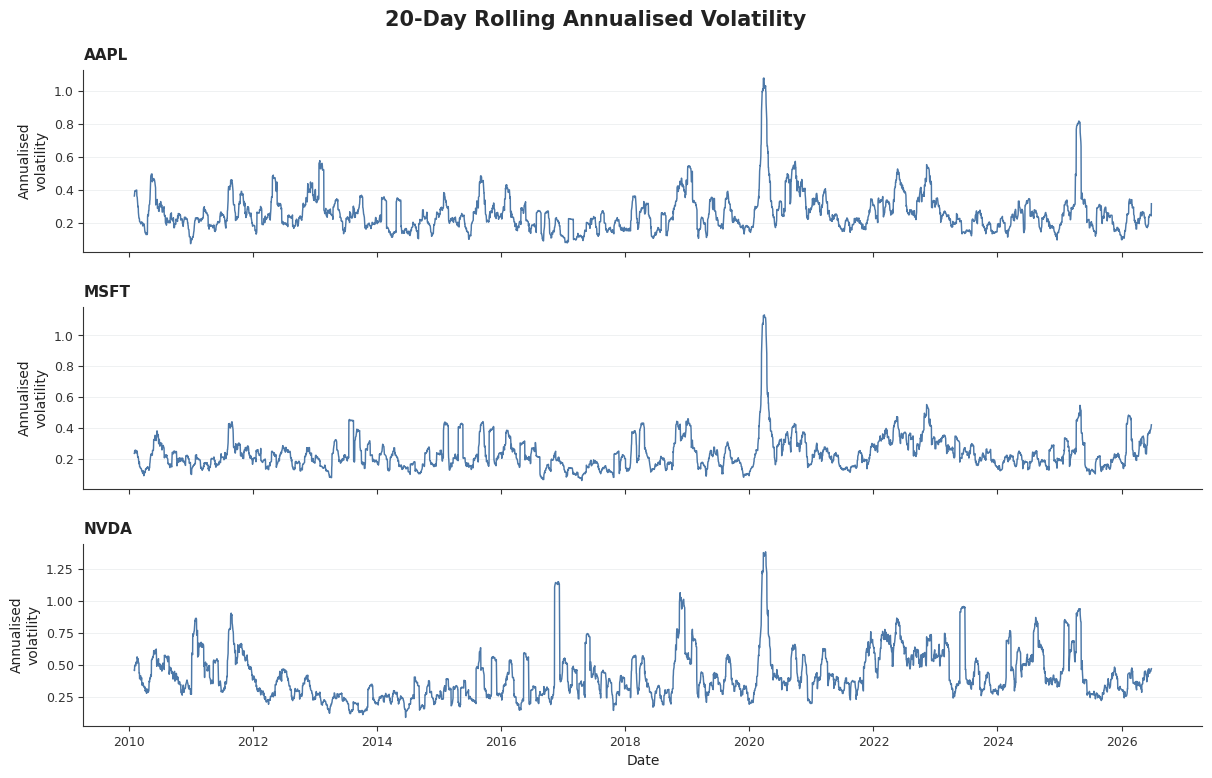

In [70]:
# ============================================================
# FIGURE 4.X — ROLLING VOLATILITY
# Clean small-multiples version
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


FILES = {
    "AAPL": "AAPL_mid_clean.csv",
    "MSFT": "MSFT_mid_clean.csv",
    "NVDA": "NVDA_mid_clean.csv"
}

STOCKS = ["AAPL", "MSFT", "NVDA"]

WINDOW = 20

# Clean publication blue
LINE_COLOUR = "#4C78A8"
GRID_COLOUR = "#E3E6E8"
TEXT_COLOUR = "#222222"


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


fig, axes = plt.subplots(
    3,
    1,
    figsize=(12.5, 8.0),
    sharex=True
)


for ax, stock in zip(axes, STOCKS):

    df = pd.read_csv(FILES[stock])

    df["Date"] = pd.to_datetime(df["Date"])

    df = (
        df
        .sort_values("Date")
        .reset_index(drop=True)
    )

    returns = df["Close"].pct_change()

    rolling_vol = (
        returns
        .rolling(WINDOW)
        .std()
        * np.sqrt(252)
    )

    ax.plot(
        df["Date"],
        rolling_vol,
        color=LINE_COLOUR,
        linewidth=1.05
    )

    ax.set_title(
        stock,
        loc="left",
        fontweight="semibold",
        color=TEXT_COLOUR,
        pad=7
    )

    ax.set_ylabel(
        "Annualised\nvolatility",
        color=TEXT_COLOUR
    )

    ax.grid(
        axis="y",
        color=GRID_COLOUR,
        linewidth=0.55,
        alpha=0.70
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#333333")
    ax.spines["bottom"].set_color("#333333")

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        colors="#333333",
        width=0.8
    )


# Date axis
axes[-1].xaxis.set_major_locator(
    mdates.YearLocator(2)
)

axes[-1].xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

axes[-1].set_xlabel(
    "Date",
    color=TEXT_COLOUR
)


fig.suptitle(
    "20-Day Rolling Annualised Volatility",
    fontsize=15,
    fontweight="semibold",
    color=TEXT_COLOUR,
    y=0.985
)


plt.subplots_adjust(
    left=0.09,
    right=0.985,
    bottom=0.09,
    top=0.91,
    hspace=0.30
)


plt.savefig(
    "figure_4_x_rolling_volatility.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.06
)

plt.savefig(
    "figure_4_x_rolling_volatility.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.06
)

plt.show()

In [71]:
# ============================================================
# INSPECT ARIMA-GARCH DATAFRAME COLUMNS
# ============================================================

for stock in ["AAPL", "MSFT", "NVDA"]:

    print("\n" + "=" * 70)
    print(stock)
    print("=" * 70)

    df_garch = arima_garch_prediction_store[stock]

    print("Shape:", df_garch.shape)
    print("\nColumns:")
    print(df_garch.columns.tolist())

    print("\nFirst 3 rows:")
    display(df_garch.head(3))


AAPL
Shape: (829, 10)

Columns:
['Date', 'Current_Close', 'True_Next_Close', 'ARIMA_GARCH_Point_Forecast', 'Forecast_Error', 'GARCH_Variance', 'GARCH_Volatility', 'Standardized_Residual', 'Lower_95', 'Upper_95']

First 3 rows:


,Date,Current_Close,True_Next_Close,ARIMA_GARCH_Point_Forecast,Forecast_Error,GARCH_Variance,GARCH_Volatility,Standardized_Residual,Lower_95,Upper_95
0,2023-03-07,151.600006,152.869995,151.386948,1.483047,6.238977,2.497794,0.593743,146.408559,156.365336
1,2023-03-08,152.869995,150.589996,152.820282,-2.230286,5.990917,2.447635,-0.911200,147.941867,157.698697
2,2023-03-09,150.589996,148.500000,151.012499,-2.512499,5.928857,2.434924,-1.031859,146.159417,155.865580



MSFT
Shape: (829, 10)

Columns:
['Date', 'Current_Close', 'True_Next_Close', 'ARIMA_GARCH_Point_Forecast', 'Forecast_Error', 'GARCH_Variance', 'GARCH_Volatility', 'Standardized_Residual', 'Lower_95', 'Upper_95']

First 3 rows:


,Date,Current_Close,True_Next_Close,ARIMA_GARCH_Point_Forecast,Forecast_Error,GARCH_Variance,GARCH_Volatility,Standardized_Residual,Lower_95,Upper_95
0,2023-03-07,254.149994,253.699997,254.182267,-0.482270,19.993774,4.471440,-0.107856,245.281196,263.083338
1,2023-03-08,253.699997,252.320007,253.869752,-1.549745,18.663035,4.320074,-0.358731,245.269998,262.469506
2,2023-03-09,252.320007,248.589996,252.696608,-4.106612,17.568357,4.191462,-0.979756,244.352874,261.040342



NVDA
Shape: (829, 10)

Columns:
['Date', 'Current_Close', 'True_Next_Close', 'ARIMA_GARCH_Point_Forecast', 'Forecast_Error', 'GARCH_Variance', 'GARCH_Volatility', 'Standardized_Residual', 'Lower_95', 'Upper_95']

First 3 rows:


,Date,Current_Close,True_Next_Close,ARIMA_GARCH_Point_Forecast,Forecast_Error,GARCH_Variance,GARCH_Volatility,Standardized_Residual,Lower_95,Upper_95
0,2023-03-07,23.288000,24.181000,23.274554,0.906446,0.386738,0.621882,1.457584,22.039349,24.509759
1,2023-03-08,24.181000,23.436001,24.189640,-0.753639,0.467847,0.683993,-1.101822,22.831068,25.548212
2,2023-03-09,23.436001,22.965000,23.457773,-0.492772,0.480378,0.693093,-0.710976,22.081127,24.834418


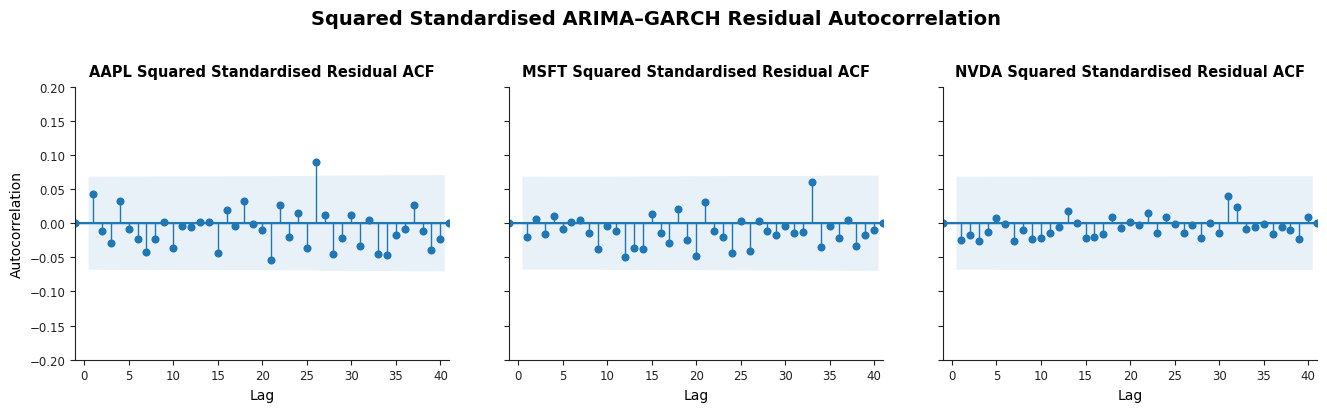

In [72]:
# ============================================================
# FIGURE 4.X
# ARIMA–GARCH SQUARED STANDARDISED RESIDUAL AUTOCORRELATION
# AAPL / MSFT / NVDA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf


# ============================================================
# 1. SETTINGS
# ============================================================

STOCKS = ["AAPL", "MSFT", "NVDA"]

MAX_LAG = 40

# Standard publication blue
BLUE = "#1F77B4"

# Light blue for confidence interval
CI_BLUE = "#DCEAF5"


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.titlesize": 10.5,
    "axes.labelsize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ============================================================
# 2. CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.5, 4.2),
    sharex=True,
    sharey=True
)


# ============================================================
# 3. DRAW EACH STOCK
# ============================================================

for ax, stock in zip(axes, STOCKS):

    # --------------------------------------------------------
    # Extract standardised ARIMA–GARCH residuals
    # --------------------------------------------------------

    df = arima_garch_prediction_store[stock].copy()

    residuals = pd.to_numeric(
        df["Standardized_Residual"],
        errors="coerce"
    )

    residuals = residuals.replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()


    # --------------------------------------------------------
    # Square standardised residuals
    # --------------------------------------------------------

    squared_residuals = residuals ** 2


    # --------------------------------------------------------
    # Plot ACF
    # --------------------------------------------------------

    plot_acf(
        squared_residuals,
        lags=MAX_LAG,
        alpha=0.05,
        zero=False,
        ax=ax,
        marker="o",
        markersize=4.8,
        color=BLUE,
        vlines_kwargs={
            "colors": BLUE,
            "linewidth": 1.0
        }
    )


    # --------------------------------------------------------
    # Change confidence interval to light blue
    # --------------------------------------------------------

    # plot_acf creates the CI as a PolyCollection.
    # Set it to a restrained light blue.
    for collection in ax.collections:

        # Avoid changing the marker collection
        if hasattr(collection, "get_paths"):

            paths = collection.get_paths()

            # CI usually contains a polygon with many vertices
            if len(paths) == 1:

                vertices = paths[0].vertices

                if len(vertices) > 20:
                    collection.set_facecolor(CI_BLUE)
                    collection.set_edgecolor("none")
                    collection.set_alpha(0.65)


    # --------------------------------------------------------
    # Zero reference line
    # --------------------------------------------------------

    ax.axhline(
        0,
        color=BLUE,
        linewidth=1.05,
        zorder=1
    )


    # --------------------------------------------------------
    # Individual panel title
    # --------------------------------------------------------

    ax.set_title(
        f"{stock} Squared Standardised Residual ACF",
        fontweight="semibold",
        pad=8
    )


    # --------------------------------------------------------
    # Axes
    # --------------------------------------------------------

    ax.set_xlabel("Lag")

    ax.set_xlim(-1, MAX_LAG + 1)

    # Common y-axis range
    ax.set_ylim(-0.20, 0.20)

    ax.set_xticks(
        np.arange(0, MAX_LAG + 1, 5)
    )


    # --------------------------------------------------------
    # Clean publication styling
    # --------------------------------------------------------

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#222222")
    ax.spines["bottom"].set_color("#222222")

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        colors="#222222",
        width=0.8
    )


# ============================================================
# 4. COMMON Y LABEL
# ============================================================

axes[0].set_ylabel(
    "Autocorrelation"
)

axes[1].set_ylabel("")
axes[2].set_ylabel("")


# ============================================================
# 5. MAIN TITLE
# ============================================================

fig.suptitle(
    "Squared Standardised ARIMA–GARCH Residual Autocorrelation",
    fontsize=14,
    fontweight="semibold",
    y=0.985
)


# ============================================================
# 6. LAYOUT
# ============================================================

plt.subplots_adjust(
    left=0.07,
    right=0.99,
    bottom=0.15,
    top=0.80,
    wspace=0.16
)


# ============================================================
# 7. SAVE
# ============================================================

plt.savefig(
    "figure_4_x_arima_garch_squared_standardised_residual_acf_combined.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.06
)

plt.savefig(
    "figure_4_x_arima_garch_squared_standardised_residual_acf_combined.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.06
)

plt.show()

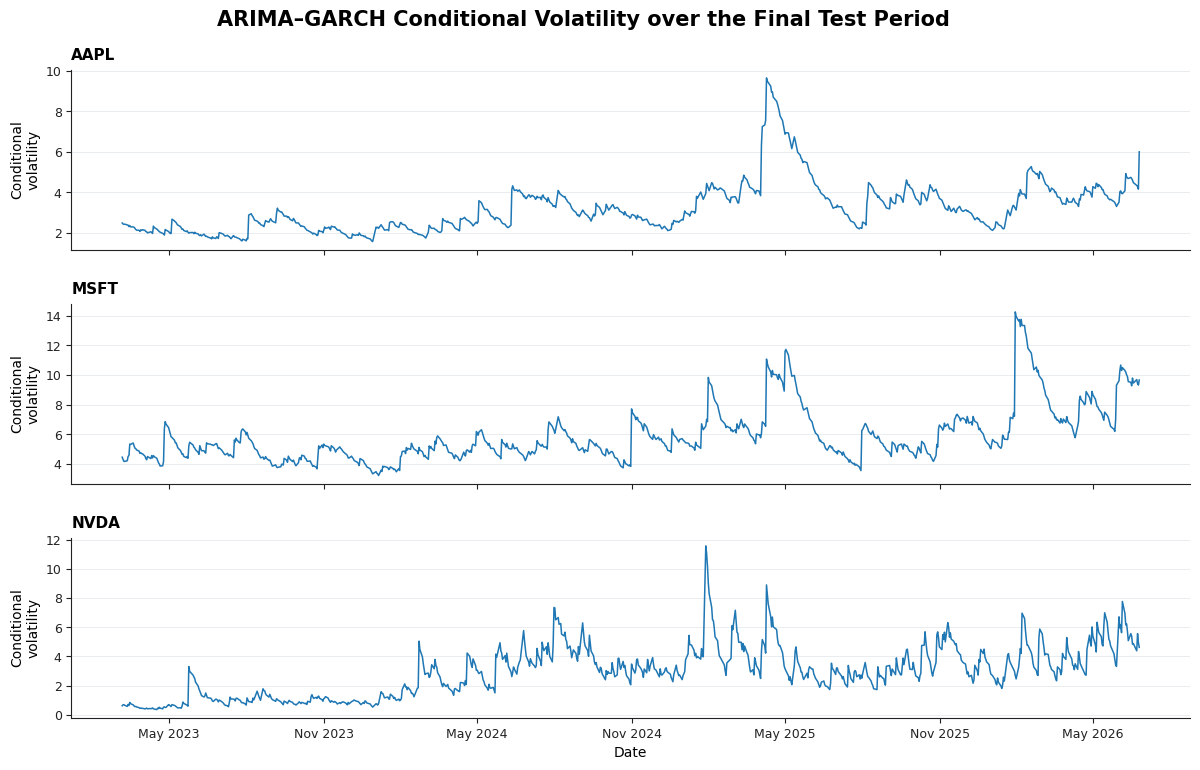

In [73]:
# ============================================================
# FIGURE 4.X
# ARIMA–GARCH CONDITIONAL VOLATILITY
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


STOCKS = ["AAPL", "MSFT", "NVDA"]

# Standard publication blue
BLUE = "#1F77B4"

# Light grey grid
GRID_COLOUR = "#D9DEE2"


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12.5, 8.0),
    sharex=True
)


# ============================================================
# DRAW EACH STOCK
# ============================================================

for ax, stock in zip(axes, STOCKS):

    df = (
        arima_garch_prediction_store[stock]
        .copy()
    )

    df["Date"] = pd.to_datetime(
        df["Date"]
    )

    # --------------------------------------------------------
    # Conditional volatility
    # --------------------------------------------------------

    ax.plot(
        df["Date"],
        df["GARCH_Volatility"],
        color=BLUE,
        linewidth=1.10
    )

    # --------------------------------------------------------
    # Panel title
    # --------------------------------------------------------

    ax.set_title(
        stock,
        fontweight="semibold",
        loc="left",
        pad=7
    )

    # --------------------------------------------------------
    # Y-axis
    # --------------------------------------------------------

    ax.set_ylabel(
        "Conditional\nvolatility"
    )

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(
        axis="y",
        color=GRID_COLOUR,
        linewidth=0.55,
        alpha=0.70
    )

    # --------------------------------------------------------
    # Clean publication styling
    # --------------------------------------------------------

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#222222")
    ax.spines["bottom"].set_color("#222222")

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        colors="#222222",
        width=0.8
    )


# ============================================================
# DATE FORMATTING
# ============================================================

axes[-1].xaxis.set_major_locator(
    mdates.MonthLocator(
        interval=6
    )
)

axes[-1].xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

axes[-1].set_xlabel(
    "Date"
)


# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(
    "ARIMA–GARCH Conditional Volatility over the Final Test Period",
    fontsize=15,
    fontweight="semibold",
    y=0.985
)


# ============================================================
# LAYOUT
# ============================================================

plt.subplots_adjust(
    left=0.09,
    right=0.985,
    bottom=0.10,
    top=0.91,
    hspace=0.30
)


# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "figure_4_x_arima_garch_conditional_volatility.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.06
)

plt.savefig(
    "figure_4_x_arima_garch_conditional_volatility.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.06
)

plt.show()

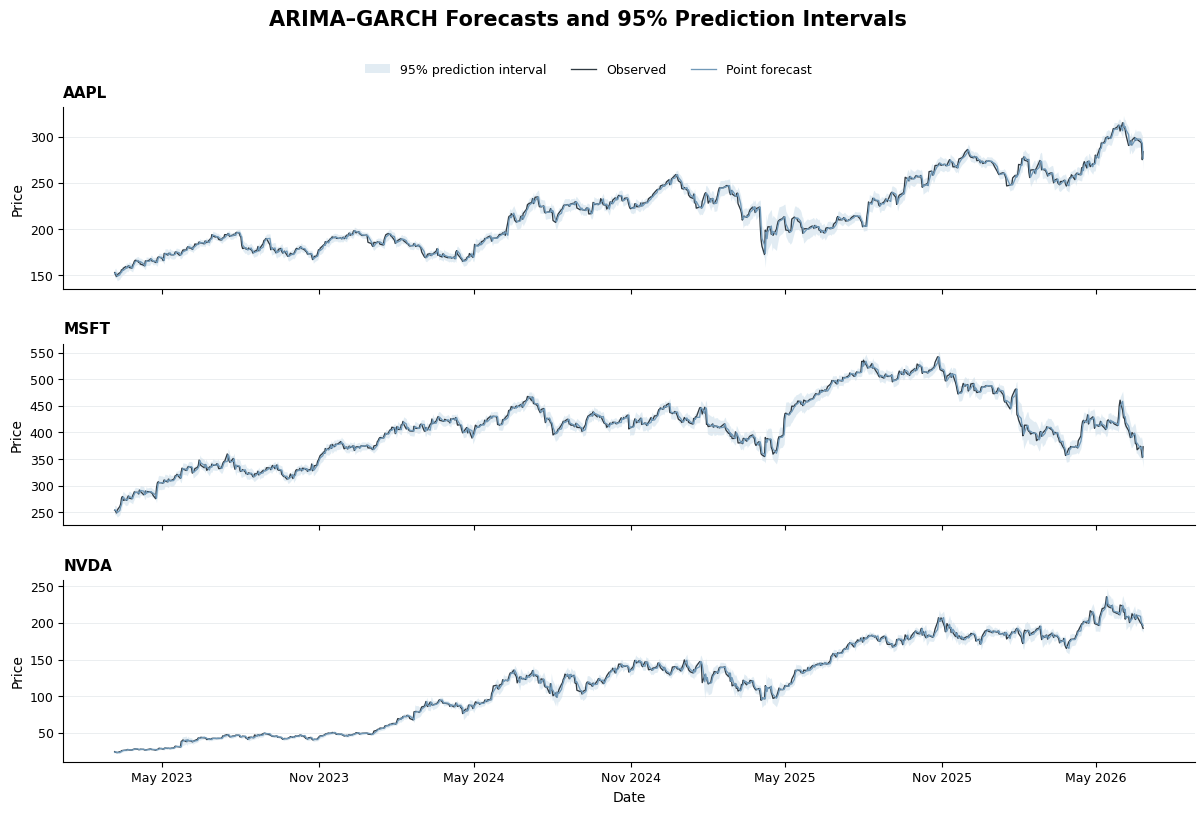

In [74]:
# ============================================================
# FIGURE 4.X
# ARIMA-GARCH 95% PREDICTION INTERVALS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


STOCKS = ["AAPL", "MSFT", "NVDA"]


ACTUAL = "#303A42"
FORECAST = "#7199B8"
INTERVAL = "#BFD7E6"


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


fig, axes = plt.subplots(
    3,
    1,
    figsize=(12.5, 8.5),
    sharex=True
)


for ax, stock in zip(
    axes,
    STOCKS
):

    df = (
        arima_garch_prediction_store[stock]
        .copy()
    )

    df["Date"] = pd.to_datetime(
        df["Date"]
    )


    # --------------------------------------------------------
    # 95% interval
    # --------------------------------------------------------

    ax.fill_between(
        df["Date"],
        df["Lower_95"],
        df["Upper_95"],
        color=INTERVAL,
        alpha=0.45,
        linewidth=0,
        label="95% prediction interval"
    )


    # --------------------------------------------------------
    # Actual
    # --------------------------------------------------------

    ax.plot(
        df["Date"],
        df["True_Next_Close"],
        color=ACTUAL,
        linewidth=0.95,
        label="Observed"
    )


    # --------------------------------------------------------
    # Forecast
    # --------------------------------------------------------

    ax.plot(
        df["Date"],
        df["ARIMA_GARCH_Point_Forecast"],
        color=FORECAST,
        linewidth=0.95,
        label="Point forecast"
    )


    ax.set_title(
        stock,
        fontweight="semibold",
        loc="left",
        pad=7
    )

    ax.set_ylabel(
        "Price"
    )

    ax.grid(
        axis="y",
        color="#D9DEE2",
        linewidth=0.55,
        alpha=0.65
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        colors="black"
    )


# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.935),
    ncol=3,
    frameon=False,
    fontsize=9
)


# ------------------------------------------------------------
# Date axis
# ------------------------------------------------------------

axes[-1].xaxis.set_major_locator(
    mdates.MonthLocator(
        interval=6
    )
)

axes[-1].xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

axes[-1].set_xlabel(
    "Date"
)


fig.suptitle(
    "ARIMA–GARCH Forecasts and 95% Prediction Intervals",
    fontsize=15,
    fontweight="semibold",
    y=0.985
)


plt.subplots_adjust(
    left=0.08,
    right=0.985,
    bottom=0.10,
    top=0.87,
    hspace=0.30
)


plt.savefig(
    "figure_4_x_arima_garch_prediction_intervals.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.06
)

plt.savefig(
    "figure_4_x_arima_garch_prediction_intervals.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.06
)

plt.show()